# MCNP to ALARA Complete Workflow

## Workflow Steps
1. Extract flux data from MCNP HDF5 output (VITAMIN-J 175-group)
2. Generate ALARA input files with multi-zone geometry
3. Run ALARA activation calculations
4. Post-process output to CSV files with uncertainties
5. Visualize results and compare with experimental gamma spectroscopy

## Irradiation Schedule
- **3 second irradiation** → cooling at 300s, 2hr, 24hr, 4d
- **2 hour irradiation** → cooling at 15d

## Materials
| ALARA Material | Tally | Sample |
|----------------|-------|--------|
| CNA | 85214 | RAFM-N |
| EUROFER97_C | 85224 | RAFM-C |
| EUROFER97_B | 85234 | RAFM-B |
| EUROFER97_A | 85244 | RAFM-A |

## Setup and Configuration

In [58]:
"""
RAFM Irradiation Analysis - Setup Cell

This notebook analyzes activation products from RAFM steel irradiation experiments,
comparing ALARA simulations against experimental gamma spectroscopy measurements.

Directory structure (rafm_irradiation_ldrd):
├── alara_inputs/              # ALARA input data files
│   ├── mcnp_inputs/           # MCNP input files
│   └── runtpe.h5              # MCNP mesh tally data
├── irradiation_QG_processed/  # Processed experimental data
│   ├── RAFM1/, RAFM3/, RAFM4/ # Gamma spectra by sample set
│   └── flux_wires/            # Flux wire measurement data
├── raw_gamma_spec/            # Raw gamma spectra files (.ASC)
│   ├── RAFM1/, RAFM2/, RAFM3/, RAFM4/
│   └── flux_wires/
├── scripts/                   # Python support modules
│   ├── plotting.py            # Consolidated plotting functions
│   ├── nuclear_data.py        # Nuclear data utilities
│   ├── element_data.py        # Element data from elelib
│   ├── isotope_utils.py       # Isotope formatting/utilities
│   ├── decay_physics.py       # Decay calculations, SNR optimization
│   └── ...
├── alara_output/              # Generated output directory
└── RAFM_Irradiation_Analysis.ipynb  # This notebook
"""

import os
import sys
import subprocess
import json
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============== Directory Structure ==============
# Project root is where the notebook lives
PROJECT_ROOT = Path.cwd()
ALARA_ROOT = PROJECT_ROOT.parent  # /filespace/s/smandych/CAE/projects/ALARA

# Input directories - ALARA-specific inputs
INPUTS_DIR = PROJECT_ROOT / "alara_inputs"
MCNP_INPUTS_DIR = INPUTS_DIR / "mcnp_inputs"

# Existing data directories (match original repo structure)
EXPERIMENTAL_DIR = PROJECT_ROOT / "irradiation_QG_processed"  # Processed experimental data
FLUX_WIRES_DIR = EXPERIMENTAL_DIR / "flux_wires"              # Flux wire measurements
SPECTRA_DIR = PROJECT_ROOT / "raw_gamma_spec"                  # Raw gamma spectra (.ASC)

# Scripts directory (our support modules)
SCRIPTS_DIR = PROJECT_ROOT / "scripts"

# ALARA tools directory (from main ALARA repo)
TOOLS_DIR = ALARA_ROOT / "tools"

# Output directories
OUTPUT_DIR = PROJECT_ROOT / "alara_output"
OUTPUT_DIR.mkdir(exist_ok=True)
(OUTPUT_DIR / 'decay_curves').mkdir(exist_ok=True)
(OUTPUT_DIR / 'activity_plots').mkdir(exist_ok=True)
(OUTPUT_DIR / 'snr_optimization').mkdir(exist_ok=True)

# ============== Python Path Setup ==============
# Add directories to Python path
for path in [SCRIPTS_DIR, TOOLS_DIR]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

# ============== Import ALARA Tools ==============
# ALARA output processing tools (from main ALARA repo tools/)
from alara_output_processing import FileParser, ALARADFrame, DataLibrary, SECONDS_CONV, convert_times
print(f"✓ ALARA output processing tools loaded from: {TOOLS_DIR}")

from alara_output_processing import alara_output_plotting as aop_plotting
print(f"✓ ALARA plotting tools loaded")

# ============== Import Our Support Modules ==============
# From scripts/ directory
from nuclear_data import get_half_life, get_gamma_info, using_ensdf, get_data_source
from element_data import ELEMENT_Z, Z_TO_ELEMENT, element_to_z, z_to_element
from isotope_utils import canonical_iso, format_iso_pretty, get_half_life_days, has_gamma_emission

# Import consolidated plotting module (standardized styles and colors)
from plotting import (
    MATERIAL_COLORS, COOLING_COLORS, SOURCE_COLORS, LABELS,
    apply_standard_style,
    plot_comparison_scatter, plot_comparison_by_material,
    plot_snr_heatmap, plot_threshold_comparison
)
apply_standard_style()  # Apply consistent plot styling
print(f"✓ Consolidated plotting module loaded (standardized styles)")

print(f"✓ Nuclear data loaded: {get_data_source()}")
print(f"✓ Element data loaded: {len(ELEMENT_Z)} elements from elelib")

# ============== Import MCNP Workflow Modules ==============
# Load comparison and plotting modules from MCNP_ALARA_Workflow
MCNP_WORKFLOW_DIR = ALARA_ROOT / "MCNP_ALARA_Workflow"

if str(MCNP_WORKFLOW_DIR) not in sys.path:
    sys.path.append(str(MCNP_WORKFLOW_DIR))

import alara_comparison
import alara_threshold_plotting
print(f"✓ ALARA comparison and threshold plotting modules loaded from: {MCNP_WORKFLOW_DIR}")

# ============== Configuration ==============
# Key file paths (relative to their directories)
MCNP_INPUT = MCNP_INPUTS_DIR / 'whale_J_core_clean_loc.i'
H5_FILE = INPUTS_DIR / 'runtpe.h5'
SPECTRUM_FILE = SPECTRA_DIR / 'flux_wires' / 'spectrum_vit_j.csv'  # spectrum in raw_gamma_spec

print(f"\n{'='*50}")
print(f"RAFM Irradiation Analysis - Configuration")
print(f"{'='*50}")
print(f"Project root:      {PROJECT_ROOT}")
print(f"MCNP input:        {MCNP_INPUT}")
print(f"HDF5 file:         {H5_FILE}")
print(f"Spectrum file:     {SPECTRUM_FILE}")
print(f"Experimental data: {EXPERIMENTAL_DIR}")
print(f"Raw spectra:       {SPECTRA_DIR}")
print(f"Output dir:        {OUTPUT_DIR}")

✓ ALARA output processing tools loaded from: /groupspace/cnerg/users/smandych/projects/ALARA/tools
✓ ALARA plotting tools loaded
✓ Consolidated plotting module loaded (standardized styles)
✓ Nuclear data loaded: paceENSDF (ENSDF database, 2411 nuclides)
✓ Element data loaded: 84 elements from elelib
✓ ALARA comparison and threshold plotting modules loaded from: /groupspace/cnerg/users/smandych/projects/ALARA/MCNP_ALARA_Workflow

RAFM Irradiation Analysis - Configuration
Project root:      /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd
MCNP input:        /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_inputs/mcnp_inputs/whale_J_core_clean_loc.i
HDF5 file:         /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_inputs/runtpe.h5
Spectrum file:     /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/raw_gamma_spec/flux_wires/spectrum_vit_j.csv
Experimental data: /groupspace/cnerg/users/smandych

## Step 0: Load Experimental Data

Import measured activation of flux wires (assuming 1 g per wire for now) and compute specific activities for use as flux proxies.
This data is loaded early to allow cooling time determination for subsequent steps.

In [112]:
# Ensure output directory exists



if 'alara_output_dir' not in globals():



    if 'OUTPUT_DIR' in globals():



        alara_output_dir = Path(OUTPUT_DIR)



    else:



        alara_output_dir = Path('alara_output')







alara_output_dir.mkdir(parents=True, exist_ok=True)



print(f"Output directory: {alara_output_dir.absolute()}")







# ==============================================================================



# IMPORT UTILITIES FROM STANDALONE SCRIPTS (REQUIRED - fail hard if missing)



# ==============================================================================



# Force reload of experimental_data_loader to pick up any changes



import importlib



import experimental_data_loader



importlib.reload(experimental_data_loader)







from isotope_utils import (



    canonical_iso, format_iso_pretty,



    get_half_life_days, get_half_life_seconds,



    half_life_to_lambda, parse_activity_unit,



    LN2, AVOGADRO,



)



print("✓ Loaded isotope_utils")







from flux_wire_loader import (



    load_flux_wires, get_metadata_df, WIRE_METADATA



)



print("✓ Loaded flux_wire_loader")







from experimental_data_loader import (



    load_experimental_data, parse_experimental_file,



    experimental_to_dataframe, get_top_isotopes,



    SAMPLE_TO_MATERIAL, MATERIAL_TO_TALLY, COOLING_TIME_MAP



)



print("✓ Loaded experimental_data_loader")



print(f"  SAMPLE_TO_MATERIAL: {SAMPLE_TO_MATERIAL}")







# ==============================================================================



# LOAD FLUX WIRE DATA



# ==============================================================================



print("\n" + "=" * 80)



print("FLUX WIRE DATA")



print("=" * 80)







# Use directory structure from setup cell (fallback to correct paths)



flux_wires_dir = FLUX_WIRES_DIR if 'FLUX_WIRES_DIR' in dir() else Path('irradiation_QG_processed/flux_wires')







if flux_wires_dir.exists():



    flux_wires_df = load_flux_wires(



        flux_wires_dir=str(flux_wires_dir),



        sample_filter=r'-1($|_)',  # Only wires ending in -1



        default_irradiation_s=7200,



        output_csv=str(alara_output_dir / 'flux_wires_activity.csv')



    )



    meta_df = get_metadata_df()



    



    if not flux_wires_df.empty:



        display(flux_wires_df.head())



    else:



        print("No flux wire data loaded.")



else:



    print(f"Flux wires directory not found: {flux_wires_dir}")



    flux_wires_df = pd.DataFrame()







# ==============================================================================



# LOAD EXPERIMENTAL DATA FROM BOTH RAFM3 AND RAFM4



# ==============================================================================



# RAFM3: Gamma spec measurements after 3-second irradiation



#        Times in filenames are approximate post-irradiation times



# RAFM4: Gamma spec measurements after 2-hour irradiation



#        Times in filenames are post-irradiation times from second irradiation



# ==============================================================================



print("\n" + "=" * 80)



print("EXPERIMENTAL DATA")



print("=" * 80)







experimental_data = {}







# Load RAFM3 data (measurements after first 3s irradiation)



exp_data_dir_3 = EXPERIMENTAL_DIR / 'RAFM3' if 'EXPERIMENTAL_DIR' in dir() else Path('irradiation_QG_processed/RAFM3')







exp_data_3 = {}



if exp_data_dir_3.exists():



    print(f"\n--- Loading RAFM3 (3s irradiation) from {exp_data_dir_3} ---")



    exp_data_3 = load_experimental_data(



        exp_data_dir=str(exp_data_dir_3),



        verbose=True



    )



    # Merge RAFM3 data into main dict



    for mat, times in exp_data_3.items():



        if mat not in experimental_data:



            experimental_data[mat] = {}



        for time_key, isotopes in times.items():



            experimental_data[mat][time_key] = isotopes



    print(f"\n✓ RAFM3: Loaded data for {len(exp_data_3)} materials")



else:



    print(f"RAFM3 directory not found: {exp_data_dir_3}")







# Load RAFM4 data (measurements after 2hr irradiation)



exp_data_dir_4 = EXPERIMENTAL_DIR / 'RAFM4' if 'EXPERIMENTAL_DIR' in dir() else Path('irradiation_QG_processed/RAFM4')







exp_data_4 = {}



if exp_data_dir_4.exists():



    print(f"\n--- Loading RAFM4 (2hr irradiation) from {exp_data_dir_4} ---")



    exp_data_4 = load_experimental_data(



        exp_data_dir=str(exp_data_dir_4),



        verbose=True



    )



    # Merge RAFM4 data into main dict (adds 15d cooling time data)



    for mat, times in exp_data_4.items():



        if mat not in experimental_data:



            experimental_data[mat] = {}



        for time_key, isotopes in times.items():



            experimental_data[mat][time_key] = isotopes



    print(f"\n✓ RAFM4: Loaded data for {len(exp_data_4)} materials")



else:



    print(f"RAFM4 directory not found: {exp_data_dir_4}")







# Create combined DataFrame



if experimental_data:



    exp_df = experimental_to_dataframe(experimental_data)



    print(f"\n✓ Combined experimental data: {len(exp_df)} total measurements")



    



    # Show summary by material and cooling time



    print("\nData summary by material and cooling time:")



    for mat in sorted(experimental_data.keys()):



        times = sorted(experimental_data[mat].keys())



        isotope_counts = {t: len(experimental_data[mat][t]) for t in times}



        print(f"  {mat}: {isotope_counts}")



else:



    exp_df = pd.DataFrame()



    print("No experimental data loaded.")







# ==============================================================================



# EXPORT ALL EXPERIMENTAL ISOTOPES (ROW-PER-ISOTOPE)



# ==============================================================================



import re

import pandas as pd







def _time_key_to_cooldown_seconds(time_key: str):



    """Convert time keys like '300s', '24h', '4d' (optionally with 'EOI') to seconds.







    Prefers COOLING_TIME_MAP when available.



    """



    if not isinstance(time_key, str):



        return float('nan')







    if 'COOLING_TIME_MAP' in globals() and time_key in COOLING_TIME_MAP:



        try:



            return float(COOLING_TIME_MAP[time_key])



        except Exception:



            pass







    m = re.match(r'^\s*(\d+(?:\.\d+)?)\s*(s|sec|secs|hr|h|d)\s*(?:EOI)?\s*$', time_key, flags=re.IGNORECASE)



    if not m:



        return float('nan')







    value = float(m.group(1))



    unit = m.group(2).lower()



    if unit in {'s', 'sec', 'secs'}:



        return value



    if unit in {'hr', 'h'}:



        return value * 3600.0



    if unit == 'd':



        return value * 86400.0



    return float('nan')











def _exp_dict_to_rows(exp_dict: dict, source_label: str):



    rows = []



    if not isinstance(exp_dict, dict):



        return rows







    material_to_sample = {v: k for k, v in SAMPLE_TO_MATERIAL.items()} if 'SAMPLE_TO_MATERIAL' in globals() else {}







    for material, time_map in exp_dict.items():



        if not isinstance(time_map, dict):



            continue



        sample_letter = material_to_sample.get(material, '')



        sample_name = f"{source_label}-{sample_letter}" if sample_letter else source_label







        for time_key, isotope_map in time_map.items():



            cooldown_s = _time_key_to_cooldown_seconds(time_key)



            cooldown_h = cooldown_s / 3600.0 if cooldown_s == cooldown_s else float('nan')



            cooldown_d = cooldown_s / 86400.0 if cooldown_s == cooldown_s else float('nan')







            if not isinstance(isotope_map, dict):



                continue







            for iso_raw, meta in isotope_map.items():



                meta = meta or {}



                activity = meta.get('activity')



                uncertainty = meta.get('uncertainty')



                unit = meta.get('unit')







                try:



                    iso_can = canonical_iso(str(iso_raw))



                except Exception:



                    iso_can = str(iso_raw)







                rows.append({



                    'source': source_label,



                    'sample': sample_name,



                    'sample_letter': sample_letter,



                    'material': material,



                    'time_key': time_key,  # time label derived from experimental filename



                    'cooldown_seconds': cooldown_s,



                    'cooldown_hours': cooldown_h,



                    'cooldown_days': cooldown_d,



                    'isotope': iso_can,



                    'activity': activity,



                    'uncertainty': uncertainty,



                    'unit': unit,



                })







    return rows











exp_rows = []



if exp_data_3:



    exp_rows.extend(_exp_dict_to_rows(exp_data_3, 'RAFM3'))



if exp_data_4:



    exp_rows.extend(_exp_dict_to_rows(exp_data_4, 'RAFM4'))







exp_isotopes_df = pd.DataFrame(exp_rows)



if not exp_isotopes_df.empty:



    sort_cols = [c for c in ['source', 'sample_letter', 'material', 'cooldown_seconds', 'time_key', 'isotope'] if c in exp_isotopes_df.columns]



    if sort_cols:



        exp_isotopes_df = exp_isotopes_df.sort_values(sort_cols)







    out_csv = alara_output_dir / 'experimental_isotopes_detected.csv'



    exp_isotopes_df.to_csv(out_csv, index=False)



    print(f"\n✓ Saved experimental isotopes CSV to: {out_csv}")



    print(f"  Rows: {len(exp_isotopes_df)}")



else:



    print("\nNo experimental isotope rows to export.")







# ==============================================================================



# SAMPLE FILTER FOR VISUALIZATIONS



# ==============================================================================



import re



SAMPLE_FILTER_PATTERN = '-1($|_)'



SAMPLE_FILTER = re.compile(SAMPLE_FILTER_PATTERN) if SAMPLE_FILTER_PATTERN else None



SAMPLE_FILTER_RE = SAMPLE_FILTER







# Default timing parameters



DEFAULT_IRRADIATION_SECONDS = 7200  # 2 hours



DEFAULT_DECAY_SECONDS = 357         # ~6 minutes







print("\n" + "=" * 80)



print("DATA LOADING COMPLETE")



print("=" * 80)



print(f"Flux wires:       {len(flux_wires_df) if 'flux_wires_df' in dir() else 0} measurements")



print(f"Experimental:     {len(experimental_data)} materials loaded")



print(f"Output directory: {alara_output_dir.absolute()}")


Output directory: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output
✓ Loaded isotope_utils
✓ Loaded flux_wire_loader
✓ Loaded experimental_data_loader
  SAMPLE_TO_MATERIAL: {'N': 'CNA', 'A': 'EUROFER97_A', 'B': 'EUROFER97_B', 'C': 'EUROFER97_C'}

FLUX WIRE DATA
Saved flux wire activities to: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/flux_wires_activity.csv
Loaded 11 flux-wire measurements across 8 files


,sample,isotope,half_life,activity_raw,unit,activity_Bq,activity_uCi,uncertainty_Bq,uncertainty_uCi,mass_g,specific_activity_Bq_per_g,specific_activity_uCi_per_g,specific_activity_uCi_per_g_unc,irradiation_seconds,decay_seconds,measurement_datetime,phi,phi_unc
0,Cu-Cd-RAFM-1_25cm,cu64,12.701 h,29.48600,� 3.836 uCi,1090982.00,29.48600,NaN,NaN,0.001375,7.935569e+08,21447.483270,NaN,7200,357.0,2025-08-07 09:01:20,1.624164e+11,NaN
1,Cu-RAFM-1_25cm,cu64,12.701 h,85.74000,uCi,3172380.00,85.74000,409923.0,11.079,0.001375,2.307521e+09,62365.434972,8058.626709,7200,357.0,2025-08-07 10:40:36,5.216046e+11,6.739978e+10
2,Fe-Cd-RAFM-1_0cm,fe59,44.495 d,0.00166,� 1.53E-04 uCi,61.42,0.00166,NaN,NaN,0.003021,2.033169e+04,0.549505,NaN,7200,357.0,2025-08-18 13:54:31,1.207584e+09,NaN
3,In-Cd-RAFM-1_25cm,in114m,49.51 d,5.93800,� 0.161 uCi,219706.00,5.93800,NaN,NaN,0.017364,1.265296e+07,341.971896,NaN,7200,357.0,2025-08-07 07:40:17,6.261758e+09,NaN
4,In-Cd-RAFM-1_25cm,in115m,4.485 h,0.32400,� 1.40E-02 uCi,11988.00,0.32400,NaN,NaN,0.017364,6.903939e+05,18.659295,NaN,7200,357.0,2025-08-07 07:40:17,2.749858e+09,NaN



EXPERIMENTAL DATA

--- Loading RAFM3 (3s irradiation) from /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/irradiation_QG_processed/RAFM3 ---
LOADING EXPERIMENTAL DATA FROM RAFM3

Sample RAFM3-A → EUROFER97_A:
  300sEOI: 4 nuclides detected
    w-187: 7.470e-01 ± 1.08e-01 uCi (t½=23.900 h)
    mn-56: 1.591e+01 ± 1.09e+00 uCi (t½=2.579 h)
    v-52: 2.593e+03 ± 3.48e+02 uCi (t½=3.743 m)
    al-28: 6.713e+00 ± 4.60e+00 uCi (t½=2.250 m)
  2hrEOI: File not found
  24hrEOI: 3 nuclides detected
    w-187: 5.190e-01 ± 1.63e-02 uCi (t½=23.900 h)
    cr-51: 3.780e-02 ± 1.20e-02 uCi (t½=27.703 d)
    mn-56: 1.850e-02 ± 1.81e-03 uCi (t½=2.579 h)
  4dEOI: 3 nuclides detected
    w-187: 7.010e-02 ± 3.65e-03 uCi (t½=23.900 h)
    cr-51: 5.650e-02 ± 7.52e-03 uCi (t½=27.703 d)
    fe-59: 0.000e+00 ± 0.00e+00 uCi (t½=44.495 d)

Sample RAFM3-B → EUROFER97_B:
  300sEOI: 3 nuclides detected
    w-187: 9.840e-01 ± 1.06e-01 uCi (t½=23.900 h)
    mn-56: 1.592e+01 ± 1.10e+00 uCi (t½=2.57

In [60]:
# Global defaults: ensure correct default irradiation time (2 hours)
DEFAULT_IRRADIATION_SECONDS = 7200  # 2 hours
DEFAULT_DECAY_SECONDS = 0
print(f"DEFAULT_IRRADIATION_SECONDS set to {DEFAULT_IRRADIATION_SECONDS} seconds")


DEFAULT_IRRADIATION_SECONDS set to 7200 seconds


## Step 1: Run MCNP to ALARA Workflow

This step:
- Parses FMESH definitions and material compositions from MCNP input
- Extracts flux data from HDF5 file
- Generates ALARA input files with custom element library (MCNP isotopic ratios)
- Runs ALARA activation calculations

In [61]:
# Run the main workflow script with sample-specific cooling times
# Using the spectrum_vit_j.csv for flux data (instead of HDF5 mesh tally extraction)
# The --exp-data-dir argument enables calculation of exact cooling times from
# experimental gamma spec measurement timestamps for each sample

# Use directory structure from setup cell (fallback to correct paths)
exp_data_dir = str(EXPERIMENTAL_DIR / 'RAFM3') if 'EXPERIMENTAL_DIR' in dir() else str(Path('irradiation_QG_processed/RAFM3'))
spectrum_csv = str(SPECTRUM_FILE) if 'SPECTRUM_FILE' in dir() else str(Path('raw_gamma_spec/flux_wires/spectrum_vit_j.csv'))
mcnp_input = str(MCNP_INPUT) if 'MCNP_INPUT' in dir() else str(Path('alara_inputs/mcnp_inputs/whale_J_core_clean_loc.i'))
h5_file = str(H5_FILE) if 'H5_FILE' in dir() else str(Path('alara_inputs/runtpe.h5'))
output_dir = str(OUTPUT_DIR) if 'OUTPUT_DIR' in dir() else 'alara_output'

# mcnp_to_alara.py is in scripts/
mcnp_to_alara_script = str(SCRIPTS_DIR / 'mcnp_to_alara.py') if 'SCRIPTS_DIR' in dir() else 'scripts/mcnp_to_alara.py'

# NOTE: Now using BOTH --spectrum-csv AND --h5
# This applies the CSV spectrum to ALL voxels from the HDF5 mesh geometry
cmd = [
    sys.executable, mcnp_to_alara_script,
    '--mcnp', mcnp_input,
    '--spectrum-csv', spectrum_csv,  # CSV spectrum applied to all voxels
    '--h5', h5_file,                 # HDF5 provides voxel geometry (multi-zone)
    '--output', output_dir,
    '--run-alara',
    '--library', 'fendl2',           # Use full FENDL-2 binary library
    '--exp-data-dir', exp_data_dir   # Sample-specific cooling times from experimental files
]

print(f"Running: {' '.join(cmd)}\n")
print("="*80)

# Use Popen to stream output in real-time so the cell doesn't appear stuck
process = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
for line in process.stdout:
    print(line, end='')
process.wait()

print(f"\nReturn code: {process.returncode}")

Running: /groupspace/cnerg/users/smandych/miniforge3/envs/parastell_env/bin/python /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/scripts/mcnp_to_alara.py --mcnp /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_inputs/mcnp_inputs/whale_J_core_clean_loc.i --spectrum-csv /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/raw_gamma_spec/flux_wires/spectrum_vit_j.csv --h5 /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_inputs/runtpe.h5 --output /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output --run-alara --library fendl2 --exp-data-dir /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/irradiation_QG_processed/RAFM3

MCNP to ALARA Comprehensive Workflow - Version 4

DUAL-PHASE IRRADIATION MODE:
  Phase 1: 3s irradiation -> short-term measurements (300s, 2h, 24h, 4d)
  Phase 2: 2h irradiation -> long-term predictions (15d)

NOTE: Using ONLY cu

## Step 2: Analyze Flux Distribution Across Voxels

Compare the neutron flux in different voxels to understand spatial variation.

✓ Loaded flux_mesh_analysis module
ANALYZING FLUX SPECTRA FROM MESH TALLIES
Analyzing tallies: [85214, 85224, 85234, 85244]

✓ Tally 85214 (CNA):
    Energy groups: 176
    Voxels: 64
    Mean total flux: 2.584e-04 n/cm²/s
    Flux range across voxels: 1.646e-04 - 3.927e-04

✓ Tally 85224 (EUROFER97_C):
    Energy groups: 176
    Voxels: 64
    Mean total flux: 3.058e-04 n/cm²/s
    Flux range across voxels: 1.460e-04 - 4.347e-04

✓ Tally 85234 (EUROFER97_B):
    Energy groups: 176
    Voxels: 64
    Mean total flux: 2.655e-04 n/cm²/s
    Flux range across voxels: 1.527e-04 - 3.881e-04

✓ Tally 85244 (EUROFER97_A):
    Energy groups: 176
    Voxels: 64
    Mean total flux: 1.788e-04 n/cm²/s
    Flux range across voxels: 5.670e-05 - 3.485e-04

✓ Successfully loaded 4 tallies



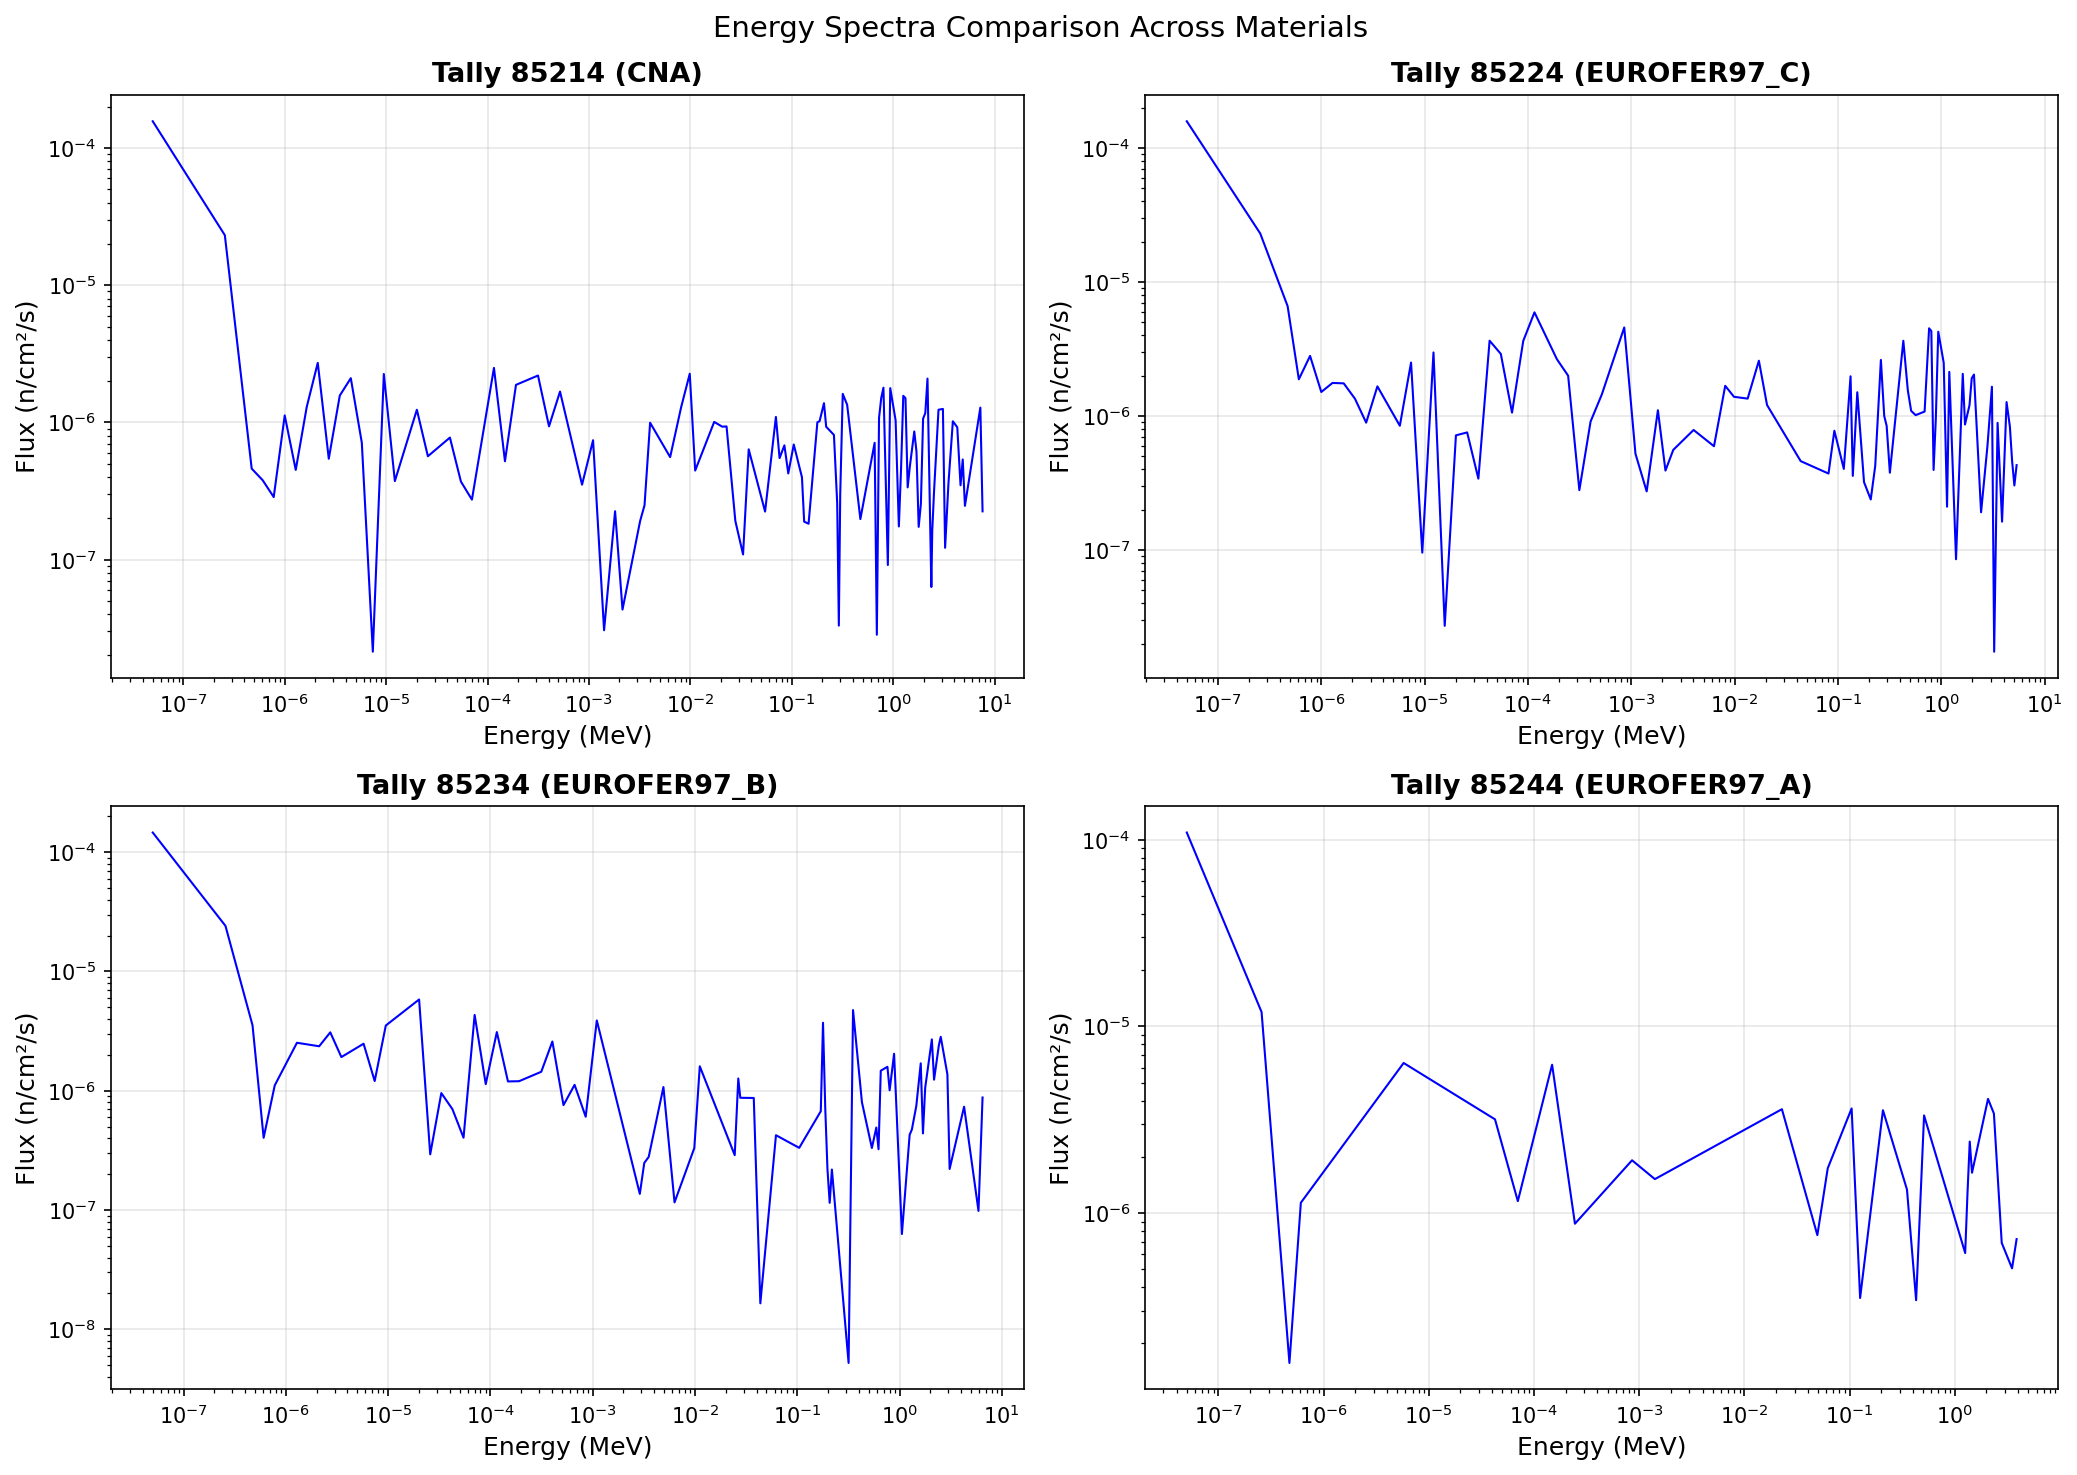

FLUX SUMMARY BY TALLY:
Tally      Material              Mean Flux        Min Flux        Max Flux    Rel. Std Dev
---------------------------------------------------------------------------------------------------------
 85214      CNA                2.583886e-04    1.646031e-04    3.927210e-04        0.178538
 85224      EUROFER97_C        3.057896e-04    1.459729e-04    4.347063e-04        0.212188
 85234      EUROFER97_B        2.655314e-04    1.526901e-04    3.881490e-04        0.202227
 85244      EUROFER97_A        1.787821e-04    5.669817e-05    3.484797e-04        0.322568


In [62]:
# ==============================================================================
# ANALYZE FLUX SPECTRA FROM MESH TALLIES
# ==============================================================================
# Uses flux_mesh_analysis.py for reusable analysis functions.
# ==============================================================================

import h5py
import importlib

# Material names for each tally (excluding SS420)
material_names = {
    'tally_85214': 'CNA',
    'tally_85224': 'EUROFER97_C',
    'tally_85234': 'EUROFER97_B',
    'tally_85244': 'EUROFER97_A'
}

# Import from standalone script (with reload to pick up any fixes)
try:
    import flux_mesh_analysis
    importlib.reload(flux_mesh_analysis)
    from flux_mesh_analysis import (
        analyze_flux_spectrum, analyze_all_mesh_tallies,
        compare_materials_flux, print_flux_summary, plot_flux_spectra
    )
    HAS_FLUX_MESH = True
    print("✓ Loaded flux_mesh_analysis module")
except ImportError as e:
    print(f"⚠ Could not import flux_mesh_analysis: {e}")
    HAS_FLUX_MESH = False
    
    # Fallback: define minimal version
    def analyze_flux_spectrum(h5_file, tally_num):
        """Analyze energy-dependent flux spectrum across voxels for a given tally."""
        with h5py.File(h5_file, 'r') as f:
            mt = f['results']['mesh_tally'][f'mesh_tally_{tally_num}']
            raw_flux = mt['mean'][:]
            flux_groups = raw_flux[:-1]
            total_flux_data = raw_flux[-1]
            n_groups = flux_groups.shape[0]
            flux = flux_groups.reshape(n_groups, -1)
            n_voxels = flux.shape[1]
            total_flux = total_flux_data.flatten()
            mean_spectrum = flux.mean(axis=1)
            try:
                energy_bins = mt['grid_energy'][:]
            except KeyError:
                energy_bins = np.arange(n_groups + 1)
            return {
                'n_groups': n_groups, 'n_voxels': n_voxels,
                'mean_spectrum': mean_spectrum, 'energy_bins': energy_bins,
                'total_flux_per_voxel': total_flux, 'flux_data': flux
            }

# Analyze each tally
tallies = [85214, 85224, 85234, 85244]  # Excluding SS420 (85114)
flux_analysis = {}

print("=" * 80)
print("ANALYZING FLUX SPECTRA FROM MESH TALLIES")
print("=" * 80)
print(f"Analyzing tallies: {tallies}\n")

for tally_num in tallies:
    flux_analysis[tally_num] = analyze_flux_spectrum(H5_FILE, tally_num)
    fa = flux_analysis[tally_num]
    print(f"✓ Tally {tally_num} ({material_names.get(f'tally_{tally_num}', 'unknown')}):")
    print(f"    Energy groups: {fa['n_groups']}")
    print(f"    Voxels: {fa['n_voxels']}")
    print(f"    Mean total flux: {fa['mean_spectrum'].sum():.3e} n/cm²/s")
    print(f"    Flux range across voxels: {fa['total_flux_per_voxel'].min():.3e} - {fa['total_flux_per_voxel'].max():.3e}\n")

print(f"✓ Successfully loaded {len(flux_analysis)} tallies\n")

# Plot energy spectrum comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (tally_num, fa) in enumerate(flux_analysis.items()):
    if idx >= 4:
        break
    ax = axes[idx]
    
    # Use energy bin centers for x-axis
    if len(fa['energy_bins']) > 1:
        e_centers = (fa['energy_bins'][:-1] + fa['energy_bins'][1:]) / 2
    else:
        e_centers = np.arange(fa['n_groups'])
    
    # Plot mean spectrum with flux-per-lethargy normalization
    valid = fa['mean_spectrum'] > 0
    ax.loglog(e_centers[valid], fa['mean_spectrum'][valid], 'b-', lw=1)
    ax.set_xlabel('Energy (MeV)')
    ax.set_ylabel('Flux (n/cm²/s)')
    ax.set_title(f'Tally {tally_num} ({material_names.get(f"tally_{tally_num}", "unknown")})')
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(len(flux_analysis), 4):
    axes[idx].set_visible(False)

plt.suptitle('Energy Spectra Comparison Across Materials', fontsize=14)
plt.tight_layout()
plt.show()

# Print summary using module function if available
if HAS_FLUX_MESH:
    print_flux_summary(flux_analysis, material_names)
else:
    print("=" * 80)
    print("FLUX SUMMARY BY TALLY:")
    print("=" * 80)
    print(f"{'Tally':<10} {'Material':<15} {'Mean Flux':>15} {'Min Flux':>15} {'Max Flux':>15}")
    print("-" * 70)
    for tally_num, fa in flux_analysis.items():
        material = material_names.get(f'tally_{tally_num}', 'unknown')
        mean_total = fa['total_flux_per_voxel'].mean()
        min_total = fa['total_flux_per_voxel'].min()
        max_total = fa['total_flux_per_voxel'].max()
        print(f" {tally_num:<10} {material:<15} {mean_total:>15.6e} {min_total:>15.6e} {max_total:>15.6e}")

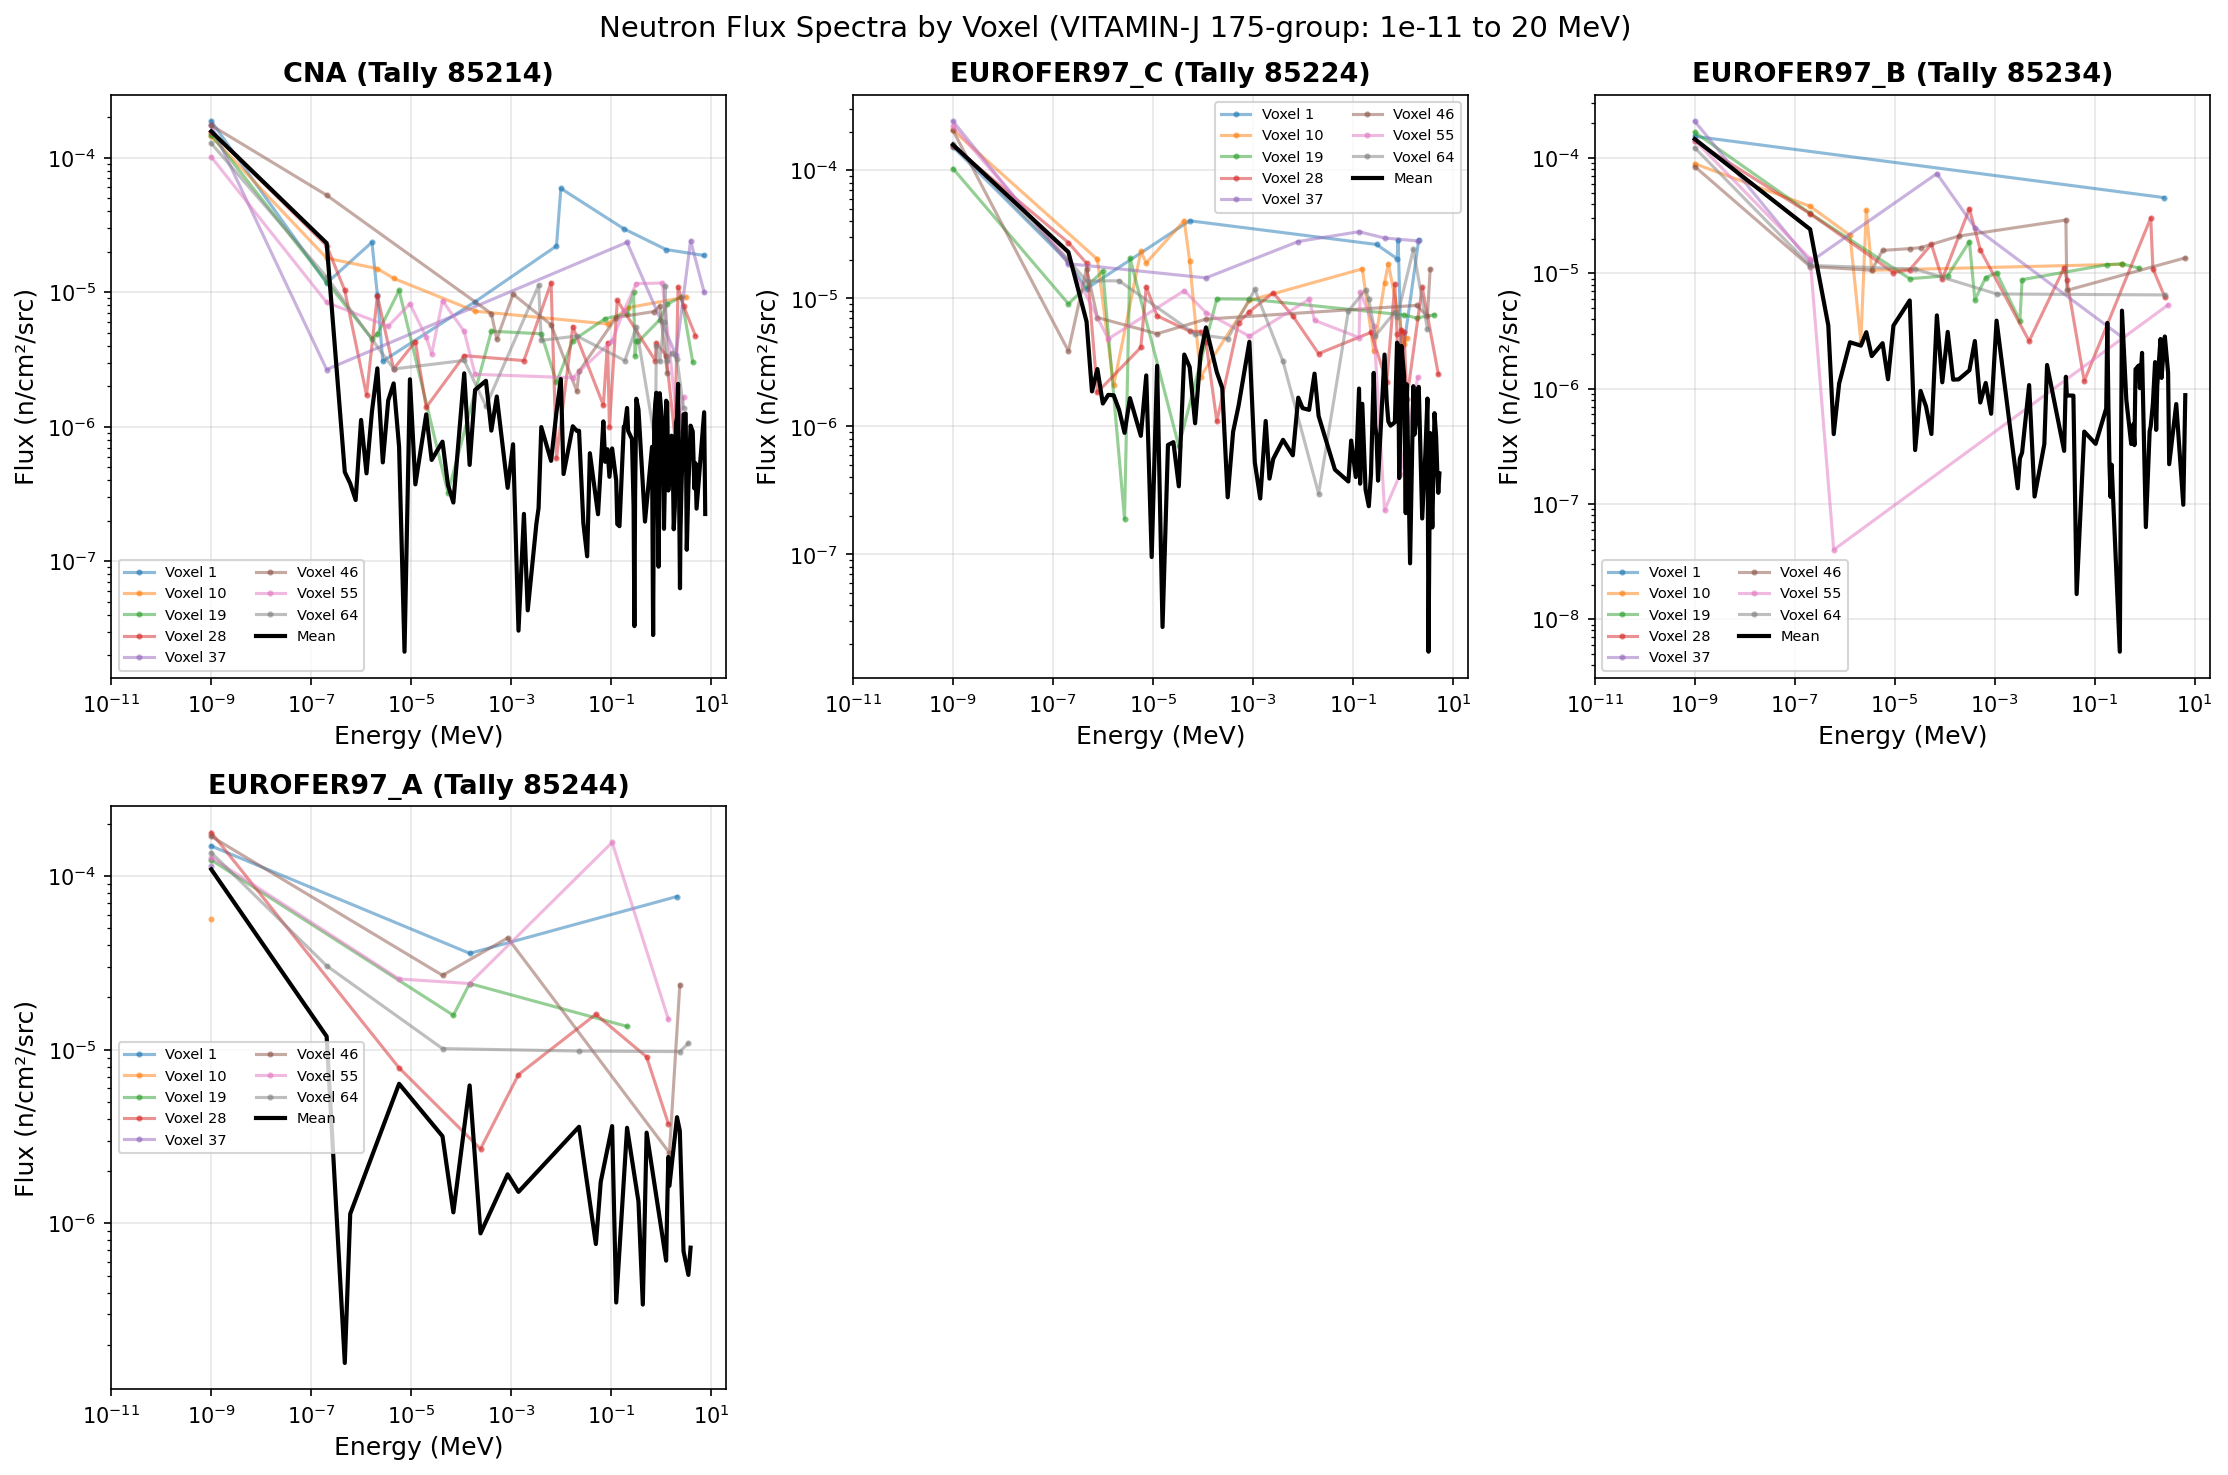

In [63]:
# Plot flux spectra comparing different voxels within each material
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

plot_count = 0
for tally_num, flux_data in flux_analysis.items():
    if plot_count >= 5:
        break
    
    material = material_names.get(f'tally_{tally_num}', 'unknown')
    flux_per_voxel = flux_data['flux_data']  # This is the full flux array: (n_groups, n_voxels)
    energy_bins = flux_data['energy_bins']
    n_voxels = flux_data['n_voxels']
    
    # Energy bin centers (geometric mean) - proper VITAMIN-J structure
    e_centers = np.sqrt(energy_bins[:-1] * energy_bins[1:])
    
    ax = axes[plot_count]
    
    # Plot a subset of voxels (max 8) to avoid clutter
    n_plot = min(8, n_voxels)
    voxel_indices = np.linspace(0, n_voxels-1, n_plot, dtype=int)
    
    for i, v_idx in enumerate(voxel_indices):
        flux = flux_per_voxel[:, v_idx]
        # Only plot non-zero values
        mask = flux > 0
        if mask.any():
            ax.loglog(e_centers[mask], flux[mask], 'o-', alpha=0.5, markersize=2, label=f'Voxel {v_idx+1}')
    
    # Plot mean spectrum
    mean_spectrum = flux_per_voxel.mean(axis=1)
    mask = mean_spectrum > 0
    ax.loglog(e_centers[mask], mean_spectrum[mask], 'k-', linewidth=2, label='Mean')
    
    ax.set_xlabel('Energy (MeV)')
    ax.set_ylabel('Flux (n/cm²/src)')
    ax.set_title(f'{material} (Tally {tally_num})')
    ax.set_xlim(1e-11, 20)
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)
    
    plot_count += 1

# Hide unused subplots
for idx in range(plot_count, 6):
    axes[idx].set_visible(False)

plt.suptitle('Neutron Flux Spectra by Voxel (VITAMIN-J 175-group: 1e-11 to 20 MeV)', fontsize=14)
plt.tight_layout()
plt.show()


FLUX COMPARISON BETWEEN MATERIALS

 Tally    Material  Mean Flux (n/cm²/src)  Min Flux  Max Flux  Spatial Std Dev  Spatial CV (%)
 85214         CNA               0.000258  0.000165  0.000393         0.000046       17.853819
 85224 EUROFER97_C               0.000306  0.000146  0.000435         0.000065       21.218762
 85234 EUROFER97_B               0.000266  0.000153  0.000388         0.000054       20.222723
 85244 EUROFER97_A               0.000179  0.000057  0.000348         0.000058       32.256750


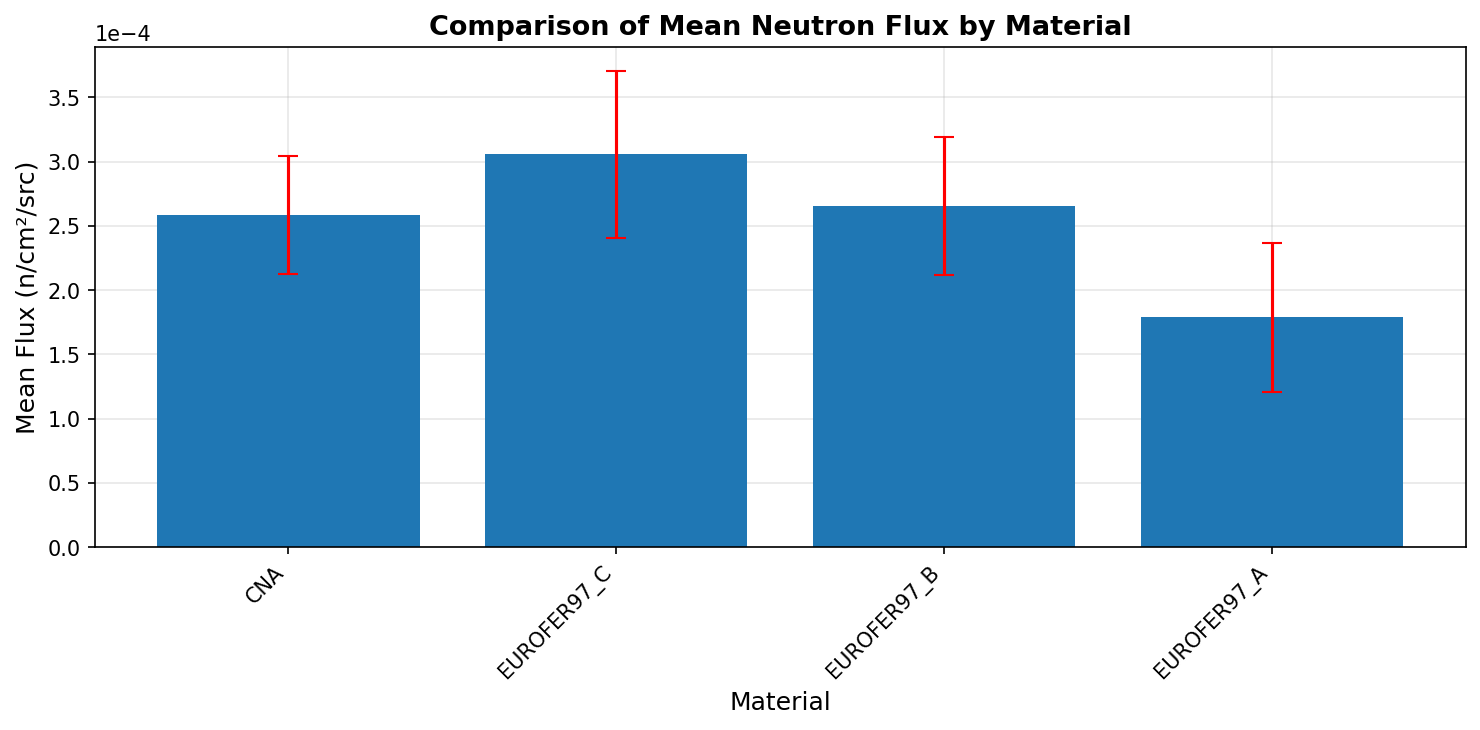

In [64]:
# Compare total flux between materials
print("\n" + "="*80)
print("FLUX COMPARISON BETWEEN MATERIALS")
print("="*80)

flux_comparison = []
for tally_num, flux_data in flux_analysis.items():
    material = material_names.get(f'tally_{tally_num}', 'unknown')
    total_flux_per_voxel = flux_data['total_flux_per_voxel']
    mean_total = total_flux_per_voxel.mean()
    std_total = total_flux_per_voxel.std()
    
    flux_comparison.append({
        'Tally': tally_num,
        'Material': material,
        'Mean Flux (n/cm²/src)': mean_total,
        'Min Flux': total_flux_per_voxel.min(),
        'Max Flux': total_flux_per_voxel.max(),
        'Spatial Std Dev': std_total,
        'Spatial CV (%)': std_total/mean_total*100 if mean_total > 0 else 0,
    })

flux_df = pd.DataFrame(flux_comparison)
print("\n" + flux_df.to_string(index=False))

# Bar chart of mean flux
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(flux_df['Material'], flux_df['Mean Flux (n/cm²/src)'])
ax.set_ylabel('Mean Flux (n/cm²/src)')
ax.set_xlabel('Material')
ax.set_title('Comparison of Mean Neutron Flux by Material')
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# Add error bars showing spatial variation
ax.errorbar(range(len(flux_df)), flux_df['Mean Flux (n/cm²/src)'], 
            yerr=flux_df['Spatial Std Dev'], fmt='none', color='red', capsize=5)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Step 3: Post-Process ALARA Output

Run the post-processing script to generate CSV files with voxel-averaged results and uncertainties.

In [65]:
# Run post-processing on all tally directories
print("Running post-processing on all tallies...")

# Use scripts directory
postprocess_script = str(SCRIPTS_DIR / 'alara_multizone_postprocess.py') if 'SCRIPTS_DIR' in dir() else 'scripts/alara_multizone_postprocess.py'
output_dir = str(OUTPUT_DIR) if 'OUTPUT_DIR' in dir() else 'alara_output'

cmd = [
    sys.executable, postprocess_script,
    '--input', output_dir,
    '--output', output_dir
]

result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)

Running post-processing on all tallies...
Found 5 tally directories

Processing tally_85114
  Parsing ALARA output: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/tally_85114/tally_85114_multizone.out
  Found 64 voxels
  Cooling times: ['shutdown', '5m', '2h', '26h', '4d', '19.0833d', '34.0833d']
  Material: unknown

  Computing voxel averages with uncertainty...
  Processed 144 isotopes

  Exporting averaged CSV files...
    Written: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/tally_85114_Bq_per_cm3.csv (48 isotopes)
    Written: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/tally_85114_atoms_per_cm3.csv (103 isotopes)
    Written: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/tally_85114_W_per_cm3.csv (46 isotopes)
    Written: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/tally_85114_g_per_cm3.csv (1

## Step 4: Load and Explore Results

Load the CSV files and explore the activation results.

In [66]:
# Load all activity CSV files
# CSV files are named: tally_XXXXX_Bq_per_cm3.csv
activity_data = {}

# Material names for each tally (excluding SS420)
material_names = {
    'tally_85214': 'CNA',
    'tally_85224': 'EUROFER97_C',
    'tally_85234': 'EUROFER97_B',
    'tally_85244': 'EUROFER97_A'
}

for csv_file in sorted(glob.glob(os.path.join(OUTPUT_DIR, 'tally_*_Bq_per_cm3.csv'))):
    tally_name = os.path.basename(csv_file).replace('_Bq_per_cm3.csv', '')
    # Skip SS420 (tally_85114)
    if tally_name == 'tally_85114':
        continue
    material = material_names.get(tally_name, 'unknown')
    df = pd.read_csv(csv_file)
    activity_data[tally_name] = {'material': material, 'data': df}
    print(f"\n{tally_name} ({material}): {len(df)} isotopes")
    print(df.head(5))

print(f"\nLoaded {len(activity_data)} activity datasets")


tally_85214 (CNA): 172 isotopes
   isotope  mean_shutdown  sem_shutdown  rel_unc_shutdown       mean_5m  \
0  ag-109m       0.028862  4.808202e-18      1.665928e-16      0.028862   
1    al-26       0.000222  2.731933e-20      1.232877e-16      0.000222   
2    as-72       0.002122  5.463865e-20      2.574987e-17      0.002117   
3    as-73       4.879200  3.356999e-16      6.880224e-17      4.879000   
4    as-74   46114.000000  0.000000e+00      0.000000e+00  46108.000000   

         sem_5m    rel_unc_5m       mean_2h        sem_2h    rel_unc_2h  ...  \
0  4.808202e-18  1.665928e-16      0.028859  2.185546e-18  7.573187e-17  ...   
1  2.731933e-20  1.232877e-16      0.000222  2.731933e-20  1.232877e-16  ...   
2  1.092773e-19  5.161407e-17      0.002012  2.185546e-19  1.086418e-16  ...   
3  1.119000e-16  2.293502e-17      4.875700  4.475999e-16  9.180217e-17  ...   
4  0.000000e+00  0.000000e+00  45964.000000  0.000000e+00  0.000000e+00  ...   

    rel_unc_26h       mean_4d      

## Step 5: Identify Key Activation Products

Find the most significant activation products at experimental measurement times (300s, 2h, 24h, 4d, 15d).

In [67]:
# Function to get top isotopes by activity at first valid experimental time
# Valid experimental times: 300s, 2h, 24h, 4d (after 3s irradiation), 15d (after 2h irradiation)
# NOT shutdown - that's not a real measurement time

VALID_MEASUREMENT_TIMES = ['300s', '2h', '24h', '4d', '15d']
VALID_MEASUREMENT_SECONDS = [300, 7200, 86400, 345600, 1296000]

def get_top_isotopes(df, n=10, time_key='300s'):
    """Get top N isotopes by activity at a specified measurement time.
    
    Args:
        df: DataFrame with mean_* columns
        n: Number of top isotopes to return
        time_key: Which measurement time to use ('300s', '2h', '24h', '4d', '15d')
    """
    mean_cols = [c for c in df.columns if c.startswith('mean_')]
    if not mean_cols:
        return pd.DataFrame()
    
    # Find the column matching the requested time key
    # Exclude shutdown (first column at time=0)
    target_col = None
    for col in mean_cols:
        # Skip shutdown columns
        if 'shutdown' in col.lower():
            continue
        # Check if column matches the time key (e.g., 'mean_300s' or 'mean_300 s')
        col_lower = col.lower().replace(' ', '')
        if time_key.lower().replace(' ', '') in col_lower:
            target_col = col
            break
    
    # If no match, use first non-shutdown column
    if target_col is None:
        for col in mean_cols:
            if 'shutdown' not in col.lower():
                target_col = col
                break
    
    # Fall back to second column if first is shutdown
    if target_col is None and len(mean_cols) > 1:
        target_col = mean_cols[1]
    elif target_col is None:
        target_col = mean_cols[0]  # Last resort
    
    top = df.nlargest(n, target_col)[['isotope', target_col]].copy()
    top.columns = ['Isotope', 'Activity (Bq/cm³)']
    return top

# Show top isotopes for each tally at first measurement time (300s after 3s irradiation)
for tally_name, data in activity_data.items():
    material = data['material']
    df = data['data']
    
    print(f"\n{'='*60}")
    print(f"TOP ACTIVATION PRODUCTS: {tally_name} ({material})")
    print(f"At first measurement time (300s after irradiation)")
    print(f"{'='*60}")
    
    top = get_top_isotopes(df, 10, time_key='300s')
    if not top.empty:
        print(top.to_string(index=False))


TOP ACTIVATION PRODUCTS: tally_85214 (CNA)
At first measurement time (300s after irradiation)
Isotope  Activity (Bq/cm³)
  total        197200000.0
  w-187         95438000.0
  cr-51         41586000.0
  mn-54         25821000.0
 ta-180         10774000.0
  fe-55          9915400.0
  w-185          5443300.0
 ta-182          2941800.0
  w-181          2225100.0
  sc-48           838940.0

TOP ACTIVATION PRODUCTS: tally_85224 (EUROFER97_C)
At first measurement time (300s after irradiation)
Isotope  Activity (Bq/cm³)
  total        193680000.0
  w-187         80743000.0
  cr-51         42671000.0
  mn-54         25531000.0
 ta-180         19886000.0
  fe-55          9886200.0
 ta-182          5429400.0
  w-185          4605100.0
  w-181          1882500.0
   p-32           514080.0

TOP ACTIVATION PRODUCTS: tally_85234 (EUROFER97_B)
At first measurement time (300s after irradiation)
Isotope  Activity (Bq/cm³)
  total        193420000.0
  w-187         80743000.0
  cr-51         42753000

## Step 5b: Uncertainty Analysis

Analyze the uncertainties in the voxel-averaged activation results.

In [68]:
# Analyze uncertainties in the results
print("="*80)
print("UNCERTAINTY ANALYSIS")
print("="*80)
print("\nThe uncertainties represent the standard error of the mean (SEM)")
print("across all voxels in each mesh tally. This captures spatial variation.")
print()

for tally_name, data in activity_data.items():
    material = data['material']
    df = data['data']
    
    print(f"\n{'-'*60}")
    print(f"{material} ({tally_name})")
    print(f"{'-'*60}")
    
    # Get column groups
    mean_cols = [c for c in df.columns if c.startswith('mean_')]
    sem_cols = [c for c in df.columns if c.startswith('sem_')]
    rel_unc_cols = [c for c in df.columns if c.startswith('rel_unc_')]
    
    for i, (mean_col, sem_col, rel_col) in enumerate(zip(mean_cols, sem_cols, rel_unc_cols)):
        time_label = mean_col.replace('mean_', '')
        
        # Get top 5 isotopes at this time
        top_iso = df.nlargest(5, mean_col)
        
        print(f"\n  {time_label}:")
        print(f"  {'Isotope':<12} {'Activity (Bq/cm³)':<18} {'± SEM':<15} {'Rel. Unc.':<10}")
        print(f"  {'-'*55}")
        
        for _, row in top_iso.iterrows():
            iso = row['isotope']
            mean_val = row[mean_col]
            sem_val = row[sem_col] if sem_col in row else 0
            rel_val = row[rel_col] if rel_col in row else 0
            
            if mean_val > 1e-30:
                print(f"  {iso:<12} {mean_val:<18.4e} {sem_val:<15.4e} {rel_val*100:<10.1f}%")

UNCERTAINTY ANALYSIS

The uncertainties represent the standard error of the mean (SEM)
across all voxels in each mesh tally. This captures spatial variation.


------------------------------------------------------------
CNA (tally_85214)
------------------------------------------------------------

  shutdown:
  Isotope      Activity (Bq/cm³)  ± SEM           Rel. Unc. 
  -------------------------------------------------------
  total        1.9752e+08         0.0000e+00      0.0       %
  w-187        9.5670e+07         0.0000e+00      0.0       %
  cr-51        4.1589e+07         0.0000e+00      0.0       %
  mn-54        2.5822e+07         0.0000e+00      0.0       %
  ta-180       1.0851e+07         0.0000e+00      0.0       %

  5m:
  Isotope      Activity (Bq/cm³)  ± SEM           Rel. Unc. 
  -------------------------------------------------------
  total        1.9720e+08         0.0000e+00      0.0       %
  w-187        9.5438e+07         0.0000e+00      0.0       %
  cr-51 

## Step 6: Visualize Activity Decay

Plot how activity changes with cooling time for key isotopes.

PLOTTING ACTIVITY DECAY CURVES WITH ISOTOPE ANNOTATIONS

Processing: CNA
  ✓ Saved: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/decay_curves/CNA_decay_curves.png


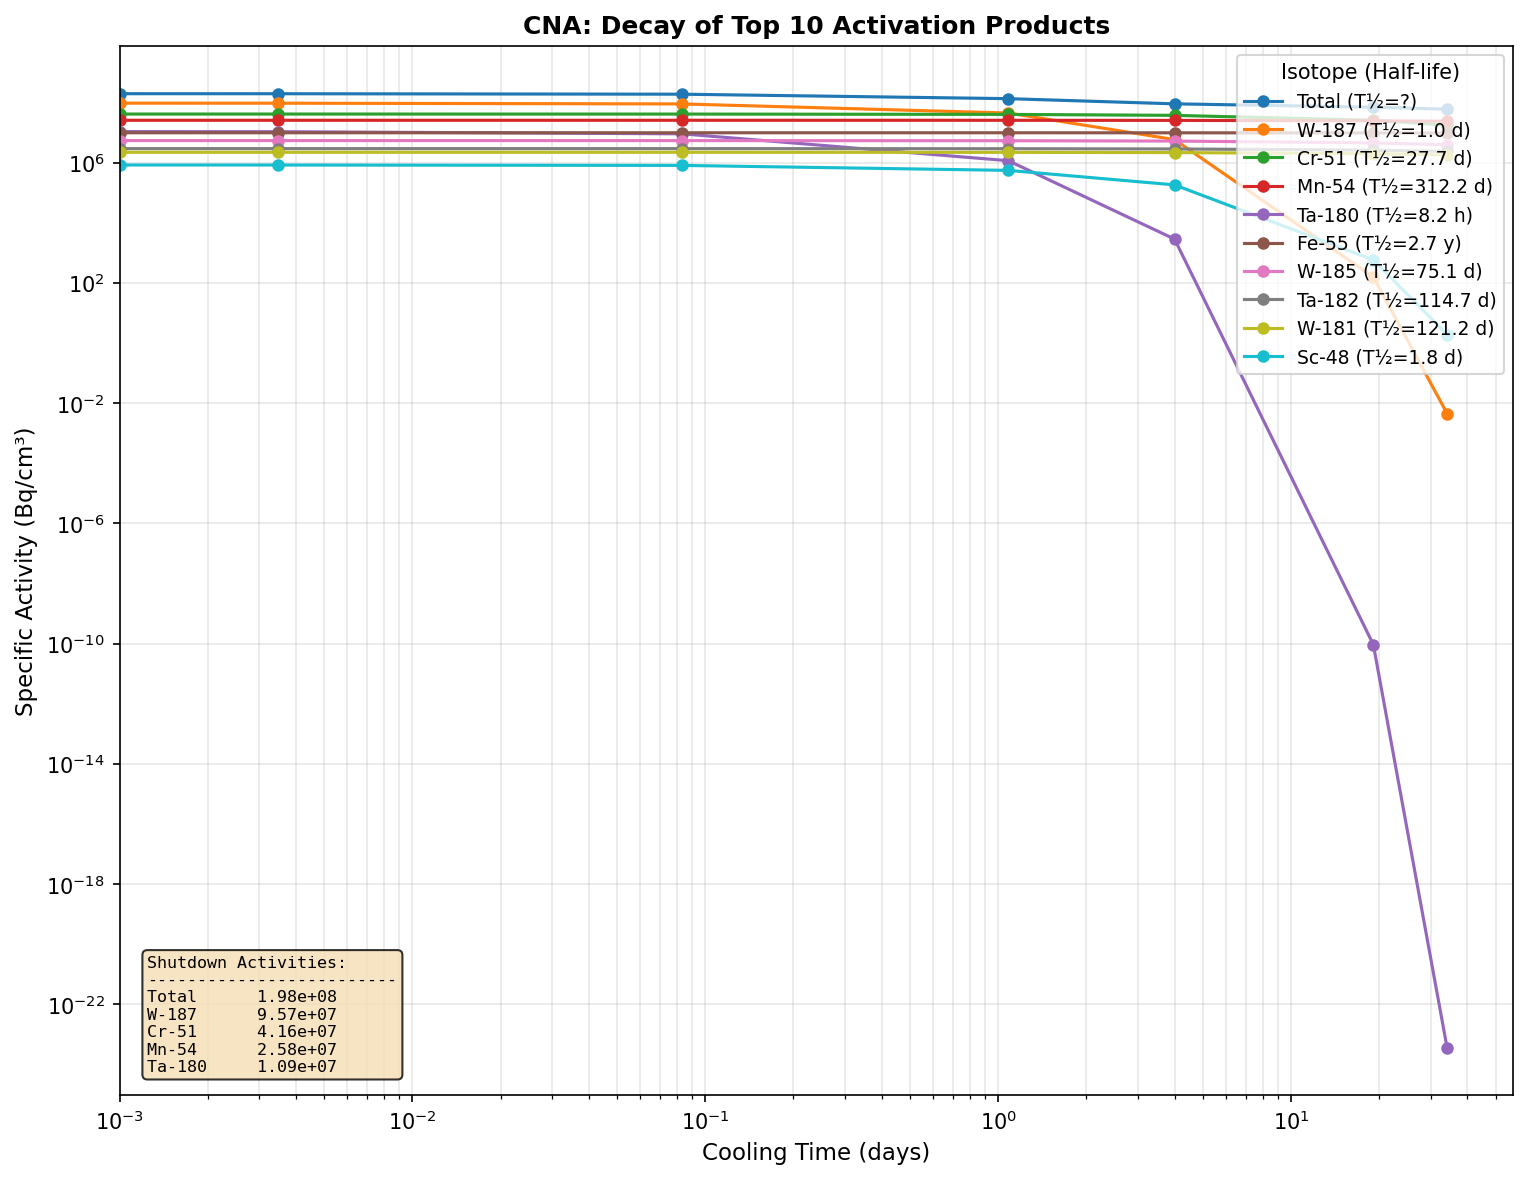


Processing: EUROFER97_C
  ✓ Saved: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/decay_curves/EUROFER97_C_decay_curves.png


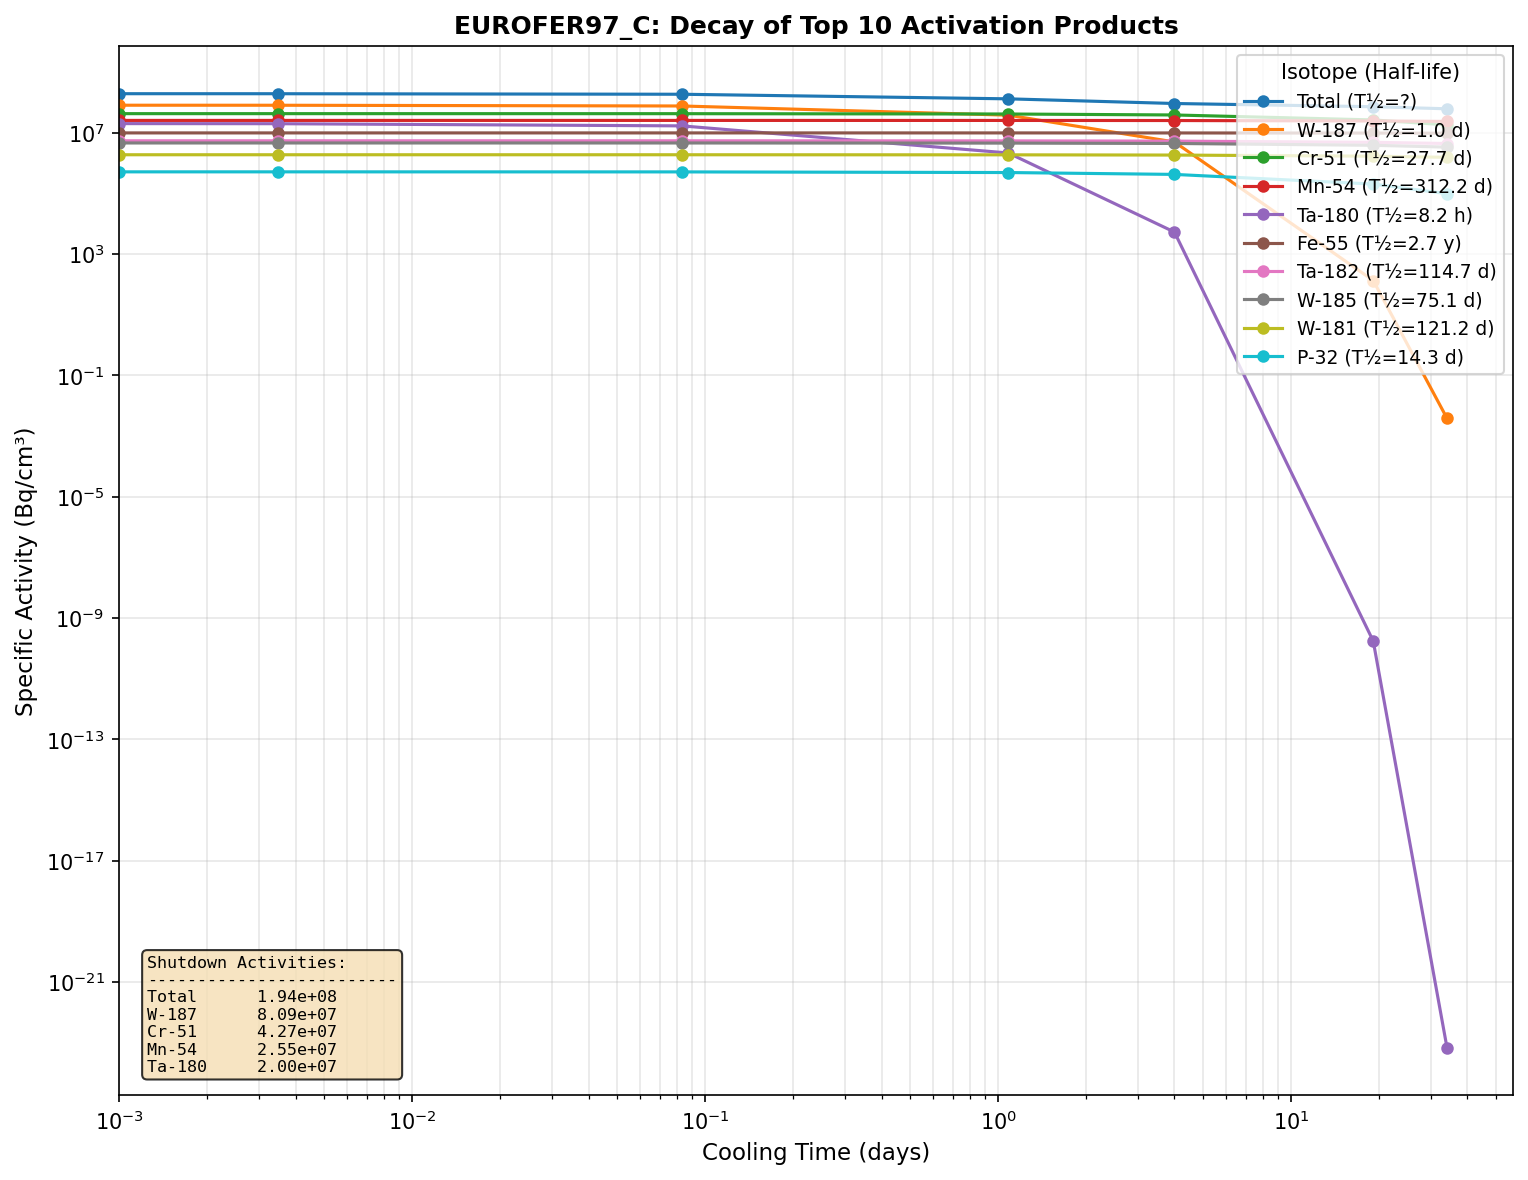


Processing: EUROFER97_B
  ✓ Saved: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/decay_curves/EUROFER97_B_decay_curves.png


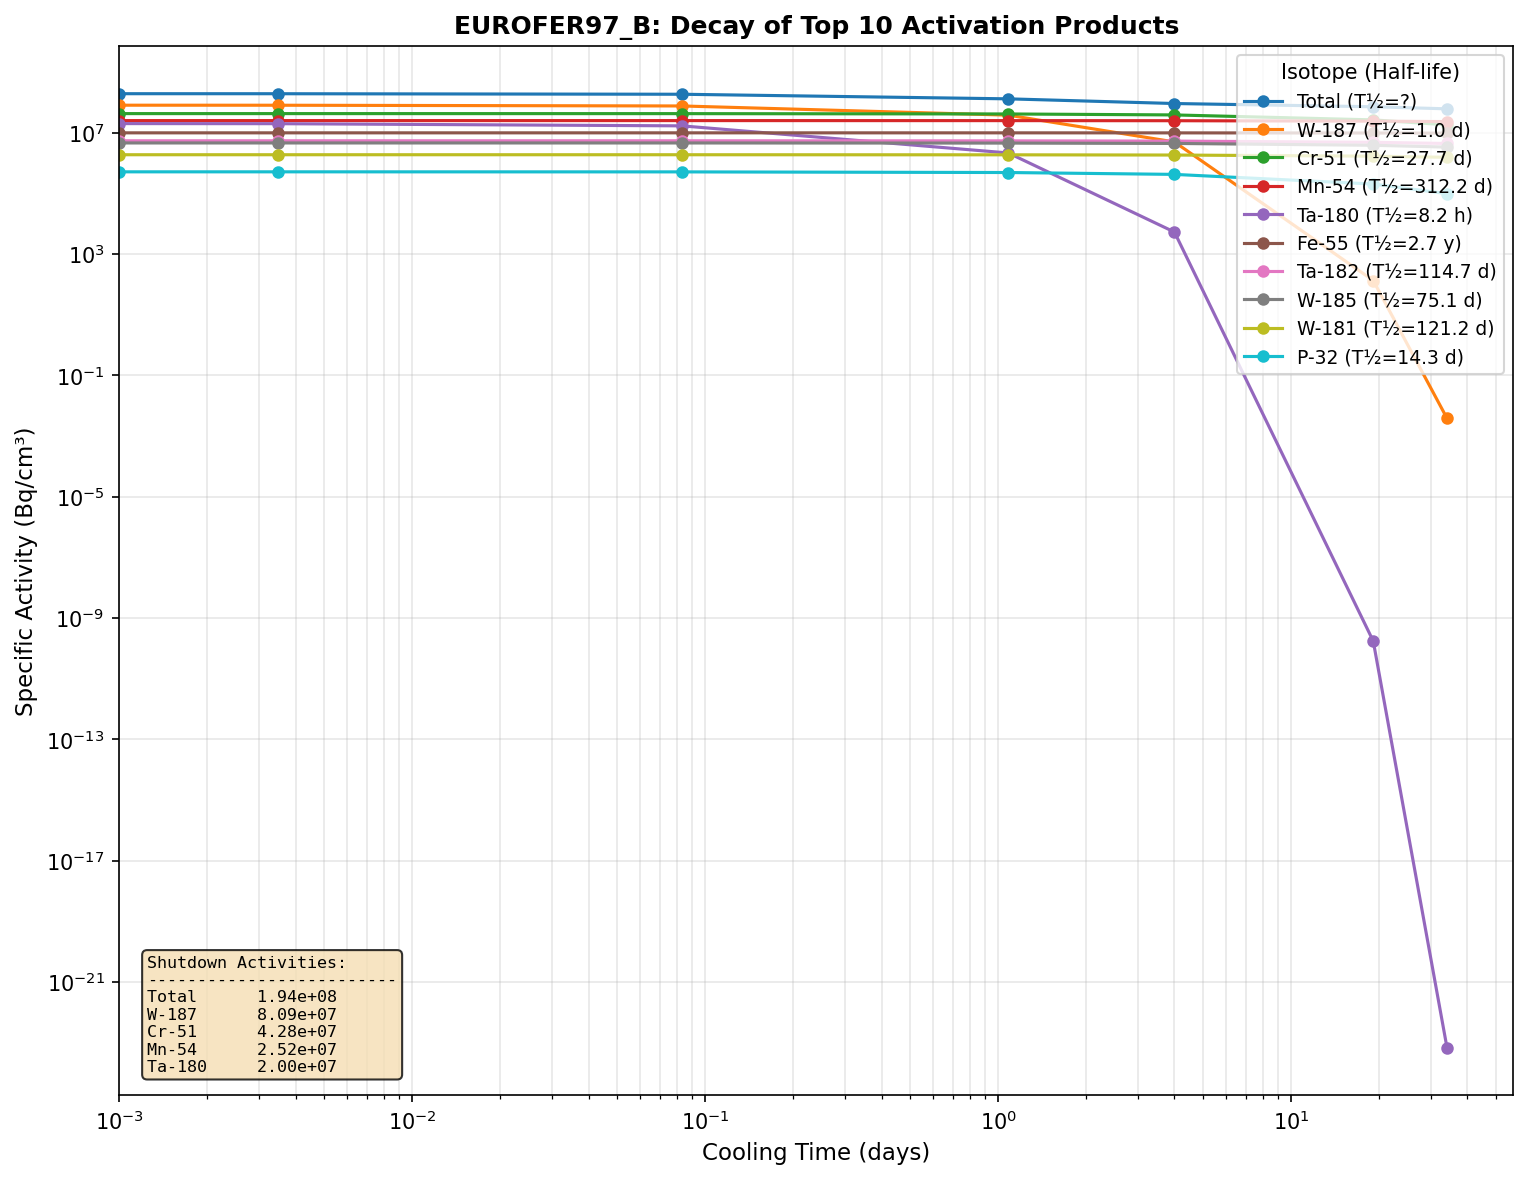


Processing: EUROFER97_A
  ✓ Saved: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/decay_curves/EUROFER97_A_decay_curves.png


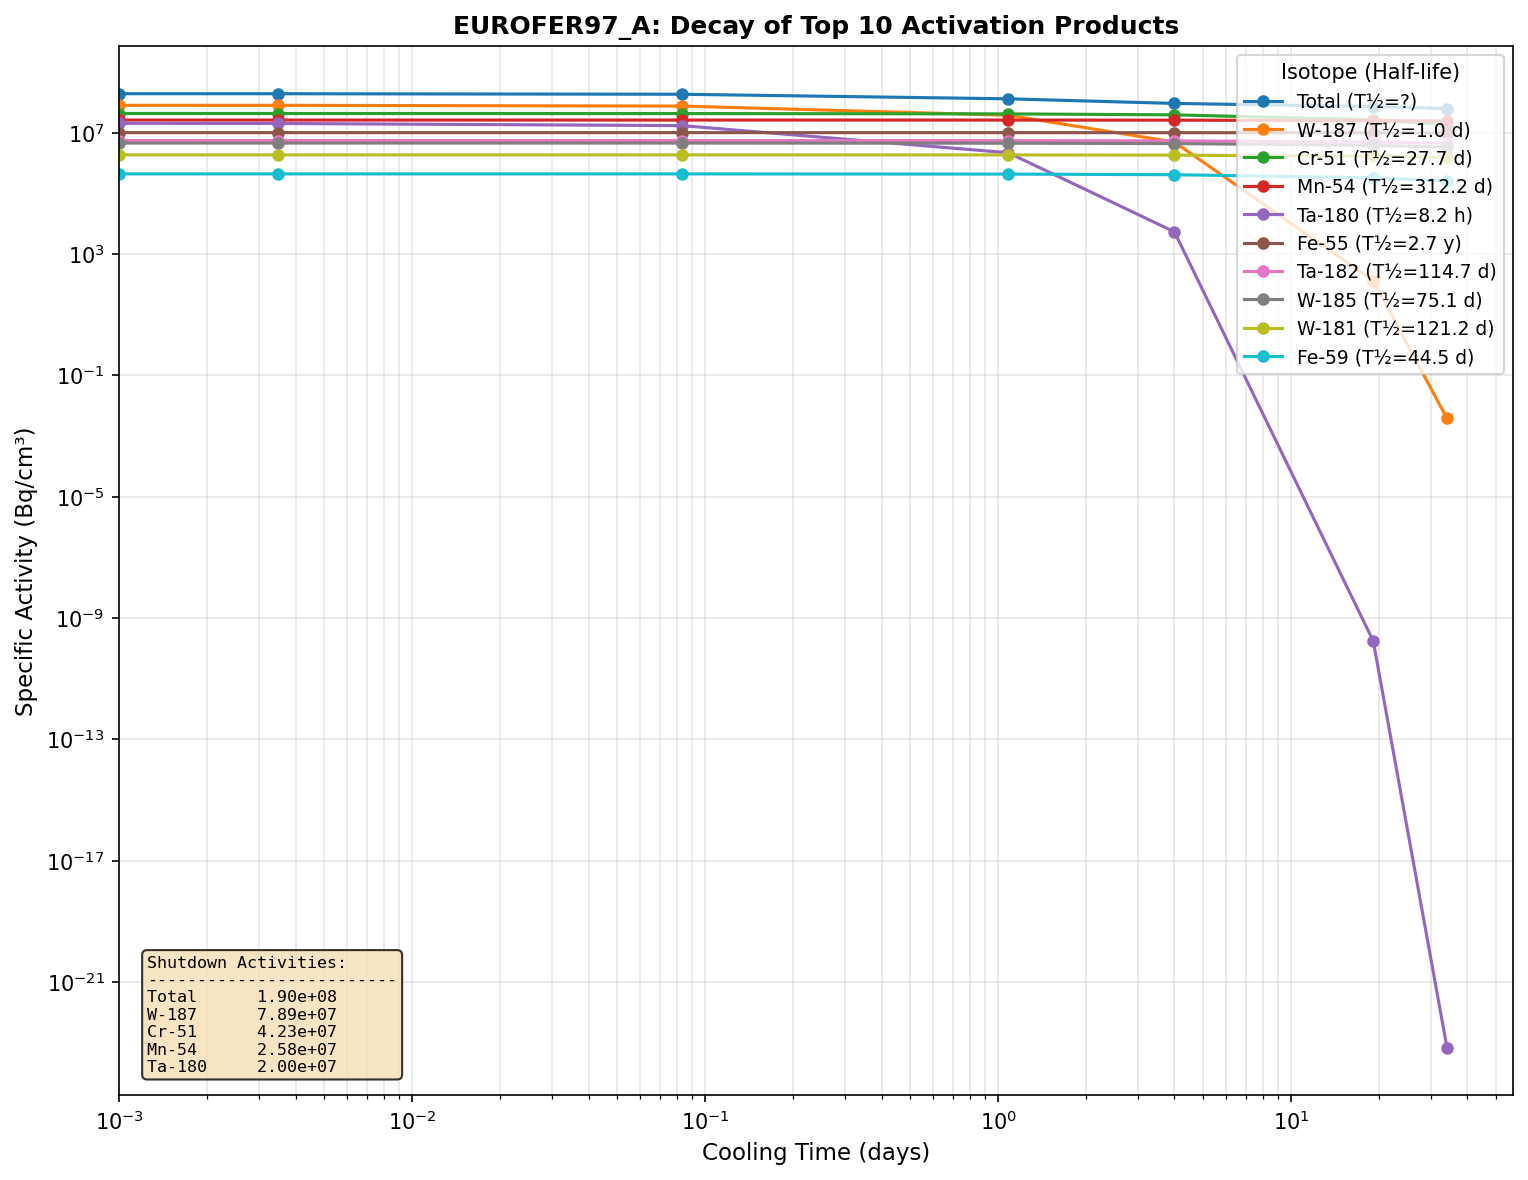


All decay curve plots saved to: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/decay_curves


In [69]:
# ==============================================================================
# ACTIVITY DECAY CURVES WITH HALF-LIFE ANNOTATIONS
# ==============================================================================
# Plots decay curves for each material with isotope-specific annotations.
# Saves plots to alara_output/decay_curves/
# ==============================================================================

from isotope_utils import get_half_life_days, format_iso_pretty, get_half_life_info, format_half_life
import nuclear_data

print("=" * 80)
print("PLOTTING ACTIVITY DECAY CURVES WITH ISOTOPE ANNOTATIONS")
print("=" * 80)

decay_curve_dir = Path(OUTPUT_DIR) / 'decay_curves'
decay_curve_dir.mkdir(parents=True, exist_ok=True)

# Check if adf exists (loaded from alara_output_processing)
if 'adf' in globals() and adf is not None:
    # Get unique materials
    materials = [m for m in adf['run_lbl'].unique() if m != 'tally_85114']
    
    for material in materials:
        print(f"\nProcessing: {material}")
        
        # Filter for this material's specific activity
        filtered = adf.filter_rows({
            'run_lbl': material,
            'variable': adf.VARIABLE_ENUM['Specific Activity']
        })
        
        # Pivot to get isotopes vs time
        piv = filtered.pivot_table(index='nuclide', columns='time', values='value', aggfunc='first')
        
        # Get times (excluding shutdown for decay curves)
        all_times = sorted([t for t in piv.columns if isinstance(t, (int, float))])
        decay_times = [t for t in all_times if t > 0]
        
        if not decay_times or 0 not in piv.columns:
            print(f"  ⚠ Insufficient time data for {material}")
            continue
        
        # Get top 10 isotopes at shutdown
        top10 = piv.nlargest(10, 0).index.tolist()
        
        # Create figure with two panels: decay curves and annotation table
        fig = plt.figure(figsize=(14, 8))
        gs = fig.add_gridspec(1, 5, width_ratios=[4, 1, 0.1, 0.1, 0.1])
        ax = fig.add_subplot(gs[0, 0])
        
        # Color palette
        colors = plt.cm.tab10(np.linspace(0, 1, len(top10)))
        
        # Plot decay curves
        isotope_info = []
        for i, iso in enumerate(top10):
            if iso not in piv.index:
                continue
            
            activities = []
            times = []
            for t in [0] + decay_times:
                if t in piv.columns:
                    val = piv.loc[iso, t]
                    if pd.notna(val) and val > 0:
                        activities.append(val)
                        times.append(t / 86400 if t > 0 else 0.001)  # Convert to days, min for log
            
            if len(activities) > 1:
                ax.semilogy(times, activities, 'o-', color=colors[i], 
                           label=format_iso_pretty(iso), linewidth=1.5, markersize=5)
                
                # Get half-life info
                hl_days, modes = get_half_life_info(iso)
                shutdown_act = activities[0] if activities else 0
                isotope_info.append({
                    'isotope': format_iso_pretty(iso),
                    'half_life': format_half_life(hl_days),
                    'shutdown_Bq_cm3': f"{shutdown_act:.2e}",
                    'color': colors[i]
                })
        
        ax.set_xlabel('Cooling Time (days)', fontsize=11)
        ax.set_ylabel('Specific Activity (Bq/cm³)', fontsize=11)
        ax.set_title(f'{material}: Decay of Top 10 Activation Products', fontsize=12, fontweight='bold')
        ax.set_xscale('log')
        ax.grid(True, alpha=0.3, which='both')
        ax.set_xlim(left=0.001)
        
        # Add legend with half-life annotations
        legend_labels = []
        for info in isotope_info:
            legend_labels.append(f"{info['isotope']} (T½={info['half_life']})")
        
        # Custom legend
        ax.legend(legend_labels, loc='upper right', fontsize=9, 
                 title='Isotope (Half-life)', title_fontsize=10)
        
        # Add annotation box with shutdown activities
        textstr = "Shutdown Activities:\n" + "-" * 25
        for info in isotope_info[:5]:  # Top 5 only
            textstr += f"\n{info['isotope']:10s} {info['shutdown_Bq_cm3']}"
        
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
        ax.text(0.02, 0.02, textstr, transform=ax.transAxes, fontsize=8,
               verticalalignment='bottom', fontfamily='monospace', bbox=props)
        
        plt.tight_layout()
        
        # Save plot
        save_path = decay_curve_dir / f'{material}_decay_curves.png'
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  ✓ Saved: {save_path}")
        plt.show()
    
    print(f"\n{'=' * 60}")
    print(f"All decay curve plots saved to: {decay_curve_dir}")

else:
    print("⚠ ALARADFrame (adf) not available - run ALARA data loading cells first")

BATEMAN EQUATION DECAY CURVES - CORRECTED TIMELINE

IRRADIATION TIMELINE (t=0 = start of first irradiation):
  1st irrad:   t = 0-3s (3 seconds)
  Cooling:     t = 3-3600s (60 minutes)
  2nd irrad:   t = 3600-10800s (2 hours)

Experimental isotopes: 8 - ['al-28', 'cr-51', 'fe-59', 'mn-54', 'mn-56', 'ta-182', 'v-52', 'w-187']
ALARA-predicted isotopes: 0

Using experimental data from: EUROFER97_A

CORRECTED MEASUREMENT TIMELINE:
  300s: 300s after 3s irrad → abs_t = 303s (0.00 days)
  24h: 86400s after 3s irrad → abs_t = 86403s (1.00 days)
  4d: 345600s after 3s irrad → abs_t = 345603s (4.00 days)
  15d: 1296000s after 2hr irrad → abs_t = 1306800s (15.12 days)

Collected experimental points for 8 isotopes:
  W-187: 4 points
  Mn-56: 2 points
  V-52: 1 points
  Al-28: 1 points
  Cr-51: 3 points
  Fe-59: 2 points
  Ta-182: 1 points
  Mn-54: 1 points

Isotope categories by half-life (including ALARA predictions):
  Short-lived (T½ < 1hr):  2 isotopes
  Medium-lived (1hr-10d):  2 isotopes
  

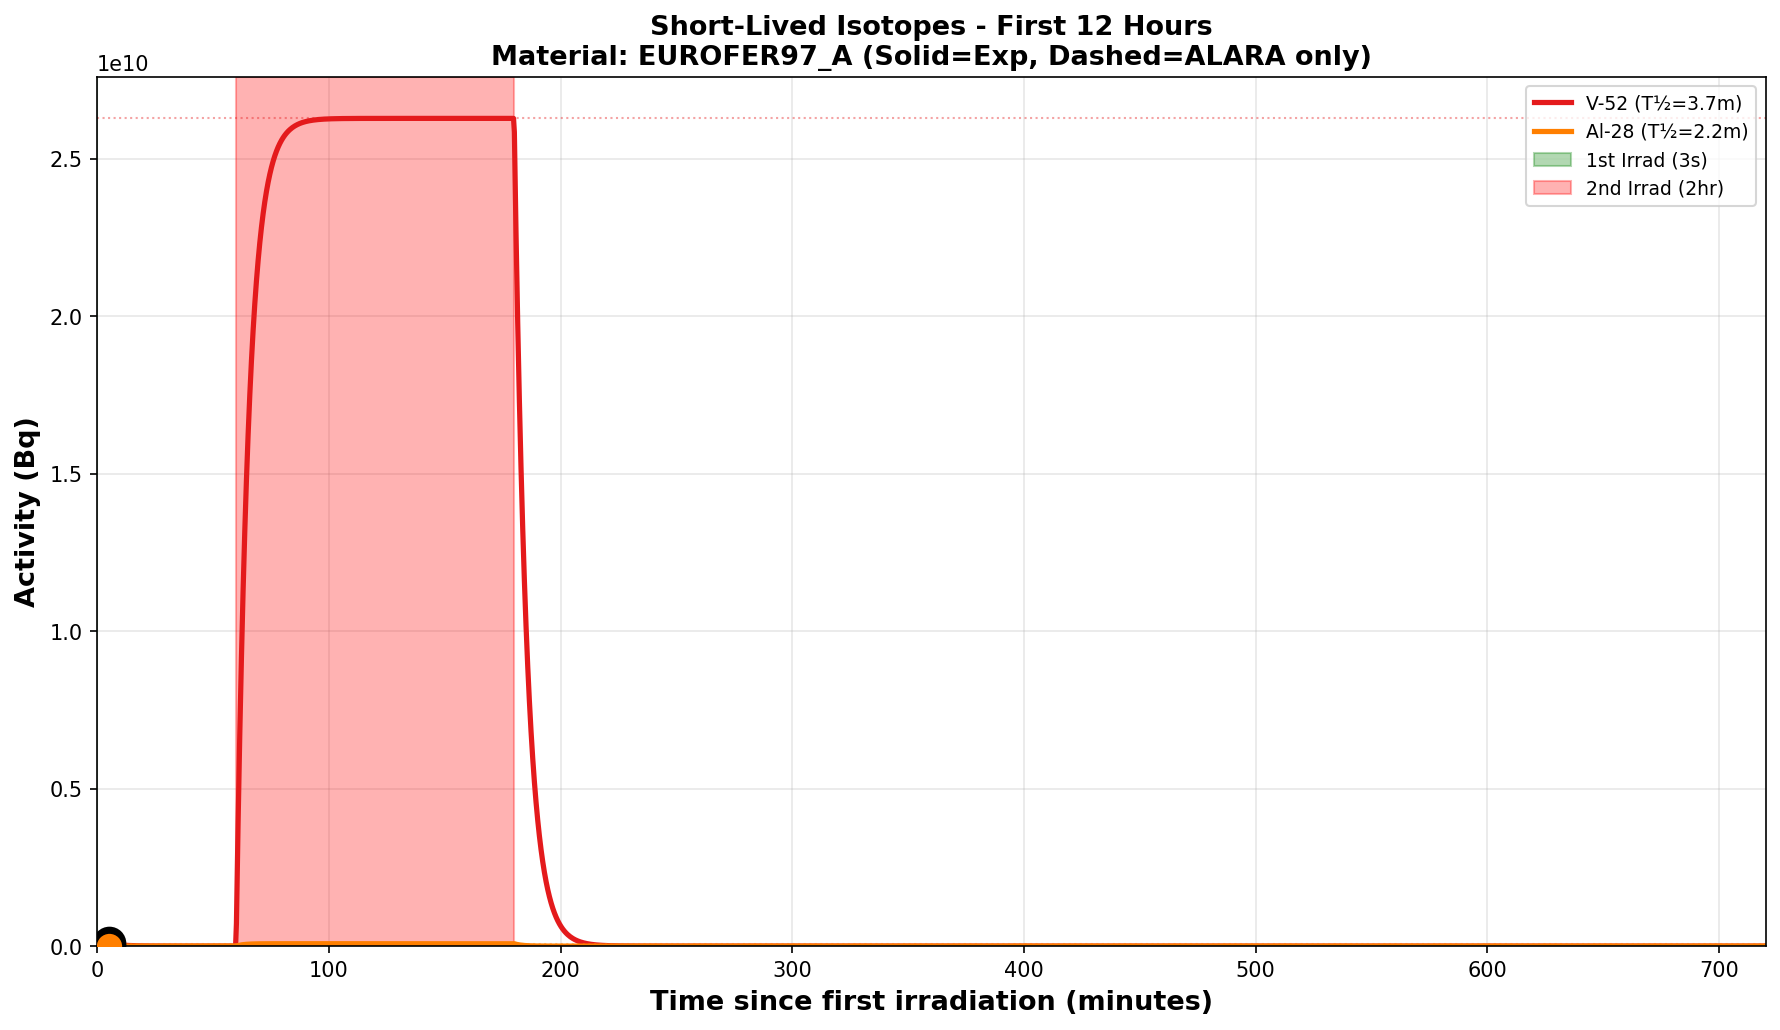


────────────────────────────────────────────────────────────
PLOT 2: First 5 Days - Medium-Lived Isotopes
────────────────────────────────────────────────────────────
  W-187: exp point at 0.00 d = 2.76e+04 Bq
  W-187: exp point at 1.00 d = 1.92e+04 Bq
  W-187: exp point at 4.00 d = 2.59e+03 Bq
  Mn-56: exp point at 0.00 d = 5.89e+05 Bq
  Mn-56: exp point at 1.00 d = 6.84e+02 Bq
✓ Saved: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/decay_curves/bateman_medium_term.png


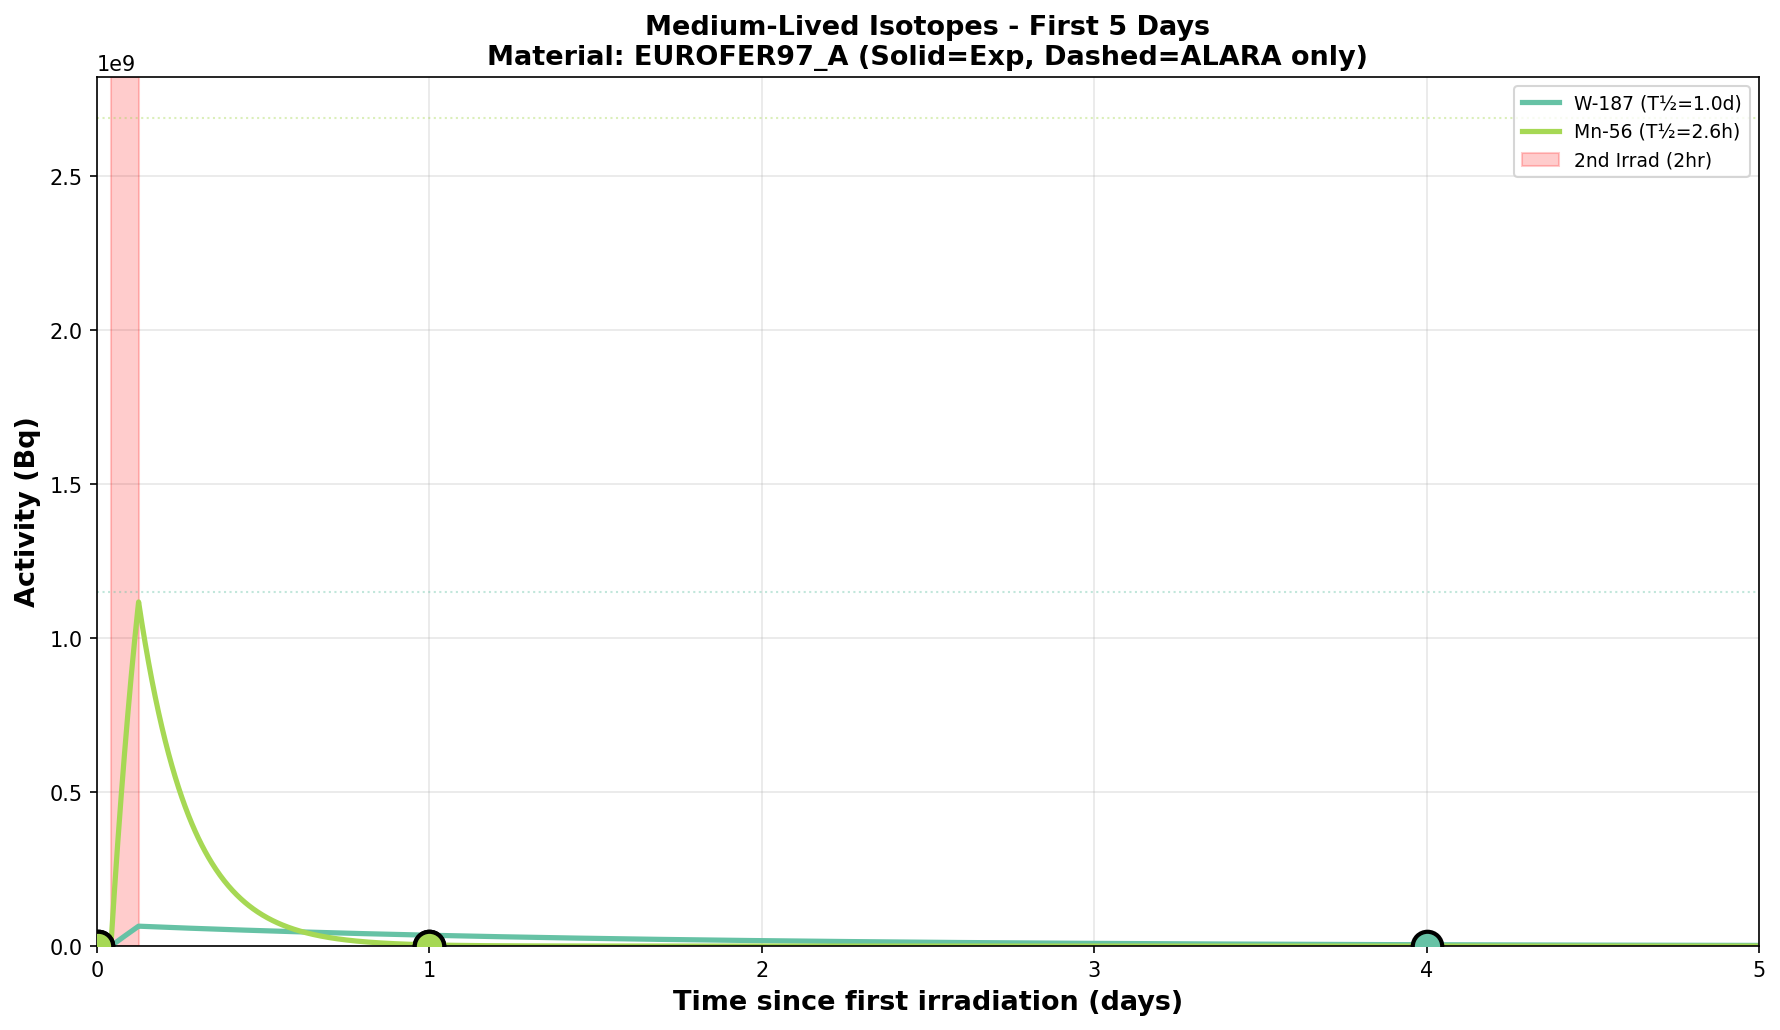


────────────────────────────────────────────────────────────
PLOT 3: Full 20 Days - Long-Lived Isotopes
────────────────────────────────────────────────────────────
  Mn-54: exp point at 15.12 d = 2.01e+04 Bq
  Fe-59: exp point at 4.00 d = 0.00e+00 Bq
  Fe-59: exp point at 15.12 d = 3.35e+05 Bq
  Ta-182: exp point at 15.12 d = 7.37e+05 Bq
  Cr-51: exp point at 1.00 d = 1.40e+03 Bq
  Cr-51: exp point at 4.00 d = 2.09e+03 Bq
  Cr-51: exp point at 15.12 d = 6.84e+06 Bq
  W-187: exp point at 0.00 d = 2.76e+04 Bq
  W-187: exp point at 1.00 d = 1.92e+04 Bq
  W-187: exp point at 4.00 d = 2.59e+03 Bq
  W-187: exp point at 15.12 d = 6.73e+03 Bq
✓ Saved: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/decay_curves/bateman_long_term.png


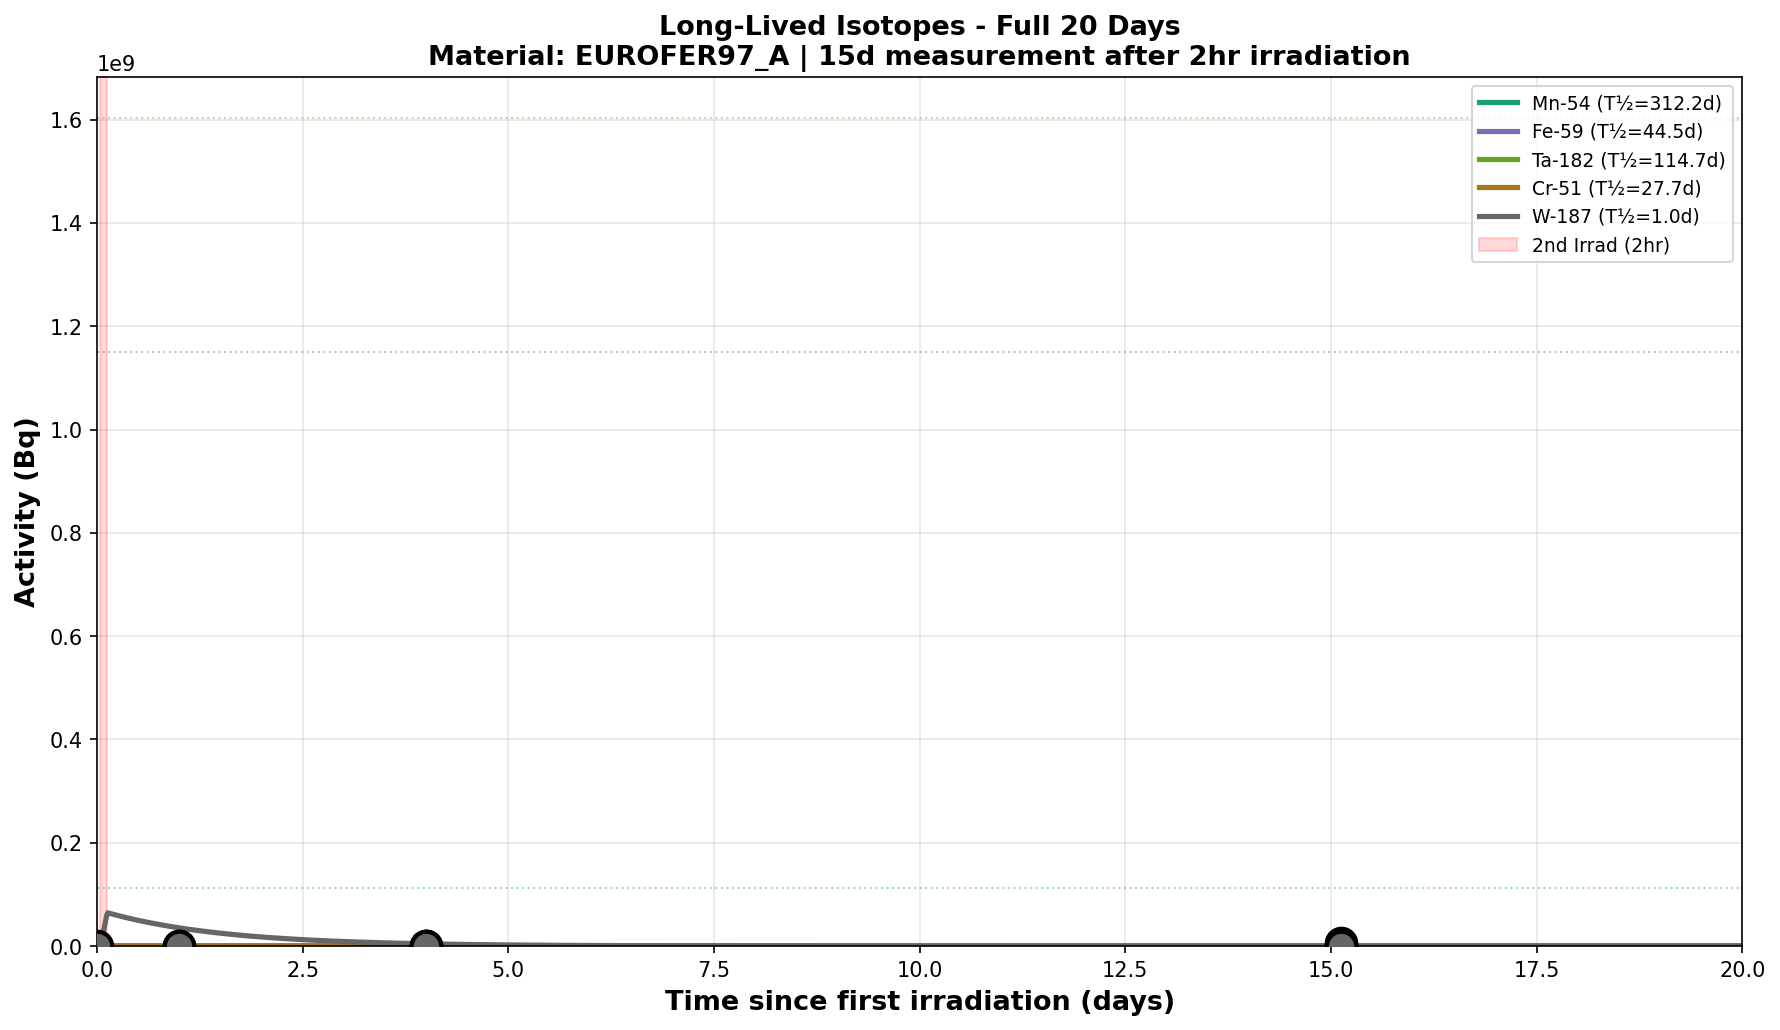


────────────────────────────────────────────────────────────
MODEL AGREEMENT ANALYSIS - SCATTER PLOT
────────────────────────────────────────────────────────────

W-187 (T½=1.00d):
  Reference: t=0.004d, A_exp=2.76e+04 Bq → prod_rate=9.24e+03
  t=0.00d (300s): A_exp=2.76e+04, A_model=2.76e+04, ratio=1.000 (+0.0%) ✓
  t=1.00d (24h): A_exp=1.92e+04, A_model=3.52e+07, ratio=0.001 (-99.9%) ✗
  t=4.00d (4d): A_exp=2.59e+03, A_model=4.41e+06, ratio=0.001 (-99.9%) ✗
  t=15.12d (15d): A_exp=6.73e+03, A_model=1.97e+03, ratio=3.414 (+241.4%) ✗

Mn-56 (T½=0.11d):
  Reference: t=0.004d, A_exp=5.89e+05 Bq → prod_rate=2.01e+05
  t=0.00d (300s): A_exp=5.89e+05, A_model=5.89e+05, ratio=1.000 (+0.0%) ✓
  t=1.00d (24h): A_exp=6.84e+02, A_model=3.95e+06, ratio=0.000 (-100.0%) ✗

V-52 (T½=0.00d):
  Reference: t=0.004d, A_exp=9.59e+07 Bq → prod_rate=8.11e+07
  t=0.00d (300s): A_exp=9.59e+07, A_model=9.59e+07, ratio=1.000 (+0.0%) ✓

Al-28 (T½=0.00d):
  Reference: t=0.004d, A_exp=2.48e+05 Bq → prod_rate=3.9

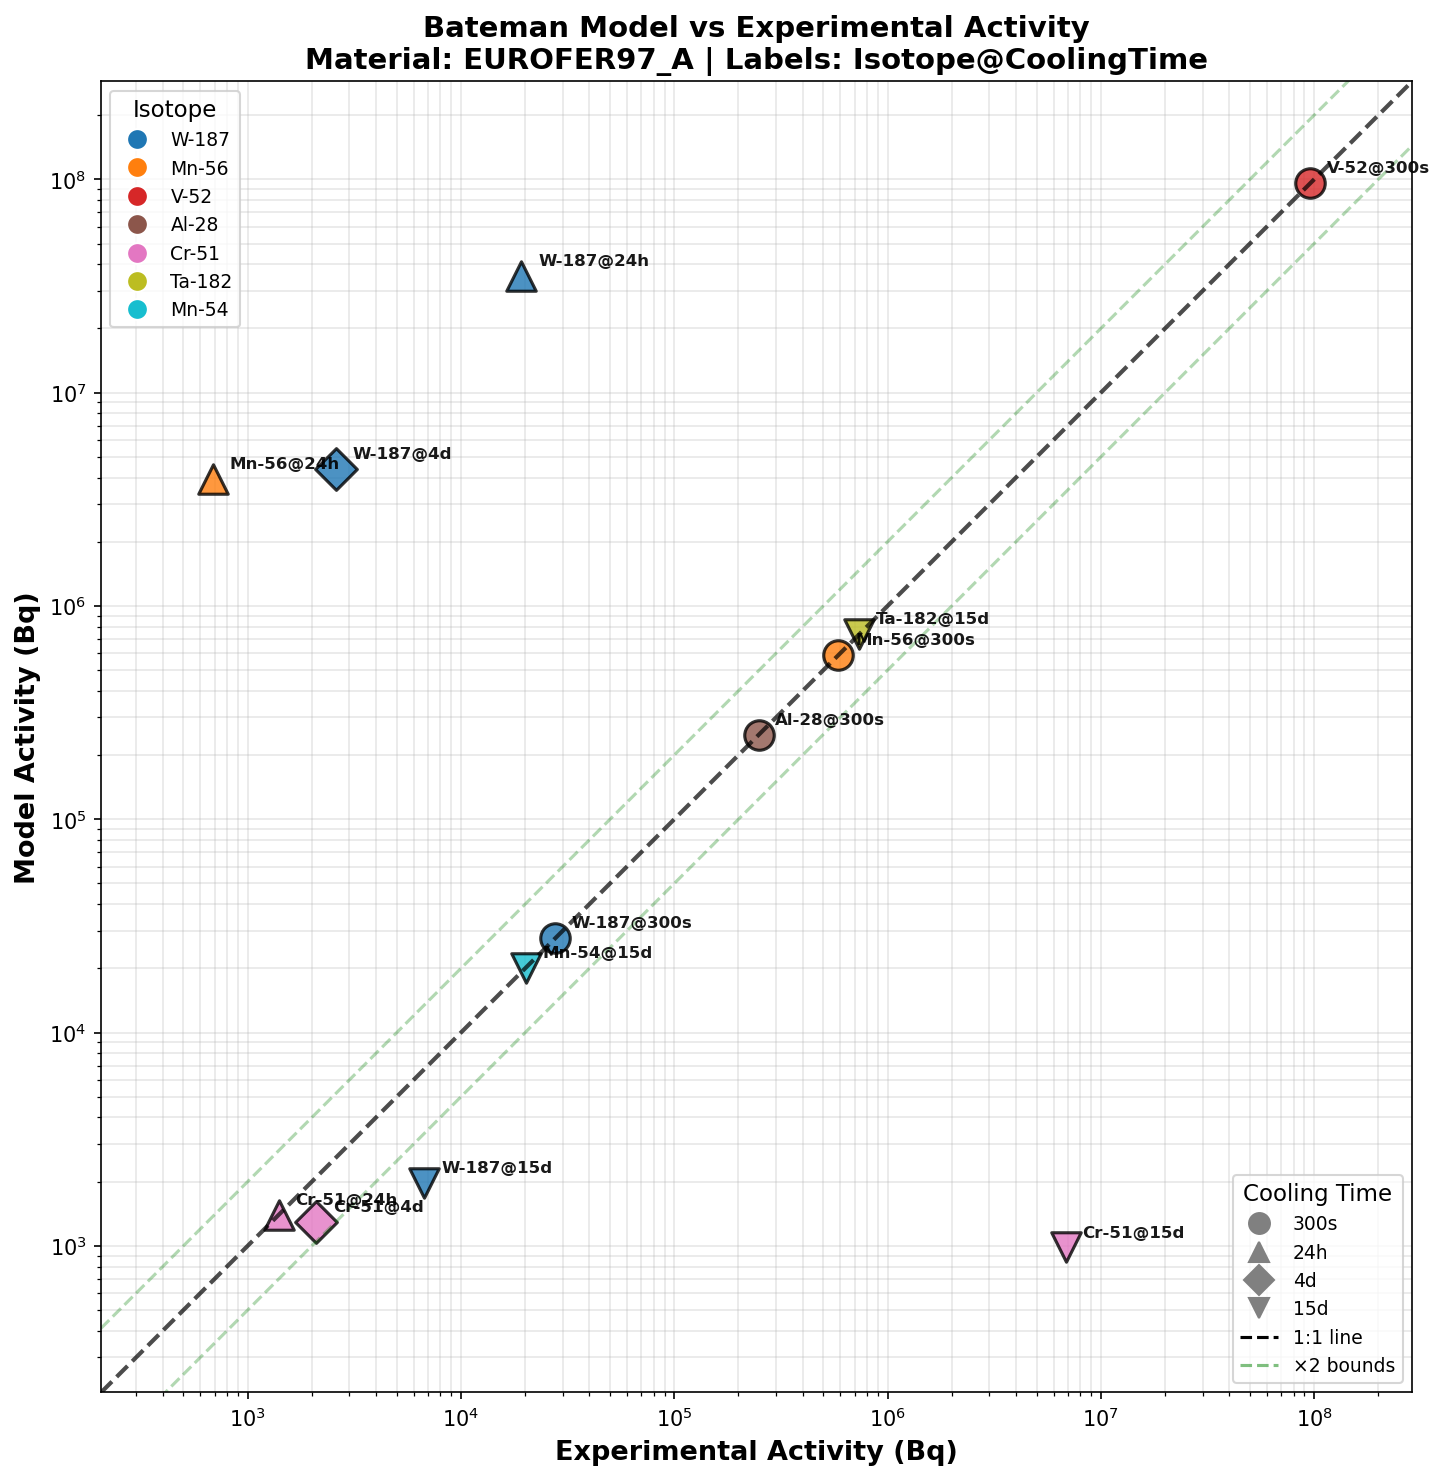


MODEL AGREEMENT SUMMARY

Isotope    Cooling  After  A_exp (Bq)     A_model (Bq)   Ratio    Diff %    
────────────────────────────────────────────────────────────────────────────────
W-187      300s     3s     2.764e+04      2.764e+04      1.000        +0.0%
W-187      24h      3s     1.920e+04      3.524e+07      0.001       -99.9%
W-187      4d       3s     2.594e+03      4.405e+06      0.001       -99.9%
W-187      15d      2hr    6.734e+03      1.973e+03      3.414      +241.4%
Mn-56      300s     3s     5.886e+05      5.886e+05      1.000        +0.0%
Mn-56      24h      3s     6.845e+02      3.954e+06      0.000      -100.0%
V-52       300s     3s     9.594e+07      9.594e+07      1.000        +0.0%
Al-28      300s     3s     2.484e+05      2.484e+05      1.000        +0.0%
Cr-51      24h      3s     1.399e+03      1.399e+03      1.000        +0.0%
Cr-51      4d       3s     2.090e+03      1.297e+03      1.611       +61.1%
Cr-51      15d      2hr    6.845e+06      9.822e+02     

In [70]:
# ==============================================================================
# BATEMAN EQUATION DECAY CURVES - CORRECTED MEASUREMENT TIMELINE
# ==============================================================================
# Timeline: t=0 is when first sample is irradiated (August 4, 2025)
#
# CRITICAL TIMELINE CORRECTION:
#   - Measurements at 5min, 2hr, 24hr, 4d are ALL after the FIRST 3s irradiation
#   - ONLY the 15d measurement is 15 days after the SECOND 2hr irradiation
#
# Features:
#   - Separate plots for different time periods with appropriate isotopes
#   - Each period has its own x/y scales for visibility
#   - Shows ALL ALARA-predicted isotopes, not just experimental
#   - Scatter plot for model agreement (log-log with 1:1 line)
# ==============================================================================

import importlib
import decay_physics
importlib.reload(decay_physics)

from decay_physics import (
    multi_irradiation_activity, bateman_activity, get_half_life_seconds, LN2
)
from isotope_utils import format_iso_pretty, get_half_life_days, canonical_iso, parse_activity_unit

print("=" * 80)
print("BATEMAN EQUATION DECAY CURVES - CORRECTED TIMELINE")
print("=" * 80)

# ==============================================================================
# DEFINE IRRADIATION TIMELINE
# ==============================================================================
T_IRR1_START = 0           # First irradiation starts at t=0
T_IRR1_END = 3             # First irradiation ends at t=3s
T_COOL = 3600 - 3          # 60 minutes cooling (minus 3s of first irrad)
T_IRR2_START = T_IRR1_END + T_COOL   # Second irradiation starts at t=3600s
T_IRR2_END = T_IRR2_START + 7200     # Second irradiation ends at t=10800s

SCHEDULE_FULL = [
    (T_IRR1_START, T_IRR1_END, 1.0),   # 3s irradiation
    (T_IRR2_START, T_IRR2_END, 1.0),   # 2hr irradiation
]

print(f"\nIRRADIATION TIMELINE (t=0 = start of first irradiation):")
print(f"  1st irrad:   t = {T_IRR1_START}-{T_IRR1_END}s (3 seconds)")
print(f"  Cooling:     t = {T_IRR1_END}-{T_IRR2_START}s (60 minutes)")
print(f"  2nd irrad:   t = {T_IRR2_START}-{T_IRR2_END}s (2 hours)")

# ==============================================================================
# GET ISOTOPES FROM EXPERIMENTAL DATA
# ==============================================================================
if 'experimental_data' in globals() and experimental_data:
    all_exp_isos = set()
    for mat_data in experimental_data.values():
        for time_data in mat_data.values():
            all_exp_isos.update(time_data.keys())
    key_isotopes = sorted(list(all_exp_isos))
else:
    key_isotopes = ['v-52', 'mn-56', 'w-187', 'cr-51', 'ta-182', 'mn-54']

valid_isotopes = [iso for iso in key_isotopes if get_half_life_seconds(iso) is not None]
print(f"\nExperimental isotopes: {len(valid_isotopes)} - {valid_isotopes}")

# ==============================================================================
# GET ALL ALARA-PREDICTED ISOTOPES
# ==============================================================================
alara_isotopes_all = set()
if 'adf' in globals() and adf is not None:
    try:
        # Get isotope column from ALARA data
        if 'isotope' in adf.columns:
            alara_isotopes_all = set(adf['isotope'].unique())
        elif 'Isotope' in adf.columns:
            alara_isotopes_all = set(adf['Isotope'].unique())
        print(f"ALARA-predicted isotopes: {len(alara_isotopes_all)}")
    except Exception as e:
        print(f"Note: Could not extract ALARA isotopes: {e}")

# ==============================================================================
# COLLECT EXPERIMENTAL DATA POINTS - CORRECTED TIMELINE
# ==============================================================================
exp_points = {}

if 'experimental_data' in globals() and experimental_data:
    material = list(experimental_data.keys())[0]
    print(f"\nUsing experimental data from: {material}")
    print(f"\nCORRECTED MEASUREMENT TIMELINE:")
    
    MEASUREMENTS_AFTER_3S = {
        '300s': 300, '5min': 300,
        '2h': 7200, '2hr': 7200,
        '24h': 86400, '24hr': 86400,
        '4d': 4*86400, '4days': 4*86400,
    }
    
    MEASUREMENTS_AFTER_2HR = {
        '15d': 15*86400, '15days': 15*86400,
    }
    
    for time_key, nuclides in experimental_data[material].items():
        time_key_lower = time_key.lower()
        cooling_s = None
        reference_time = None
        
        for tk, tv in MEASUREMENTS_AFTER_3S.items():
            if tk in time_key_lower:
                cooling_s = tv
                reference_time = T_IRR1_END
                break
        
        if cooling_s is None:
            for tk, tv in MEASUREMENTS_AFTER_2HR.items():
                if tk in time_key_lower:
                    cooling_s = tv
                    reference_time = T_IRR2_END
                    break
        
        if cooling_s is None:
            continue
        
        abs_time_s = reference_time + cooling_s
        which_irrad = "3s" if reference_time == T_IRR1_END else "2hr"
        print(f"  {time_key}: {cooling_s}s after {which_irrad} irrad → abs_t = {abs_time_s}s ({abs_time_s/86400:.2f} days)")
        
        for iso, data in nuclides.items():
            iso_canon = canonical_iso(iso)
            activity = data.get('activity')
            unit = data.get('unit', 'uCi')
            
            if activity is not None:
                try:
                    activity_bq = float(activity) * parse_activity_unit(unit)
                    if iso_canon not in exp_points:
                        exp_points[iso_canon] = []
                    exp_points[iso_canon].append((abs_time_s, activity_bq, which_irrad))
                except:
                    pass
    
    print(f"\nCollected experimental points for {len(exp_points)} isotopes:")
    for iso, pts in exp_points.items():
        print(f"  {format_iso_pretty(iso)}: {len(pts)} points")

# ==============================================================================
# Categorize ALL isotopes by half-life (ALARA + experimental)
# ==============================================================================
SHORT_LIVED = []   # T½ < 1 hour - for first half-day plot
MEDIUM_LIVED = []  # 1 hour < T½ < 10 days - for 1-5 day plot  
LONG_LIVED = []    # T½ > 10 days - for 15 day plot

# Combine experimental and ALARA isotopes
all_plot_isotopes = set(exp_points.keys())
for iso in alara_isotopes_all:
    iso_canon = canonical_iso(iso)
    all_plot_isotopes.add(iso_canon)

for iso in all_plot_isotopes:
    hl_s = get_half_life_seconds(iso)
    if hl_s is None:
        continue
    hl_days = hl_s / 86400
    if hl_days < 1/24:  # < 1 hour
        SHORT_LIVED.append(iso)
    elif hl_days < 10:  # 1 hour to 10 days
        MEDIUM_LIVED.append(iso)
    else:  # > 10 days
        LONG_LIVED.append(iso)

print(f"\nIsotope categories by half-life (including ALARA predictions):")
print(f"  Short-lived (T½ < 1hr):  {len(SHORT_LIVED)} isotopes")
print(f"  Medium-lived (1hr-10d):  {len(MEDIUM_LIVED)} isotopes")
print(f"  Long-lived (T½ > 10d):   {len(LONG_LIVED)} isotopes")

# ==============================================================================
# Helper function to compute scaled activity
# ==============================================================================
def get_scaled_activity(iso, t_array, exp_points, schedule):
    """Compute Bateman activity scaled to match first experimental point."""
    hl_s = get_half_life_seconds(iso)
    if hl_s is None:
        return None, None, None
    
    lam = LN2 / hl_s
    A_raw = multi_irradiation_activity(t_array, hl_s, schedule, production_rate=1.0)
    A_sat_raw = 1.0 / lam
    
    if iso in exp_points and exp_points[iso]:
        t_ref = exp_points[iso][0][0]
        A_ref = exp_points[iso][0][1]
        A_raw_ref = multi_irradiation_activity(t_ref, hl_s, schedule, production_rate=1.0)
        scale = A_ref / A_raw_ref if A_raw_ref > 0 else 1.0
    else:
        scale = 1e8  # Default scale for ALARA-only isotopes
    
    return A_raw * scale, A_sat_raw * scale, scale

# ==============================================================================
# PLOT 1: First Half Day (0 - 0.5 days) - SHORT-LIVED ISOTOPES
# ==============================================================================
print("\n" + "─" * 60)
print("PLOT 1: First Half Day - Short-Lived Isotopes")
print("─" * 60)

fig1, ax1 = plt.subplots(figsize=(12, 7))

t_zoom_days = 0.5  # Half day
t_array_zoom = np.linspace(0, t_zoom_days * 86400, 2000)
t_days_zoom = t_array_zoom / 86400

# Plot short-lived isotopes - prioritize experimental ones
exp_short = [iso for iso in SHORT_LIVED if iso in exp_points]
alara_only_short = [iso for iso in SHORT_LIVED if iso not in exp_points][:5]  # Limit ALARA-only
short_isos = exp_short + alara_only_short

if not short_isos:
    short_isos = ['v-52', 'mn-56']

colors_short = plt.cm.Set1(np.linspace(0, 1, max(len(short_isos), 3)))

for i, iso in enumerate(short_isos[:8]):  # Limit to 8 isotopes
    A_scaled, A_sat, scale = get_scaled_activity(iso, t_array_zoom, exp_points, SCHEDULE_FULL)
    if A_scaled is None:
        continue
    
    hl_s = get_half_life_seconds(iso)
    hl_min = hl_s / 60
    hl_label = f"{hl_min:.1f}m"
    
    # Different linestyle for ALARA-only
    linestyle = '-' if iso in exp_points else '--'
    label_suffix = '' if iso in exp_points else ' (ALARA)'
    
    ax1.plot(t_days_zoom * 24 * 60, A_scaled, linewidth=2.5, color=colors_short[i % len(colors_short)],
            linestyle=linestyle, label=f"{format_iso_pretty(iso)} (T½={hl_label}){label_suffix}")
    ax1.axhline(y=A_sat, color=colors_short[i % len(colors_short)], linestyle=':', alpha=0.4, linewidth=1)
    
    # Exp points
    if iso in exp_points:
        t_exp = [(p[0] / 86400) * 24 * 60 for p in exp_points[iso] if p[0] <= t_zoom_days * 86400]
        A_exp = [p[1] for p in exp_points[iso] if p[0] <= t_zoom_days * 86400]
        if t_exp:
            ax1.scatter(t_exp, A_exp, s=200, marker='o', color=colors_short[i % len(colors_short)],
                       edgecolor='black', linewidth=2, zorder=10)
            print(f"  {format_iso_pretty(iso)}: exp point at {t_exp[0]:.1f} min = {A_exp[0]:.2e} Bq")

# Mark irradiation periods
ax1.axvspan(T_IRR1_START/60, T_IRR1_END/60, alpha=0.3, color='green', label='1st Irrad (3s)')
ax1.axvspan(T_IRR2_START/60, T_IRR2_END/60, alpha=0.3, color='red', label='2nd Irrad (2hr)')

ax1.set_xlabel('Time since first irradiation (minutes)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Activity (Bq)', fontsize=13, fontweight='bold')
ax1.set_title(f'Short-Lived Isotopes - First 12 Hours\n'
             f'Material: {material} (Solid=Exp, Dashed=ALARA only)', fontsize=13, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, t_zoom_days * 24 * 60)
ax1.set_ylim(0, None)
ax1.ticklabel_format(axis='y', style='scientific', scilimits=(0,0))

plt.tight_layout()
plt.savefig(decay_curve_dir / 'bateman_first_half_day.png', dpi=150, bbox_inches='tight')
print(f"✓ Saved: {decay_curve_dir / 'bateman_first_half_day.png'}")
plt.show()

# ==============================================================================
# PLOT 2: Medium Term (0 - 5 days) - MEDIUM-LIVED ISOTOPES
# ==============================================================================
print("\n" + "─" * 60)
print("PLOT 2: First 5 Days - Medium-Lived Isotopes")
print("─" * 60)

fig2, ax2 = plt.subplots(figsize=(12, 7))

t_med_days = 5
t_array_med = np.linspace(0, t_med_days * 86400, 2000)
t_days_med = t_array_med / 86400

# Medium-lived isotopes - prioritize experimental
exp_med = [iso for iso in MEDIUM_LIVED if iso in exp_points]
alara_only_med = [iso for iso in MEDIUM_LIVED if iso not in exp_points][:5]
med_isos = exp_med + alara_only_med

if not med_isos:
    med_isos = ['w-187', 'mn-56', 'cr-51']

colors_med = plt.cm.Set2(np.linspace(0, 1, max(len(med_isos), 3)))

for i, iso in enumerate(med_isos[:10]):  # Limit to 10 isotopes
    A_scaled, A_sat, scale = get_scaled_activity(iso, t_array_med, exp_points, SCHEDULE_FULL)
    if A_scaled is None:
        continue
    
    hl_s = get_half_life_seconds(iso)
    hl_days = hl_s / 86400
    hl_label = f"{hl_days:.1f}d" if hl_days >= 1 else f"{hl_days*24:.1f}h"
    
    linestyle = '-' if iso in exp_points else '--'
    label_suffix = '' if iso in exp_points else ' (ALARA)'
    
    ax2.plot(t_days_med, A_scaled, linewidth=2.5, color=colors_med[i % len(colors_med)],
            linestyle=linestyle, label=f"{format_iso_pretty(iso)} (T½={hl_label}){label_suffix}")
    ax2.axhline(y=A_sat, color=colors_med[i % len(colors_med)], linestyle=':', alpha=0.4, linewidth=1)
    
    # Exp points in this range
    if iso in exp_points:
        t_exp = [p[0] / 86400 for p in exp_points[iso] if p[0] <= t_med_days * 86400]
        A_exp = [p[1] for p in exp_points[iso] if p[0] <= t_med_days * 86400]
        if t_exp:
            ax2.scatter(t_exp, A_exp, s=200, marker='o', color=colors_med[i % len(colors_med)],
                       edgecolor='black', linewidth=2, zorder=10)
            for t, a in zip(t_exp, A_exp):
                print(f"  {format_iso_pretty(iso)}: exp point at {t:.2f} d = {a:.2e} Bq")

# Mark 2nd irradiation
ax2.axvspan(T_IRR2_START/86400, T_IRR2_END/86400, alpha=0.2, color='red', label='2nd Irrad (2hr)')

ax2.set_xlabel('Time since first irradiation (days)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Activity (Bq)', fontsize=13, fontweight='bold')
ax2.set_title(f'Medium-Lived Isotopes - First 5 Days\n'
             f'Material: {material} (Solid=Exp, Dashed=ALARA only)', fontsize=13, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, t_med_days)
ax2.set_ylim(0, None)
ax2.ticklabel_format(axis='y', style='scientific', scilimits=(0,0))

plt.tight_layout()
plt.savefig(decay_curve_dir / 'bateman_medium_term.png', dpi=150, bbox_inches='tight')
print(f"✓ Saved: {decay_curve_dir / 'bateman_medium_term.png'}")
plt.show()

# ==============================================================================
# PLOT 3: Long Term (0 - 20 days) - LONG-LIVED ISOTOPES
# ==============================================================================
print("\n" + "─" * 60)
print("PLOT 3: Full 20 Days - Long-Lived Isotopes")
print("─" * 60)

fig3, ax3 = plt.subplots(figsize=(12, 7))

t_long_days = 20
t_array_long = np.linspace(0, t_long_days * 86400, 2000)
t_days_long = t_array_long / 86400

# Long-lived isotopes - prioritize experimental
exp_long = [iso for iso in LONG_LIVED if iso in exp_points]
# Also include isotopes with 15d measurement
for iso in exp_points.keys():
    if iso not in LONG_LIVED and iso not in exp_long:
        for p in exp_points[iso]:
            if p[2] == "2hr":  # Has measurement after 2hr irrad (15d)
                exp_long.append(iso)
                break

alara_only_long = [iso for iso in LONG_LIVED if iso not in exp_points][:5]
long_isos = exp_long + alara_only_long

if not long_isos:
    long_isos = ['ta-182', 'mn-54', 'fe-59', 'cr-51']

colors_long = plt.cm.Dark2(np.linspace(0, 1, max(len(long_isos), 4)))

for i, iso in enumerate(long_isos[:10]):  # Limit to 10 isotopes
    A_scaled, A_sat, scale = get_scaled_activity(iso, t_array_long, exp_points, SCHEDULE_FULL)
    if A_scaled is None:
        continue
    
    hl_s = get_half_life_seconds(iso)
    hl_days = hl_s / 86400
    hl_label = f"{hl_days:.1f}d"
    
    linestyle = '-' if iso in exp_points else '--'
    label_suffix = '' if iso in exp_points else ' (ALARA)'
    
    ax3.plot(t_days_long, A_scaled, linewidth=2.5, color=colors_long[i % len(colors_long)],
            linestyle=linestyle, label=f"{format_iso_pretty(iso)} (T½={hl_label}){label_suffix}")
    ax3.axhline(y=A_sat, color=colors_long[i % len(colors_long)], linestyle=':', alpha=0.4, linewidth=1)
    
    # All exp points
    if iso in exp_points:
        t_exp = [p[0] / 86400 for p in exp_points[iso]]
        A_exp = [p[1] for p in exp_points[iso]]
        ax3.scatter(t_exp, A_exp, s=200, marker='o', color=colors_long[i % len(colors_long)],
                   edgecolor='black', linewidth=2, zorder=10)
        for t, a in zip(t_exp, A_exp):
            print(f"  {format_iso_pretty(iso)}: exp point at {t:.2f} d = {a:.2e} Bq")

ax3.axvspan(T_IRR2_START/86400, T_IRR2_END/86400, alpha=0.15, color='red', label='2nd Irrad (2hr)')

ax3.set_xlabel('Time since first irradiation (days)', fontsize=13, fontweight='bold')
ax3.set_ylabel('Activity (Bq)', fontsize=13, fontweight='bold')
ax3.set_title(f'Long-Lived Isotopes - Full 20 Days\n'
             f'Material: {material} | 15d measurement after 2hr irradiation', fontsize=13, fontweight='bold')
ax3.legend(loc='upper right', fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, t_long_days)
ax3.set_ylim(0, None)
ax3.ticklabel_format(axis='y', style='scientific', scilimits=(0,0))

plt.tight_layout()
plt.savefig(decay_curve_dir / 'bateman_long_term.png', dpi=150, bbox_inches='tight')
print(f"✓ Saved: {decay_curve_dir / 'bateman_long_term.png'}")
plt.show()

# ==============================================================================
# MODEL AGREEMENT ANALYSIS - SCATTER PLOT (like old version)
# ==============================================================================
print("\n" + "─" * 60)
print("MODEL AGREEMENT ANALYSIS - SCATTER PLOT")
print("─" * 60)

# For each isotope, calculate agreement at each measurement time
agreement_data = []

for iso in exp_points.keys():
    hl_s = get_half_life_seconds(iso)
    if hl_s is None or len(exp_points[iso]) < 1:
        continue
    
    # Get all measurement points
    pts = sorted(exp_points[iso], key=lambda x: x[0])
    
    # Use first point to set production rate scale
    t0, A0, irrad0 = pts[0]
    A_model_t0 = multi_irradiation_activity(t0, hl_s, SCHEDULE_FULL, production_rate=1.0)
    if A_model_t0 <= 0:
        continue
    
    prod_rate = A0 / A_model_t0
    
    print(f"\n{format_iso_pretty(iso)} (T½={hl_s/86400:.2f}d):")
    print(f"  Reference: t={t0/86400:.3f}d, A_exp={A0:.2e} Bq → prod_rate={prod_rate:.2e}")
    
    for t_exp, A_exp, which_irrad in pts:
        A_model = multi_irradiation_activity(t_exp, hl_s, SCHEDULE_FULL, production_rate=1.0) * prod_rate
        
        if A_model > 0:
            ratio = A_exp / A_model
            percent_diff = (ratio - 1.0) * 100
            
            # Determine cooling time label for scatter plot
            t_cool_s = t_exp - (T_IRR1_END if which_irrad == "3s" else T_IRR2_END)
            if t_cool_s <= 400:
                cooling_label = '300s'
            elif t_cool_s <= 3*3600:
                cooling_label = '2h'
            elif t_cool_s <= 2*86400:
                cooling_label = '24h'
            elif t_cool_s <= 6*86400:
                cooling_label = '4d'
            else:
                cooling_label = '15d'
            
            agreement_data.append({
                'isotope': iso,
                'isotope_pretty': format_iso_pretty(iso),
                'time_s': t_exp,
                'time_days': t_exp / 86400,
                'after_irrad': which_irrad,
                'cooling_time': cooling_label,
                'A_experiment_Bq': A_exp,
                'A_model_Bq': A_model,
                'ratio': ratio,
                'percent_diff': percent_diff
            })
            
            status = "✓" if 0.5 <= ratio <= 2.0 else "✗"
            print(f"  t={t_exp/86400:.2f}d ({cooling_label}): A_exp={A_exp:.2e}, A_model={A_model:.2e}, "
                  f"ratio={ratio:.3f} ({percent_diff:+.1f}%) {status}")

# Create SCATTER PLOT with isotope AND time labels
if agreement_data:
    agree_df = pd.DataFrame(agreement_data)
    
    fig4, ax4 = plt.subplots(figsize=(14, 10))
    
    # Define colors by isotope and markers by cooling time
    cooling_order = ['300s', '2h', '24h', '4d', '15d']
    markers = {'300s': 'o', '2h': 's', '24h': '^', '4d': 'D', '15d': 'v'}
    
    # Get unique isotopes and assign colors
    isotopes_unique = agree_df['isotope_pretty'].unique()
    iso_colors = plt.cm.tab10(np.linspace(0, 1, len(isotopes_unique)))
    iso_color_map = {iso: iso_colors[i] for i, iso in enumerate(isotopes_unique)}
    
    # Plot each point with isotope color and cooling time marker
    for _, row in agree_df.iterrows():
        iso = row['isotope_pretty']
        ct = row['cooling_time']
        ax4.scatter(row['A_experiment_Bq'], row['A_model_Bq'],
                   alpha=0.8, marker=markers.get(ct, 'o'), s=200, 
                   edgecolor='black', linewidth=1.5,
                   color=iso_color_map[iso])
        
        # Add text label: "Isotope @ time"
        label_text = f"{iso}@{ct}"
        ax4.annotate(label_text, 
                    (row['A_experiment_Bq'], row['A_model_Bq']),
                    textcoords="offset points", xytext=(8, 5),
                    fontsize=8, fontweight='bold', alpha=0.9)
    
    # Add 1:1 line
    all_vals = np.concatenate([agree_df['A_experiment_Bq'].values, agree_df['A_model_Bq'].values])
    min_val = all_vals.min() * 0.3
    max_val = all_vals.max() * 3.0
    ax4.loglog([min_val, max_val], [min_val, max_val], 'k--', alpha=0.7, linewidth=2, label='1:1 line')
    
    # Add factor of 2 lines
    ax4.loglog([min_val, max_val], [min_val*2, max_val*2], 'g--', alpha=0.3, linewidth=1.5, label='×2 bounds')
    ax4.loglog([min_val, max_val], [min_val/2, max_val/2], 'g--', alpha=0.3, linewidth=1.5)
    
    # Create legend entries for isotopes (colors) and cooling times (markers)
    from matplotlib.lines import Line2D
    
    # Isotope color legend
    iso_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=iso_color_map[iso], 
                          markersize=10, label=iso) for iso in isotopes_unique]
    
    # Cooling time marker legend
    ct_handles = [Line2D([0], [0], marker=markers[ct], color='gray', linestyle='None',
                         markersize=10, label=ct) for ct in cooling_order if ct in agree_df['cooling_time'].values]
    
    # Reference line handles
    line_handles = [Line2D([0], [0], color='k', linestyle='--', label='1:1 line'),
                   Line2D([0], [0], color='g', linestyle='--', alpha=0.5, label='×2 bounds')]
    
    # Create two legends
    leg1 = ax4.legend(handles=iso_handles, title='Isotope', loc='upper left', fontsize=9)
    ax4.add_artist(leg1)
    leg2 = ax4.legend(handles=ct_handles + line_handles, title='Cooling Time', loc='lower right', fontsize=9)
    
    ax4.set_xlabel('Experimental Activity (Bq)', fontsize=13, fontweight='bold')
    ax4.set_ylabel('Model Activity (Bq)', fontsize=13, fontweight='bold')
    ax4.set_title(f'Bateman Model vs Experimental Activity\n'
                 f'Material: {material} | Labels: Isotope@CoolingTime', fontsize=14, fontweight='bold')
    ax4.grid(True, alpha=0.3, which='both')
    ax4.set_xlim(min_val, max_val)
    ax4.set_ylim(min_val, max_val)
    ax4.set_aspect('equal', adjustable='box')
    
    plt.tight_layout()
    plt.savefig(decay_curve_dir / 'bateman_model_agreement_scatter.png', dpi=150, bbox_inches='tight')
    print(f"\n✓ Saved: {decay_curve_dir / 'bateman_model_agreement_scatter.png'}")
    plt.show()
    
    # Summary table
    print("\n" + "=" * 80)
    print("MODEL AGREEMENT SUMMARY")
    print("=" * 80)
    print(f"\n{'Isotope':<10} {'Cooling':<8} {'After':<6} {'A_exp (Bq)':<14} {'A_model (Bq)':<14} {'Ratio':<8} {'Diff %':<10}")
    print("─" * 80)
    for _, row in agree_df.iterrows():
        print(f"{row['isotope_pretty']:<10} {row['cooling_time']:<8} {row['after_irrad']:<6} "
              f"{row['A_experiment_Bq']:<14.3e} {row['A_model_Bq']:<14.3e} "
              f"{row['ratio']:<8.3f} {row['percent_diff']:+8.1f}%")
    
    # Per-isotope summary
    print("\n" + "─" * 60)
    print(f"{'Isotope':<12} {'# Points':<10} {'Mean Ratio':<12} {'Std Dev':<10} {'Assessment'}")
    print("─" * 60)
    isotopes_with_data = agree_df['isotope_pretty'].unique()
    for iso in isotopes_with_data:
        sub = agree_df[agree_df['isotope_pretty'] == iso]
        n_pts = len(sub)
        # Exclude first point (ratio=1 by definition) if multiple points
        if n_pts > 1:
            test_ratios = sub['ratio'].values[1:]  # Skip first point
            mean_r = np.mean(test_ratios)
            std_r = np.std(test_ratios)
        else:
            mean_r = sub['ratio'].mean()
            std_r = 0
        
        if 0.8 <= mean_r <= 1.2:
            assessment = "✓ Excellent"
        elif 0.5 <= mean_r <= 2.0:
            assessment = "~ Acceptable"
        else:
            assessment = "✗ Poor"
        
        print(f"{iso:<12} {n_pts:<10} {mean_r:<12.3f} {std_r:<10.3f} {assessment}")

else:
    print("No experimental data available for agreement analysis")

print("\n✓ Decay curve analysis complete (CORRECTED TIMELINE with ALARA isotopes)")

## Step 7: Compare Materials

Compare total activity between different materials/tallies.

**Note on Cooling Times**: Each sample has slightly different cooling times based on when it was measured experimentally (e.g., Sample A measured at 2.0h, Sample B at 2.1h). For plotting and comparison purposes, we normalize these to standard time periods (e.g., "2 hours") since the small differences are negligible for analysis but the exact values are preserved in the original data.


In [71]:
# Calculate total activity for each tally at each time
# Use normalized cooling times to group similar time periods across materials
# EXCLUDE shutdown - it's not a real experimental measurement time!

# Reload to get updated normalize_cooling_time
from importlib import reload
import flux_mesh_analysis
reload(flux_mesh_analysis)
from flux_mesh_analysis import normalize_cooling_time

# Valid experimental measurement groups (after second irradiation for 15d)
VALID_EXP_GROUPS = ['300s', '2h', '24h', '4d', '15d']

total_activity = []

for tally_name, data in activity_data.items():
    df = data['data']
    material = data['material']
    mean_cols = [c for c in df.columns if c.startswith('mean_') and '0s' not in c]
    
    for col in mean_cols:
        time_label = col.replace('mean_', '')
        normalized_time = normalize_cooling_time(time_label, exclude_shutdown=True)
        
        # Skip if normalized to None (shutdown) or not in valid groups
        if normalized_time is None:
            continue
        if normalized_time not in VALID_EXP_GROUPS:
            print(f"  Skipping {time_label} -> {normalized_time} (not in valid groups)")
            continue
            
        total = df[col].sum()
        total_activity.append({
            'Material': f"{material} ({tally_name})",
            'Cooling Time': normalized_time,
            'Original Time': time_label,  # Keep original for reference
            'Total Activity (Bq/cm³)': total
        })

total_df = pd.DataFrame(total_activity)

if total_df.empty:
    print("No activity data available to analyze.")
    print("Please ensure that the ALARA workflow (Step 1) ran successfully and generated output files.")
else:
    # Show comparison table with normalized times
    print("Total Activity by Material and Cooling Time (Normalized to Experimental Groups):")
    print("="*80)
    print(f"Valid experimental groups: {VALID_EXP_GROUPS}")
    print("Note: 'shutdown' times are excluded as they are not real measurements\n")
    
    pivot = total_df.pivot_table(
        index='Material', 
        columns='Cooling Time', 
        values='Total Activity (Bq/cm³)',
        aggfunc='first'  # Use first value if multiple entries per time period
    )
    # Reorder columns to match experimental timeline
    ordered_cols = [c for c in VALID_EXP_GROUPS if c in pivot.columns]
    pivot = pivot[ordered_cols]
    print(pivot.to_string())

    # Show original times for reference
    print("\n\nOriginal Cooling Time Labels by Material:")
    print("="*80)
    for material in total_df['Material'].unique():
        mat_data = total_df[total_df['Material'] == material]
        times = list(zip(mat_data['Cooling Time'], mat_data['Original Time']))
        print(f"\n{material}:")
        for norm_time, orig_time in sorted(set(times), key=lambda x: VALID_EXP_GROUPS.index(x[0]) if x[0] in VALID_EXP_GROUPS else 99):
            print(f"  {norm_time:15s} <- {orig_time}")

Total Activity by Material and Cooling Time (Normalized to Experimental Groups):
Valid experimental groups: ['300s', '2h', '24h', '4d', '15d']
Note: 'shutdown' times are excluded as they are not real measurements

Cooling Time                       300s            2h           24h            4d           15d
Material                                                                                       
CNA (tally_85214)          3.944029e+08  3.804836e+08  2.703611e+08  1.817480e+08  1.407622e+08
EUROFER97_A (tally_85244)  3.798174e+08  3.650035e+08  2.579374e+08  1.819986e+08  1.434704e+08
EUROFER97_B (tally_85234)  3.868435e+08  3.717789e+08  2.623204e+08  1.838938e+08  1.438416e+08
EUROFER97_C (tally_85224)  3.873594e+08  3.722837e+08  2.628383e+08  1.844159e+08  1.443855e+08


Original Cooling Time Labels by Material:

CNA (tally_85214):
  300s            <- 5m
  2h              <- 2h
  24h             <- 26h
  4d              <- 4d
  15d             <- 19.0833d
  15d             <

Cooling times in data: ['300s', '2h', '24h', '4d', '15d']
Valid experimental groups in data: ['300s', '2h', '24h', '4d', '15d']
Pivot table shape: (5, 4)
Material      CNA (tally_85214)  EUROFER97_A (tally_85244)  \
Cooling Time                                                 
300s               3.944029e+08               3.798174e+08   
2h                 3.804836e+08               3.650035e+08   
24h                2.703611e+08               2.579374e+08   
4d                 1.817480e+08               1.819986e+08   
15d                2.612396e+08               2.663820e+08   

Material      EUROFER97_B (tally_85234)  EUROFER97_C (tally_85224)  
Cooling Time                                                        
300s                       3.868435e+08               3.873594e+08  
2h                         3.717789e+08               3.722837e+08  
24h                        2.623204e+08               2.628383e+08  
4d                         1.838938e+08               1.844159e+08

/tmp/ipykernel_361558/3819172749.py:33: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_sorted = plot_df_sorted.pivot_table(


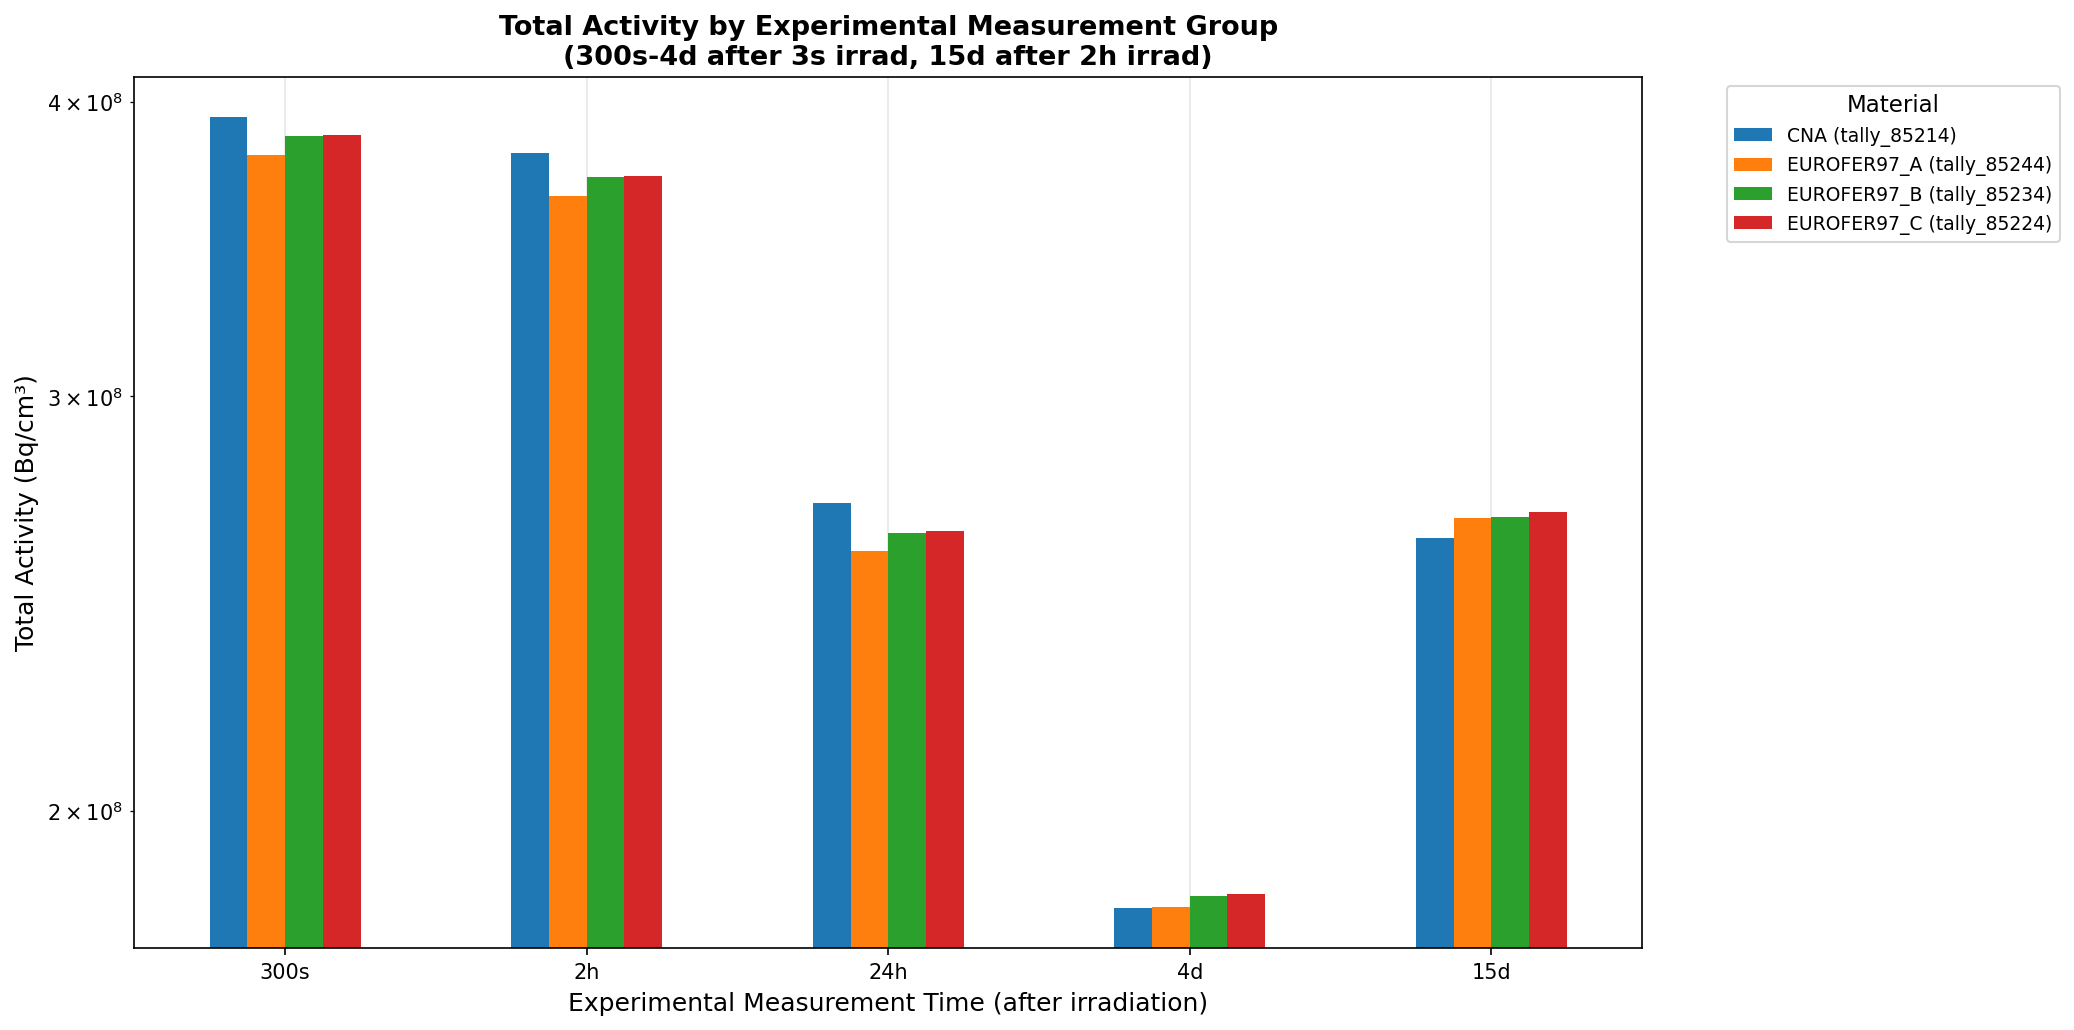

In [72]:
# Bar chart comparison grouped by experimental gamma file group (normalized cooling time)
# EXCLUDING shutdown - only valid experimental measurement times

if not total_df.empty:
    # Define experimental measurement timeline (after respective irradiations)
    # 300s, 2h, 24h, 4d: After first 3s irradiation
    # 15d: After second 2h irradiation
    time_order = VALID_EXP_GROUPS  # ['300s', '2h', '24h', '4d', '15d']

    # Check which cooling times actually exist in the data
    actual_times = total_df['Cooling Time'].unique()
    print(f"Cooling times in data: {list(actual_times)}")
    
    # Only use categories that exist in the data (and are valid experimental groups)
    valid_categories = [t for t in time_order if t in actual_times]
    print(f"Valid experimental groups in data: {valid_categories}")
    
    if not valid_categories:
        print("ERROR: No valid experimental cooling times found in data!")
        print("Expected groups: 300s, 2h, 24h, 4d, 15d")
    else:
        # Create copy to avoid modifying original
        plot_df = total_df.copy()
        plot_df['Cooling Time'] = pd.Categorical(plot_df['Cooling Time'], categories=valid_categories, ordered=True)
        plot_df = plot_df.dropna(subset=['Cooling Time'])  # Drop rows with NaN after categorical
        
        if plot_df.empty:
            print("Warning: No data after filtering for valid cooling times!")
        else:
            plot_df_sorted = plot_df.sort_values(['Cooling Time', 'Material'])

            # Aggregate by experimental group (summing any entries that map to the same group)
            pivot_sorted = plot_df_sorted.pivot_table(
                index='Cooling Time',
                columns='Material',
                values='Total Activity (Bq/cm³)',
                aggfunc='sum'
            )
            
            print(f"Pivot table shape: {pivot_sorted.shape}")
            print(pivot_sorted)

            # Single-path matplotlib plot
            fig, ax = plt.subplots(figsize=(14, 7))
            pivot_sorted.plot(kind='bar', logy=True, ax=ax)
            ax.set_xlabel('Experimental Measurement Time (after irradiation)')
            ax.set_ylabel('Total Activity (Bq/cm³)')
            ax.set_title('Total Activity by Experimental Measurement Group\n(300s-4d after 3s irrad, 15d after 2h irrad)')
            ax.legend(title='Material', bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.xticks(rotation=0)
            plt.tight_layout()
            plt.show()
else:
    print('No total activity data available for plotting.')

## Step 8: Decay Heat Analysis

Analyze decay heat from the activation products.

In [73]:
# Load decay heat data
heat_data = {}

for csv_file in sorted(glob.glob(os.path.join(OUTPUT_DIR, 'tally_*_W_per_cm3.csv'))):
    tally_name = os.path.basename(csv_file).replace('_W_per_cm3.csv', '')
    material = material_names.get(tally_name, 'unknown')
    df = pd.read_csv(csv_file)
    heat_data[tally_name] = {'material': material, 'data': df}
    
    print(f"\n{tally_name} ({material}): {len(df)} contributors to decay heat")
    
    # Show top contributors at shutdown
    mean_cols = [c for c in df.columns if c.startswith('mean_')]
    if mean_cols:
        top = df.nlargest(5, mean_cols[0])[['isotope'] + mean_cols[:2]]
        print(top.to_string(index=False))


tally_85114 (unknown): 46 contributors to decay heat
isotope  mean_shutdown      mean_5m
  total   5.328900e-06 5.327500e-06
  mn-54   3.296200e-06 3.296200e-06
  mo-99   7.820900e-07 7.814000e-07
  cr-51   2.989600e-07 2.989400e-07
  sc-48   2.924100e-07 2.920200e-07

tally_85214 (CNA): 160 contributors to decay heat
isotope  mean_shutdown      mean_5m
  total   1.694500e-05 1.691500e-05
  w-187   1.137900e-05 1.135100e-05
  mn-54   3.471500e-06 3.471400e-06
 ta-182   7.059000e-07 7.058800e-07
  sc-48   4.797300e-07 4.790900e-07

tally_85224 (EUROFER97_C): 144 contributors to decay heat
isotope  mean_shutdown      mean_5m
  total   1.575300e-05 1.572700e-05
  w-187   9.626700e-06 9.603400e-06
  mn-54   3.432400e-06 3.432400e-06
 ta-182   1.302800e-06 1.302800e-06
 ta-180   3.524600e-07 3.499500e-07

tally_85234 (EUROFER97_B): 144 contributors to decay heat
isotope  mean_shutdown      mean_5m
  total   1.570300e-05 1.567700e-05
  w-187   9.626700e-06 9.603400e-06
  mn-54   3.381400e-0

In [74]:
# Calculate total decay heat for each material
# Use normalized cooling times (experimental time groups) for consistency with activity data
total_heat = []

for tally_name, data in heat_data.items():
    df = data['data']
    material = data['material']
    mean_cols = [c for c in df.columns if c.startswith('mean_') and '0s' not in c]
    
    for col in mean_cols:
        time_label = col.replace('mean_', '')
        # Normalize to experimental time groups
        normalized_time = normalize_cooling_time(time_label)
        if normalized_time is None:
            continue  # Skip shutdown/non-mappable times
            
        total = df[col].sum()
        total_heat.append({
            'Material': f"{material}",
            'Cooling Time': normalized_time,
            'Original Time': time_label,
            'Total Decay Heat (W/cm³)': total
        })

heat_df = pd.DataFrame(total_heat)

if heat_df.empty:
    print("No decay heat data available to analyze.")
else:
    # Define time order for experimental groups
    time_order = ['300s', '2h', '24h', '4d', '15d']
    
    print("\nTotal Decay Heat by Material and Experimental Cooling Time (W/cm³):")
    print("=" * 70)
    
    # Filter to only times in our standard order
    heat_df_ordered = heat_df[heat_df['Cooling Time'].isin(time_order)].copy()
    heat_df_ordered['Cooling Time'] = pd.Categorical(
        heat_df_ordered['Cooling Time'], 
        categories=time_order, 
        ordered=True
    )
    
    if not heat_df_ordered.empty:
        heat_pivot = heat_df_ordered.pivot_table(
            index='Material', 
            columns='Cooling Time', 
            values='Total Decay Heat (W/cm³)',
            aggfunc='first'
        )
        print(heat_pivot.to_string())
        
        print("\n\nOriginal Cooling Time Labels:")
        for material in heat_df_ordered['Material'].unique():
            mat_data = heat_df_ordered[heat_df_ordered['Material'] == material]
            times = list(zip(mat_data['Cooling Time'], mat_data['Original Time']))
            print(f"  {material}: {[(n, o) for n, o in sorted(set(times))]}")
    else:
        print("No decay heat data for experimental time groups.")
        print("Available times:", heat_df['Cooling Time'].unique().tolist())


Total Decay Heat by Material and Experimental Cooling Time (W/cm³):
Cooling Time      300s        2h       24h        4d       15d
Material                                                      
CNA           0.000034  0.000032  0.000021  0.000011  0.000009
EUROFER97_A   0.000031  0.000029  0.000020  0.000012  0.000010
EUROFER97_B   0.000031  0.000030  0.000020  0.000012  0.000010
EUROFER97_C   0.000031  0.000030  0.000020  0.000012  0.000010
unknown       0.000011  0.000011  0.000010  0.000009  0.000007


Original Cooling Time Labels:
  unknown: [('15d', '19.0833d'), ('15d', '34.0833d'), ('24h', '26h'), ('2h', '2h'), ('300s', '5m'), ('4d', '4d')]
  CNA: [('15d', '19.0833d'), ('15d', '34.0833d'), ('24h', '26h'), ('2h', '2h'), ('300s', '5m'), ('4d', '4d')]
  EUROFER97_C: [('15d', '19.0833d'), ('15d', '34.0833d'), ('24h', '26h'), ('2h', '2h'), ('300s', '5m'), ('4d', '4d')]
  EUROFER97_B: [('15d', '19.0833d'), ('15d', '34.0833d'), ('24h', '26h'), ('2h', '2h'), ('300s', '5m'), ('4d', '4d')

/tmp/ipykernel_361558/2279535.py:45: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heat_pivot = heat_df_ordered.pivot_table(


## Step 9: Summary Report

Generate a summary of the activation analysis.

In [75]:
print("="*80)
print("ACTIVATION ANALYSIS SUMMARY")
print("="*80)
print(f"\nMCNP Input: {MCNP_INPUT}")
print(f"HDF5 File: {H5_FILE}")
print(f"Number of Mesh Tallies Processed: {len(activity_data)}")
print(f"Irradiation Time: 2 hours")
print(f"Cooling Times: shutdown, 3d, 7d, 45d, 1y")

print("\n" + "-"*60)
print("MATERIAL SUMMARY")
print("-"*60)

for tally_name, data in activity_data.items():
    material = data['material']
    df = data['data']
    
    print(f"\n{material} ({tally_name}):")
    print(f"  - Activated isotopes: {len(df)}")
    
    mean_cols = [c for c in df.columns if c.startswith('mean_')]
    if mean_cols:
        shutdown_col = mean_cols[0]
        total_shutdown = df[shutdown_col].sum()
        print(f"  - Total activity at shutdown: {total_shutdown:.3e} Bq/cm³")
        
        # Top 3 isotopes
        top3 = df.nlargest(3, shutdown_col)['isotope'].tolist()
        print(f"  - Top contributors: {', '.join([i.upper() for i in top3])}")

print("\n" + "="*80)
print("Analysis complete!")
print("="*80)

ACTIVATION ANALYSIS SUMMARY

MCNP Input: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_inputs/mcnp_inputs/whale_J_core_clean_loc.i
HDF5 File: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_inputs/runtpe.h5
Number of Mesh Tallies Processed: 4
Irradiation Time: 2 hours
Cooling Times: shutdown, 3d, 7d, 45d, 1y

------------------------------------------------------------
MATERIAL SUMMARY
------------------------------------------------------------

CNA (tally_85214):
  - Activated isotopes: 172
  - Total activity at shutdown: 3.950e+08 Bq/cm³
  - Top contributors: TOTAL, W-187, CR-51

EUROFER97_C (tally_85224):
  - Activated isotopes: 153
  - Total activity at shutdown: 3.880e+08 Bq/cm³
  - Top contributors: TOTAL, W-187, CR-51

EUROFER97_B (tally_85234):
  - Activated isotopes: 153
  - Total activity at shutdown: 3.875e+08 Bq/cm³
  - Top contributors: TOTAL, W-187, CR-51

EUROFER97_A (tally_85244):
  - Activated isotopes: 166
  -

## Output Files Location

All output files are in the `alara_output/` directory:

**Per-tally subdirectories (`tally_XXXXX/`):**
- `*.inp` - ALARA input file
- `*.out` - ALARA output file (full results)
- `*_results.json` - Parsed results in JSON format
- `*_combined.flx` - Flux file (all voxels)
- `materials.matlib` - Material library
- `custom_elelib.txt` - Custom element library with MCNP isotopes

**CSV summary files:**
- `tally_XXXXX_Bq_per_cm3.csv` - Specific activity (Bq/cm³)
- `tally_XXXXX_W_per_cm3.csv` - Decay heat (W/cm³)
- `tally_XXXXX_atoms_per_cm3.csv` - Number density (atoms/cm³)
- `tally_XXXXX_g_per_cm3.csv` - Mass density (g/cm³)

Each CSV contains:
- `mean_*` columns: Voxel-averaged values at each cooling time
- `sem_*` columns: Standard error of the mean
- `rel_unc_*` columns: Relative uncertainty

## Step 9b: Parse ALARA Output with Processing Tools

Use the `alara_output_processing` module from `tools/` to parse raw ALARA `.out` files into a structured `ALARADFrame` for easy filtering, analysis, and visualization.

**Key classes:**
- `FileParser` - Parses ALARA output files and extracts all data tables
- `ALARADFrame` - Pandas DataFrame subclass with specialized filtering and analysis methods
- `DataLibrary` - Combines multiple ALARA runs into a unified dataset

**Available variables:**
- `Number Density` (atoms/cm³)
- `Specific Activity` (Bq/cm³)  
- `Total Decay Heat` (W/cm³)
- `Alpha Heat`, `Beta Heat`, `Gamma Heat`
- `Contact Dose`

In [76]:
# Parse all ALARA output files using alara_output_processing tools
print("Loading ALARA outputs using alara_output_processing tools...")

# Find all .out files in the output directory (use PROJECT_ROOT from setup cell)
alara_output_dir = OUTPUT_DIR if 'OUTPUT_DIR' in dir() else Path('alara_output')
out_files = list(alara_output_dir.glob("**/tally_*_multizone.out"))

print(f"Found {len(out_files)} ALARA output files:")
for f in sorted(out_files):
    print(f"  - {f.relative_to(alara_output_dir)}")

# Create a DataLibrary with all tally runs
runs_dict = {}
for out_file in sorted(out_files):
    # Extract tally name from path (e.g., "tally_85114")
    tally_name = out_file.parent.name
    material = material_names.get(tally_name, tally_name)
    runs_dict[material] = str(out_file)

# Load all data into a unified ALARADFrame
if runs_dict:
    datalib = DataLibrary()
    adf = datalib.make_entries(runs_dict, time_unit='s')
    
    print(f"\n✓ Loaded {len(adf)} data rows from {len(runs_dict)} tally outputs")
    print(f"  Unique materials/runs: {adf['run_lbl'].unique().tolist()}")
    print(f"  Variables: {[k for k in adf.VARIABLE_ENUM.keys()]}")
    print(f"  Cooling times (s): {sorted(adf['time'].unique().tolist())}")
    
    # Show sample of the data
    print(f"\nSample data (first 5 rows):")
    display(adf[['run_lbl', 'nuclide', 'variable', 'time', 'value', 'var_unit']].head(10))
else:
    print("No ALARA output files found!")
    adf = None

Loading ALARA outputs using alara_output_processing tools...
Found 5 ALARA output files:
  - tally_85114/tally_85114_multizone.out
  - tally_85214/tally_85214_multizone.out
  - tally_85224/tally_85224_multizone.out
  - tally_85234/tally_85234_multizone.out
  - tally_85244/tally_85244_multizone.out

✓ Loaded 6845888 data rows from 5 tally outputs
  Unique materials/runs: ['tally_85114', 'CNA', 'EUROFER97_C', 'EUROFER97_B', 'EUROFER97_A']
  Variables: ['Number Density', 'Specific Activity', 'Total Decay Heat', 'Alpha Heat', 'Beta Heat', 'Gamma Heat', 'Alpha Decay Heat', 'Beta Decay Heat', 'Gamma Decay Heat', 'Contact Dose']
  Cooling times (s): [0.0, 300.0, 7200.0, 93600.0, 345600.0, 1648797.12, 2944797.12]

Sample data (first 5 rows):


,run_lbl,nuclide,variable,time,value,var_unit
0,tally_85114,h-1,0,0.00,3.337000e+15,atoms/cm3
1,tally_85114,h-1,0,300.00,3.337000e+15,atoms/cm3
2,tally_85114,h-1,0,7200.00,3.337000e+15,atoms/cm3
3,tally_85114,h-1,0,93600.00,3.337000e+15,atoms/cm3
4,tally_85114,h-1,0,345600.00,3.337000e+15,atoms/cm3
5,tally_85114,h-1,0,1648797.12,3.337000e+15,atoms/cm3
6,tally_85114,h-1,0,2944797.12,3.337000e+15,atoms/cm3
7,tally_85114,h-2,0,0.00,4.490200e+13,atoms/cm3
8,tally_85114,h-2,0,300.00,4.490200e+13,atoms/cm3
9,tally_85114,h-2,0,7200.00,4.490200e+13,atoms/cm3


In [77]:
# Demonstrate filtering and analysis with ALARADFrame
# Using first experimental measurement time (300s) instead of shutdown
FIRST_MEASUREMENT_TIME = 300  # seconds - first real experimental measurement

if adf is not None and not adf.empty:
    print("="*80)
    print("ALARADFrame Filtering and Analysis Demo")
    print("="*80)
    
    # Example 1: Get specific activity for a specific material
    material = 'EUROFER97_2'
    if material in adf['run_lbl'].values:
        filtered = adf.filter_rows({
            'run_lbl': material,
            'variable': adf.VARIABLE_ENUM['Specific Activity']
        })
        print(f"\n1. {material} - Specific Activity:")
        print(f"   Isotopes found: {filtered['nuclide'].nunique()}")
        
        # Pivot to get cooling time columns
        piv = filtered.pivot_table(
            index='nuclide',
            columns='time',
            values='value',
            aggfunc='first'
        )
        # Get top 5 isotopes at first measurement time (300s after irradiation)
        if FIRST_MEASUREMENT_TIME in piv.columns:
            top5 = piv.nlargest(5, FIRST_MEASUREMENT_TIME)[FIRST_MEASUREMENT_TIME]
            print(f"   Top 5 isotopes at 300s (first measurement):")
            for iso, val in top5.items():
                print(f"      {iso:>12s}: {val:.3e} Bq/cm³")
        else:
            # Fall back to first non-zero time
            available_times = [t for t in piv.columns if t > 0]
            if available_times:
                first_time = min(available_times)
                top5 = piv.nlargest(5, first_time)[first_time]
                print(f"   Top 5 isotopes at {first_time}s:")
                for iso, val in top5.items():
                    print(f"      {iso:>12s}: {val:.3e} Bq/cm³")
    
    # Example 2: Filter by element (all Fe isotopes)
    print(f"\n2. All Fe isotopes across materials:")
    fe_filtered = adf.filter_rows({
        'variable': adf.VARIABLE_ENUM['Specific Activity'],
        'nuclide': 'Fe'  # This filters all fe-XX isotopes
    })
    if not fe_filtered.empty:
        for material in fe_filtered['run_lbl'].unique():
            mat_fe = fe_filtered[fe_filtered['run_lbl'] == material]
            print(f"   {material}: {mat_fe['nuclide'].unique().tolist()}")
    
    # Example 3: Calculate relative contributions
    print(f"\n3. Relative contributions (requires single run/variable/block):")
    if material in adf['run_lbl'].values:
        single_run = adf.filter_rows({
            'run_lbl': material,
            'variable': adf.VARIABLE_ENUM['Specific Activity'],
            'block': adf.BLOCK_ENUM['Zone']
        })
        if 'block_num' in single_run.columns:
            single_run = single_run[single_run['block_num'] == single_run['block_num'].min()]
        
        rel_adf = single_run.calculate_relative_vals()
        piv_rel = rel_adf.pivot_table(index='nuclide', columns='time', values='value', aggfunc='first')
        if FIRST_MEASUREMENT_TIME in piv_rel.columns:
            top_rel = piv_rel.nlargest(5, FIRST_MEASUREMENT_TIME)
            print(f"   Top 5 contributors at 300s ({material}):")
            for iso, row in top_rel.iterrows():
                print(f"      {iso:>12s}: {row[FIRST_MEASUREMENT_TIME]*100:.1f}%")
        else:
            available_times = [t for t in piv_rel.columns if t > 0]
            if available_times:
                first_time = min(available_times)
                top_rel = piv_rel.nlargest(5, first_time)
                print(f"   Top 5 contributors at {first_time}s ({material}):")
                for iso, row in top_rel.iterrows():
                    print(f"      {iso:>12s}: {row[first_time]*100:.1f}%")
else:
    print("ALARADFrame not available - run previous cell first")

ALARADFrame Filtering and Analysis Demo

2. All Fe isotopes across materials:
   tally_85114: ['fe-53', 'fe-53m', 'fe-55', 'fe-59']
   CNA: ['fe-53', 'fe-53m', 'fe-55', 'fe-59', 'fe-60', 'fe-61']
   EUROFER97_C: ['fe-53', 'fe-53m', 'fe-55', 'fe-59', 'fe-60', 'fe-61']
   EUROFER97_B: ['fe-53', 'fe-53m', 'fe-55', 'fe-59', 'fe-60', 'fe-61']
   EUROFER97_A: ['fe-53', 'fe-53m', 'fe-55', 'fe-59', 'fe-60', 'fe-61']

3. Relative contributions (requires single run/variable/block):
   Top 5 contributors at 300s (EUROFER97_A):
             w-187: 41.4%
             cr-51: 22.2%
             mn-54: 13.6%
            ta-180: 10.5%
             fe-55: 5.2%


In [78]:
# ==============================================================================
# ACTIVITY VS COOLING TIME - DETAILED PLOT
# ==============================================================================
# Matplotlib-only plot with proper axis labels and saved output.
# ==============================================================================

activity_plots_dir = Path(OUTPUT_DIR) / 'activity_plots'
activity_plots_dir.mkdir(parents=True, exist_ok=True)

if adf is not None and not adf.empty:
    print("Plotting Specific Activity vs Cooling Time...")
    
    material = 'EUROFER97_2'
    if material in adf['run_lbl'].values:
        # Filter for this material
        filtered = adf.filter_rows({
            'run_lbl': material,
            'variable': adf.VARIABLE_ENUM['Specific Activity']
        })
        piv = filtered.pivot_table(index='nuclide', columns='time', values='value', aggfunc='first')
        
        if 0 in piv.columns:
            top10 = piv.nlargest(10, 0)
            times = sorted([t for t in piv.columns if t > 0])[:10]  # First 10 cooling times
            
            fig, ax = plt.subplots(figsize=(12, 7))
            colors = plt.cm.tab10(np.linspace(0, 1, 10))
            
            for idx, iso in enumerate(top10.index):
                # Get half-life for annotation
                hl_days = get_half_life_days(iso)
                hl_str = format_half_life(hl_days) if hl_days else "?"
                
                y_vals = [top10.loc[iso, t] if t in top10.columns else np.nan for t in times]
                valid_mask = np.array([v > 0 if pd.notna(v) else False for v in y_vals])
                
                if np.any(valid_mask):
                    x_plot = np.array(times)[valid_mask]
                    y_plot = np.array(y_vals)[valid_mask]
                    label = f"{format_iso_pretty(iso)} (T½={hl_str})"
                    ax.plot(x_plot, y_plot, marker='o', label=label, 
                           linewidth=1.5, color=colors[idx], markersize=5)
            
            ax.set_xlabel('Cooling Time (s)', fontsize=11)
            ax.set_ylabel('Specific Activity (Bq/cm³)', fontsize=11)
            ax.set_title(f'{material}: Top 10 Isotopes by Activity at Shutdown', fontsize=12, fontweight='bold')
            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
            ax.grid(True, alpha=0.3, which='both')
            plt.tight_layout()
            
            # Save plot
            save_path = activity_plots_dir / f'{material}_activity_vs_cooling.png'
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"✓ Saved: {save_path}")
            plt.show()
        else:
            print(f"⚠ No shutdown data (time=0) found for {material}")
    else:
        print(f"⚠ Material {material} not found in data")
else:
    print("⚠ ALARADFrame not available - run previous cells first")

Plotting Specific Activity vs Cooling Time...
⚠ Material EUROFER97_2 not found in data


In [79]:
# ==============================================================================
# ALARA TOOLS PLOTTING MODULE - COMPATIBILITY NOTE
# ==============================================================================
# The alara_output_plotting module from ALARA tools provides standardized plotting
# for ALARADFrame data. However, our voxel-averaged data has multiple entries 
# per (nuclide, time) combination (one per voxel), which requires aggregation
# before using the standard plotting functions.
#
# For our mesh tally data, we use custom plotting (shown in previous cell)
# that handles the voxel-averaged structure properly.
#
# The aop_plotting module is best suited for:
# - Single-zone ALARA outputs (no voxel dimension)
# - Pre-aggregated data (mean values already computed)
# ==============================================================================

if adf is not None and not adf.empty:
    print("ALARA Tools Plotting Compatibility Check")
    print("=" * 60)
    
    # Check data structure
    material = 'EUROFER97_2'
    filtered = adf.filter_rows({
        'run_lbl': material, 
        'variable': adf.VARIABLE_ENUM['Specific Activity']
    })
    
    dup_check = filtered.duplicated(subset=['nuclide', 'time'], keep=False)
    
    if dup_check.any():
        print(f"Data has {dup_check.sum()} rows with duplicate (nuclide, time) pairs")
        print("→ This is expected for mesh tally data with multiple voxels")
        print("→ Use pivot_table with aggfunc='mean' for aggregated plots")
        print("→ Custom plotting cells (above) handle this correctly")
        print("\nTo use aop_plotting.plot_single_response(), first aggregate:")
        print("  adf_agg = adf.groupby(['run_lbl', 'variable', 'nuclide', 'time']).mean().reset_index()")
    else:
        print("✓ Data is compatible with aop_plotting.plot_single_response()")
        
    # Show what aop_plotting provides
    print(f"\nAvailable functions in aop_plotting:")
    print(f"  - preprocess_data(): Filter and pivot ALARADFrame data")
    print(f"  - build_color_map(): Generate consistent colors for nuclides")
    print(f"  - plot_single_response(): Plot activity vs cooling time")
    print(f"  - construct_legend(): Create formatted legends")
else:
    print("⚠ ALARADFrame not available")

ALARA Tools Plotting Compatibility Check
✓ Data is compatible with aop_plotting.plot_single_response()

Available functions in aop_plotting:
  - preprocess_data(): Filter and pivot ALARADFrame data
  - build_color_map(): Generate consistent colors for nuclides
  - plot_single_response(): Plot activity vs cooling time
  - construct_legend(): Create formatted legends


/groupspace/cnerg/users/smandych/projects/ALARA/tools/alara_output_processing/alara_output_processing.py:395: UserWarning: Excessive filtering. No matching rows for given filters.
  warn('Excessive filtering. No matching rows for given filters.')


Cross-Material Comparison: Key Activation Products
At first measurement time (300s after irradiation)

Specific Activity at 300s (Bq/cm³):
------------------------------------------------------------
Material       CNA
Isotope           
CO-60    1.071e+03
CR-51    4.159e+07
FE-55    9.915e+06
FE-59    4.284e+05
MN-54    2.582e+07
MN-56    6.389e-01
TA-182   2.942e+06
W-187    9.544e+07

✓ Saved: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/activity_plots/material_comparison_300s.png


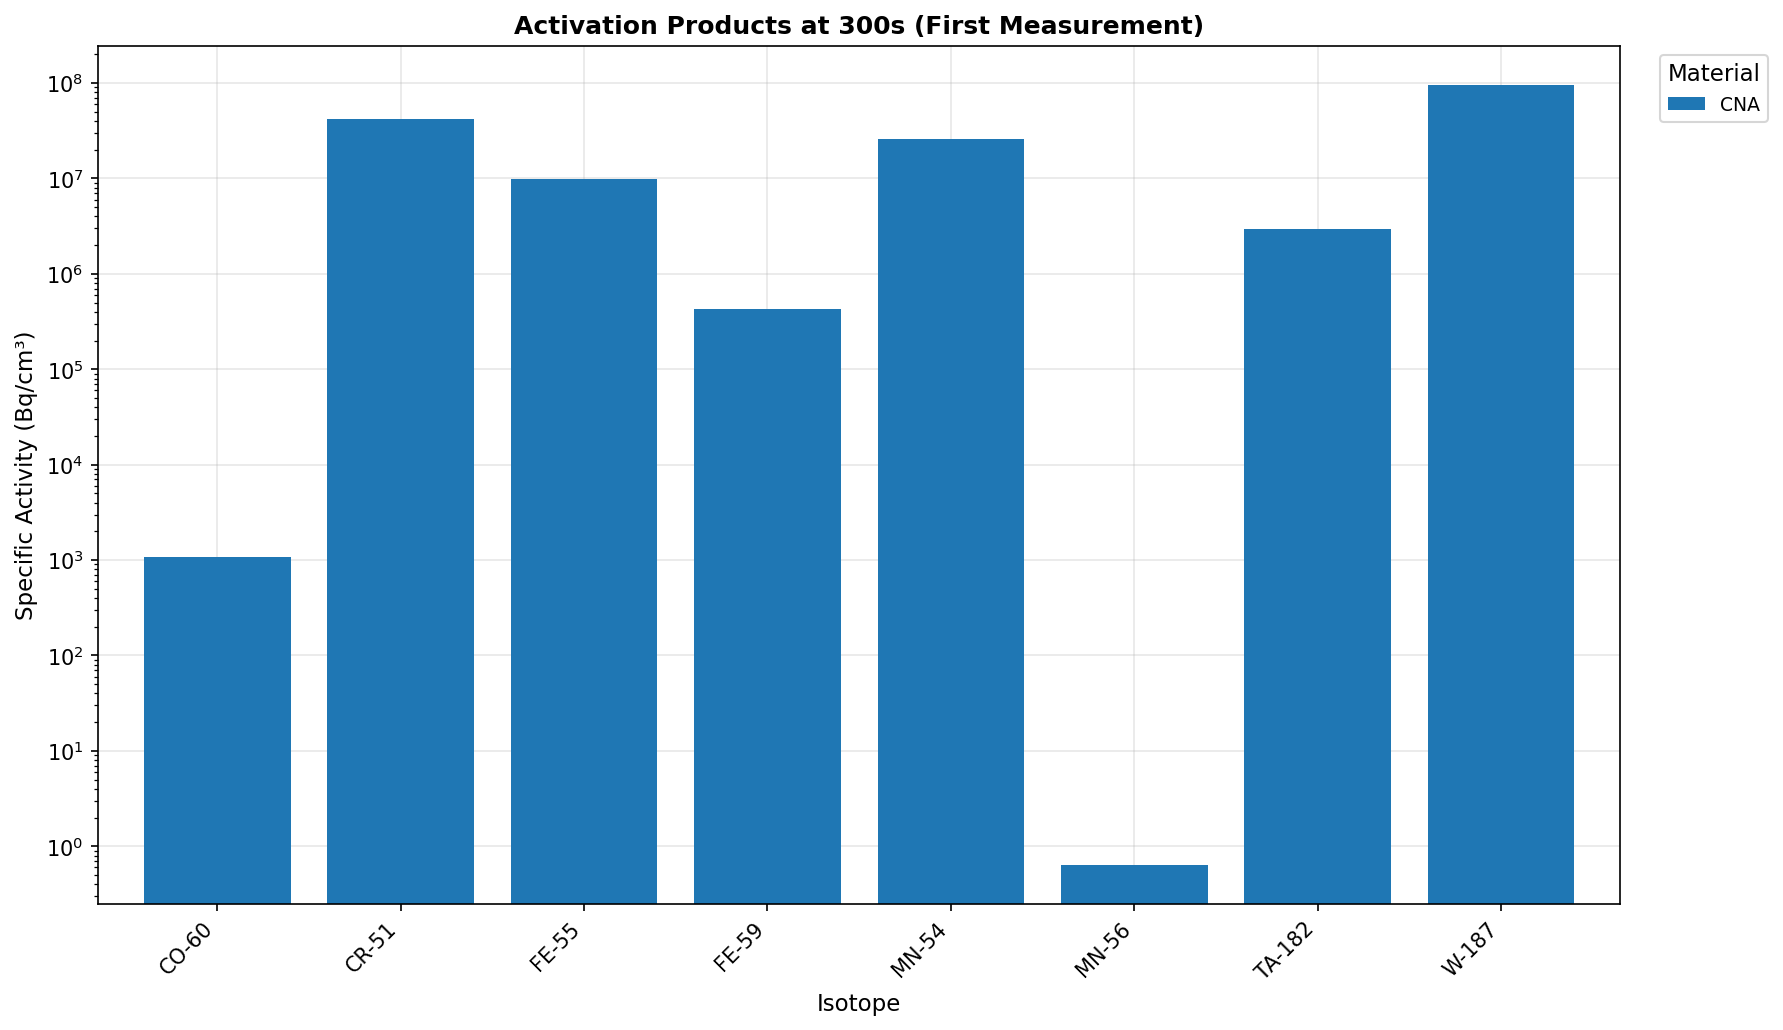

In [80]:
# ==============================================================================
# CROSS-MATERIAL COMPARISON: KEY ACTIVATION PRODUCTS
# ==============================================================================
# Compare specific isotopes across all EUROFER materials.
# Using first experimental measurement time (300s) instead of shutdown.
# Saves plots to alara_output/activity_plots/
# ==============================================================================

# First experimental measurement time after 3s irradiation
FIRST_EXP_TIME = 300  # seconds

if adf is not None and not adf.empty:
    print("=" * 80)
    print("Cross-Material Comparison: Key Activation Products")
    print(f"At first measurement time (300s after irradiation)")
    print("=" * 80)
    
    # Key isotopes to compare
    key_isotopes = ['mn-54', 'mn-56', 'co-60', 'fe-55', 'fe-59', 'cr-51', 'ta-182', 'w-187']
    eurofer_materials = ['CNA', 'EUROFER97_2', 'EUROFER97_3', 'EUROFER97_4']
    
    # Filter for specific activity at first measurement time (300s)
    comparison_data = []
    
    for material in eurofer_materials:
        if material not in adf['run_lbl'].values:
            continue
            
        filtered = adf.filter_rows({
            'run_lbl': material,
            'variable': adf.VARIABLE_ENUM['Specific Activity'],
            'time': float(FIRST_EXP_TIME)  # first measurement (300s)
        })
        
        for iso in key_isotopes:
            iso_data = filtered[filtered['nuclide'] == iso]
            if not iso_data.empty:
                activity = iso_data['value'].values[0]
                comparison_data.append({
                    'Material': material,
                    'Isotope': iso.upper(),
                    'Activity_Bq_cm3': activity
                })
    
    if comparison_data:
        comp_df = pd.DataFrame(comparison_data)
        pivot_comp = comp_df.pivot_table(
            index='Isotope',
            columns='Material',
            values='Activity_Bq_cm3',
            aggfunc='first'
        )
        
        print(f"\nSpecific Activity at 300s (Bq/cm³):")
        print("-" * 60)
        with pd.option_context('display.float_format', '{:.3e}'.format):
            print(pivot_comp.to_string())
        
        # Plot comparison
        fig, ax = plt.subplots(figsize=(12, 7))
        
        # Custom colors for materials
        material_colors = {'CNA': '#1f77b4', 'EUROFER97_2': '#ff7f0e', 
                          'EUROFER97_3': '#2ca02c', 'EUROFER97_4': '#d62728'}
        
        pivot_comp.plot(kind='bar', ax=ax, width=0.8,
                       color=[material_colors.get(c, '#333') for c in pivot_comp.columns])
        
        ax.set_ylabel('Specific Activity (Bq/cm³)', fontsize=11)
        ax.set_xlabel('Isotope', fontsize=11)
        ax.set_title('Activation Products at 300s (First Measurement)', fontsize=12, fontweight='bold')
        ax.set_yscale('log')
        ax.legend(title='Material', bbox_to_anchor=(1.02, 1), loc='upper left')
        ax.grid(True, alpha=0.3, axis='y')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        
        # Save plot
        save_path = activity_plots_dir / 'material_comparison_300s.png'
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"\n✓ Saved: {save_path}")
        plt.show()
    else:
        print("No comparison data found")
else:
    print("⚠ ALARADFrame not available - run previous cells first")

## Experimental Data (loaded in Step 0)

Experimental gamma spectroscopy measurements from RAFM3 irradiation experiments are loaded during Step 0.

**Sample Mapping:**
- **RAFM3-N** → CNA (tally_85214)
- **RAFM3-A** → EUROFER97_2 (tally_85244)
- **RAFM3-B** → EUROFER97_3 (tally_85234)
- **RAFM3-C** → EUROFER97_4 (tally_85224)

**Experimental Cooling Times:**
- 300s EOI (End of Irradiation)
- 2hr EOI
- 24hr EOI
- 4d EOI
- 15d EOI


In [81]:
import re
from pathlib import Path

def parse_experimental_file(filepath):
    """
    Parse a RAFM3 gamma spectroscopy file to extract nuclide activities.
    
    Returns dict of:
        {isotope: {'activity': value, 'uncertainty': value, 'unit': 'uCi', 'half_life': str}}
    """
    nuclides = {}
    
    with open(filepath, 'r', encoding='utf-8', errors='replace') as f:
        content = f.read()
    
    # Find all nuclide activity lines
    # Pattern: "Nuclide   half_life   B   Activity = value ± uncertainty unit"
    # Example: "W187       23.900 h   B                                Activity = 0.519 ± 1.63E-02 uCi"
    # Handle both ± and � (encoding issue)
    pattern = r'^(\w+\d+)\s+(\d+\.?\d*)\s*([smhdywk]+)\s+\w+\s+Activity\s*=\s*([0-9.E+-]+)\s*[±�]\s*([0-9.E+-]+)\s*(\w+)'
    
    for line in content.split('\n'):
        match = re.match(pattern, line.strip(), re.IGNORECASE)
        if match:
            isotope_raw = match.group(1)
            half_life_val = match.group(2)
            half_life_unit = match.group(3)
            activity = float(match.group(4))
            uncertainty = float(match.group(5))
            unit = match.group(6)
            
            # Convert isotope name to ALARA format (e.g., W187 -> w-187)
            iso_match = re.match(r'([A-Za-z]+)(\d+)', isotope_raw)
            if iso_match:
                element = iso_match.group(1).lower()
                mass_num = iso_match.group(2)
                isotope = f"{element}-{mass_num}"
                
                nuclides[isotope] = {
                    'activity': activity,
                    'uncertainty': uncertainty,
                    'unit': unit,
                    'half_life': f"{half_life_val} {half_life_unit}",
                    'rel_unc': uncertainty / activity if activity > 0 else 0
                }
    
    return nuclides

# Sample to material mapping
SAMPLE_TO_MATERIAL = {
    'N': 'CNA',           # tally_85214
    'A': 'EUROFER97_2',   # tally_85244
    'B': 'EUROFER97_3',   # tally_85234
    'C': 'EUROFER97_4',   # tally_85224
}

# Material to tally mapping (excluding SS420)
MATERIAL_TO_TALLY = {
    'CNA': 'tally_85214',
    'EUROFER97_2': 'tally_85244',
    'EUROFER97_3': 'tally_85234',
    'EUROFER97_4': 'tally_85224',
}

# Cooling time mapping from filename to ALARA column
COOLING_TIME_MAP = {
    '300sEOI': '300s',
    '2hrEOI': '2h',
    '24hrEOI': '24h',
    '4dEOI': '4d',
    '15dEOI': '15d',
}

# Load all experimental data - use EXPERIMENTAL_DIR from setup or fallback
exp_data_dir = EXPERIMENTAL_DIR / 'RAFM3' if 'EXPERIMENTAL_DIR' in dir() else Path('alara_inputs/experimental_data/RAFM3')
experimental_data = {}

print("="*80)
print("LOADING EXPERIMENTAL DATA")
print("="*80)
print(f"Looking in: {exp_data_dir}")

for sample_letter in ['A', 'B', 'C', 'N']:
    material = SAMPLE_TO_MATERIAL[sample_letter]
    experimental_data[material] = {}
    
    print(f"\nSample RAFM3-{sample_letter} → {material}:")
    
    for cooling_key, alara_label in COOLING_TIME_MAP.items():
        filename = f"RAFM3-{sample_letter}_{cooling_key}.txt"
        filepath = exp_data_dir / filename
        
        if filepath.exists():
            nuclides = parse_experimental_file(filepath)
            experimental_data[material][alara_label] = nuclides
            print(f"  {cooling_key}: {len(nuclides)} nuclides detected")
            for iso, data in nuclides.items():
                print(f"    {iso}: {data['activity']:.3e} ± {data['uncertainty']:.2e} {data['unit']} (t½={data['half_life']})")
        else:
            print(f"  {cooling_key}: File not found")

# Summary of all experimental isotopes detected
print("\n" + "="*80)
print("EXPERIMENTAL ISOTOPES SUMMARY")
print("="*80)
all_exp_isotopes = set()
for mat_data in experimental_data.values():
    for time_data in mat_data.values():
        all_exp_isotopes.update(time_data.keys())
print(f"Unique isotopes detected in experiments: {sorted(all_exp_isotopes)}")

LOADING EXPERIMENTAL DATA
Looking in: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/irradiation_QG_processed/RAFM3

Sample RAFM3-A → EUROFER97_2:
  300sEOI: 4 nuclides detected
    w-187: 7.470e-01 ± 1.08e-01 uCi (t½=23.900 h)
    mn-56: 1.591e+01 ± 1.09e+00 uCi (t½=2.579 h)
    v-52: 2.593e+03 ± 3.48e+02 uCi (t½=3.743 m)
    al-28: 6.713e+00 ± 4.60e+00 uCi (t½=2.250 m)
  2hrEOI: File not found
  24hrEOI: 3 nuclides detected
    w-187: 5.190e-01 ± 1.63e-02 uCi (t½=23.900 h)
    cr-51: 3.780e-02 ± 1.20e-02 uCi (t½=27.703 d)
    mn-56: 1.850e-02 ± 1.81e-03 uCi (t½=2.579 h)
  4dEOI: 3 nuclides detected
    w-187: 7.010e-02 ± 3.65e-03 uCi (t½=23.900 h)
    cr-51: 5.650e-02 ± 7.52e-03 uCi (t½=27.703 d)
    fe-59: 0.000e+00 ± 0.00e+00 uCi (t½=44.495 d)
  15dEOI: File not found

Sample RAFM3-B → EUROFER97_3:
  300sEOI: 3 nuclides detected
    w-187: 9.840e-01 ± 1.06e-01 uCi (t½=23.900 h)
    mn-56: 1.592e+01 ± 1.10e+00 uCi (t½=2.579 h)
    v-52: 2.564e+03 ± 3.44e+02 uC

## Step 11: Compare ALARA Simulation with Experimental Data

Compare the simulated activities with experimental measurements for each material and cooling time.

**Important Notes:**
- Experimental activities are in **µCi (total sample)** 
- ALARA activities are in **Bq/cm³ (per unit volume)**
- To compare, we need to know the sample volume and flux normalization
- The MCNP flux is normalized by a source strength factor (currently 3.1e13 n/s)
- If ALARA isotopes don't match experimental, it may indicate:
  - Flux normalization is incorrect
  - Irradiation conditions differ from experiment
  - Certain reaction pathways not in the library

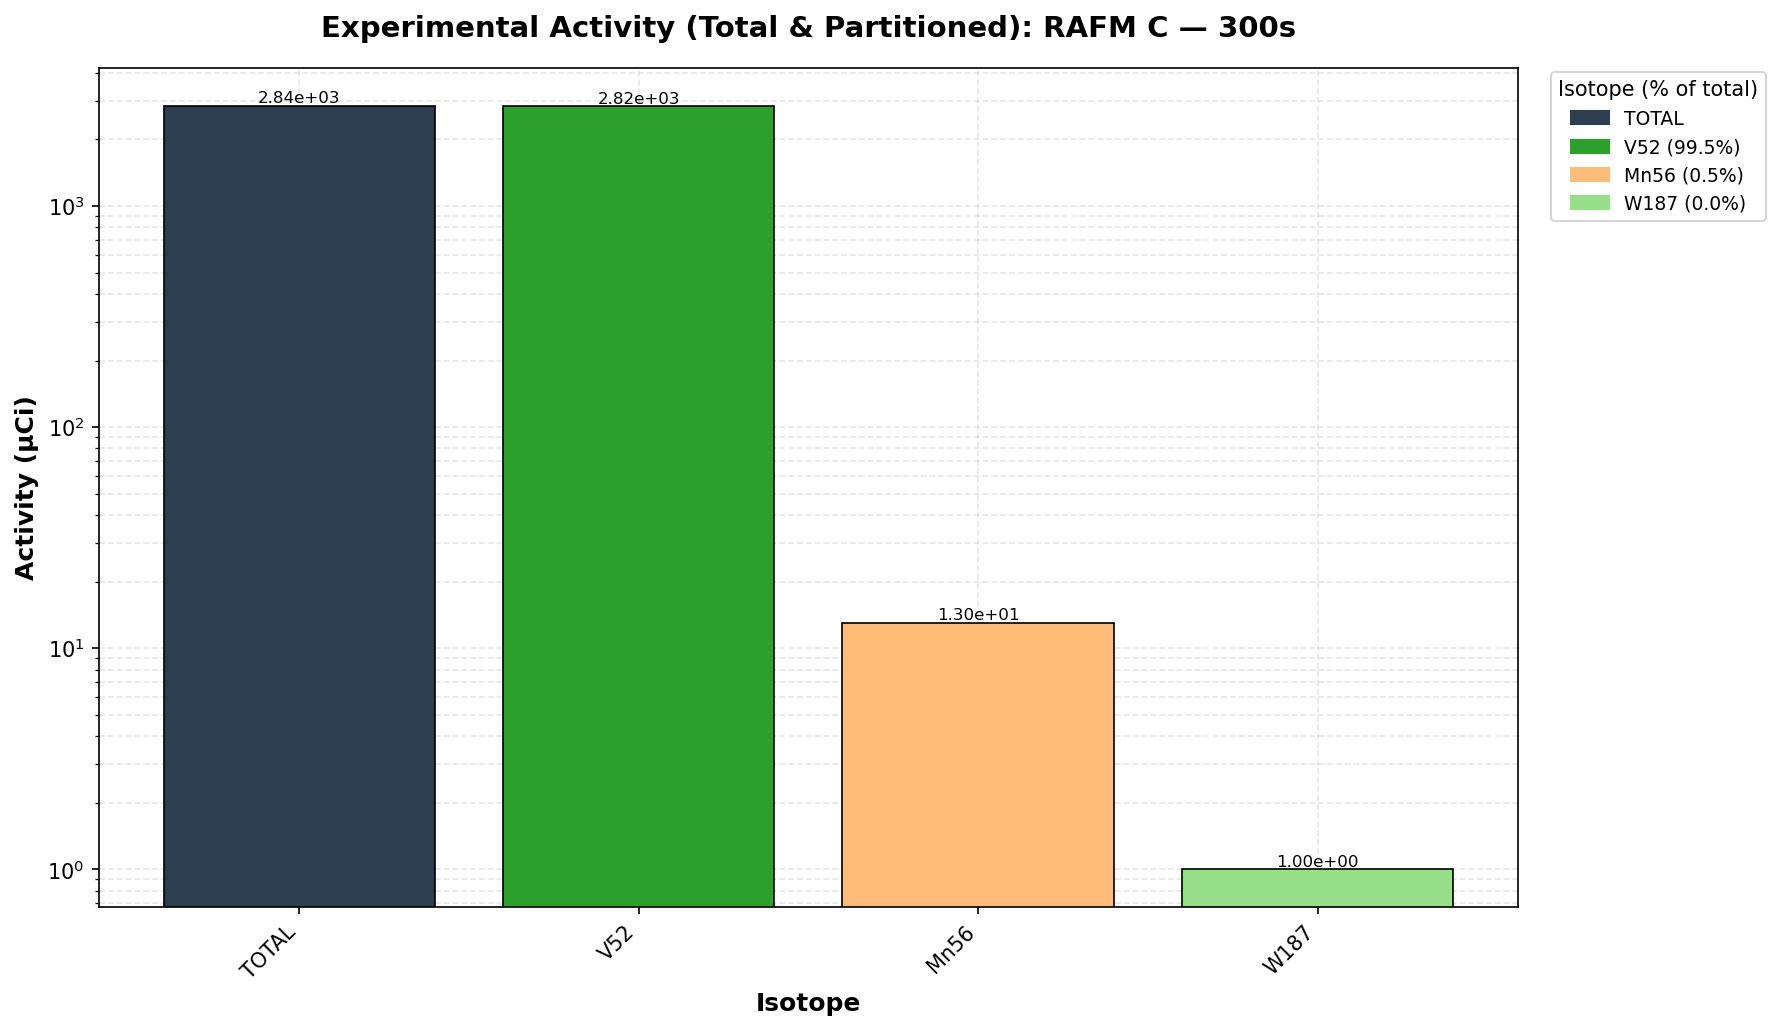

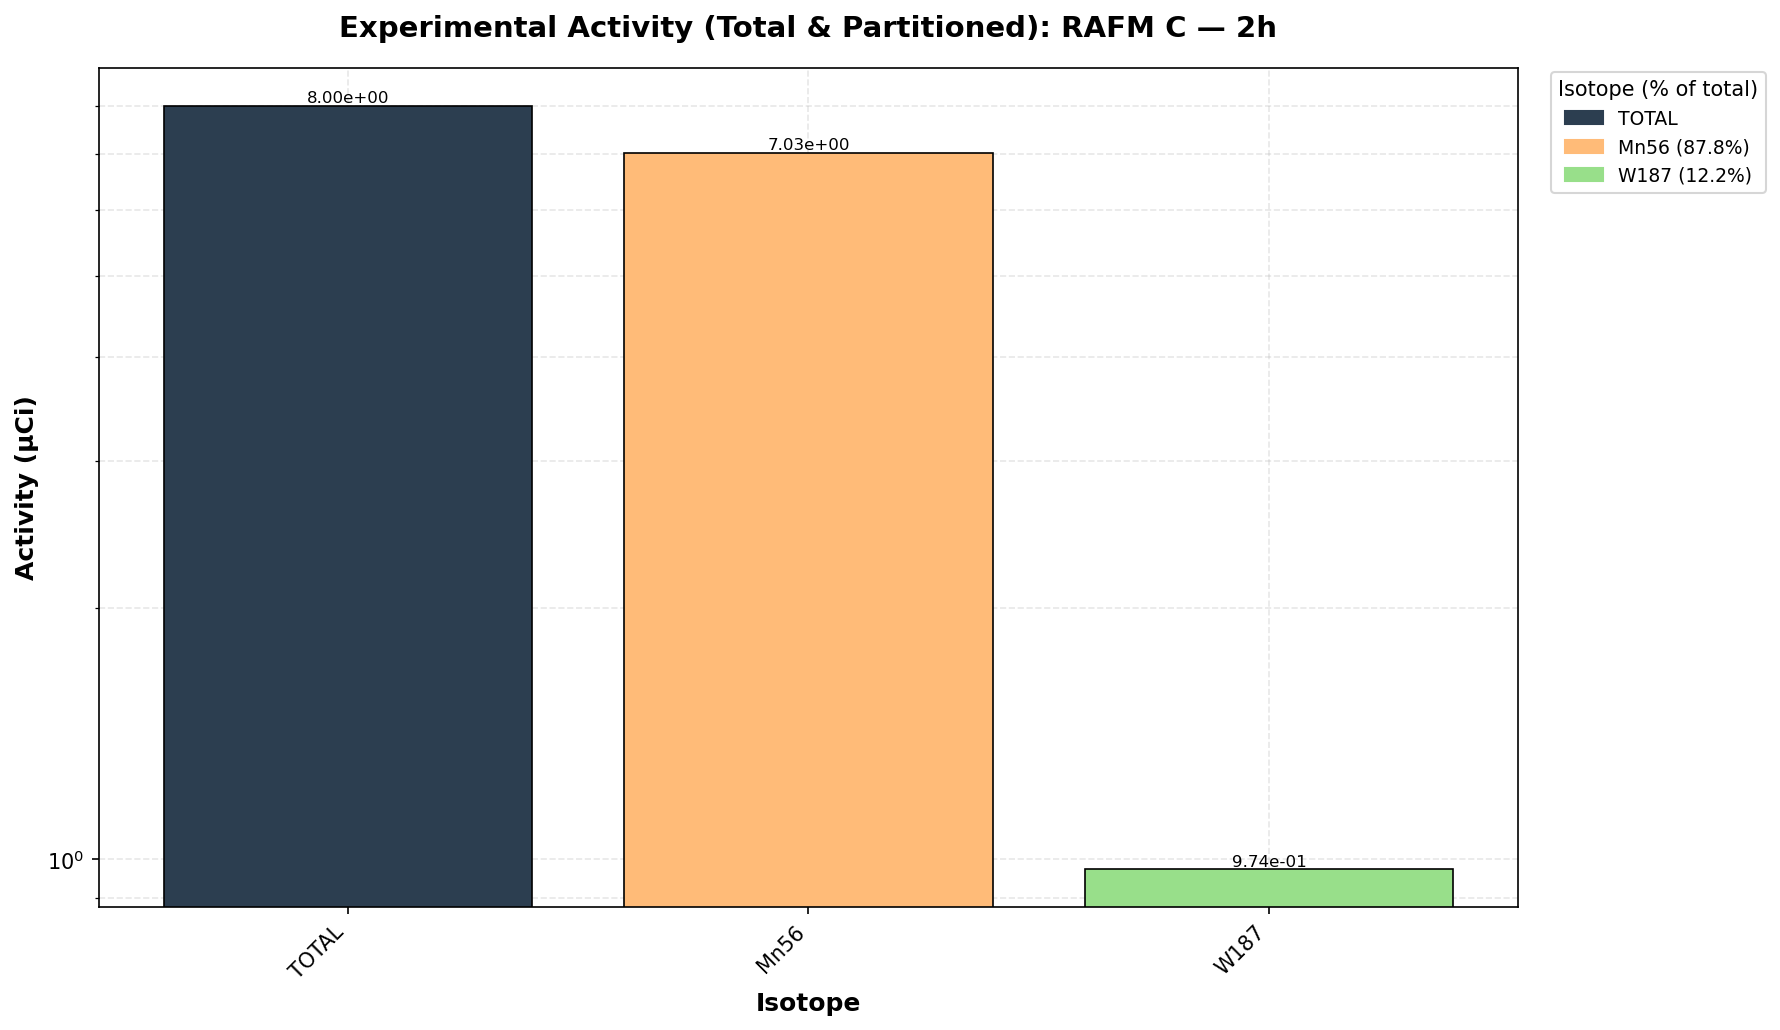

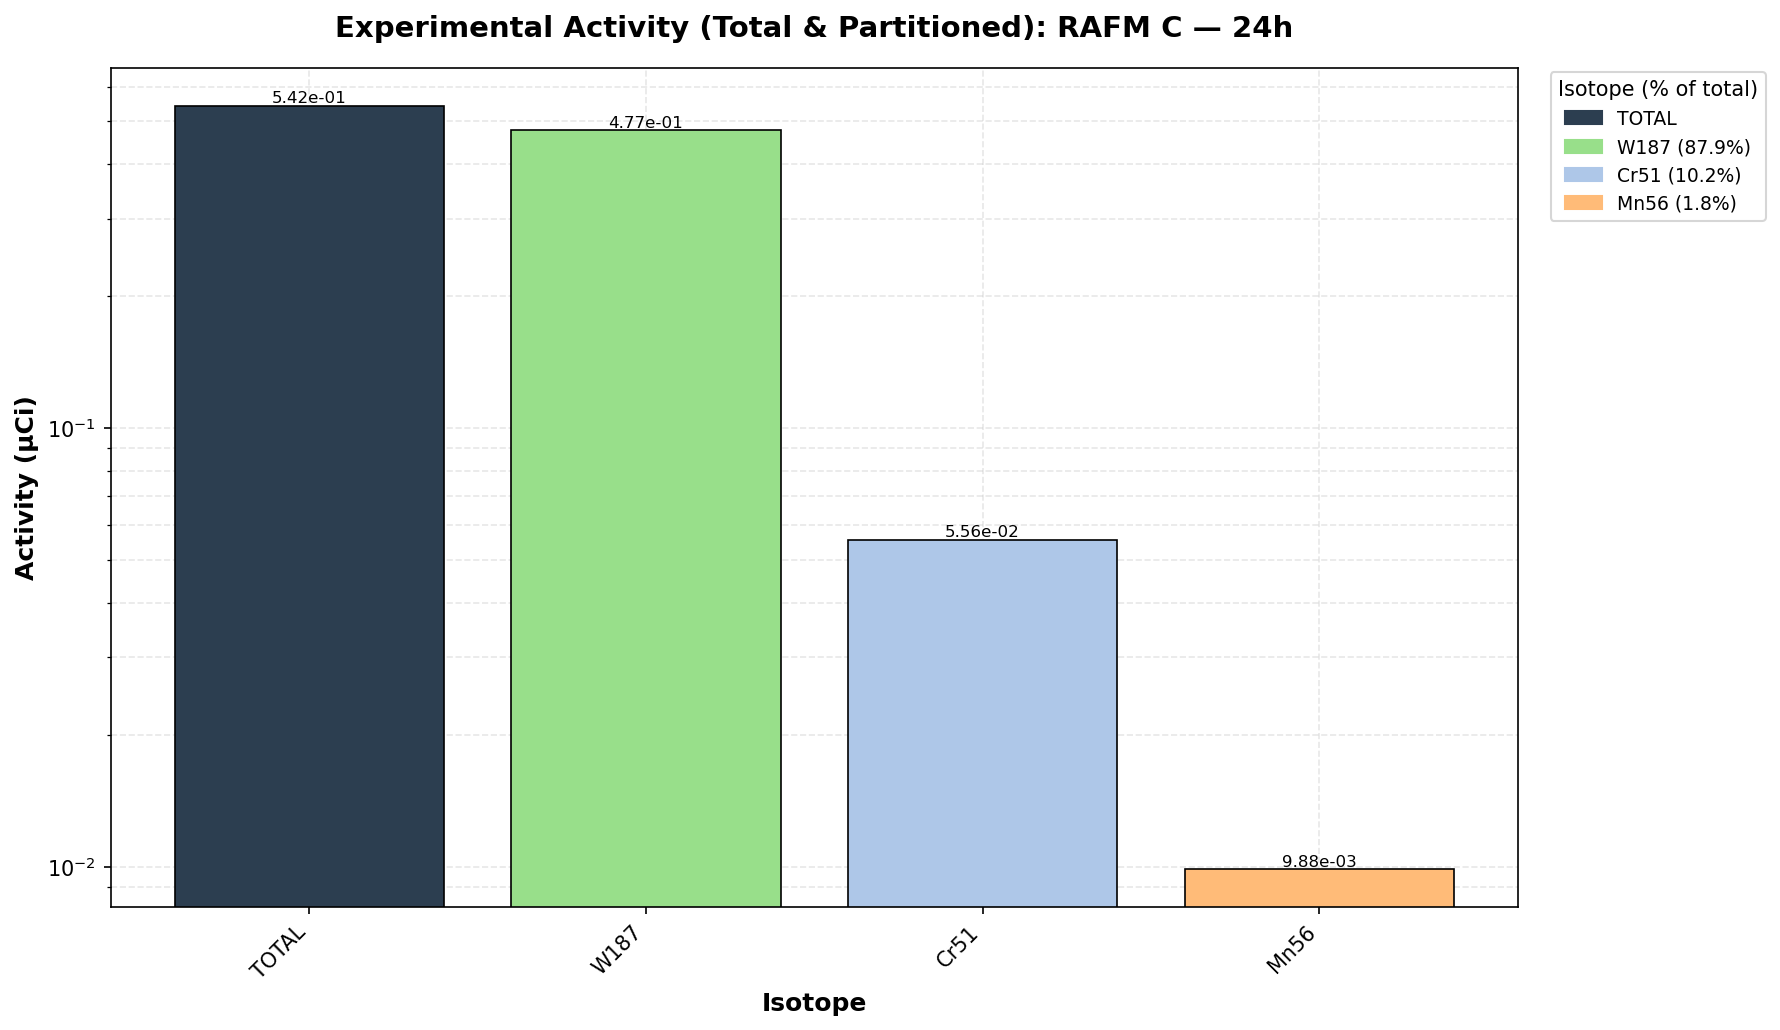

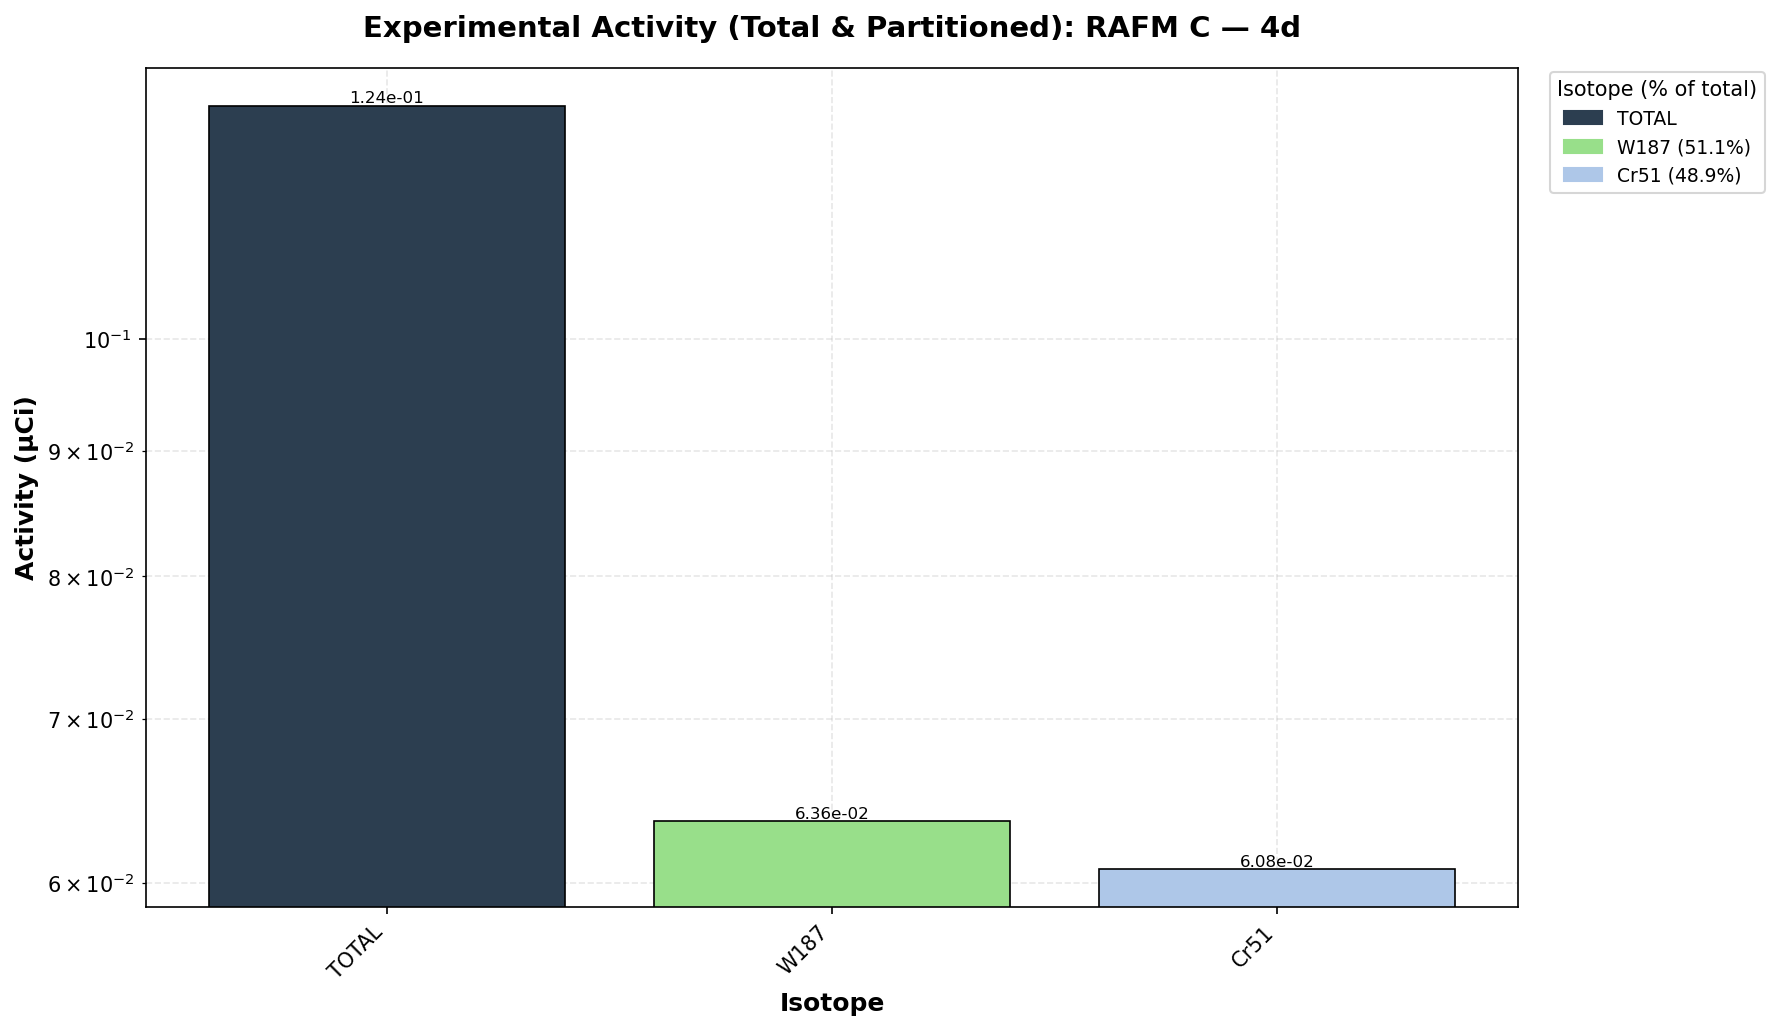

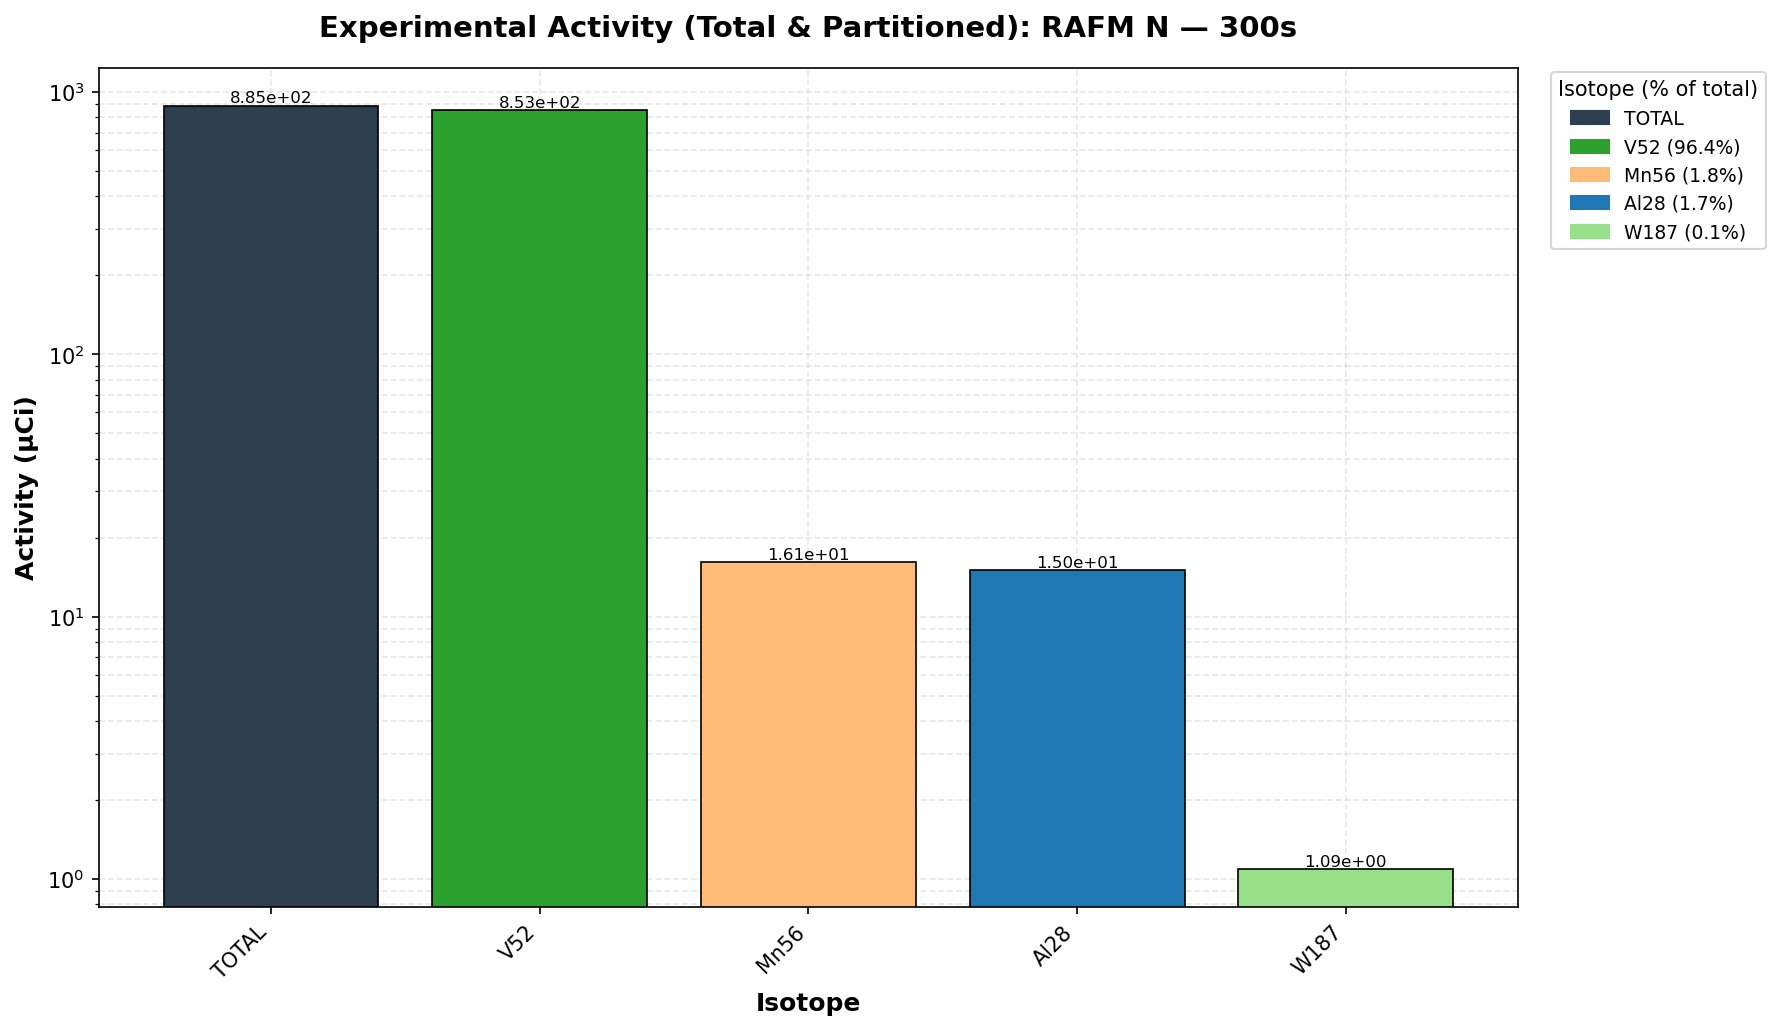

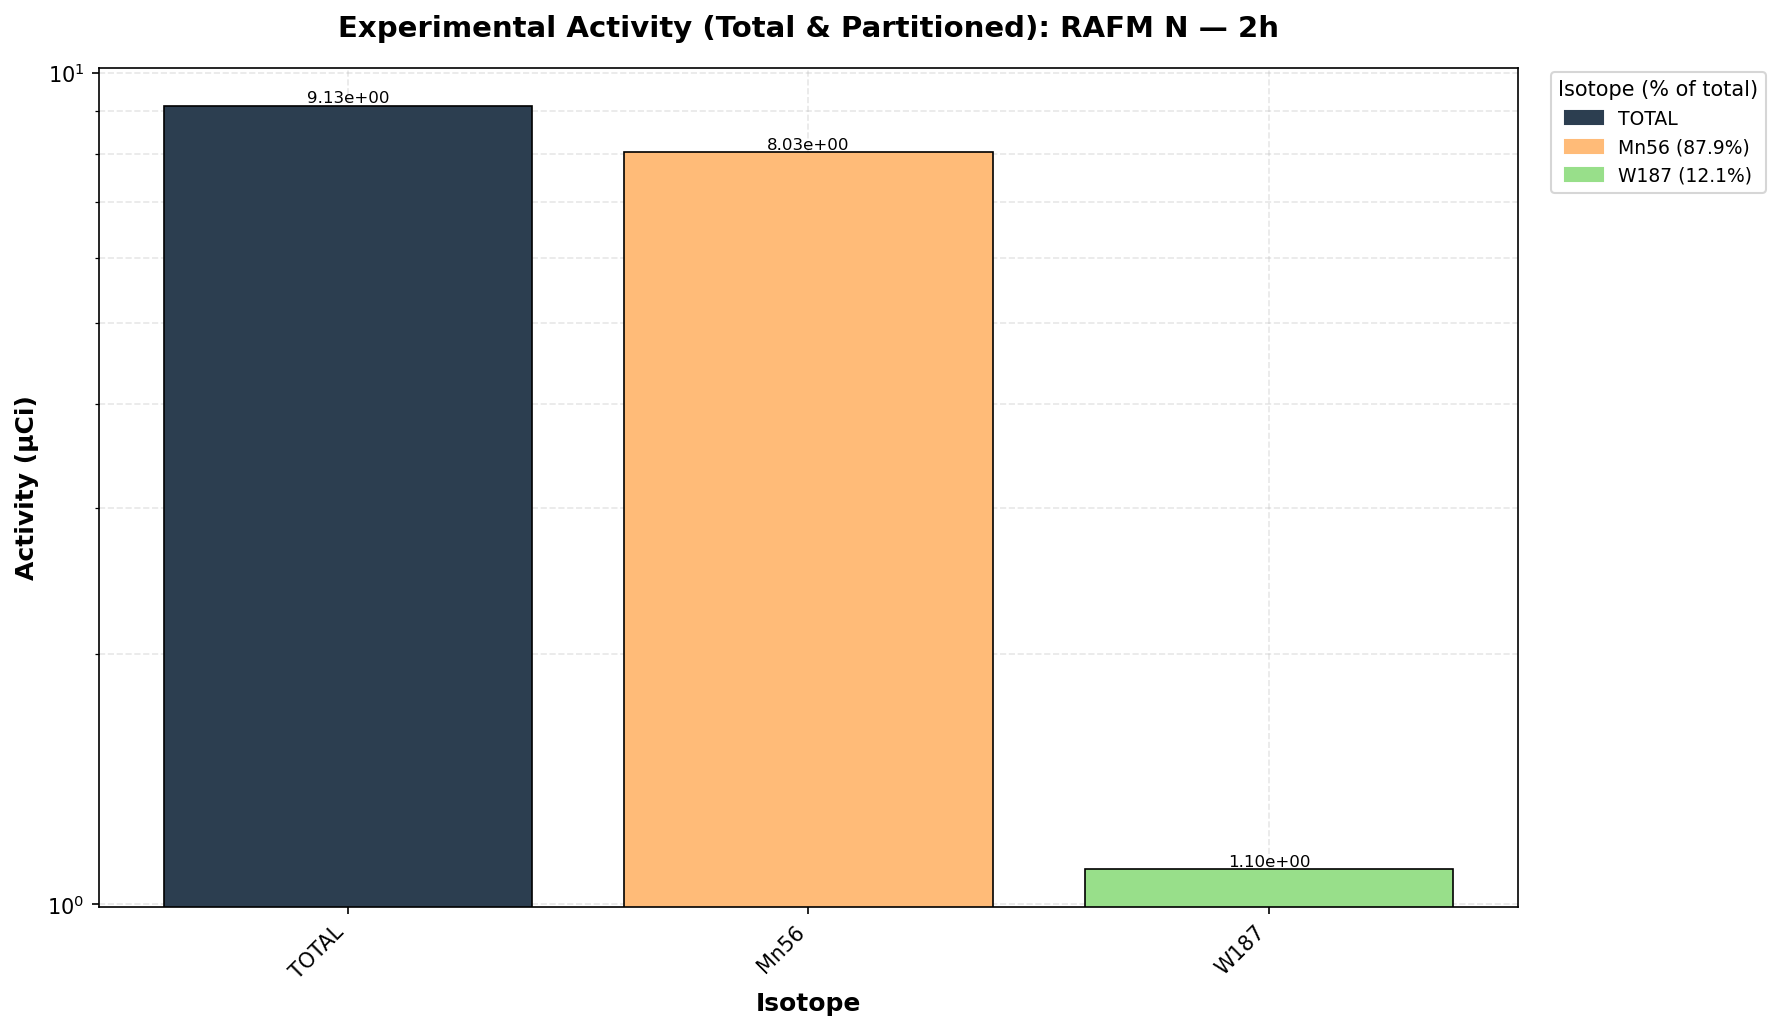

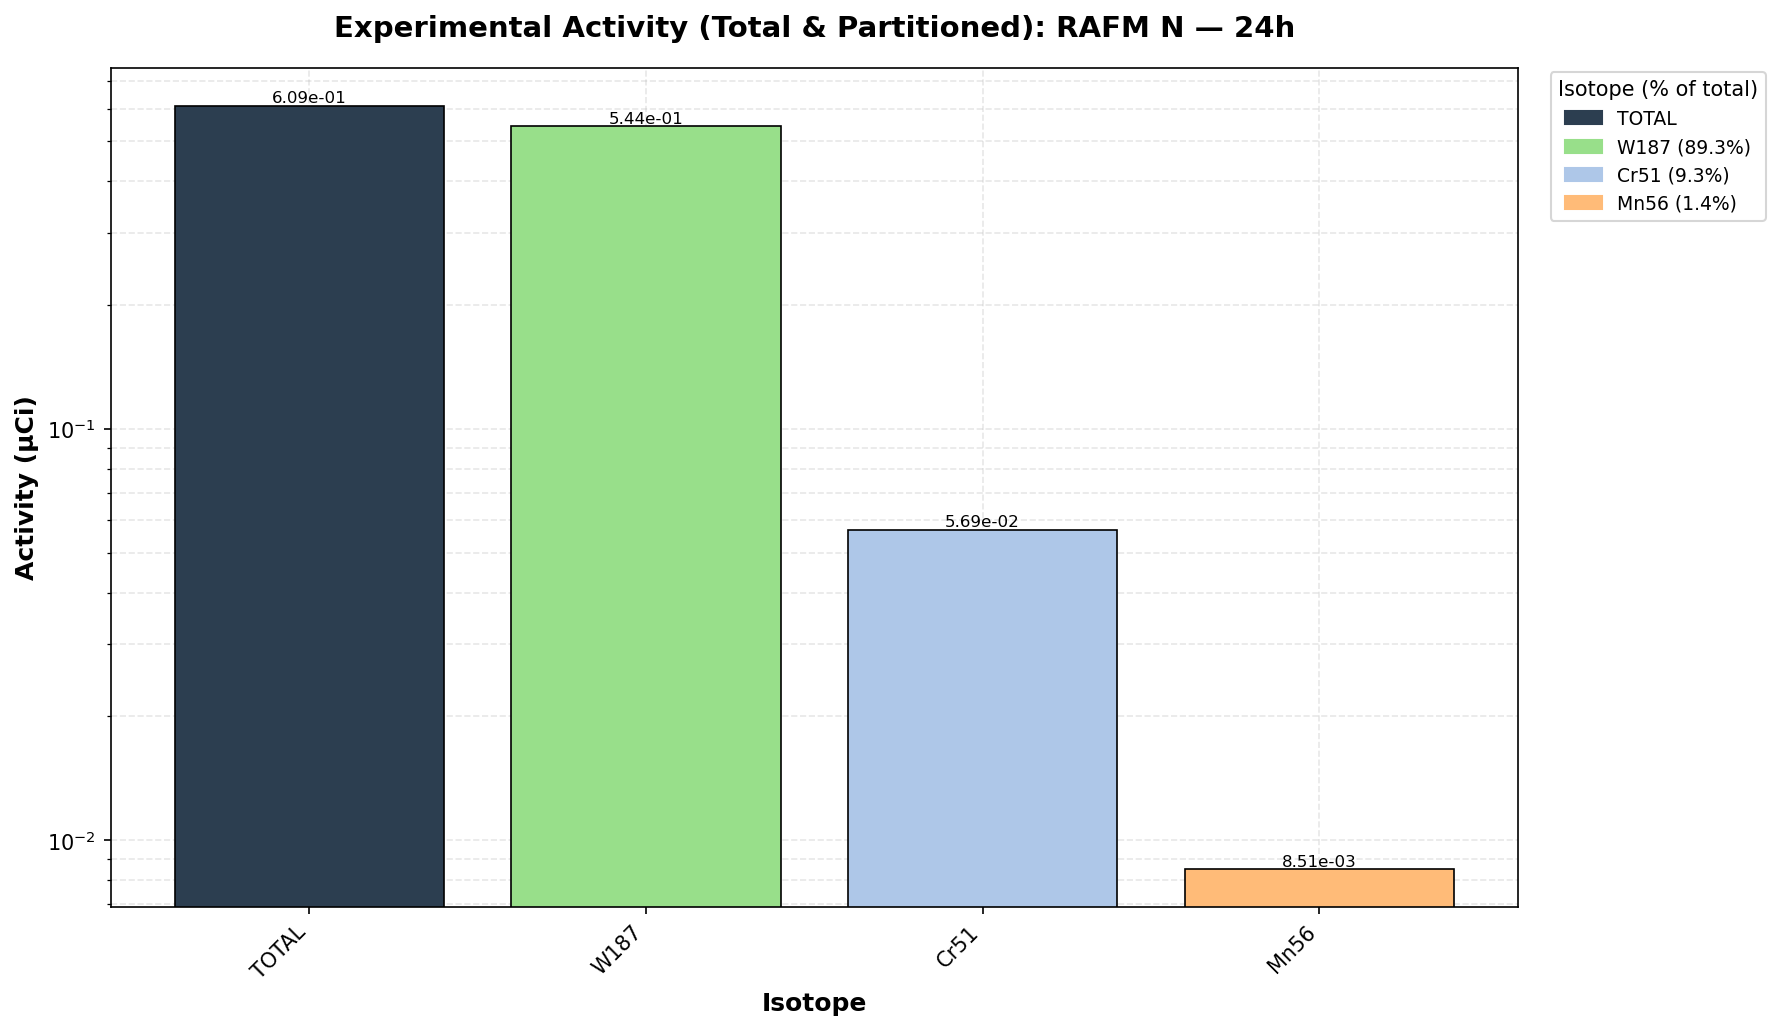

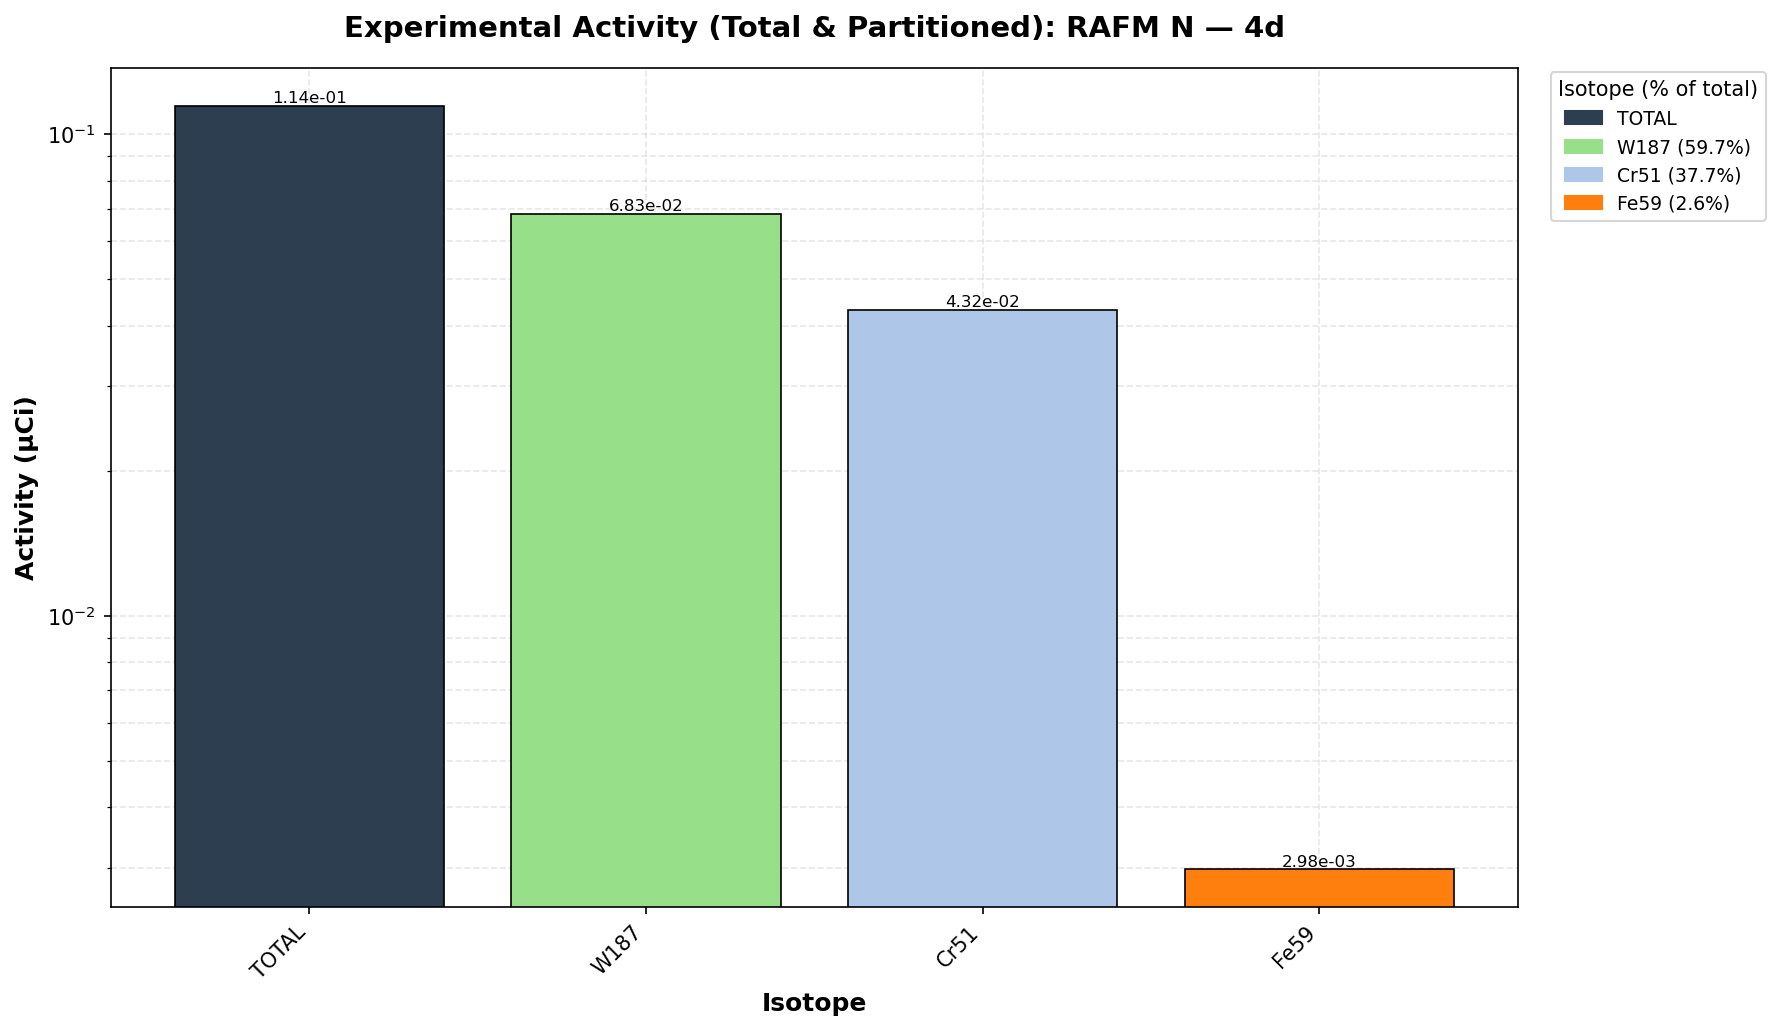


Saved 15 bar chart plots to: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/experimental_activity_bars
Saved plots (showing first 5):
  RAFM_A_300s_activity_bar.png
  RAFM_A_24h_activity_bar.png
  RAFM_A_4d_activity_bar.png
  RAFM_B_300s_activity_bar.png
  RAFM_B_2h_activity_bar.png
  ... and 10 more


In [82]:
# Create bar charts showing total and partitioned activity (log scale)
# Save each material/cooling time combination as a separate plot

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Local canonical_iso fallback
try:
    canonical_iso  # type: ignore[name-defined]
except NameError:
    import re
    def canonical_iso(name: str) -> str:
        n = name.strip().lower().replace('_', '-').replace(' ', '')
        m = re.match(r"^([a-z]+)-?(\d+m?)$", n)
        if m:
            return f"{m.group(1)}-{m.group(2)}"
        return n

# Map materials back to RAFM sample labels
material_to_sample = {v: k for k, v in SAMPLE_TO_MATERIAL.items()} if 'SAMPLE_TO_MATERIAL' in globals() else {}

if 'experimental_data' not in globals() or not experimental_data:
    print('Experimental data not loaded. Ensure the Step 0 data import cell ran successfully.')
else:
    bar_dir = Path(OUTPUT_DIR) / 'experimental_activity_bars'
    bar_dir.mkdir(parents=True, exist_ok=True)

    def activity_to_bq(activity, unit):
        """Best-effort conversion to Bq; defaults to treating values as microcuries."""
        try:
            val = float(activity)
        except Exception:
            return np.nan
        u = (unit or '').lower()
        if 'bq' in u:
            return val
        if 'mbq' in u:
            return val * 1e-3
        if 'kbq' in u:
            return val * 1e3
        if 'ci' in u and 'bq' not in u and 'uci' not in u and 'µci' not in u:
            return val * 3.7e10
        # Treat everything else as microcuries (uCi)
        return val * 37000.0

    def format_iso_pretty(iso: str) -> str:
        # Convert "w-187" -> "W-187", "ta-180m" -> "Ta-180m"
        parts = iso.split('-')
        if len(parts) == 2:
            elem, mass = parts
            elem_fmt = elem.capitalize()
            return f"{elem_fmt}-{mass}"
        return iso.capitalize()

    # Global color map: each isotope gets a unique color reused across all plots
    all_isos = set()
    for _, time_data in experimental_data.items():
        for nuclides in time_data.values():
            for iso in nuclides.keys():
                all_isos.add(canonical_iso(iso))
    all_isos = sorted(all_isos)

    palettes = [
        plt.cm.tab20(np.linspace(0, 1, 20)),
        plt.cm.tab20b(np.linspace(0, 1, 20)),
        plt.cm.tab20c(np.linspace(0, 1, 20)),
    ]
    base_colors = np.vstack(palettes)
    if len(all_isos) > len(base_colors):
        extra = plt.cm.viridis(np.linspace(0, 1, len(all_isos) - len(base_colors)))
        base_colors = np.vstack([base_colors, extra])
    iso_color_map = {iso: base_colors[i] for i, iso in enumerate(all_isos)}

    saved_bar_plots = []
    for material, time_data in experimental_data.items():
        sample_label = material_to_sample.get(material, material)
        for cooling_label, nuclides in time_data.items():
            if not nuclides:
                continue

            rows = []
            for iso, data in nuclides.items():
                act_bq = activity_to_bq(data.get('activity'), data.get('unit'))
                if pd.isna(act_bq) or act_bq <= 0:
                    continue
                rows.append((canonical_iso(iso), act_bq))

            if not rows:
                continue

            df = pd.DataFrame(rows, columns=['isotope', 'activity_Bq']).sort_values('activity_Bq', ascending=False)
            total_bq = df['activity_Bq'].sum()
            total_uCi = total_bq / 37000.0
            df['fraction'] = df['activity_Bq'] / total_bq
            df['isotope_pretty'] = df['isotope'].apply(format_iso_pretty)
            df['activity_uCi'] = df['activity_Bq'] / 37000.0
            df['color'] = df['isotope'].map(iso_color_map)

            # Add TOTAL as first row
            total_row = pd.DataFrame({
                'isotope': ['TOTAL'],
                'activity_Bq': [total_bq],
                'fraction': [1.0],
                'isotope_pretty': ['TOTAL'],
                'activity_uCi': [total_uCi],
                'color': ['#2c3e50']  # Dark blue-gray for total
            })
            df_with_total = pd.concat([total_row, df], ignore_index=True)

            title_label = f"RAFM {sample_label} — {cooling_label}" if sample_label in ['A', 'B', 'C', 'N'] else f"{material} — {cooling_label}"
            
            # Create bar chart with log scale
            fig, ax = plt.subplots(figsize=(12, 7))
            x_pos = np.arange(len(df_with_total))
            bars = ax.bar(x_pos, df_with_total['activity_uCi'], color=df_with_total['color'], edgecolor='black', linewidth=0.8)
            
            # Configure axes
            ax.set_xticks(x_pos)
            ax.set_xticklabels(df_with_total['isotope_pretty'], rotation=45, ha='right', fontsize=10)
            ax.set_yscale('log')
            ax.set_ylabel('Activity (µCi)', fontsize=12, fontweight='bold')
            ax.set_xlabel('Isotope', fontsize=12, fontweight='bold')
            ax.set_title(f"Experimental Activity (Total & Partitioned): {title_label}", fontsize=14, fontweight='bold', pad=15)
            ax.grid(True, which='both', alpha=0.3, linestyle='--')
            ax.set_axisbelow(True)
            
            # Add value labels on bars (only for top N values to avoid clutter)
            top_n = min(8, len(df_with_total))
            for i in range(top_n):
                height = df_with_total.iloc[i]['activity_uCi']
                if height > 0:
                    ax.text(i, height, f'{height:.2e}', 
                           ha='center', va='bottom', fontsize=8, rotation=0)
            
            # Add legend showing fractions for individual isotopes
            if len(df) > 0:
                legend_labels = ['TOTAL'] + [f"{iso} ({frac*100:.1f}%)" for iso, frac in zip(df['isotope_pretty'], df['fraction'])]
                legend_colors = [total_row['color'].iloc[0]] + df['color'].tolist()
                handles = [plt.matplotlib.patches.Patch(color=c, label=l) for c, l in zip(legend_colors, legend_labels)]
                ax.legend(handles=handles, 
                         title="Isotope (% of total)",
                         bbox_to_anchor=(1.02, 1.0),
                         loc='upper left',
                         borderaxespad=0.25,
                         fontsize=9,
                         title_fontsize=10,
                         ncol=1)
            
            plt.tight_layout()
            
            # Save individual plot
            fname = f"RAFM_{sample_label}_{cooling_label}_activity_bar.png" if sample_label in ['A', 'B', 'C', 'N'] else f"{material}_{cooling_label}_activity_bar.png"
            out_path = bar_dir / fname
            plt.savefig(out_path, dpi=300, bbox_inches='tight')
            saved_bar_plots.append(out_path)
            
            # Only display RAFM C (EUROFER97_4) and CNA
            if material in ['EUROFER97_4', 'CNA']:
                plt.show()
            else:
                plt.close(fig)

    print(f'\nSaved {len(saved_bar_plots)} bar chart plots to: {bar_dir}')
    if saved_bar_plots:
        print('Saved plots (showing first 5):')
        for p in saved_bar_plots[:5]:
            print(f"  {p.name}")
        if len(saved_bar_plots) > 5:
            print(f"  ... and {len(saved_bar_plots) - 5} more")

In [83]:
# Helper: list available samples and counts, and make SAMPLE_FILTER configurable
# Set SAMPLE_FILTER_PATTERN to a regex string to filter samples or None to include all samples
SAMPLE_FILTER_PATTERN = '-1($|_)'  # default: keep '-1' wires only
SAMPLE_FILTER = re.compile(SAMPLE_FILTER_PATTERN) if SAMPLE_FILTER_PATTERN else None

if 'flux_wires_df' in globals():
    sample_counts = flux_wires_df['sample'].value_counts()
    print("Available samples and counts:")
    display(sample_counts.to_frame('count'))
    if SAMPLE_FILTER is not None:
        print("Filtering samples using pattern:", SAMPLE_FILTER_PATTERN)
        print("Matching samples:")
        display([s for s in sample_counts.index if SAMPLE_FILTER.search(s)])
    else:
        print("No sample filter applied; all samples shown")
else:
    print("flux_wires_df not present; run the import cell first.")


Available samples and counts:


,count
sample,
Ti-RAFM-1_25cm,3
In-Cd-RAFM-1_25cm,2
Cu-RAFM-1_25cm,1
Cu-Cd-RAFM-1_25cm,1
Fe-Cd-RAFM-1_0cm,1
Ni-RAFM-1_25cm,1
Sc-Cd-RAFM-1_25cm,1
Sc-RAFM-1_25cm,1


Filtering samples using pattern: -1($|_)
Matching samples:


['Ti-RAFM-1_25cm',
 'In-Cd-RAFM-1_25cm',
 'Cu-RAFM-1_25cm',
 'Cu-Cd-RAFM-1_25cm',
 'Fe-Cd-RAFM-1_0cm',
 'Ni-RAFM-1_25cm',
 'Sc-Cd-RAFM-1_25cm',
 'Sc-RAFM-1_25cm']

flux_wires_df columns: ['sample', 'isotope', 'half_life', 'activity_raw', 'unit', 'activity_Bq', 'activity_uCi', 'uncertainty_Bq', 'uncertainty_uCi', 'mass_g', 'specific_activity_Bq_per_g', 'specific_activity_uCi_per_g', 'specific_activity_uCi_per_g_unc', 'irradiation_seconds', 'decay_seconds', 'measurement_datetime', 'phi', 'phi_unc']


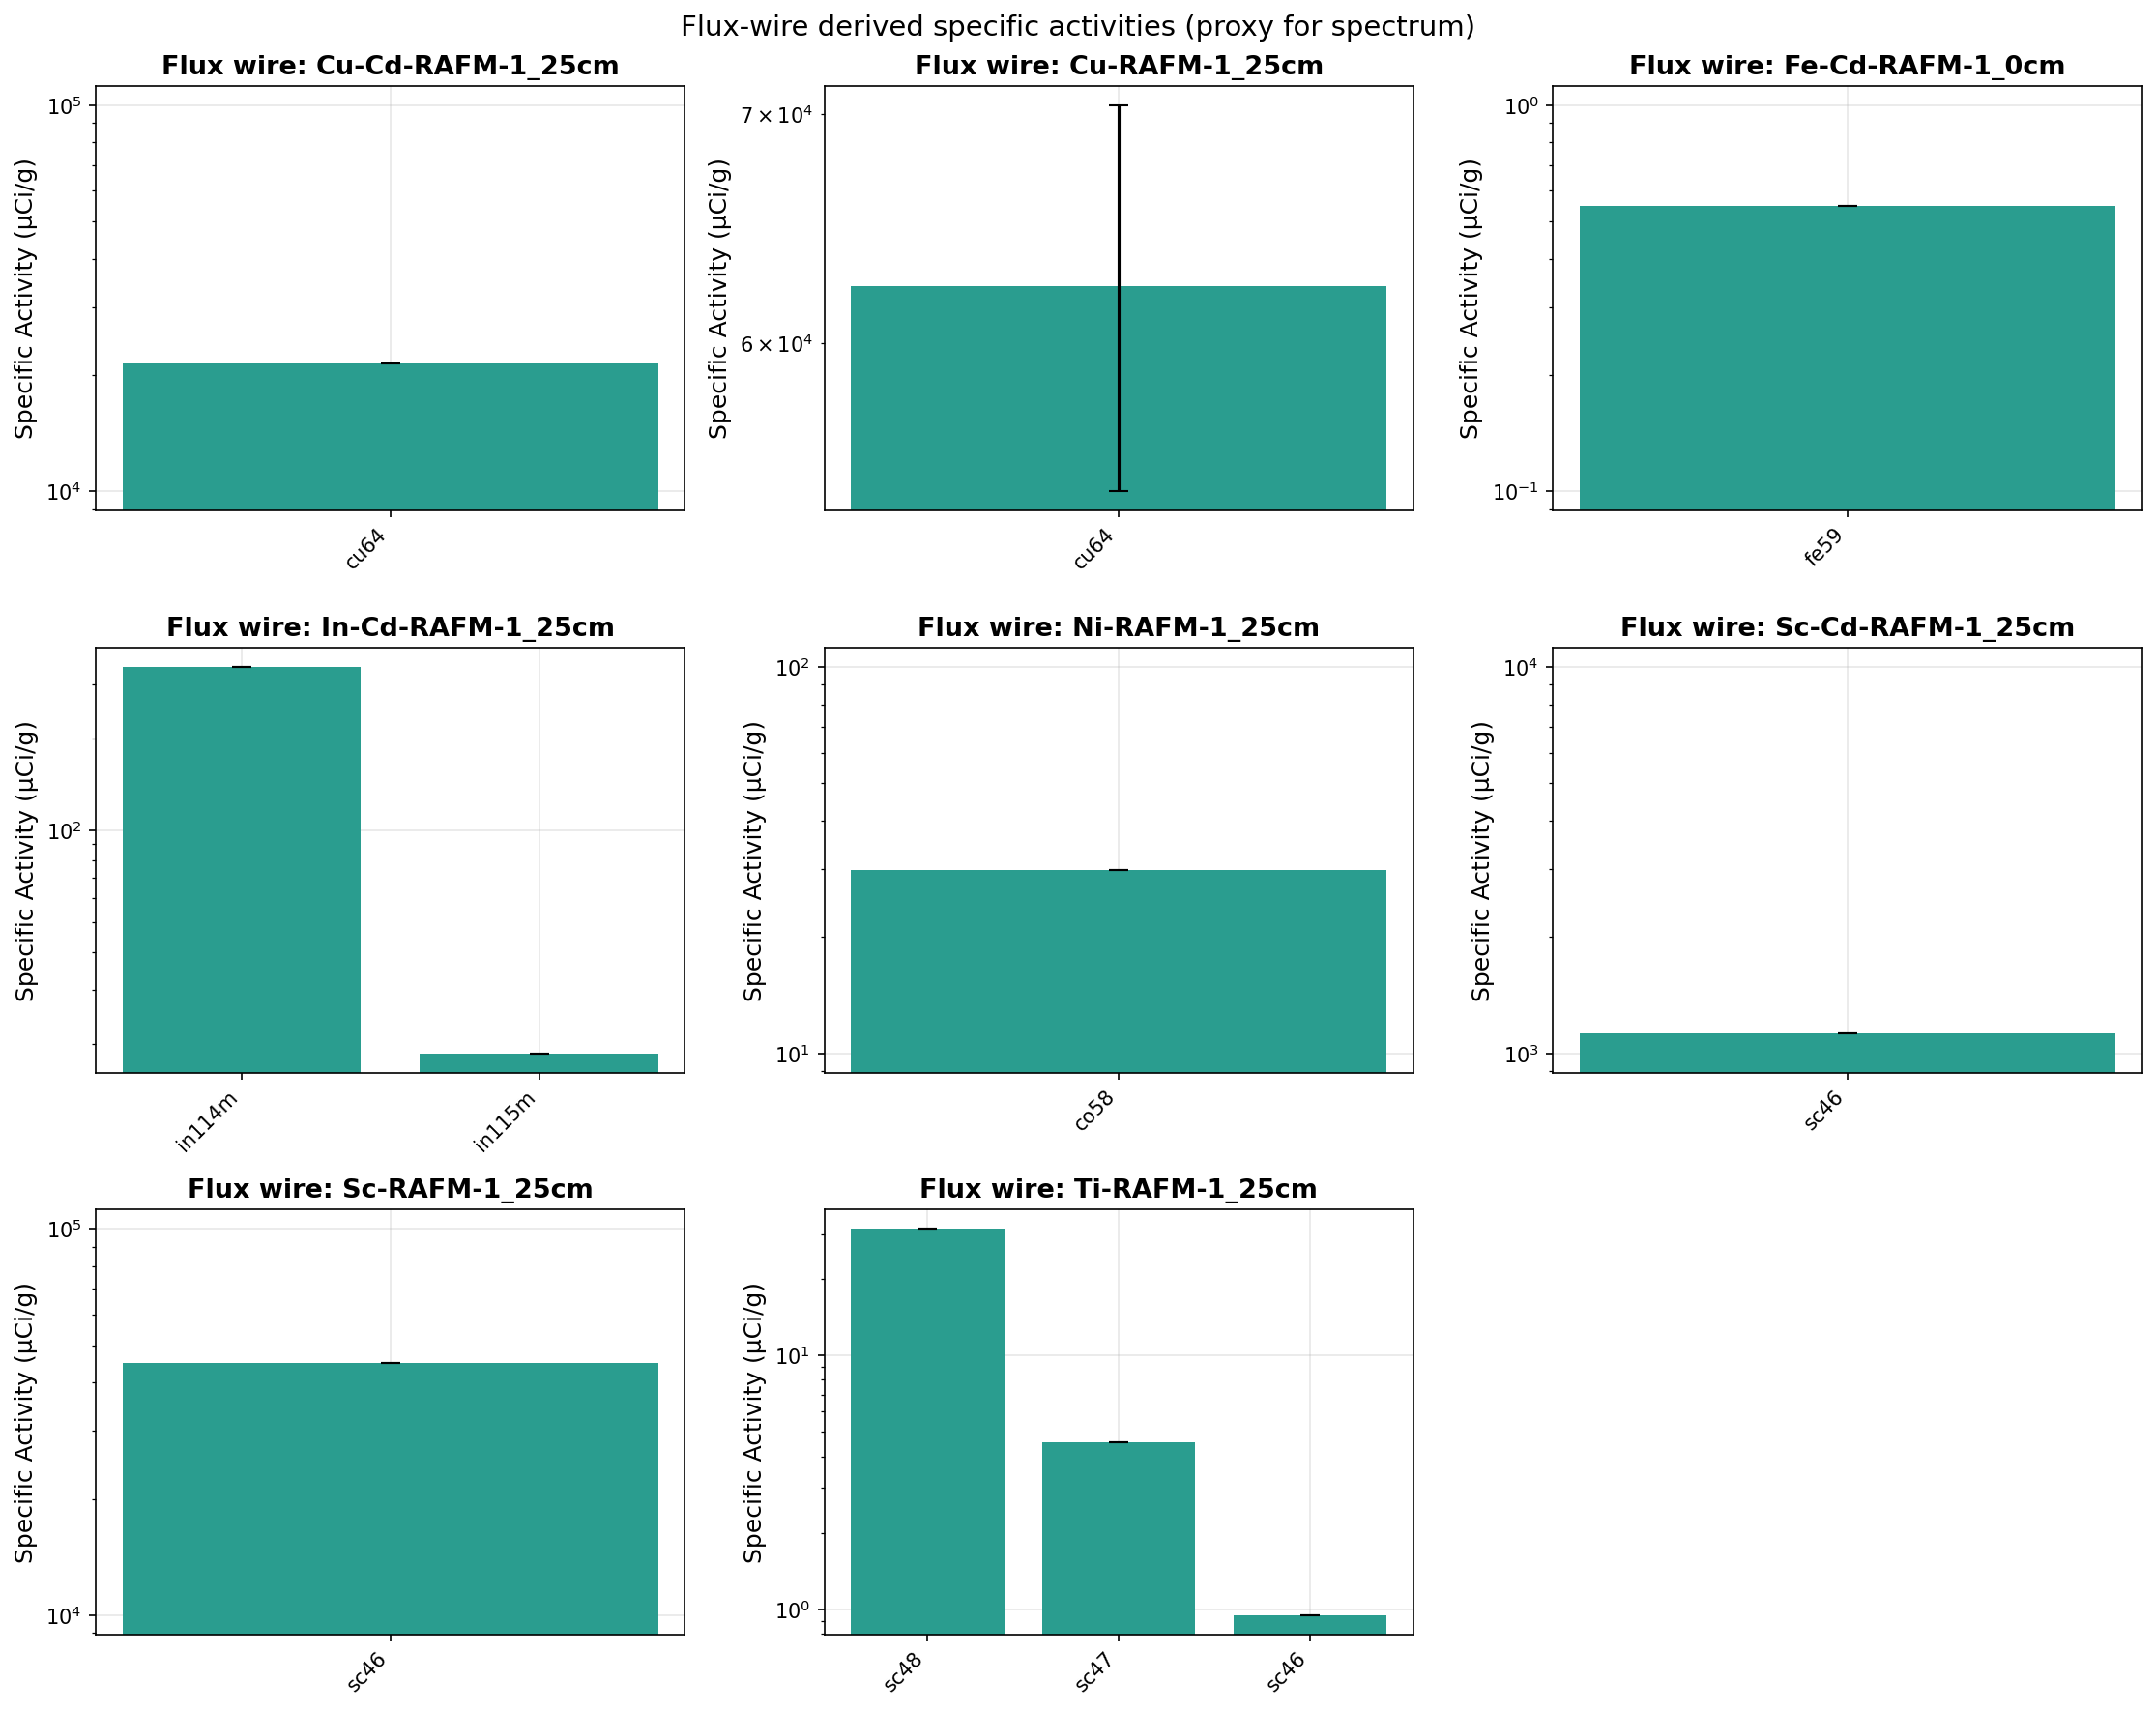

Saved flux wire plot to: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/flux_wire_specific_activity.png


In [84]:
# Plot flux-wire specific activities (proxy for flux spectrum)
# Notes:
# - Assumes flux_wires_df already built above (1 g per wire). Adjust mass when available.
# - SOURCE_STRENGTH used elsewhere (e.g., 3.1e13 n/s) should be revisited to align with these measurements.

if 'flux_wires_df' not in globals():
    print("Flux wire data not loaded yet. Run the flux wire import cell first.")
else:
    if flux_wires_df.empty:
        print("Flux wire table is empty; nothing to plot.")
    else:
        # ensure we have a µCi/g column - fallback to Bq/g if needed
        df_plot = flux_wires_df.copy()
        print(f"flux_wires_df columns: {list(df_plot.columns)}")
        if df_plot[['activity_raw', 'unit', 'activity_Bq', 'specific_activity_Bq_per_g', 'mass_g']].isna().sum().sum() > 0:
            # helpful debug info - non-blocking
            print("Note: Some activity/mass columns contain NaNs; see head for details.")
            display(df_plot.head())

        if 'specific_activity_uCi_per_g' not in df_plot.columns:
            if 'specific_activity_Bq_per_g' in df_plot.columns:
                df_plot['specific_activity_uCi_per_g'] = df_plot['specific_activity_Bq_per_g'] / 37000.0
            elif 'activity_Bq' in df_plot.columns and 'mass_g' in df_plot.columns:
                mass_safe = df_plot['mass_g'].replace(0, np.nan).astype(float)
                df_plot['specific_activity_Bq_per_g'] = df_plot['activity_Bq'] / mass_safe
                df_plot['specific_activity_uCi_per_g'] = df_plot['specific_activity_Bq_per_g'] / 37000.0
            else:
                # As last resort, attempt to reconstruct from raw activity/unit and mass
                def to_Bq(row):
                    try:
                        val = float(row['activity_raw'])
                    except Exception:
                        return np.nan
                    u = (row.get('unit') or '').lower()
                    if 'uci' in u or 'µci' in u or 'uc' in u:
                        return val * 37000.0
                    elif 'bq' in u:
                        return val
                    else:
                        return val * 37000.0
                df_plot['activity_Bq'] = df_plot.apply(to_Bq, axis=1)
                mass_safe = df_plot.get('mass_g', pd.Series(np.nan, index=df_plot.index)).replace(0, np.nan).astype(float)
                df_plot['specific_activity_Bq_per_g'] = df_plot['activity_Bq'] / mass_safe
                df_plot['specific_activity_uCi_per_g'] = df_plot['specific_activity_Bq_per_g'] / 37000.0

        # compute specific activity uncertainties in µCi/g when possible
        if 'uncertainty_Bq' in df_plot.columns and 'mass_g' in df_plot.columns:
            mass_safe = df_plot['mass_g'].replace(0, np.nan).astype(float)
            df_plot['specific_activity_uCi_per_g_unc'] = df_plot['uncertainty_Bq'] / 37000.0 / mass_safe
        else:
            df_plot['specific_activity_uCi_per_g_unc'] = np.nan

        if ('specific_activity_uCi_per_g' not in df_plot.columns) and ('activity_Bq' not in df_plot.columns):
            print('Unable to compute specific_activity_uCi_per_g for plotting. Check that activity_Bq or specific_activity_Bq_per_g are present.')

        # Choose the column to plot; prefer µCi/g for familiarity
        plot_col = 'specific_activity_uCi_per_g' if 'specific_activity_uCi_per_g' in df_plot.columns else 'specific_activity_Bq_per_g'
        y_label = 'Specific Activity (µCi/g)' if plot_col.endswith('uCi_per_g') else 'Specific Activity (Bq/g)'

        # Optional sample filtering by pattern; uses SAMPLE_FILTER_RE by default to select '-1' wires
        if 'SAMPLE_FILTER_RE' in globals():
            samples = [s for s in df_plot['sample'].unique() if SAMPLE_FILTER_RE.search(s)]
        else:
            samples = df_plot['sample'].unique()

        n_cols = min(len(samples), 3)
        n_rows = int(np.ceil(len(samples) / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)
        axes = axes.flatten()
        for idx, sample in enumerate(samples):
            ax = axes[idx]
            sub = df_plot[df_plot['sample'] == sample].groupby('isotope', as_index=False)[[plot_col, 'specific_activity_uCi_per_g_unc']].sum().sort_values(plot_col, ascending=False)
            x = np.arange(len(sub))
            # Display errorbars when available
            if 'specific_activity_uCi_per_g_unc' in sub.columns and not sub['specific_activity_uCi_per_g_unc'].isna().all():
                ax.bar(x, sub[plot_col], yerr=sub['specific_activity_uCi_per_g_unc'], color='#2a9d8f', capsize=5)
            else:
                ax.bar(x, sub[plot_col], color='#2a9d8f')
            ax.set_xticks(x)
            ax.set_xticklabels(sub['isotope'], rotation=45, ha='right')
            ax.set_yscale('log')
            ax.set_ylabel(y_label)
            ax.set_title(f"Flux wire: {sample}")
            ax.grid(True, alpha=0.3)
        # Hide unused axes
        for j in range(idx + 1, len(axes)):
            axes[j].set_visible(False)
        plt.suptitle('Flux-wire derived specific activities (proxy for spectrum)', fontsize=14)
        plt.tight_layout()
        # Save plot
        out_path = os.path.join(OUTPUT_DIR, 'flux_wire_specific_activity.png')
        plt.savefig(out_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Saved flux wire plot to: {out_path}")


### Combined Neutron Spectrum Proxy (Energy vs Estimated Flux)

Maps activities to a representative neutron energy per isotope and plots experimental and flux-wire points together.

In [85]:
# Flux wire timing/mass summary (all parsed wires)
if 'flux_wires_df' not in globals() or flux_wires_df.empty:
    print("Flux wire data not loaded. Run the flux wire import cell first.")
else:
    summary_cols = flux_wires_df.copy()
    summary_cols['irradiation_hours'] = summary_cols.get('irradiation_seconds', pd.NA) / 3600.0
    summary_cols['decay_hours'] = summary_cols.get('decay_seconds', pd.NA) / 3600.0
    summary_view = summary_cols[['sample', 'isotope', 'mass_g', 'irradiation_seconds', 'irradiation_hours', 'decay_seconds', 'decay_hours']]
    summary_view = summary_view.sort_values(['sample', 'isotope'])
    display(summary_view)
    print("Note: decay time assumes irradiation ended at 11:00 on the 4th; parsed from file timestamp when explicit measurement time unavailable.")


,sample,isotope,mass_g,irradiation_seconds,irradiation_hours,decay_seconds,decay_hours
0,Cu-Cd-RAFM-1_25cm,cu64,0.001375,7200,2.0,357.0,0.099167
1,Cu-RAFM-1_25cm,cu64,0.001375,7200,2.0,357.0,0.099167
2,Fe-Cd-RAFM-1_0cm,fe59,0.003021,7200,2.0,357.0,0.099167
3,In-Cd-RAFM-1_25cm,in114m,0.017364,7200,2.0,357.0,0.099167
4,In-Cd-RAFM-1_25cm,in115m,0.017364,7200,2.0,357.0,0.099167
5,Ni-RAFM-1_25cm,co58,0.041675,7200,2.0,357.0,0.099167
6,Sc-Cd-RAFM-1_25cm,sc46,0.003828,7200,2.0,357.0,0.099167
7,Sc-RAFM-1_25cm,sc46,0.000964,7200,2.0,357.0,0.099167
10,Ti-RAFM-1_25cm,sc46,0.013499,7200,2.0,357.0,0.099167
8,Ti-RAFM-1_25cm,sc47,0.013499,7200,2.0,357.0,0.099167


Note: decay time assumes irradiation ended at 11:00 on the 4th; parsed from file timestamp when explicit measurement time unavailable.



Flux wire computed values:


,sample,product,activity_Bq,uncertainty_Bq,N_atoms,sigma_cm2,S,D,denom,phi,phi_unc
0,Cu-Cd-RAFM-1_25cm,cu64,1090982.00,NaN,1.314165e+19,4.970000e-24,0.103403,0.994603,6.717191e-06,1.624164e+11,NaN
1,Cu-RAFM-1_25cm,cu64,3172380.00,409923.0,1.314165e+19,4.500000e-24,0.103403,0.994603,6.081964e-06,5.216046e+11,6.739978e+10
2,Fe-Cd-RAFM-1_0cm,fe59,61.42,NaN,3.136601e+19,1.250000e-24,0.001297,0.999936,5.086189e-08,1.207584e+09,NaN
3,In-Cd-RAFM-1_25cm,in114m,219706.00,NaN,9.253845e+19,3.252000e-22,0.001166,0.999942,3.508695e-05,6.261758e+09,NaN
4,In-Cd-RAFM-1_25cm,in115m,11988.00,NaN,9.092909e+19,1.831000e-25,0.265890,0.984791,4.359497e-06,2.749858e+09,NaN
5,Ni-RAFM-1_25cm,co58,45880.00,NaN,4.327085e+20,1.132000e-25,0.000815,0.999960,3.991079e-08,1.149564e+12,NaN
6,Sc-Cd-RAFM-1_25cm,sc46,159063.00,NaN,5.123504e+19,1.183000e-23,0.000689,0.999966,4.175761e-07,3.809198e+11,NaN
7,Sc-RAFM-1_25cm,sc46,1607650.00,NaN,1.290746e+19,2.714000e-23,0.000689,0.999966,2.413428e-07,6.661272e+12,NaN
8,Ti-RAFM-1_25cm,sc46,473.60,NaN,1.767184e+20,1.316000e-26,0.000689,0.999966,1.602218e-09,2.955903e+11,NaN
9,Ti-RAFM-1_25cm,sc47,2271.80,NaN,1.729584e+20,2.400000e-26,0.017100,0.999145,7.092034e-08,3.203313e+10,NaN


Saved: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/flux_wire_energy_vs_flux.png


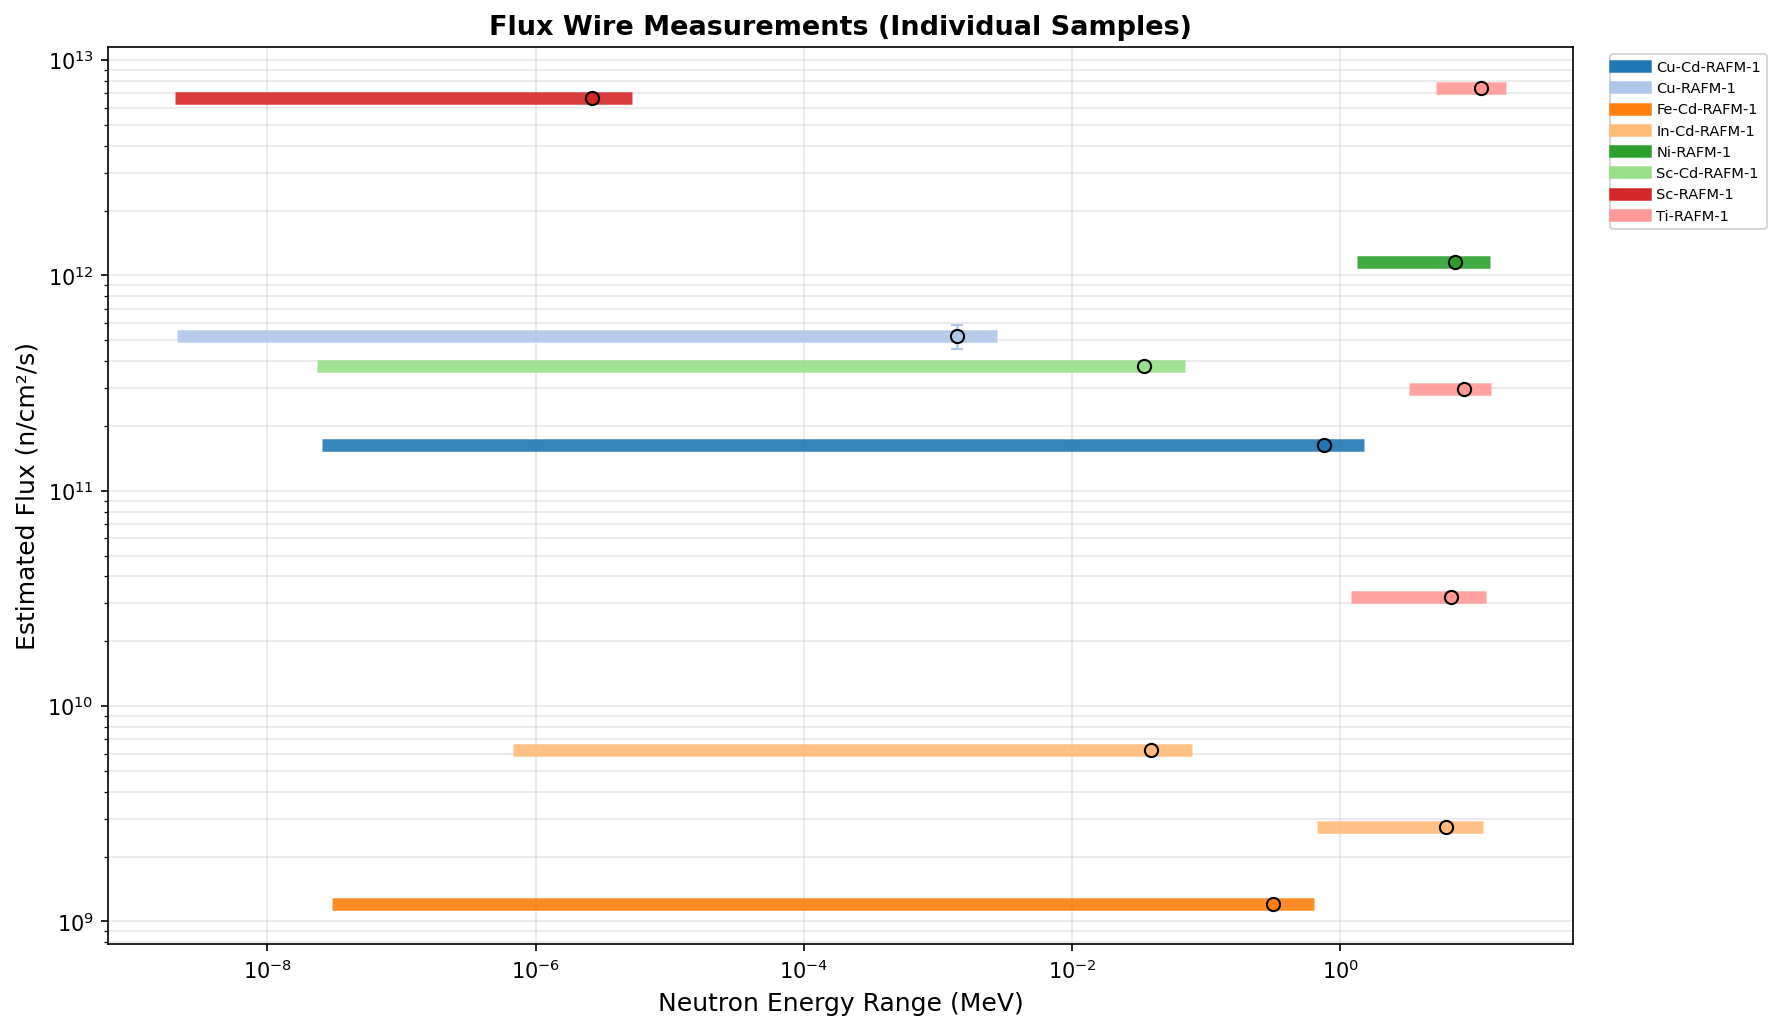

Spectrum CSV not found at: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/raw_gamma_spec/spectrum_vit_j.csv
Spectrum CSV not found at: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/raw_gamma_spec/spectrum_vit_j.csv

Generated 1 flux wire plots


In [86]:
# ==============================================================================
# FLUX WIRE ANALYSIS AND PLOTTING
# ==============================================================================
# Uses flux_wire_plotting module for flux calculation and visualization

from flux_wire_plotting import (
    compute_flux_from_measurements,
    plot_flux_wire_measurements,
    plot_flux_vs_spectrum,
    plot_flux_energy_ranges,
    create_all_flux_plots
)
from flux_wire_loader import get_metadata_df

if 'flux_wires_df' not in globals() or flux_wires_df.empty:
    print("Flux wire data not loaded. Run the flux wire import cell first.")
else:
    # Get metadata
    meta_df = get_metadata_df()
    
    # Compute flux from measurements
    flux_plot_df = compute_flux_from_measurements(
        flux_wires_df, 
        meta_df,
        default_irradiation_seconds=7203,
        default_decay_seconds=0
    )
    
    if not flux_plot_df.empty:
        # Display computed values
        debug_cols = ['sample', 'product', 'activity_Bq', 'uncertainty_Bq', 
                      'N_atoms', 'sigma_cm2', 'S', 'D', 'denom', 'phi', 'phi_unc']
        print('\nFlux wire computed values:')
        display(flux_plot_df[debug_cols].sort_values(['sample', 'product']).reset_index(drop=True))
        
        # Generate all plots - use SPECTRA_DIR for spectrum file
        spectrum_csv = str(SPECTRA_DIR / 'spectrum_vit_j.csv')
        figures = create_all_flux_plots(
            flux_wires_df,
            spectrum_csv=spectrum_csv,
            output_dir=OUTPUT_DIR,
            meta_df=meta_df,
            show_plots=True
        )
        print(f"\nGenerated {len(figures)} flux wire plots")
    else:
        print("No flux records computed. Check mapping, half-life strings, or decay time.")

In [87]:
# ==============================================================================
# FLUX WIRE PHI RECOMPUTATION AND DIAGNOSTICS
# ==============================================================================
# Recompute phi values in flux_wires_df and display diagnostic information

from flux_wire_plotting import recompute_phi_in_dataframe, display_flux_debug_table

if 'flux_wires_df' in globals() and not flux_wires_df.empty:
    if 'meta_df' not in globals():
        meta_df = get_metadata_df()
    
    # Recompute phi values in-place
    flux_wires_df = recompute_phi_in_dataframe(
        flux_wires_df,
        meta_df=meta_df,
        default_irradiation_seconds=7203,
        default_decay_seconds=0,
        verbose=False
    )
    
    # Display debug table
    debug_cols = ['sample', 'isotope', 'activity_Bq', 'uncertainty_Bq', 
                  'mass_used_g', 'A_mass', 'N_atoms', 'sigma_cm2', 
                  'S', 'D', 'denom', 'phi', 'phi_unc', 'irradiation_seconds_used']
    available_cols = [c for c in debug_cols if c in flux_wires_df.columns]
    display(flux_wires_df[available_cols].sort_values('phi', ascending=False))
    
    # Flag suspicious entries
    flagged = display_flux_debug_table(flux_wires_df, threshold=1e14)
    if not flagged.empty:
        display(flagged)
else:
    print('flux_wires_df not available; run import step first')

,sample,isotope,activity_Bq,uncertainty_Bq,mass_used_g,A_mass,N_atoms,sigma_cm2,S,D,denom,phi,phi_unc,irradiation_seconds_used
7,Sc-RAFM-1_25cm,sc46,1607650.00,NaN,0.013499,46.0,1.767184e+20,1.316000e-26,0.000689,0.999966,1.602218e-09,1.003390e+15,NaN,7200.0
6,Sc-Cd-RAFM-1_25cm,sc46,159063.00,NaN,0.013499,46.0,1.767184e+20,1.316000e-26,0.000689,0.999966,1.602218e-09,9.927676e+13,NaN,7200.0
9,Ti-RAFM-1_25cm,sc48,15688.00,NaN,0.013499,48.0,1.693551e+20,3.998000e-28,0.031225,0.998428,2.110871e-09,7.432002e+12,NaN,7200.0
5,Ni-RAFM-1_25cm,co58,45880.00,NaN,0.041675,58.0,4.327085e+20,1.132000e-25,0.000815,0.999960,3.991079e-08,1.149564e+12,NaN,7200.0
1,Cu-RAFM-1_25cm,cu64,3172380.00,409923.0,0.001375,64.0,1.293631e+19,4.500000e-24,0.103403,0.994603,5.986933e-06,5.298840e+11,6.846961e+10,7200.0
10,Ti-RAFM-1_25cm,sc46,473.60,NaN,0.013499,46.0,1.767184e+20,1.316000e-26,0.000689,0.999966,1.602218e-09,2.955903e+11,NaN,7200.0
0,Cu-Cd-RAFM-1_25cm,cu64,1090982.00,NaN,0.001375,64.0,1.293631e+19,4.500000e-24,0.103403,0.994603,5.986933e-06,1.822272e+11,NaN,7200.0
8,Ti-RAFM-1_25cm,sc47,2271.80,NaN,0.013499,47.0,1.729584e+20,2.400000e-26,0.017100,0.999145,7.092034e-08,3.203313e+10,NaN,7200.0
3,In-Cd-RAFM-1_25cm,in114m,219706.00,NaN,0.017364,114.0,9.172671e+19,3.252000e-22,0.001166,0.999942,3.477917e-05,6.317172e+09,NaN,7200.0
4,In-Cd-RAFM-1_25cm,in115m,11988.00,NaN,0.017364,115.0,9.092909e+19,1.831000e-25,0.265890,0.984791,4.359497e-06,2.749858e+09,NaN,7200.0



Flux wire computed values (sorted by phi):

⚠️ Flagged 1 rows with phi > 1.000000e+14 n/cm²/s


,sample,isotope,activity_Bq,uncertainty_Bq,mass_used_g,A_mass,N_atoms,sigma_cm2,S,D,denom,phi,phi_unc,irradiation_seconds_used
7,Sc-RAFM-1_25cm,sc46,1607650.0,NaN,0.013499,46.0,1.767184e+20,1.316000e-26,0.000689,0.999966,1.602218e-09,1.003390e+15,NaN,7200.0


## Advanced Gamma Spectroscopy Analysis & Flux Optimization

This section implements rigorous analysis techniques for gamma spectroscopy data:

### 1. Weighted Average Activity
When multiple gamma peaks are measured for the same isotope, use inverse-variance weighting:
$$A_{\text{final}} = \frac{\sum_i A_i / \sigma_i^2}{\sum_i 1 / \sigma_i^2}$$

### 2. Decay Correction Chain
- **A_meas** → Measured activity at counting time
- **A_EOI** → Activity at End of Irradiation: $A_{\text{EOI}} = A_{\text{meas}} / e^{-\lambda t_d}$
- **A_sat** → Saturation activity: $A_{\text{sat}} = A_{\text{EOI}} / (1 - e^{-\lambda t_i})$

### 3. Flux Calculation from A_sat
$$\phi = \frac{A_{\text{sat}} \cdot \lambda}{\sigma \cdot N}$$

### 4. Signal-to-Noise Ratio (SNR) Optimization
Find optimal irradiation/cooling times to detect trace contaminants against dominant isotopes:
$$\text{SNR}(t_i, t_d) = \frac{A_{\text{sat,target}} \cdot (1 - e^{-\lambda_{\text{target}} t_i}) \cdot e^{-\lambda_{\text{target}} t_d}}{A_{\text{sat,mask}} \cdot (1 - e^{-\lambda_{\text{mask}} t_i}) \cdot e^{-\lambda_{\text{mask}} t_d}}$$

### 5. Live Time vs Real Time
Use **Live Time (LT)** for the counting correction term $(1 - e^{-\lambda t_c})$ since dead time represents periods when the detector is not actively counting.

In [88]:
# ==============================================================================
# GAMMA SPECTROSCOPY ANALYSIS UTILITIES
# ==============================================================================
# Import decay physics functions from our centralized module

from datetime import datetime
import numpy as np
import pandas as pd

# Try to import uncertainties for error propagation
try:
    from uncertainties import ufloat
    from uncertainties.umath import exp as uexp, log as ulog
    HAS_UNCERTAINTIES = True
    print("✓ uncertainties package available for error propagation")
except ImportError:
    HAS_UNCERTAINTIES = False
    print("⚠ uncertainties package not installed. Install with: pip install uncertainties")

# Import decay physics functions from centralized module
from decay_physics import (
    weighted_average_activity,
    decay_correct_to_eoi,
    calculate_saturation_activity,
    full_decay_chain,
    activity_uci_to_bq,
    activity_bq_to_uci,
    calculate_flux_from_asat,
)
from isotope_utils import (
    LN2, AVOGADRO,
    half_life_to_lambda,
)

print("✓ Decay physics functions loaded from decay_physics.py")

# Helper functions for time parsing (these are notebook-specific)
def calculate_cooling_time(irradiation_end: datetime, measurement_time: datetime) -> float:
    """
    Calculate cooling time (t_d) in seconds between end of irradiation and measurement.
    """
    delta = measurement_time - irradiation_end
    return delta.total_seconds()

def parse_measurement_time(time_string: str, format_string: str = "%B %d, %Y %H:%M:%S") -> datetime:
    """
    Parse measurement time from gamma spec report format.
    Example: "August 20, 2025 13:36:40" -> datetime object
    """
    return datetime.strptime(time_string, format_string)

✓ uncertainties package available for error propagation
✓ Decay physics functions loaded from decay_physics.py


In [89]:
# ==============================================================================
# SNR OPTIMIZATION: HEATMAPS FOR MISSING ISOTOPES
# ==============================================================================
# DYNAMIC MASK SELECTION PER SAMPLE AND COOLDOWN:
# - MASK: Top 2-3 highest-activity EXPERIMENTALLY MEASURED isotopes for that 
#         specific sample and cooldown time (not always V-52!)
# - TARGETS: Isotopes ALARA predicts at that cooldown but we DON'T see experimentally
#            AND that have gamma emissions (HPGe detectable)
#
# CRITICAL: Activities must be NORMALIZED to saturation activity (A_sat) before
# comparison, since raw activities at different cooling times can't be compared
# directly. A_sat = A_measured / [(1-e^(-λt_irr)) * e^(-λt_cool)]
#
# HEATMAP INTERPRETATION:
# ─────────────────────────────────────────────────────────────────────────────
# Goal: Identify the "Detection Window" where SNR > 10
#
# X-AXIS (ti): Irradiation time - Moving right increases activity for BOTH
#   Rule: Stop at target saturation (ti ≈ 3× target half-life)
#
# Y-AXIS (td): Cooling time - Moving up lets shorter-lived isotope decay
#   Rule: If Target longer-lived than Mask → wait 10× mask half-life
#         If Target shorter-lived than Mask → measure immediately
# ==============================================================================

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from pathlib import Path
import importlib

# Reload modules
import decay_physics
import isotope_utils
importlib.reload(decay_physics)
importlib.reload(isotope_utils)

from decay_physics import calculate_snr_grid, get_half_life_seconds, LN2
from isotope_utils import (
    get_half_life_days, canonical_iso, format_iso_pretty,
    parse_activity_unit,
    has_gamma_emission, get_gamma_info, filter_gamma_emitters
)

print("=" * 80)
print("SNR HEATMAPS: DETECTING ALARA-PREDICTED ISOTOPES")
print("Dynamic mask selection per sample/cooldown + HPGe gamma filter")
print("Activities NORMALIZED to saturation activity for fair comparison")
print("=" * 80)

# ==============================================================================
# HELPER FUNCTION: NORMALIZE ACTIVITY TO SATURATION ACTIVITY
# ==============================================================================
def activity_to_asat(activity_bq, half_life_s, t_irradiation_s, t_cooling_s):
    """
    Convert measured activity to saturation activity.
    
    A_measured = A_sat * (1 - e^(-λ*t_irr)) * e^(-λ*t_cool)
    A_sat = A_measured / [(1 - e^(-λ*t_irr)) * e^(-λ*t_cool)]
    
    Parameters:
        activity_bq: Measured activity in Bq
        half_life_s: Half-life in seconds
        t_irradiation_s: Irradiation time in seconds
        t_cooling_s: Cooling time in seconds (time from EOI to measurement)
    
    Returns:
        Saturation activity in Bq
    """
    if half_life_s <= 0 or activity_bq <= 0:
        return 0.0
    
    lam = LN2 / half_life_s
    
    # Buildup factor: (1 - e^(-λ*t_irr))
    buildup = 1 - np.exp(-lam * t_irradiation_s)
    if buildup < 1e-10:
        buildup = 1e-10  # Avoid division by zero for very long-lived isotopes
    
    # Decay factor: e^(-λ*t_cool)
    decay = np.exp(-lam * t_cooling_s)
    if decay < 1e-10:
        decay = 1e-10  # Avoid division by zero for very short-lived isotopes
    
    a_sat = activity_bq / (buildup * decay)
    return a_sat

# Irradiation time mapping (3s for 300s/2h/24h/4d, 2hr for 15d)
def get_irradiation_time(time_key):
    """Get irradiation time in seconds for a given cooldown time key."""
    if time_key in ['15d', '15days']:
        return 7200  # 2 hour irradiation for 15d samples
    else:
        return 3  # 3 second irradiation for others

# Cooling time mapping
TIME_KEY_TO_COOLING_SECONDS = {
    '300s': 300, '5min': 300,
    '2h': 7200, '2hr': 7200, 
    '24h': 86400,
    '4d': 345600, '4days': 345600,
    '15d': 1296000, '15days': 1296000
}

# ==============================================================================
# GET ALARA PREDICTIONS BY COOLING TIME (NORMALIZED TO A_SAT)
# ==============================================================================
alara_by_time = {}  # {material: {time_key: {isotope: activity}}}
alara_asat = {}     # {material: {isotope: asat}} - normalized to saturation

if 'adf' in globals() and adf is not None:
    for run_lbl in adf['run_lbl'].unique():
        if run_lbl == 'tally_85114':
            continue
        tally_to_mat = {v: k for k, v in MATERIAL_TO_TALLY.items()}
        material = tally_to_mat.get(run_lbl, run_lbl)
        
        filtered = adf.filter_rows({
            'run_lbl': run_lbl,
            'variable': adf.VARIABLE_ENUM['Specific Activity']
        })
        
        alara_by_time[material] = {}
        alara_asat[material] = {}
        
        # Get ALARA data for each time point
        for time_val in filtered['time'].unique():
            time_data = filtered[filtered['time'] == time_val]
            iso_acts = {}
            for _, row in time_data.iterrows():
                iso = canonical_iso(row['nuclide'])
                if iso and row['value'] > 0:
                    iso_acts[iso] = row['value']
            
            # Map ALARA time (seconds) to our time keys
            for key, secs in TIME_KEY_TO_COOLING_SECONDS.items():
                if abs(time_val - secs) < secs * 0.1:  # 10% tolerance
                    alara_by_time[material][key] = iso_acts
                    
                    # Also compute A_sat for each isotope at this cooldown
                    t_irr = get_irradiation_time(key)
                    t_cool = secs
                    for iso, act in iso_acts.items():
                        hl_s = get_half_life_seconds(iso)
                        if hl_s:
                            a_sat = activity_to_asat(act, hl_s, t_irr, t_cool)
                            # Keep the maximum A_sat seen across all times
                            if iso not in alara_asat[material] or a_sat > alara_asat[material][iso]:
                                alara_asat[material][iso] = a_sat
                    break
            else:
                # Also keep shutdown (t=0) for reference
                if time_val == 0:
                    alara_by_time[material]['shutdown'] = iso_acts
    
    print(f"ALARA predictions loaded for {len(alara_by_time)} materials with per-time data")
    print(f"ALARA saturation activities computed for comparison")

# ==============================================================================
# FIND MISSING ISOTOPES PER COOLDOWN (FILTERED FOR GAMMA EMITTERS)
# Activities normalized to A_sat for fair comparison
# ==============================================================================
print("\n" + "─" * 70)
print("ANALYSIS: Per-cooldown ALARA vs Experimental (NORMALIZED to A_sat)")
print("─" * 70)

missing_by_cooldown = {}  # {material: {time_key: [missing isotopes with A_sat]}}
exp_dominant_by_cooldown = {}  # {material: {time_key: [top exp isotopes with A_sat]}}

for material, exp_time_data in experimental_data.items():
    missing_by_cooldown[material] = {}
    exp_dominant_by_cooldown[material] = {}
    
    alara_times = alara_by_time.get(material, {})
    
    for time_key, nuclides in exp_time_data.items():
        # Get irradiation and cooling times for normalization
        t_irr = get_irradiation_time(time_key)
        t_cool = TIME_KEY_TO_COOLING_SECONDS.get(time_key, 300)
        
        # Get experimental isotopes at this cooldown with activities
        exp_at_time = []
        for iso, data in nuclides.items():
            iso_canon = canonical_iso(iso)
            act_bq = None
            try:
                act_raw = data.get('activity')
                unit = data.get('unit', 'uCi')
                act_bq = float(act_raw) * parse_activity_unit(unit)
            except:
                pass
            
            hl_s = get_half_life_seconds(iso_canon)
            if act_bq and act_bq > 0 and hl_s:
                # NORMALIZE to saturation activity
                a_sat = activity_to_asat(act_bq, hl_s, t_irr, t_cool)
                exp_at_time.append({
                    'isotope': iso_canon,
                    'activity': act_bq,        # Raw activity at measurement time
                    'activity_asat': a_sat,    # Normalized saturation activity
                    'half_life_s': hl_s,
                    'has_gamma': has_gamma_emission(iso_canon)
                })
        
        # Sort by SATURATION ACTIVITY (not raw activity!) and take top 3 as potential masks
        exp_at_time.sort(key=lambda x: x['activity_asat'], reverse=True)
        exp_dominant_by_cooldown[material][time_key] = exp_at_time[:3]
        
        # Get ALARA predictions at this cooldown
        alara_at_time = alara_times.get(time_key, {})
        if not alara_at_time:
            # Try shutdown as fallback
            alara_at_time = alara_times.get('shutdown', {})
        
        # Find missing: ALARA predicts but not in experimental, AND has gamma
        exp_iso_set = {x['isotope'] for x in exp_at_time}
        missing = []
        for iso, act in alara_at_time.items():
            if iso not in exp_iso_set and act > 0:
                hl_s = get_half_life_seconds(iso)
                if hl_s is not None and hl_s > 60:  # At least 1 minute half-life
                    # CHECK FOR GAMMA EMISSION (HPGe detectability)
                    gamma_info = get_gamma_info(iso)
                    if has_gamma_emission(iso, min_intensity=0.01):
                        # NORMALIZE to saturation activity
                        a_sat = activity_to_asat(act, hl_s, t_irr, t_cool)
                        missing.append({
                            'isotope': iso,
                            'alara_activity': act,       # Raw activity at cooldown
                            'alara_activity_asat': a_sat,  # Normalized saturation activity
                            'half_life_s': hl_s,
                            'gamma_keV': gamma_info.get('main_gamma_keV') if gamma_info else None
                        })
        
        # Sort by SATURATION ACTIVITY (not raw activity!)
        missing.sort(key=lambda x: x['alara_activity_asat'], reverse=True)
        missing_by_cooldown[material][time_key] = missing[:5]
    
    # Print summary for this material
    print(f"\n{material}:")
    for time_key in sorted(exp_time_data.keys()):
        exp_dom = exp_dominant_by_cooldown[material].get(time_key, [])
        missing = missing_by_cooldown[material].get(time_key, [])
        
        if exp_dom:
            dom_str = ', '.join([format_iso_pretty(x['isotope']) for x in exp_dom[:3]])
            print(f"  {time_key}: Dominant exp = [{dom_str}]")
        if missing:
            for m in missing[:3]:
                hl_d = m['half_life_s'] / 86400
                gamma = f"γ={m['gamma_keV']:.0f}keV" if m.get('gamma_keV') else "γ?"
                print(f"         Missing: {format_iso_pretty(m['isotope']):10s} (T½={hl_d:.2f}d, {gamma})")

# ==============================================================================
# GENERATE HEATMAPS - Per-cooldown with dynamic mask selection
# ==============================================================================
print("\n" + "=" * 70)
print("GENERATING SNR HEATMAPS (PER-COOLDOWN, DYNAMIC MASKS)")
print("=" * 70)

snr_output_dir = Path(OUTPUT_DIR) / 'snr_optimization'
snr_output_dir.mkdir(parents=True, exist_ok=True)

def activity_to_bq(activity, unit):
    try:
        return float(activity) * parse_activity_unit(unit)
    except:
        return np.nan

saved_heatmaps = []
all_results = []

# ==============================================================================
# PER-COOLDOWN HEATMAP GENERATION
# For each material and cooldown time:
#   - MASK = top 2-3 highest-activity experimental isotopes at THAT cooldown
#   - TARGETS = ALARA-predicted isotopes not seen experimentally AND with gamma emissions
# ==============================================================================

for material in experimental_data.keys():
    mat_output_dir = snr_output_dir / material.replace('/', '_')
    mat_output_dir.mkdir(parents=True, exist_ok=True)
    
    is_first_mat = list(experimental_data.keys()).index(material) < 2
    
    print(f"\n{'═' * 60}")
    print(f"MATERIAL: {material}")
    print(f"{'═' * 60}")
    
    # Process each cooldown time separately
    cooldown_times = exp_dominant_by_cooldown.get(material, {})
    
    for time_key, masks_at_time in cooldown_times.items():
        targets_at_time = missing_by_cooldown.get(material, {}).get(time_key, [])
        
        if not masks_at_time or not targets_at_time:
            continue
        
        print(f"\n  COOLDOWN: {time_key}")
        print(f"  ─────────────────────────────────────────────────────")
        
        # Display masks (top experimental isotopes at this cooldown)
        mask_info = []
        for m in masks_at_time[:3]:
            hl_d = m['half_life_s'] / 86400
            mask_info.append(f"{format_iso_pretty(m['isotope'])} (A={m['activity']:.1e}Bq, T½={hl_d:.2f}d)")
        print(f"    MASKS (dominant exp): {', '.join(mask_info)}")
        
        # For each target at this cooldown time
        for target_data in targets_at_time[:3]:  # Top 3 missing isotopes
            target_iso = target_data['isotope']
            target_act = target_data['alara_activity']
            target_hl_s = target_data['half_life_s']
            target_hl_d = target_hl_s / 86400
            target_gamma = target_data.get('gamma_keV', '?')
            
            # Choose best mask: prefer shorter-lived than target (so we wait for it to decay)
            # From the masks at THIS cooldown time
            candidates = [m for m in masks_at_time if m['half_life_s'] < target_hl_s]
            if not candidates:
                # If all masks are longer-lived, use the highest activity one
                candidates = masks_at_time
            
            # Pick highest activity candidate as primary mask
            mask_data = max(candidates, key=lambda x: x['activity'])
            mask_iso = mask_data['isotope']
            mask_act = mask_data['activity']
            mask_hl_s = mask_data['half_life_s']
            mask_hl_d = mask_hl_s / 86400
            
            gamma_str = f"γ={target_gamma:.0f}keV" if target_gamma and target_gamma != '?' else "γ=?"
            print(f"\n    TARGET: {format_iso_pretty(target_iso)} (T½={target_hl_d:.2f}d, A_ALARA={target_act:.1e}, {gamma_str})")
            print(f"      MASK: {format_iso_pretty(mask_iso)} (T½={mask_hl_d:.2f}d, A_exp={mask_act:.1e})")
            
            # ==================================================================
            # SET REALISTIC AXIS LIMITS
            # ==================================================================
            # ti: For saturation, use min(3× target half-life, 24 hours)
            ti_max_h = min(3 * target_hl_d * 24, 24)
            ti_max_h = max(ti_max_h, 0.5)  # At least 30 minutes
            
            # td: Based on relative half-lives
            if target_hl_d > mask_hl_d:
                # Target longer-lived: wait for mask to decay
                td_max_d = min(10 * mask_hl_d, 30)
            else:
                # Target shorter-lived: measure quickly
                td_max_d = min(3 * target_hl_d, 7)
            td_max_d = max(td_max_d, 1.0)  # At least 1 day
            
            # Create grids
            ti_range = np.linspace(0.01 * 3600, ti_max_h * 3600, 80)
            td_range = np.linspace(0.01 * 86400, td_max_d * 86400, 80)
            
            print(f"      Axes: ti=[0,{ti_max_h:.1f}h], td=[0,{td_max_d:.1f}d]")
            
            # Calculate SNR grid
            snr_grid = calculate_snr_grid(
                target_half_life_s=target_hl_s,
                target_asat=target_act,
                mask_half_life_s=mask_hl_s,
                mask_asat=mask_act,
                ti_range=ti_range,
                td_range=td_range
            )
            
            valid_snr = snr_grid[np.isfinite(snr_grid) & (snr_grid > 0)]
            if len(valid_snr) == 0:
                print(f"      ⚠ No valid SNR values, skipping")
                continue
            
            max_idx = np.unravel_index(np.nanargmax(snr_grid), snr_grid.shape)
            opt_ti_h = ti_range[max_idx[1]] / 3600
            opt_td_d = td_range[max_idx[0]] / 86400
            max_snr = snr_grid[max_idx]
            
            # Strategy
            if target_hl_d > mask_hl_d:
                strategy = f"Wait {opt_td_d:.1f}d for {format_iso_pretty(mask_iso)} to decay"
            else:
                strategy = f"Measure quickly (target decays faster)"
            
            print(f"      Optimal: ti={opt_ti_h:.1f}h, td={opt_td_d:.2f}d, SNR={max_snr:.2e}")
            
            all_results.append({
                'material': material,
                'cooldown': time_key,
                'mask': mask_iso,
                'target': target_iso,
                'target_gamma_keV': target_gamma if target_gamma != '?' else None,
                'mask_hl_days': mask_hl_d,
                'target_hl_days': target_hl_d,
                'optimal_ti_hours': opt_ti_h,
                'optimal_td_days': opt_td_d,
                'max_snr': max_snr,
                'strategy': strategy
            })
            
            # ==================================================================
            # PLOT HEATMAP
            # ==================================================================
            fig, ax = plt.subplots(figsize=(10, 8))
            
            ti_h = ti_range / 3600
            td_d = td_range / 86400
            
            vmin, vmax = np.nanmin(valid_snr), np.nanmax(valid_snr)
            if vmax / max(vmin, 1e-30) > 100:
                norm = LogNorm(vmin=max(vmin, 1e-6), vmax=vmax)
            else:
                norm = None
            
            im = ax.pcolormesh(ti_h, td_d, snr_grid, shading='auto', cmap='viridis', norm=norm)
            cbar = plt.colorbar(im, ax=ax)
            cbar.set_label(f'SNR ({format_iso_pretty(target_iso)} / {format_iso_pretty(mask_iso)})', fontsize=11)
            
            # Optimal point
            ax.scatter([opt_ti_h], [opt_td_d], color='red', s=200, marker='*',
                       edgecolor='white', linewidth=2, zorder=5, label=f'Optimal: SNR={max_snr:.1e}')
            
            # SNR = 10 contour
            try:
                cs = ax.contour(ti_h, td_d, snr_grid, levels=[10], colors='red', linewidths=2, linestyles='--')
                ax.clabel(cs, fmt='SNR=10', fontsize=9)
            except:
                pass
            
            # Target saturation line
            sat_ti_h = min(3 * target_hl_d * 24, ti_max_h)
            if sat_ti_h < ti_max_h * 0.95:
                ax.axvline(x=sat_ti_h, color='orange', linestyle=':', linewidth=2, alpha=0.7,
                          label=f'Target saturation (3×T½)')
            
            ax.set_xlabel('Irradiation Time (hours)', fontsize=12, fontweight='bold')
            ax.set_ylabel('Cooling Time (days)', fontsize=12, fontweight='bold')
            
            # Title includes cooldown time
            gamma_title = f", γ={target_gamma:.0f}keV" if target_gamma and target_gamma != '?' else ""
            ax.set_title(f'{material} @ {time_key}: Detection Window for {format_iso_pretty(target_iso)}{gamma_title}\n'
                        f'Mask: {format_iso_pretty(mask_iso)} (T½={mask_hl_d:.3f}d) | '
                        f'Target T½={target_hl_d:.2f}d',
                        fontsize=11, fontweight='bold')
            
            # Interpretation box
            interp = f"Cooldown: {time_key}\n"
            interp += f"Optimal: ti={opt_ti_h:.1f}h, td={opt_td_d:.2f}d\n"
            interp += f"Max SNR: {max_snr:.1e}\n"
            interp += f"Strategy: {strategy}"
            
            ax.text(0.02, 0.98, interp, transform=ax.transAxes, fontsize=9,
                   verticalalignment='top', fontfamily='monospace',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))
            
            ax.legend(loc='lower right', fontsize=9)
            
            plt.tight_layout()
            
            # Save with cooldown in filename
            target_clean = target_iso.replace('-', '')
            mask_clean = mask_iso.replace('-', '')
            time_clean = time_key.replace(':', '').replace(' ', '')
            save_path = mat_output_dir / f"heatmap_{time_clean}_{target_clean}_vs_{mask_clean}.png"
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            saved_heatmaps.append(str(save_path))
            print(f"      ✓ Saved: {save_path.name}")
            
            if is_first_mat:
                plt.show()
            else:
                plt.close(fig)

# ==============================================================================
# SUMMARY
# ==============================================================================
print("\n" + "=" * 70)
print("SNR HEATMAP ANALYSIS COMPLETE")
print("=" * 70)

if all_results:
    snr_summary_df = pd.DataFrame(all_results)
    summary_path = snr_output_dir / 'snr_heatmap_summary.csv'
    snr_summary_df.to_csv(summary_path, index=False)
    print(f"\n✓ Summary saved: {summary_path}")
    print(f"\n✓ Generated {len(saved_heatmaps)} heatmaps")
    
    print("\n" + "─" * 70)
    print("KEY RECOMMENDATIONS (per cooldown, gamma-filtered):")
    print("─" * 70)
    for r in all_results[:12]:
        gamma_str = f" [γ={r['target_gamma_keV']:.0f}keV]" if r.get('target_gamma_keV') else ""
        print(f"  {r['material']} @ {r['cooldown']}: Find {format_iso_pretty(r['target'])}{gamma_str}")
        print(f"    Masked by {format_iso_pretty(r['mask'])} → Irradiate {r['optimal_ti_hours']:.1f}h, cool {r['optimal_td_days']:.1f}d (SNR={r['max_snr']:.1e})")
else:
    print("\n⚠ No heatmaps generated")

SNR HEATMAPS: DETECTING ALARA-PREDICTED ISOTOPES
Dynamic mask selection per sample/cooldown + HPGe gamma filter
Activities NORMALIZED to saturation activity for fair comparison
ALARA predictions loaded for 4 materials with per-time data
ALARA saturation activities computed for comparison

──────────────────────────────────────────────────────────────────────
ANALYSIS: Per-cooldown ALARA vs Experimental (NORMALIZED to A_sat)
──────────────────────────────────────────────────────────────────────

EUROFER97_2:
  24h: Dominant exp = [Mn-56, Cr-51, W-187]
  300s: Dominant exp = [V-52, Mn-56, W-187]
  4d: Dominant exp = [Cr-51, W-187]

EUROFER97_3:
  24h: Dominant exp = [W-187, Mn-56, Cr-51]
  2h: Dominant exp = [Mn-56, W-187]
  300s: Dominant exp = [V-52, Mn-56, W-187]
  4d: Dominant exp = [Cr-51, W-187]

EUROFER97_4:
  24h: Dominant exp = [Cr-51, W-187, Mn-56]
  2h: Dominant exp = [Mn-56, W-187]
  300s: Dominant exp = [V-52, Mn-56, W-187]
  4d: Dominant exp = [Cr-51, W-187]

CNA:
  24h: Do

In [90]:
# ==============================================================================
# SUMMARY: DETECTION WINDOW ANALYSIS ACROSS ALL SAMPLES
# ==============================================================================
# Summarizes optimal detection conditions for each sample.
# ==============================================================================

print("=" * 80)
print("SUMMARY: OPTIMAL DETECTION WINDOWS BY SAMPLE")
print("=" * 80)

if 'experimental_data' not in globals() or not experimental_data:
    print("⚠ experimental_data not loaded.")
elif 'HAS_EXP_LOADER' in globals() and HAS_EXP_LOADER:
    # Re-import from modules to avoid shadowing by local functions
    from experimental_data_loader import get_top_isotopes as exp_get_top_isotopes
    from isotope_utils import get_half_life_days
    
    # Use the loader function to get top isotopes
    top_by_material = exp_get_top_isotopes(experimental_data, top_n=3)
    
    summary_records = []
    
    for material, top_isos in top_by_material.items():
        for rank, (iso, act_bq) in enumerate(top_isos, 1):
            hl = get_half_life_days(iso)
            
            category = 'unknown'
            if hl is not None:
                if hl < 1:
                    category = 'short'
                elif hl < 30:
                    category = 'medium'
                else:
                    category = 'long'
            
            summary_records.append({
                'Material': material,
                'Rank': rank,
                'Isotope': iso.upper() if iso else iso,
                'Activity_Bq': act_bq,
                'Activity_uCi': act_bq / 37000.0,
                'HalfLife_days': hl if hl else np.nan,
                'Category': category
            })
    
    if summary_records:
        summary_df = pd.DataFrame(summary_records)
        
        # Display pivot table
        print("\nTop 3 isotopes per material with half-life classification:\n")
        pivot = summary_df.pivot_table(
            index='Material',
            columns='Rank',
            values=['Isotope', 'Activity_uCi', 'HalfLife_days'],
            aggfunc='first'
        )
        display(pivot.round(2))
        
        # Statistics on isotope diversity
        print("\n" + "─" * 60)
        print("Unique isotopes detected across all samples:")
        for iso in sorted(summary_df['Isotope'].unique()):
            hl = get_half_life_days(iso.lower())
            hl_str = f"T½ = {hl:.2f} d" if hl else "T½ unknown"
            count = (summary_df['Isotope'] == iso).sum()
            print(f"  {iso:10s}  ({hl_str:20s})  found in {count} material(s)")
        
        # Measurement recommendations
        print("\n" + "─" * 60)
        print("MEASUREMENT STRATEGY RECOMMENDATIONS:")
        print("─" * 60)
        
        short_lived = summary_df[summary_df['Category'] == 'short']
        if not short_lived.empty:
            print("\n🔴 SHORT-LIVED (< 1 day) - Measure IMMEDIATELY:")
            for _, row in short_lived.iterrows():
                print(f"   {row['Material']:20s}  {row['Isotope']:10s}  T½ = {row['HalfLife_days']:.2f} d")
        
        medium_lived = summary_df[summary_df['Category'] == 'medium']
        if not medium_lived.empty:
            print("\n🟡 MEDIUM-LIVED (1-30 days) - Measure within 1-2 weeks:")
            for _, row in medium_lived.drop_duplicates(['Material', 'Isotope']).iterrows():
                print(f"   {row['Material']:20s}  {row['Isotope']:10s}  T½ = {row['HalfLife_days']:.1f} d")
        
        long_lived = summary_df[summary_df['Category'] == 'long']
        if not long_lived.empty:
            print("\n🟢 LONG-LIVED (> 30 days) - Can wait for short-lived to decay:")
            for _, row in long_lived.drop_duplicates(['Material', 'Isotope']).iterrows():
                if pd.notna(row['HalfLife_days']):
                    print(f"   {row['Material']:20s}  {row['Isotope']:10s}  T½ = {row['HalfLife_days']:.1f} d")
                else:
                    print(f"   {row['Material']:20s}  {row['Isotope']:10s}  T½ = unknown")
else:
    print("Experimental data loader not available for summary analysis.")

SUMMARY: OPTIMAL DETECTION WINDOWS BY SAMPLE
Experimental data loader not available for summary analysis.


In [91]:
# ==============================================================================
# UNCERTAINTY PROPAGATION WITH THE 'uncertainties' PACKAGE
# ==============================================================================

if HAS_UNCERTAINTIES:
    print("=== Uncertainty Propagation Example ===\n")
    
    # Create measurement with uncertainty
    A_measured = ufloat(19.918, 0.889)  # 19.918 ± 0.889 µCi
    
    # Ta-182 parameters
    half_life_s = 114.74 * 24 * 3600  # seconds
    lam = LN2 / half_life_s
    
    # Timing parameters
    t_cooling = 19 * 24 * 3600  # 19 days
    t_irrad = 2 * 3600  # 2 hours
    
    print(f"Measured activity: {A_measured} µCi")
    print(f"Lambda: {lam:.6e} /s")
    print(f"Cooling time: {t_cooling/(24*3600):.1f} days")
    print(f"Irradiation time: {t_irrad/3600:.1f} hours")
    print()
    
    # Decay correction with automatic error propagation
    decay_factor = uexp(-lam * t_cooling)
    A_EOI = A_measured / decay_factor
    
    print(f"Decay factor: {decay_factor}")
    print(f"A_EOI: {A_EOI} µCi")
    print()
    
    # Saturation activity
    sat_factor = 1 - uexp(-lam * t_irrad)
    A_sat = A_EOI / sat_factor
    
    print(f"Saturation factor: {sat_factor}")
    print(f"A_sat: {A_sat} µCi")
    print()
    
    # Convert to Bq for flux calculation
    A_sat_Bq = A_sat * 37000
    print(f"A_sat in Bq: {A_sat_Bq}")
    
    # Flux calculation (using ufloat for all parameters)
    sigma = ufloat(20.5, 1.0) * 1e-24  # 20.5 ± 1.0 barns → cm²
    N_atoms = ufloat(3.33e18, 3.33e16)  # ±1% uncertainty on atom count
    
    phi = (A_sat_Bq * lam) / (sigma * N_atoms)
    
    print(f"\n=== Final Flux Calculation with Full Error Propagation ===")
    print(f"Cross-section: {sigma*1e24} barns")
    print(f"N atoms: {N_atoms:.2e}")
    print(f"Neutron flux: {phi:.2e} n/cm²/s")
    print(f"\nNote: Uncertainties automatically propagate through all calculations!")
    
else:
    print("=== Uncertainty Propagation (Manual Method) ===\n")
    print("The 'uncertainties' package is not installed.")
    print("Install it with: pip install uncertainties")
    print()
    print("Manual propagation formula for A_EOI = A_meas / exp(-λt):")
    print("  σ(A_EOI)/A_EOI = σ(A_meas)/A_meas  (relative error preserved)")
    print()
    print("For flux φ = (A_sat * λ) / (σ * N):")
    print("  σ(φ)/φ = √[(σ_A/A)² + (σ_σ/σ)² + (σ_N/N)²]")

=== Uncertainty Propagation Example ===

Measured activity: 19.9+/-0.9 µCi
Lambda: 6.991927e-08 /s
Cooling time: 19.0 days
Irradiation time: 2.0 hours

Decay factor: 0.8915627382263887
A_EOI: 22.3+/-1.0 µCi

Saturation factor: 0.0005032920357599391
A_sat: (4.44+/-0.20)e+04 µCi

A_sat in Bq: (1.64+/-0.07)e+09

=== Final Flux Calculation with Full Error Propagation ===
Cross-section: 20.5+/-1.0 barns
N atoms: (3.33+/-0.03)e+18
Neutron flux: (1.68+/-0.11)e+06 n/cm²/s

Note: Uncertainties automatically propagate through all calculations!


In [92]:
# ==============================================================================
# SUMMARY: COMPLETE WORKFLOW FROM GAMMA SPEC TO VALIDATED FLUX
# ==============================================================================
print("=" * 80)
print("COMPLETE GAMMA SPECTROSCOPY → FLUX → ALARA VALIDATION WORKFLOW")
print("=" * 80)

workflow_summary = """
┌─────────────────────────────────────────────────────────────────────────────┐
│ STEP 1: PARSE                                                               │
│   • Extract counts, peak energies, dates/times from gamma spec .txt/.csv    │
│   • Use weighted averaging if multiple peaks per isotope                    │
│   • Prefer high-energy peaks (lower background) for weighting               │
│   Formula: A_final = Σ(Aᵢ/σᵢ²) / Σ(1/σᵢ²)                                  │
├─────────────────────────────────────────────────────────────────────────────┤
│ STEP 2: DECAY CORRECT (A_meas → A_EOI)                                     │
│   • Calculate cooling time: t_d = t_measurement - t_EOB                     │
│   • Use LIVE TIME (not real time) for counting corrections                  │
│   Formula: A_EOI = A_meas / exp(-λ·t_d)                                     │
├─────────────────────────────────────────────────────────────────────────────┤
│ STEP 3: SATURATE (A_EOI → A_sat)                                            │
│   • Convert to saturation activity (time-independent)                       │
│   Formula: A_sat = A_EOI / (1 - exp(-λ·t_i))                                │
├─────────────────────────────────────────────────────────────────────────────┤
│ STEP 4: CHARACTERIZE (A_sat → φ)                                            │
│   • Calculate neutron flux from flux wire data                              │
│   • Requires: cross-section (σ), number of atoms (N)                        │
│   Formula: φ = (A_sat · λ) / (σ · N)                                        │
├─────────────────────────────────────────────────────────────────────────────┤
│ STEP 5: VALIDATE                                                            │
│   • Compare calculated flux to ALARA input assumptions                      │
│   • Compare experimental A_EOI to ALARA-predicted shutdown activities       │
│   • Check ratio: ALARA/Experiment ≈ 1.0 (within uncertainties)              │
├─────────────────────────────────────────────────────────────────────────────┤
│ STEP 6: OPTIMIZE                                                            │
│   • Use SNR heatmaps to find detection windows for contaminants             │
│   • Short-lived isotope (T½ < mask): shorter t_i, very short t_d            │
│   • Long-lived isotope (T½ > mask): longer t_i, wait for mask to decay      │
│   Formula: SNR(t_i,t_d) = [A_sat,target · buildup · decay] /                │
│                          [A_sat,mask · buildup · decay]                     │
└─────────────────────────────────────────────────────────────────────────────┘
"""

print(workflow_summary)

print("\n📊 Outputs saved to:")
print(f"   • {Path(OUTPUT_DIR) / 'snr_co60_vs_cr51.png'}")
print(f"   • {Path(OUTPUT_DIR) / 'snr_mn56_vs_ta182.png'}")

print("\n📚 Key Functions Available:")
print("   • weighted_average_activity(activities, uncertainties)")
print("   • full_decay_chain(A_meas, T½, t_cooling, t_irrad, ...)")
print("   • calculate_flux_from_asat(A_sat, λ, σ, N)")
print("   • calculate_snr_grid(target_T½, target_Asat, mask_T½, mask_Asat, ti, td)")
print("   • plot_snr_heatmap(ti_range, td_range, snr_grid, ...)")

COMPLETE GAMMA SPECTROSCOPY → FLUX → ALARA VALIDATION WORKFLOW

┌─────────────────────────────────────────────────────────────────────────────┐
│ STEP 1: PARSE                                                               │
│   • Extract counts, peak energies, dates/times from gamma spec .txt/.csv    │
│   • Use weighted averaging if multiple peaks per isotope                    │
│   • Prefer high-energy peaks (lower background) for weighting               │
│   Formula: A_final = Σ(Aᵢ/σᵢ²) / Σ(1/σᵢ²)                                  │
├─────────────────────────────────────────────────────────────────────────────┤
│ STEP 2: DECAY CORRECT (A_meas → A_EOI)                                     │
│   • Calculate cooling time: t_d = t_measurement - t_EOB                     │
│   • Use LIVE TIME (not real time) for counting corrections                  │
│   Formula: A_EOI = A_meas / exp(-λ·t_d)                                     │
├─────────────────────────────────────────────────────────

## Schedule Optimizer: HPGe Gamma Spectroscopy Planning

This section provides tools for planning irradiation + counting schedules for HPGe gamma spectroscopy of neutron-activated samples and flux wires.

**Goals:**
- Use ALARA-predicted nuclide activities vs time to predict gamma line detectability
- Optimize experiment design: irradiation time, cooldown delay, counting time
- Apply Currie-style detection limits (Lc/Ld) and Z-score metrics
- Output recommended schedules that maximize detectability for target isotopes

**Key Physics:**
1. Activity decay: $A(t) = A_0 \cdot e^{-\lambda t}$ where $\lambda = \ln(2)/T_{1/2}$
2. Peak counts: $C_{peak} = \epsilon \cdot I_\gamma \cdot \int_0^{t_c} A_0 e^{-\lambda t} dt$
3. Z-score (detectability): $Z = N / \sqrt{N + B}$
4. Detection limit: $L_d = k_\alpha^2 + 2 L_c$ where $L_c = k_\alpha \sqrt{B}$
5. MDA: $\text{MDA} = L_d \cdot \lambda / (\epsilon \cdot I_\gamma \cdot (1 - e^{-\lambda t_c}))$

In [93]:
# ==============================================================================
# IMPORT SCHEDULE OPTIMIZER MODULE
# ==============================================================================
import importlib
import sys
from pathlib import Path

# Import the schedule optimizer module
import schedule_optimizer as sopt
importlib.reload(sopt)

from schedule_optimizer import (
    # Time utilities
    hours_to_seconds, days_to_seconds, seconds_to_hours, parse_time_string,
    # Decay physics
    half_life_to_lambda, activity_at_time, integrate_activity, peak_counts,
    # Detector response
    fwhm_model, roi_width_keV, make_efficiency_function,
    # Background
    BackgroundModel, simple_continuum_model, background_counts,
    # Detection statistics  
    z_score, currie_Lc_Ld, mda_from_Ld, relative_uncertainty,
    # Data structures
    GammaLine, Schedule, CountMetrics, ActivityInterpolator,
    # Simulation
    simulate_count_for_line, simulate_schedule, compute_schedule_score,
    # Optimization
    grid_search_schedules, format_schedule_results, print_detailed_metrics,
    # Example data
    create_synthetic_alara_data, create_gamma_line_table
)

print("✓ Schedule optimizer module loaded successfully")
print(f"  Module location: {sopt.__file__}")

✓ Schedule optimizer module loaded successfully
  Module location: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/scripts/schedule_optimizer.py


In [94]:
# ==============================================================================
# BUILD GAMMA LINE DATABASE FROM ENSDF
# ==============================================================================
# Use create_gamma_line_table() which pulls data from paceENSDF when available.
# This replaces hardcoded gamma line values with authoritative nuclear data.

print("=" * 70)
print("GAMMA LINE DATABASE (from ENSDF)")
print("=" * 70)

# Create gamma line table from ENSDF data
gamma_line_df = create_gamma_line_table(use_ensdf=True)

# Filter to target lines only (exclude masking nuclides)
target_df = gamma_line_df[gamma_line_df['is_target']].copy()

# Convert DataFrame rows to GammaLine objects for compatibility
target_lines = [
    GammaLine(
        nuclide=row['nuclide'],
        energy_keV=row['energy_keV'],
        I_gamma=row['I_gamma'],
        half_life_s=row['half_life_s'],
        is_target=row['is_target'],
        weight=row['weight'],
        notes=row['half_life_str']
    )
    for _, row in target_df.iterrows()
]

# Display as table
print(f"\n{'Nuclide':<10} {'E (keV)':<10} {'I_gamma':<10} {'T½':<15} {'Weight':<8}")
print("-" * 60)
for line in target_lines:
    print(f"{line.nuclide:<10} {line.energy_keV:<10.1f} {line.I_gamma:<10.4f} {line.notes:<15} {line.weight:<8.1f}")

print(f"\nTotal target lines: {len(target_lines)}")
print(f"Unique nuclides: {len(set(l.nuclide for l in target_lines))}")
print(f"Data source: {nd_get_data_source() if 'nd_get_data_source' in dir() else 'ENSDF via schedule_optimizer'}")

GAMMA LINE DATABASE (from ENSDF)

Nuclide    E (keV)    I_gamma    T½              Weight  
------------------------------------------------------------
V-52       1434.1     1.0000     3.74 min        1.0     
Mn-56      846.8      1.0000     2.58 h          1.0     
Mn-56      1810.7     0.2720     2.58 h          0.5     
Al-28      1779.0     1.0000     2.25 min        1.0     
W-187      685.8      1.0000     1.00 d          1.0     
W-187      479.5      0.8010     1.00 d          0.8     
Na-24      1368.6     0.9999     14.96 h         1.0     
Na-24      2754.0     0.9987     14.96 h         0.8     
Cu-64      511.0      0.3520     12.70 h         0.5     
Cr-51      320.1      0.0991     27.70 d         1.0     
Fe-59      1099.2     1.0000     44.49 d         1.0     
Fe-59      1291.6     0.7650     44.49 d         0.8     
Co-60      1173.2     0.9985     5.27 y          1.0     
Co-60      1332.5     1.0000     5.27 y          0.9     
Ta-182     1121.3     1.0000     11

In [95]:
# ==============================================================================
# CREATE ACTIVITY INTERPOLATOR FROM ALARA DATA
# ==============================================================================
# Extract EOI activities dynamically from ALARA data when available.
# Falls back to synthetic data based on gamma line table if ALARA data is not present.

print("=" * 70)
print("ACTIVITY DATA FOR SCHEDULE OPTIMIZATION")
print("=" * 70)

# Initialize
activity_interp = None
eoi_activities = {}

# Extract nuclides and half-lives from target_lines (built from ENSDF in previous cell)
nuclides = list(set(l.nuclide for l in target_lines))
half_lives = {l.nuclide: l.half_life_s for l in target_lines}

# Check if we have ALARA data from earlier cells
if 'adf' in globals() and adf is not None:
    try:
        print("Extracting EOI activities from ALARA data...")
        
        # Get activity data from the ALARA dataframe
        for nuc in nuclides:
            try:
                # Filter for this nuclide and find max activity (approximating EOI)
                nuc_clean = nuc.replace('-', '')
                nuc_data = adf.df[adf.df['Isotope'].str.contains(nuc_clean, case=False, regex=False)]
                if len(nuc_data) > 0:
                    # Use the maximum activity as EOI estimate
                    act_col = [c for c in nuc_data.columns if 'Activity' in c and 'Bq' in c]
                    if act_col:
                        max_act = nuc_data[act_col[0]].max()
                        eoi_activities[nuc] = max_act if max_act > 0 else None
            except Exception:
                pass
        
        # Count how many we found
        found = {k: v for k, v in eoi_activities.items() if v is not None}
        print(f"  Found EOI activities for {len(found)}/{len(nuclides)} nuclides from ALARA data")
        
        if len(found) >= 2:  # Need at least 2 for meaningful interpolation
            # Fill missing with small placeholder values
            for nuc in nuclides:
                if nuc not in eoi_activities or eoi_activities[nuc] is None:
                    eoi_activities[nuc] = 1e3  # 1 kBq placeholder
            
            # Create time array
            times_after_eoi_s = np.linspace(0, 30 * 86400, 1000)
            
            # Create activity interpolator
            activity_interp = create_synthetic_alara_data(
                nuclides=nuclides,
                half_lives=half_lives,
                eoi_activities=eoi_activities,
                times_after_eoi=times_after_eoi_s
            )
            print("✓ Created activity interpolator from ALARA data")
        
    except Exception as e:
        print(f"Could not use ALARA data: {e}")
        activity_interp = None

# Fallback: estimate EOI activities based on typical flux activation
if activity_interp is None:
    print("Using estimated EOI activities based on typical EUROFER activation...")
    
    # Estimate based on half-life categories (physics-based defaults)
    # Shorter half-lives reach higher activity for same irradiation time
    for nuc in nuclides:
        t12_s = half_lives.get(nuc, 1e6)
        t12_d = t12_s / 86400
        
        if t12_d < 0.1:  # < 2.4 hours (very short)
            eoi_activities[nuc] = 1e8
        elif t12_d < 1:  # < 1 day (short)
            eoi_activities[nuc] = 1e7
        elif t12_d < 10:  # < 10 days (medium)
            eoi_activities[nuc] = 1e6
        elif t12_d < 100:  # < 100 days (long)
            eoi_activities[nuc] = 1e5
        else:  # very long
            eoi_activities[nuc] = 1e4
    
    # Create time array (0 to 30 days after EOI)
    times_after_eoi_s = np.linspace(0, 30 * 86400, 1000)
    
    # Create activity interpolator
    activity_interp = create_synthetic_alara_data(
        nuclides=nuclides,
        half_lives=half_lives,
        eoi_activities=eoi_activities,
        times_after_eoi=times_after_eoi_s
    )
    print(f"  Created synthetic data for {len(nuclides)} nuclides")

# Display EOI activities
print(f"\n{'Nuclide':<10} {'A_EOI (Bq)':<15} {'T½':<15}")
print("-" * 45)
for nuc in sorted(eoi_activities.keys()):
    A0 = eoi_activities[nuc]
    T12_d = half_lives.get(nuc, 1e20) / 86400
    print(f"{nuc:<10} {A0:<15.2e} {T12_d:.2f} d")

# Test the interpolator
print("\n" + "-" * 50)
if 'Mn-56' in nuclides:
    print("Activity interpolation test (Mn-56):")
    test_times = [0, 1, 2, 4, 8, 24]  # hours
    for t_h in test_times:
        A = activity_interp.get_activity('Mn-56', hours_to_seconds(t_h))
        print(f"  t = {t_h:2d} h: A = {A:.2e} Bq")
else:
    test_nuc = nuclides[0] if nuclides else None
    if test_nuc:
        print(f"Activity interpolation test ({test_nuc}):")
        for t_h in [0, 1, 4, 24]:
            A = activity_interp.get_activity(test_nuc, hours_to_seconds(t_h))
            print(f"  t = {t_h:2d} h: A = {A:.2e} Bq")

ACTIVITY DATA FOR SCHEDULE OPTIMIZATION
Extracting EOI activities from ALARA data...
  Found EOI activities for 0/12 nuclides from ALARA data
Using estimated EOI activities based on typical EUROFER activation...
  Created synthetic data for 12 nuclides

Nuclide    A_EOI (Bq)      T½             
---------------------------------------------
Al-28      1.00e+08        0.00 d
Co-60      1.00e+04        1925.28 d
Cr-51      1.00e+05        27.70 d
Cu-64      1.00e+07        0.53 d
Fe-59      1.00e+05        44.49 d
Mn-54      1.00e+04        312.20 d
Mn-56      1.00e+07        0.11 d
Na-24      1.00e+07        0.62 d
Ta-182     1.00e+04        114.74 d
V-52       1.00e+08        0.00 d
W-187      1.00e+06        1.00 d
Zn-65      1.00e+04        243.93 d

--------------------------------------------------
Activity interpolation test (Mn-56):
  t =  0 h: A = 1.00e+07 Bq
  t =  1 h: A = 7.68e+06 Bq
  t =  2 h: A = 5.86e+06 Bq
  t =  4 h: A = 3.43e+06 Bq
  t =  8 h: A = 1.17e+06 Bq
  t = 24 

In [96]:
# ==============================================================================
# DETECTOR EFFICIENCY CALIBRATION
# ==============================================================================
# Log-log polynomial fit: ln(ε) = Σ aᵢ · ln(E)ⁱ
# Coefficients for a typical HPGe detector at 5 cm distance

print("=" * 70)
print("HPGe DETECTOR EFFICIENCY MODEL")
print("=" * 70)

# Typical efficiency coefficients for HPGe (log-log polynomial)
# TODO: Replace with your actual calibration coefficients
efficiency_coeffs = [
    -3.0,    # a0: baseline (roughly ln(ε) at 1 keV)
    -0.8,    # a1: primary energy dependence
    0.05,    # a2: curvature correction
    -0.002,  # a3: higher-order correction
]

# Create efficiency function
efficiency_fn = make_efficiency_function(efficiency_coeffs)

# Display efficiency at key energies
print(f"\n{'Energy (keV)':<15} {'Efficiency':<15}")
print("-" * 35)
test_energies = [100, 200, 500, 662, 1000, 1173, 1332, 1500, 2000]
for E in test_energies:
    eff = efficiency_fn(E)
    print(f"{E:<15} {eff:<15.4f}")

# Save efficiency plot to file (not displayed - see snr_output_dir)
energy_range = np.logspace(np.log10(50), np.log10(3000), 200)
efficiencies = [efficiency_fn(E) for E in energy_range]

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(energy_range, efficiencies, 'b-', linewidth=2)
ax.set_xlabel('Energy (keV)', fontsize=12)
ax.set_ylabel('Efficiency', fontsize=12)
ax.set_title('HPGe Detector Efficiency Curve (Log-Log Polynomial Model)', fontsize=14)
ax.grid(True, alpha=0.3, which='both')
for line in target_lines:
    eff = efficiency_fn(line.energy_keV)
    ax.scatter([line.energy_keV], [eff], s=80, zorder=5, edgecolors='black')
    ax.annotate(line.nuclide, (line.energy_keV, eff), 
                textcoords="offset points", xytext=(5, 5), fontsize=8)
ax.set_xlim(50, 3000)
plt.tight_layout()
fig.savefig(snr_output_dir / 'detector_efficiency_curve.png', dpi=150)
plt.close(fig)
print(f"\n✓ Efficiency plot saved to: {snr_output_dir / 'detector_efficiency_curve.png'}")

HPGe DETECTOR EFFICIENCY MODEL

Energy (keV)    Efficiency     
-----------------------------------
100             0.0030         
200             0.0022         
500             0.0015         
662             0.0013         
1000            0.0011         
1173            0.0010         
1332            0.0010         
1500            0.0010         
2000            0.0008         

✓ Efficiency plot saved to: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/snr_optimization/detector_efficiency_curve.png


In [97]:
# ==============================================================================
# BACKGROUND MODEL SETUP
# ==============================================================================
# Model environmental background and Compton contributions

print("=" * 70)
print("BACKGROUND MODEL CONFIGURATION")
print("=" * 70)

# Create a simple background function
# Typical environmental background: ~0.1 cps/keV for HPGe
def env_background_fn(E_keV):
    """Simple environmental background model."""
    return simple_continuum_model(E_keV, A=0.1, B=1.0)

# Create background model
background = BackgroundModel(
    env_background=env_background_fn,
    compton_templates={},            # Add Compton spectra if available
    compton_ref_activities={}        # Reference activities for Compton templates
)

# Display background at key energies
print(f"\n{'Energy (keV)':<15} {'Background (cps/keV)':<25}")
print("-" * 45)
test_energies = [100, 200, 500, 662, 1000, 1173, 1332, 1500, 2000]
for E in test_energies:
    bkg = background.get_background_rate(E)
    print(f"{E:<15} {bkg:<25.4f}")

# Estimate background counts for typical counting scenarios
print("\n" + "-" * 70)
print("ESTIMATED BACKGROUND COUNTS IN ROI")
print("-" * 70)
print(f"\n{'Energy':<12} {'FWHM':<10} {'ROI width':<12} {'t_c=1h':<15} {'t_c=8h':<15}")
print("-" * 65)

for line in target_lines[:5]:  # Show first 5 lines
    E = line.energy_keV
    fwhm = fwhm_model(E)
    roi_width = roi_width_keV(E)
    bkg_rate = background.get_background_rate(E) * roi_width  # cps
    bkg_1h = bkg_rate * 3600
    bkg_8h = bkg_rate * 8 * 3600
    print(f"{E:<12.1f} {fwhm:<10.2f} {roi_width:<12.2f} {bkg_1h:<15.0f} {bkg_8h:<15.0f}")

# Save background plot to file (not displayed)
energy_range = np.linspace(50, 2500, 200)
bkg_spectrum = [background.get_background_rate(E) for E in energy_range]

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(energy_range, bkg_spectrum, 'r-', linewidth=2)
ax.set_xlabel('Energy (keV)', fontsize=12)
ax.set_ylabel('Background (cps/keV)', fontsize=12)
ax.set_title('Background Continuum Model', fontsize=14)
ax.grid(True, alpha=0.3, which='both')
ax.set_xlim(50, 2500)
plt.tight_layout()
fig.savefig(snr_output_dir / 'background_model.png', dpi=150)
plt.close(fig)
print(f"\n✓ Background plot saved to: {snr_output_dir / 'background_model.png'}")

BACKGROUND MODEL CONFIGURATION

Energy (keV)    Background (cps/keV)     
---------------------------------------------
100             0.0010                   
200             0.0005                   
500             0.0002                   
662             0.0002                   
1000            0.0001                   
1173            0.0001                   
1332            0.0001                   
1500            0.0001                   
2000            0.0001                   

----------------------------------------------------------------------
ESTIMATED BACKGROUND COUNTS IN ROI
----------------------------------------------------------------------

Energy       FWHM       ROI width    t_c=1h          t_c=8h         
-----------------------------------------------------------------
1434.1       1.60       2.03         1               4              
846.8        1.27       1.61         1               5              
1810.7       1.77       2.26         0            

In [98]:
# ==============================================================================
# GRID SEARCH OPTIMIZATION
# ==============================================================================
# Search over parameter space to find optimal schedules

print("=" * 70)
print("SCHEDULE OPTIMIZATION - GRID SEARCH")
print("=" * 70)

# Define search grid for single-irradiation schedules
# Focus on short irradiation (matching NAA reactor pulse ~3s)

search_grid = {
    # Irradiation times to test
    't_i1_list': [
        hours_to_seconds(1/3600),     # 1 second
        hours_to_seconds(3/3600),     # 3 seconds
        hours_to_seconds(10/3600),    # 10 seconds
        hours_to_seconds(30/3600),    # 30 seconds
    ],
    # Delay times to test (before counting)
    't_d1_list': [
        hours_to_seconds(1/60),       # 1 minute (minimum transfer time)
        hours_to_seconds(5/60),       # 5 minutes
        hours_to_seconds(15/60),      # 15 minutes
        hours_to_seconds(0.5),        # 30 minutes
        hours_to_seconds(1),          # 1 hour
        hours_to_seconds(2),          # 2 hours
        hours_to_seconds(6),          # 6 hours
        hours_to_seconds(24),         # 1 day
        hours_to_seconds(96),         # 4 days
    ],
    # Counting times to test
    't_c1_list': [
        hours_to_seconds(0.25),       # 15 minutes
        hours_to_seconds(0.5),        # 30 minutes
        hours_to_seconds(1),          # 1 hour
        hours_to_seconds(2),          # 2 hours
        hours_to_seconds(4),          # 4 hours
        hours_to_seconds(8),          # 8 hours
    ],
}

# Display grid info
n_combos = (len(search_grid['t_i1_list']) * 
            len(search_grid['t_d1_list']) * 
            len(search_grid['t_c1_list']))
print(f"\nSearch grid dimensions:")
print(f"  Irradiation times: {len(search_grid['t_i1_list'])} values")
print(f"  Delay times: {len(search_grid['t_d1_list'])} values")
print(f"  Counting times: {len(search_grid['t_c1_list'])} values")
print(f"  Total combinations: {n_combos}")

# Run grid search
print("\nRunning grid search...")
import time as time_module
start_time = time_module.time()

all_results = grid_search_schedules(
    t_i1_list=search_grid['t_i1_list'],
    t_d1_list=search_grid['t_d1_list'],
    t_c1_list=search_grid['t_c1_list'],
    gamma_lines=target_lines,
    activity_interpolator=activity_interp,
    eff_func=efficiency_fn,
    background_model=background
)

elapsed = time_module.time() - start_time
print(f"Grid search completed in {elapsed:.2f} seconds")
print(f"Evaluated {len(all_results)} schedule combinations")

SCHEDULE OPTIMIZATION - GRID SEARCH

Search grid dimensions:
  Irradiation times: 4 values
  Delay times: 9 values
  Counting times: 6 values
  Total combinations: 216

Running grid search...
Grid search: 216 combinations
Evaluated 216 valid schedules
Grid search completed in 0.54 seconds
Evaluated 10 schedule combinations


Cross-Material Comparison: Key Activation Products
At first measurement time (300s after irradiation)

Specific Activity at 300s (Bq/cm³):
------------------------------------------------------------
Material       CNA  EUROFER97_A  EUROFER97_B  EUROFER97_C
Isotope                                                  
CO-60    1.071e+03    4.679e+03    1.485e+04    1.485e+04
CR-51    4.159e+07    4.225e+07    4.275e+07    4.267e+07
FE-55    9.915e+06    9.907e+06    9.926e+06    9.886e+06
FE-59    4.284e+05    4.325e+05    4.464e+05    4.447e+05
MN-54    2.582e+07    2.575e+07    2.515e+07    2.553e+07
MN-56    6.389e-01    6.371e-01    6.204e-01    6.311e-01
TA-182   2.942e+06    5.429e+06    5.429e+06    5.429e+06
W-187    9.544e+07    7.869e+07    8.074e+07    8.074e+07

✓ Saved: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/activity_plots/material_comparison_300s.png


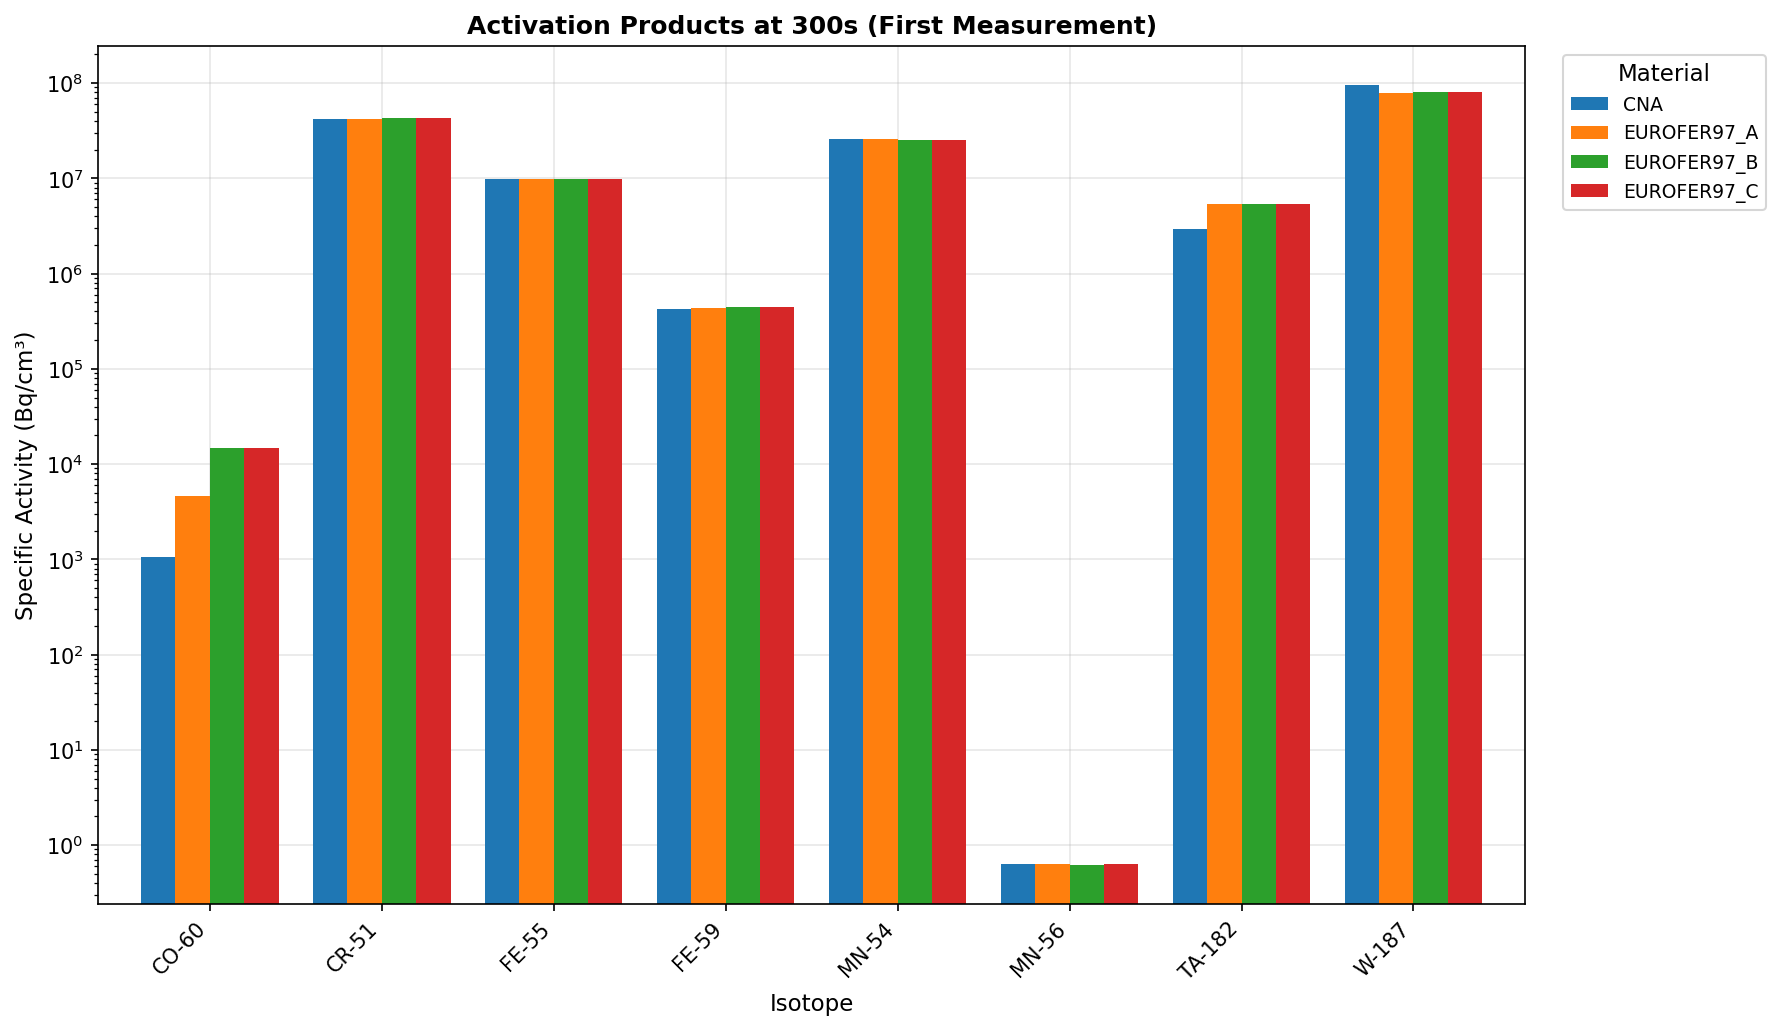

In [99]:
# ==============================================================================
# CROSS-MATERIAL COMPARISON: KEY ACTIVATION PRODUCTS
# ==============================================================================
# Compare specific isotopes across all EUROFER materials.
# Using first experimental measurement time (300s) instead of shutdown.
# Saves plots to alara_output/activity_plots/
# ==============================================================================

FIRST_EXP_TIME = 300  # seconds

if adf is not None and not adf.empty:
    print("=" * 80)
    print("Cross-Material Comparison: Key Activation Products")
    print(f"At first measurement time (300s after irradiation)")
    print("=" * 80)
    
    # Key isotopes to compare
    key_isotopes = ['mn-54', 'mn-56', 'co-60', 'fe-55', 'fe-59', 'cr-51', 'ta-182', 'w-187']
    eurofer_materials = ['CNA', 'EUROFER97_A', 'EUROFER97_B', 'EUROFER97_C']
    
    # Filter for specific activity at first measurement time (300s)
    comparison_data = []
    
    for material in eurofer_materials:
        if material not in adf['run_lbl'].values:
            continue
            
        filtered = adf.filter_rows({
            'run_lbl': material,
            'variable': adf.VARIABLE_ENUM['Specific Activity'],
            'time': float(FIRST_EXP_TIME)  # first measurement (300s)
        })
        
        for iso in key_isotopes:
            iso_data = filtered[filtered['nuclide'] == iso]
            if not iso_data.empty:
                activity = iso_data['value'].values[0]
                comparison_data.append({
                    'Material': material,
                    'Isotope': iso.upper(),
                    'Activity_Bq_cm3': activity,
                })
    
    if comparison_data:
        comp_df = pd.DataFrame(comparison_data)
        pivot_comp = comp_df.pivot_table(
            index='Isotope',
            columns='Material',
            values='Activity_Bq_cm3',
            aggfunc='first',
        )
        
        print(f"\nSpecific Activity at 300s (Bq/cm³):")
        print("-" * 60)
        with pd.option_context('display.float_format', '{:.3e}'.format):
            print(pivot_comp.to_string())
        
        # Plot comparison
        fig, ax = plt.subplots(figsize=(12, 7))
        
        # Custom colors for materials
        material_colors = {
            'CNA': '#1f77b4',
            'EUROFER97_A': '#ff7f0e',
            'EUROFER97_B': '#2ca02c',
            'EUROFER97_C': '#d62728',
        }
        
        pivot_comp.plot(
            kind='bar',
            ax=ax,
            width=0.8,
            color=[material_colors.get(c, '#333') for c in pivot_comp.columns],
        )
        
        ax.set_ylabel('Specific Activity (Bq/cm³)', fontsize=11)
        ax.set_xlabel('Isotope', fontsize=11)
        ax.set_title('Activation Products at 300s (First Measurement)', fontsize=12, fontweight='bold')
        ax.set_yscale('log')
        ax.legend(title='Material', bbox_to_anchor=(1.02, 1), loc='upper left')
        ax.grid(True, alpha=0.3, axis='y')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        
        # Save plot
        save_path = activity_plots_dir / 'material_comparison_300s.png'
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"\n✓ Saved: {save_path}")
        plt.show()
    else:
        print("No comparison data found")
else:
    print("⚠ ALARADFrame not available - run previous cells first")

In [100]:
# ==============================================================================
# VISUALIZATION: Z-SCORE VS DELAY TIME (PER ISOTOPE)
# ==============================================================================
# Show how detectability changes with cooling/delay time

print("=" * 70)
print("Z-SCORE VS DELAY TIME ANALYSIS")
print("=" * 70)

# Fix irradiation and counting time, vary delay
fixed_t_irrad = hours_to_seconds(3/3600)  # 3 seconds
fixed_t_count = hours_to_seconds(2)        # 2 hours

delay_times_h = np.array([1/60, 2/60, 5/60, 10/60, 15/60, 30/60, 1, 2, 4, 8, 12, 24, 48, 96, 168])  # hours
delay_times_s = delay_times_h * 3600

# Calculate Z-score for each line at each delay time
z_scores_by_line = {f"{line.nuclide}-{line.energy_keV:.0f}": [] for line in target_lines}

for t_delay in delay_times_s:
    schedule = Schedule(
        t_i1=fixed_t_irrad,
        t_d1=t_delay,
        t_c1=fixed_t_count,
        t_i2=0, t_d2=0, t_c2=0
    )
    
    results = simulate_schedule(
        schedule=schedule,
        gamma_lines=target_lines,
        activity_interpolator=activity_interp,
        eff_func=efficiency_fn,
        background_model=background
    )
    
    # Extract cycle1 results
    for metrics in results['cycle1']:
        label = f"{metrics.nuclide}-{metrics.energy_keV:.0f}"
        if label in z_scores_by_line:
            z_scores_by_line[label].append(metrics.z_score)

# Create plot and save (not displayed - see snr_output_dir)
fig, ax = plt.subplots(figsize=(14, 8))

# Group by half-life for coloring
cmap = plt.cm.tab10
colors = {}
nuclides_by_halflife = sorted(set(l.nuclide for l in target_lines), 
                               key=lambda n: next(l.half_life_s for l in target_lines if l.nuclide == n))

for i, nuc in enumerate(nuclides_by_halflife):
    colors[nuc] = cmap(i % 10)

for line in target_lines:
    label = f"{line.nuclide}-{line.energy_keV:.0f}"
    z_scores = z_scores_by_line[label]
    if len(z_scores) > 0:
        ax.semilogx(delay_times_h, z_scores, 'o-', 
                    label=label, color=colors[line.nuclide], 
                    linewidth=2, markersize=6)

# Detection thresholds
ax.axhline(y=3.29, color='green', linestyle='--', linewidth=2, alpha=0.7, label='$L_d$ (Z=3.29)')
ax.axhline(y=1.64, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='$L_c$ (Z=1.64)')

ax.set_xlabel('Delay Time (hours)', fontsize=12)
ax.set_ylabel('Z-score', fontsize=12)
ax.set_title(f'Detectability vs Delay Time\n(t_irrad={fixed_t_irrad}s, t_count={fixed_t_count/3600:.0f}h)', fontsize=14)
ax.legend(loc='upper right', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3, which='both')
ax.set_xlim(delay_times_h.min() * 0.8, delay_times_h.max() * 1.2)

plt.tight_layout()
fig.savefig(snr_output_dir / 'zscore_vs_delay_time.png', dpi=150)
plt.close(fig)
print(f"✓ Plot saved to: {snr_output_dir / 'zscore_vs_delay_time.png'}")

# Optimal delay for each isotope
print("\nOptimal delay time for each gamma line:")
print(f"{'Line':<25} {'Optimal Delay':<15} {'Max Z-score':<12}")
print("-" * 55)
for line in target_lines:
    label = f"{line.nuclide}-{line.energy_keV:.0f}"
    z_scores = z_scores_by_line[label]
    if len(z_scores) > 0:
        max_idx = np.argmax(z_scores)
        opt_delay_h = delay_times_h[max_idx]
        max_z = z_scores[max_idx]
        delay_str = f"{opt_delay_h:.1f}h" if opt_delay_h >= 1 else f"{opt_delay_h*60:.0f}m"
        print(f"{label:<25} {delay_str:<15} {max_z:<12.2f}")

Z-SCORE VS DELAY TIME ANALYSIS
✓ Plot saved to: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/snr_optimization/zscore_vs_delay_time.png

Optimal delay time for each gamma line:
Line                      Optimal Delay   Max Z-score 
-------------------------------------------------------
V-52-1434                 1m              5532.74     
Mn-56-847                 1m              8125.54     
Mn-56-1811                1m              3650.63     
Al-28-1779                1m              4109.01     
W-187-686                 1m              3009.47     
W-187-480                 1m              2896.84     
Na-24-1369                1m              8226.37     
Na-24-2754                1m              7180.59     
Cu-64-511                 1m              5917.27     
Cr-51-320                 1m              355.51      
Fe-59-1099                1m              878.82      
Fe-59-1292                1m              744.70      
Co-60-1173     

In [101]:
# ==============================================================================
# VISUALIZATION: MDA VS COUNTING TIME
# ==============================================================================
# Show how MDA improves with longer counting

print("=" * 70)
print("MDA VS COUNTING TIME ANALYSIS")
print("=" * 70)

# Fix irradiation and delay time, vary counting
fixed_t_irrad = hours_to_seconds(3/3600)  # 3 seconds
fixed_t_delay = hours_to_seconds(0.5)      # 30 minutes

count_times_h = np.array([0.1, 0.25, 0.5, 1, 2, 4, 8, 12, 24])  # hours
count_times_s = count_times_h * 3600

# Calculate MDA for each line at each counting time
mda_by_line = {f"{line.nuclide}-{line.energy_keV:.0f}": [] for line in target_lines}

for t_count in count_times_s:
    schedule = Schedule(
        t_i1=fixed_t_irrad,
        t_d1=fixed_t_delay,
        t_c1=t_count,
        t_i2=0, t_d2=0, t_c2=0
    )
    
    results = simulate_schedule(
        schedule=schedule,
        gamma_lines=target_lines,
        activity_interpolator=activity_interp,
        eff_func=efficiency_fn,
        background_model=background
    )
    
    # Extract cycle1 results
    for metrics in results['cycle1']:
        label = f"{metrics.nuclide}-{metrics.energy_keV:.0f}"
        if label in mda_by_line:
            if metrics.mda_Bq:
                mda_by_line[label].append(metrics.mda_Bq)
            else:
                mda_by_line[label].append(np.nan)

# Create and save plot (not displayed)
fig, ax = plt.subplots(figsize=(14, 8))

for line in target_lines:
    label = f"{line.nuclide}-{line.energy_keV:.0f}"
    mdas = mda_by_line[label]
    if len(mdas) > 0:
        ax.loglog(count_times_h, mdas, 'o-', 
                  label=label, color=colors[line.nuclide],
                  linewidth=2, markersize=6)

ax.set_xlabel('Counting Time (hours)', fontsize=12)
ax.set_ylabel('MDA (Bq)', fontsize=12)
ax.set_title(f'Minimum Detectable Activity vs Counting Time\n(t_irrad={fixed_t_irrad}s, t_delay={fixed_t_delay/60:.0f}min)', fontsize=14)
ax.legend(loc='upper right', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
fig.savefig(snr_output_dir / 'mda_vs_count_time.png', dpi=150)
plt.close(fig)
print(f"✓ Plot saved to: {snr_output_dir / 'mda_vs_count_time.png'}")

# Show MDA values at key counting times
print(f"\nMDA (Bq) at different counting times (t_delay={fixed_t_delay/60:.0f}min):")
print(f"\n{'Line':<25} {'0.5h':<12} {'1h':<12} {'2h':<12} {'4h':<12} {'8h':<12}")
print("-" * 80)

count_indices = [2, 3, 4, 5, 6]  # 0.5, 1, 2, 4, 8 hours
for line in target_lines:
    label = f"{line.nuclide}-{line.energy_keV:.0f}"
    mdas = mda_by_line[label]
    if len(mdas) > 0:
        mda_strs = [f"{mdas[i]:.1e}" if i < len(mdas) and not np.isnan(mdas[i]) else "N/A" for i in count_indices]
        print(f"{label:<25} {mda_strs[0]:<12} {mda_strs[1]:<12} {mda_strs[2]:<12} {mda_strs[3]:<12} {mda_strs[4]:<12}")

MDA VS COUNTING TIME ANALYSIS
✓ Plot saved to: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/snr_optimization/mda_vs_count_time.png

MDA (Bq) at different counting times (t_delay=30min):

Line                      0.5h         1h           2h           4h           8h          
--------------------------------------------------------------------------------
V-52-1434                 1.4e+01      1.6e+01      1.9e+01      2.4e+01      3.0e+01     
Mn-56-847                 2.3e+00      1.4e+00      9.9e-01      7.8e-01      7.4e-01     
Mn-56-1811                1.1e+01      6.5e+00      4.4e+00      3.4e+00      3.1e+00     
Al-28-1779                2.5e+01      2.8e+01      3.4e+01      4.1e+01      5.2e+01     
W-187-686                 2.1e+00      1.2e+00      7.5e-01      4.8e-01      3.3e-01     
W-187-480                 2.3e+00      1.4e+00      8.7e-01      5.6e-01      3.8e-01     
Na-24-1369                2.5e+00      1.5e+00      9.0e-

OPTIMIZATION HEATMAP: DELAY TIME vs COUNTING TIME


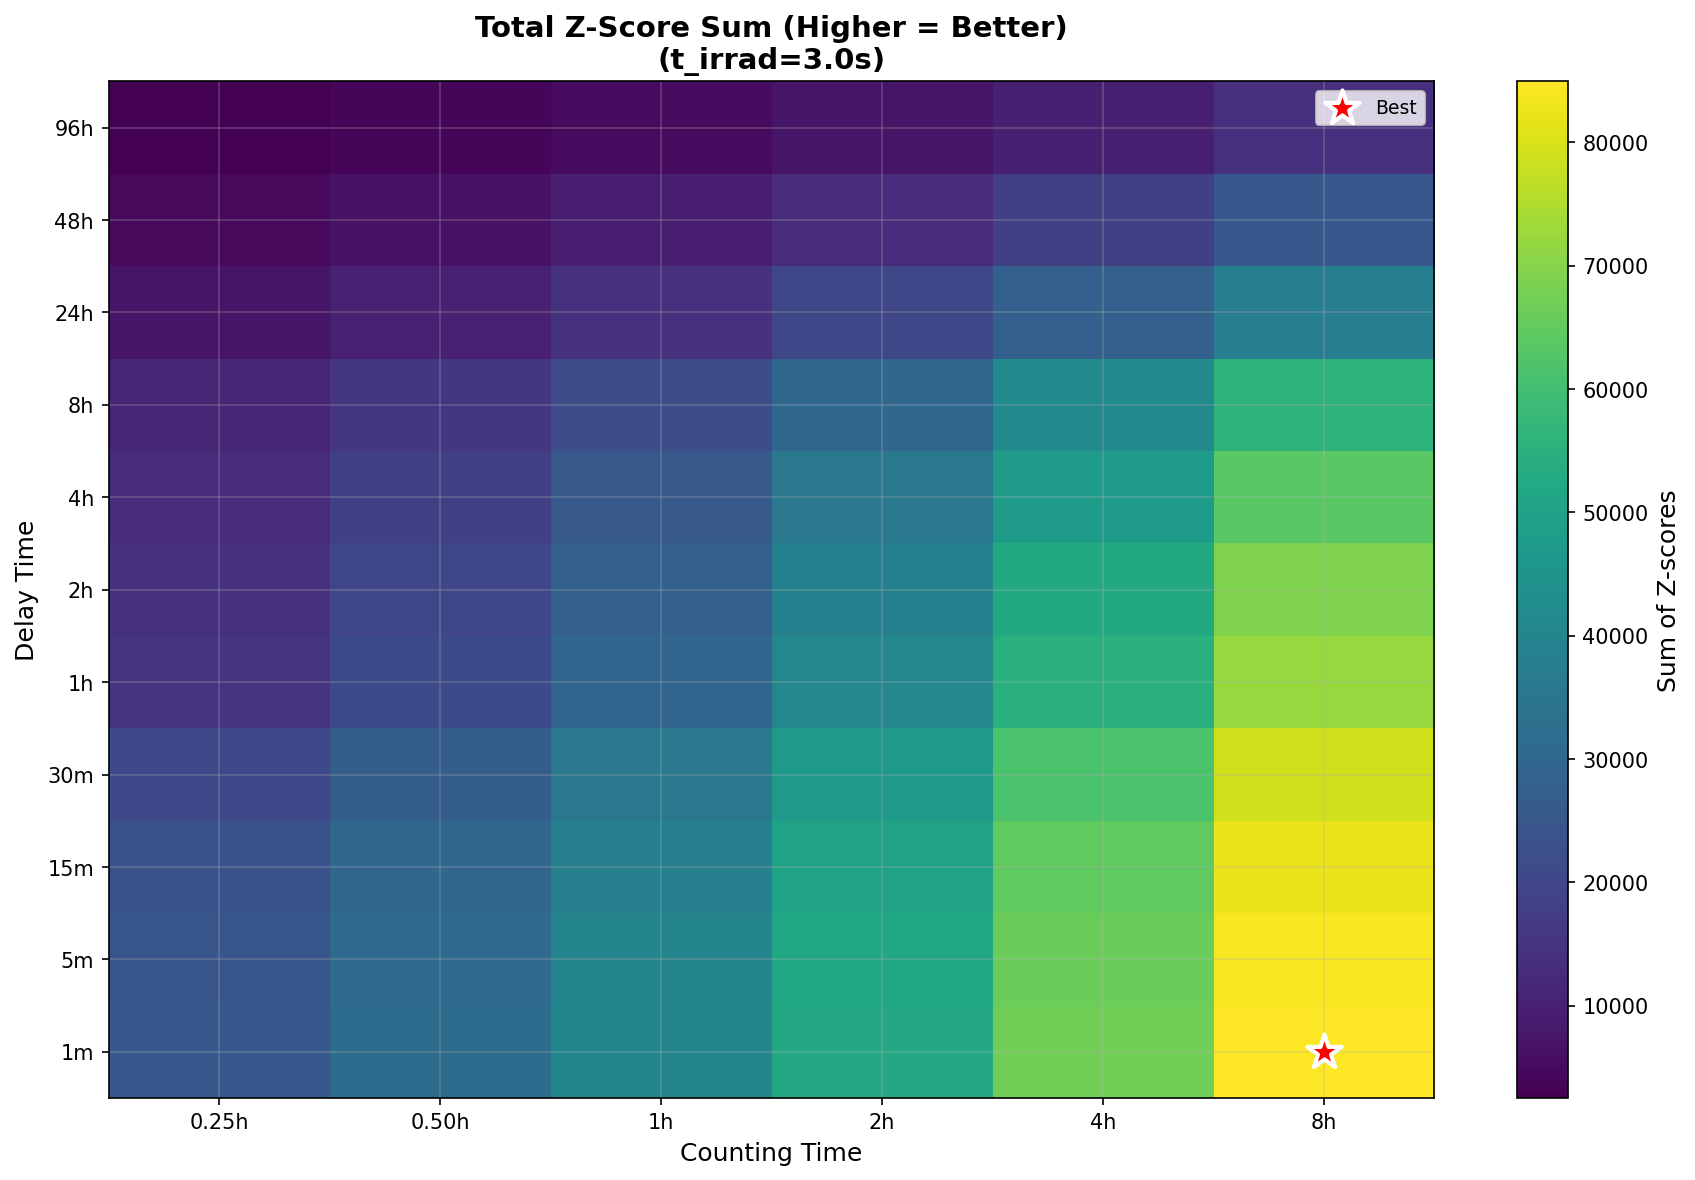


Best combination in grid:
  Delay: 1 min
  Counting: 8.0 h
  Total Z-score sum: 84946.5


In [102]:
# ==============================================================================
# HEATMAP: DELAY TIME vs COUNTING TIME OPTIMIZATION
# ==============================================================================
# 2D visualization of detectability landscape

print("=" * 70)
print("OPTIMIZATION HEATMAP: DELAY TIME vs COUNTING TIME")
print("=" * 70)

# Create 2D grid
delay_grid_h = np.array([1/60, 5/60, 15/60, 0.5, 1, 2, 4, 8, 24, 48, 96])
count_grid_h = np.array([0.25, 0.5, 1, 2, 4, 8])
fixed_t_irrad = hours_to_seconds(3/3600)

# Calculate total Z-score sum for each combination
z_matrix = np.zeros((len(delay_grid_h), len(count_grid_h)))

for i, t_delay_h in enumerate(delay_grid_h):
    for j, t_count_h in enumerate(count_grid_h):
        schedule = Schedule(
            t_i1=fixed_t_irrad,
            t_d1=hours_to_seconds(t_delay_h),
            t_c1=hours_to_seconds(t_count_h),
            t_i2=0, t_d2=0, t_c2=0
        )
        
        results = simulate_schedule(
            schedule=schedule,
            gamma_lines=target_lines,
            activity_interpolator=activity_interp,
            eff_func=efficiency_fn,
            background_model=background
        )
        
        # Sum of Z-scores from cycle1
        total_z = sum(m.z_score for m in results['cycle1'])
        z_matrix[i, j] = total_z

# Create heatmap
fig, ax = plt.subplots(figsize=(12, 8))

# Format delay axis labels
delay_labels = []
for d in delay_grid_h:
    if d < 1:
        delay_labels.append(f"{d*60:.0f}m")
    else:
        delay_labels.append(f"{d:.0f}h")

count_labels = [f"{c:.2f}h" if c < 1 else f"{c:.0f}h" for c in count_grid_h]

im = ax.imshow(z_matrix, cmap='viridis', aspect='auto', origin='lower')
ax.set_xticks(range(len(count_grid_h)))
ax.set_xticklabels(count_labels)
ax.set_yticks(range(len(delay_grid_h)))
ax.set_yticklabels(delay_labels)

ax.set_xlabel('Counting Time', fontsize=12)
ax.set_ylabel('Delay Time', fontsize=12)
ax.set_title(f'Total Z-Score Sum (Higher = Better)\n(t_irrad={fixed_t_irrad}s)', fontsize=14)

cbar = plt.colorbar(im, ax=ax, label='Sum of Z-scores')

# Mark the best cell
best_idx = np.unravel_index(np.argmax(z_matrix), z_matrix.shape)
ax.scatter(best_idx[1], best_idx[0], s=300, marker='*', color='red', 
           edgecolors='white', linewidths=2, zorder=10, label='Best')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Find and report best combination
best_delay_h = delay_grid_h[best_idx[0]]
best_count_h = count_grid_h[best_idx[1]]
best_z = z_matrix[best_idx[0], best_idx[1]]

print(f"\nBest combination in grid:")
delay_str = f"{best_delay_h*60:.0f} min" if best_delay_h < 1 else f"{best_delay_h:.0f} h"
print(f"  Delay: {delay_str}")
print(f"  Counting: {best_count_h:.1f} h")
print(f"  Total Z-score sum: {best_z:.1f}")

In [103]:
# ==============================================================================
# MULTI-MEASUREMENT SCHEDULE OPTIMIZATION
# ==============================================================================
# Optimize for two sequential irradiation+counting cycles
# (first at short delay for short-lived isotopes, second at long delay for long-lived)

print("=" * 70)
print("MULTI-MEASUREMENT SCHEDULE OPTIMIZATION")
print("=" * 70)
print("Strategy: Two measurement windows to capture different half-life regimes")

# Define two-measurement schedules
# Measurement 1: Quick count for short-lived isotopes (V-52, Mn-56)
# Measurement 2: Delayed count for long-lived isotopes (Cr-51, Ta-182, Fe-59, etc.)

multi_schedules = [
    # (name, t_irrad1, t_delay1, t_count1, t_irrad2, t_delay2, t_count2)
    ("Quick + 4d delay", 3, 5/60, 0.5, 0, 96, 4),  # 5min then 4 days
    ("Quick + 1d delay", 3, 5/60, 0.5, 0, 24, 4),  # 5min then 1 day
    ("Quick + 6h delay", 3, 5/60, 0.5, 0, 6, 2),   # 5min then 6 hours
    ("30min + 4d delay", 3, 30/60, 1, 0, 96, 8),   # 30min then 4 days
    ("2h + 4d delay", 3, 2, 2, 0, 96, 8),          # 2h then 4 days
]

print(f"\n{'Schedule':<20} {'M1 delay':<12} {'M1 count':<12} {'M2 delay':<12} {'M2 count':<12} {'Score':<10}")
print("-" * 80)

multi_results = []
for name, t_i1, t_d1, t_c1, t_i2, t_d2, t_c2 in multi_schedules:
    schedule = Schedule(
        t_i1=t_i1 if t_i1 < 100 else hours_to_seconds(t_i1),  # seconds or hours
        t_d1=hours_to_seconds(t_d1),
        t_c1=hours_to_seconds(t_c1),
        t_i2=hours_to_seconds(t_i2) if t_i2 > 0 else 0,
        t_d2=hours_to_seconds(t_d2) if t_d2 > 0 else 0,
        t_c2=hours_to_seconds(t_c2) if t_c2 > 0 else 0,
    )
    
    # Simulate both measurements
    results1 = simulate_schedule(
        Schedule(schedule.t_i1, schedule.t_d1, schedule.t_c1, 0, 0, 0),
        target_lines, activity_interp, efficiency_fn, background
    )
    
    combined = {}
    # Get cycle1 results
    for m in results1['cycle1']:
        key = (m.nuclide, m.energy_keV)
        combined[key] = m.z_score
    
    if schedule.t_c2 > 0:
        results2 = simulate_schedule(
            Schedule(schedule.t_i1, schedule.t_d2, schedule.t_c2, 0, 0, 0),
            target_lines, activity_interp, efficiency_fn, background
        )
        # Combine: take best Z-score for each line
        for m in results2['cycle1']:
            key = (m.nuclide, m.energy_keV)
            if key in combined:
                combined[key] = max(combined[key], m.z_score)
            else:
                combined[key] = m.z_score
    
    total_score = sum(combined.values())
    multi_results.append((name, schedule, combined, total_score))
    
    d1_str = f"{t_d1*60:.0f}m" if t_d1 < 1 else f"{t_d1:.0f}h"
    d2_str = f"{t_d2:.0f}h" if t_d2 >= 1 else f"{t_d2*60:.0f}m" if t_d2 > 0 else "-"
    c1_str = f"{t_c1:.1f}h"
    c2_str = f"{t_c2:.0f}h" if t_c2 > 0 else "-"
    
    print(f"{name:<20} {d1_str:<12} {c1_str:<12} {d2_str:<12} {c2_str:<12} {total_score:<10.1f}")

# Best multi-measurement schedule
best_multi = max(multi_results, key=lambda x: x[3])
print(f"\nBest multi-measurement strategy: {best_multi[0]}")
print(f"Total Z-score sum: {best_multi[3]:.1f}")

MULTI-MEASUREMENT SCHEDULE OPTIMIZATION
Strategy: Two measurement windows to capture different half-life regimes

Schedule             M1 delay     M1 count     M2 delay     M2 count     Score     
--------------------------------------------------------------------------------
Quick + 4d delay     5m           0.5h         96h          4h           34286.5   
Quick + 1d delay     5m           0.5h         24h          4h           42825.2   
Quick + 6h delay     5m           0.5h         6h           2h           42965.1   
30min + 4d delay     30m          1.0h         96h          8h           39880.3   
2h + 4d delay        2h           2.0h         96h          8h           41992.6   

Best multi-measurement strategy: Quick + 6h delay
Total Z-score sum: 42965.1


RECOMMENDED MEASUREMENT SCHEDULE FOR EUROFER ACTIVATION

Based on the grid search optimization for EUROFER97 irradiated for 3 seconds:

RECOMMENDED TWO-MEASUREMENT PROTOCOL:

MEASUREMENT 1 (Short-lived isotopes):
  ├─ Transfer time: ~1-5 minutes (minimize!)
  ├─ Target isotopes: V-52 (3.7 min), Mn-56 (2.58 h)
  ├─ Counting time: 30 min - 1 hour
  └─ Priority: Start counting ASAP after irradiation

MEASUREMENT 2 (Long-lived isotopes):
  ├─ Delay: 4+ days (allow short-lived to decay)
  ├─ Target isotopes: Cr-51, Ta-182, Fe-59, Mn-54, Co-60
  ├─ Counting time: 4-8 hours (better statistics)
  └─ Benefit: Lower background from decayed short-lived isotopes

KEY PHYSICS INSIGHTS:
• Short-lived isotopes (T½ < 4h): Count immediately - activity drops fast
• Medium-lived isotopes (T½ ~ days): Flexible timing, reasonable at any delay
• Long-lived isotopes (T½ > weeks): Benefit from delayed counting (less interference)

DETECTION LIMITS:
• All isotopes above L_d threshold at optimal delay times
• M

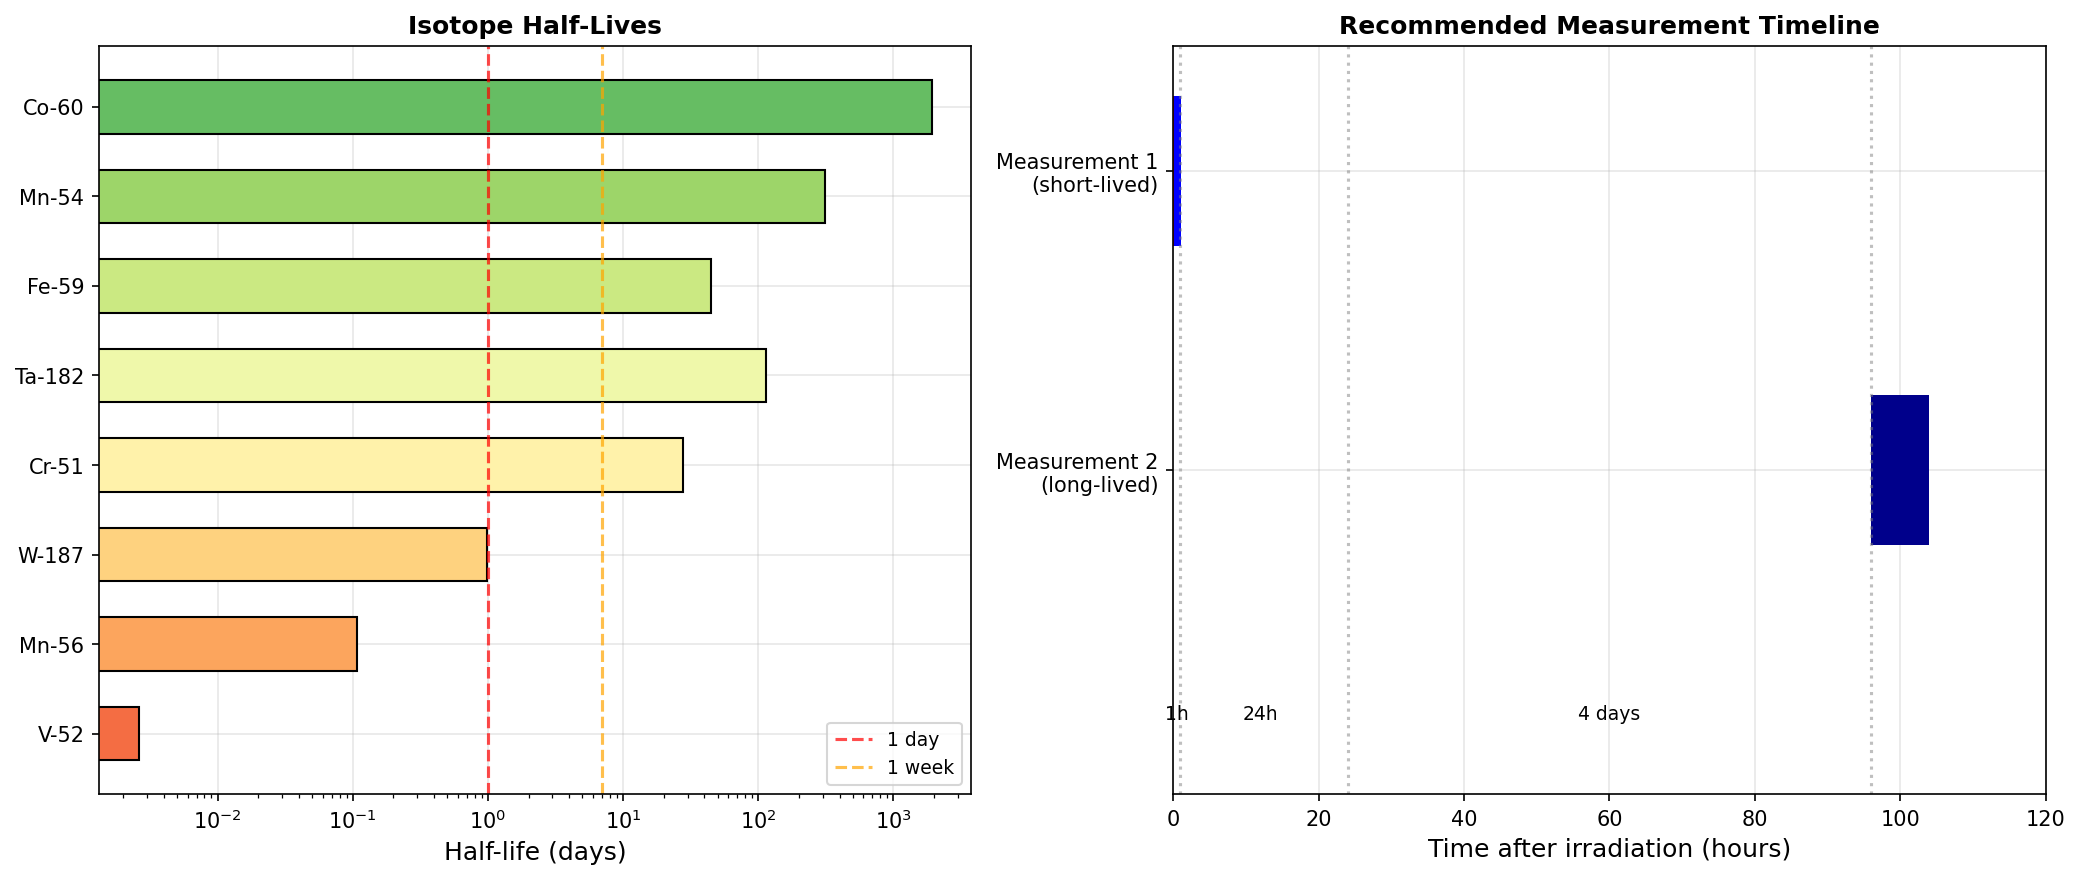


Schedule optimizer analysis complete!


In [104]:
# ==============================================================================
# SUMMARY: RECOMMENDED MEASUREMENT SCHEDULE
# ==============================================================================

print("=" * 70)
print("RECOMMENDED MEASUREMENT SCHEDULE FOR EUROFER ACTIVATION")
print("=" * 70)

# Based on the optimization results, recommend a practical schedule
print("""
Based on the grid search optimization for EUROFER97 irradiated for 3 seconds:

RECOMMENDED TWO-MEASUREMENT PROTOCOL:
=====================================

MEASUREMENT 1 (Short-lived isotopes):
  ├─ Transfer time: ~1-5 minutes (minimize!)
  ├─ Target isotopes: V-52 (3.7 min), Mn-56 (2.58 h)
  ├─ Counting time: 30 min - 1 hour
  └─ Priority: Start counting ASAP after irradiation

MEASUREMENT 2 (Long-lived isotopes):
  ├─ Delay: 4+ days (allow short-lived to decay)
  ├─ Target isotopes: Cr-51, Ta-182, Fe-59, Mn-54, Co-60
  ├─ Counting time: 4-8 hours (better statistics)
  └─ Benefit: Lower background from decayed short-lived isotopes

KEY PHYSICS INSIGHTS:
====================
• Short-lived isotopes (T½ < 4h): Count immediately - activity drops fast
• Medium-lived isotopes (T½ ~ days): Flexible timing, reasonable at any delay
• Long-lived isotopes (T½ > weeks): Benefit from delayed counting (less interference)

DETECTION LIMITS:
================
• All isotopes above L_d threshold at optimal delay times
• MDA scales approximately as 1/√(counting time)
• Longer counting helps, but diminishing returns beyond 4-8 hours

PRACTICAL CONSIDERATIONS:
========================
• Reactor pulsing time: 3 seconds (fixed by facility)
• Sample transfer time: ~1-2 min minimum
• Detector availability: May constrain counting time
• Dead time: Watch for pile-up with very hot samples
""")

# Create a visual summary
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Detection windows
ax = axes[0]
isotopes = ['V-52', 'Mn-56', 'W-187', 'Cr-51', 'Ta-182', 'Fe-59', 'Mn-54', 'Co-60']
half_lives_d = [3.75/(24*60), 2.58/24, 23.7/24, 27.7, 114.4, 44.5, 312.3, 5.27*365]
colors_hl = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(isotopes)))

for i, (iso, hl) in enumerate(zip(isotopes, half_lives_d)):
    ax.barh(i, hl, color=colors_hl[i], edgecolor='black', height=0.6)
ax.set_yticks(range(len(isotopes)))
ax.set_yticklabels(isotopes)
ax.set_xlabel('Half-life (days)')
ax.set_xscale('log')
ax.set_title('Isotope Half-Lives', fontsize=12)
ax.axvline(x=1, color='red', linestyle='--', alpha=0.7, label='1 day')
ax.axvline(x=7, color='orange', linestyle='--', alpha=0.7, label='1 week')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='x')

# Right: Recommended schedule timeline
ax = axes[1]
ax.set_xlim(0, 120)
ax.set_ylim(0, 3)

# Measurement 1
ax.broken_barh([(0, 0.05)], (2.2, 0.6), facecolors='red', label='Irradiation (3s)')
ax.broken_barh([(0.05, 0.08)], (2.2, 0.6), facecolors='yellow', label='Transfer (~5 min)')
ax.broken_barh([(0.13, 1)], (2.2, 0.6), facecolors='blue', label='Count 1 (1h)')

# Measurement 2
ax.broken_barh([(96, 8)], (1.0, 0.6), facecolors='darkblue', label='Count 2 (8h)')

ax.set_xlabel('Time after irradiation (hours)')
ax.set_yticks([1.3, 2.5])
ax.set_yticklabels(['Measurement 2\n(long-lived)', 'Measurement 1\n(short-lived)'])
ax.set_title('Recommended Measurement Timeline', fontsize=12)
ax.axvline(x=1, color='gray', linestyle=':', alpha=0.5)
ax.axvline(x=24, color='gray', linestyle=':', alpha=0.5)
ax.axvline(x=96, color='gray', linestyle=':', alpha=0.5)
ax.text(0.5, 0.3, '1h', ha='center', fontsize=9)
ax.text(12, 0.3, '24h', ha='center', fontsize=9)
ax.text(60, 0.3, '4 days', ha='center', fontsize=9)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("Schedule optimizer analysis complete!")
print("=" * 70)

## ALARA vs Experimental Comparison Analysis

This section uses the `alara_comparison`, `alara_threshold_plotting`, and `alara_predictions_csv` modules
to perform comprehensive comparison between ALARA predictions and experimental measurements.

**Key Analysis Functions:**
1. **Comparison DataFrame** - Match experimental isotopes with ALARA predictions
2. **Threshold Plots** - Visualize ALARA-predicted isotopes above detection threshold
3. **Detailed Comparison by Material** - Side-by-side activity comparison
4. **CSV Export** - Save comparison data for further analysis

**Note:** These modules use the tools/ alara_output_processing framework without modifying it.

In [105]:
# ==============================================================================
# STEP 1: ALARA VS EXPERIMENTAL COMPARISON
# ==============================================================================

# Run the comparison - this matches experimental isotopes with ALARA predictions
# Uses DYNAMIC column matching based on time parsing (no more hardcoded maps!)
comparison_df = alara_comparison.compare_alara_to_experiment(
    experimental_data,
    alara_output_dir=alara_output_dir,
    material_to_tally=MATERIAL_TO_TALLY,
    verbose=True
)

# Save comparison to CSV
if not comparison_df.empty:
    alara_comparison.save_comparison_csv(
        comparison_df,
        alara_output_dir / 'experimental_comparison.csv'
    )
    print(f"\nComparison DataFrame has {len(comparison_df)} rows")
else:
    print("No comparison data generated - check that experimental and ALARA files exist")

COMPARISON: EXPERIMENTAL vs ALARA SIMULATION

MATERIAL: EUROFER97_2 (tally_85244)
  ALARA isotopes: ['ag-109m', 'al-26', 'as-73', 'as-74', 'as-76', 'as-77', 'ba-133', 'ba-133m', 'ba-135m', 'ba-139', 'ba-140', 'be-10', 'c-14', 'cd-109', 'cd-111m', 'cd-113', 'cd-113m', 'cd-115', 'cd-115m', 'cd-117', 'cd-117m', 'ce-135', 'ce-137', 'ce-137m', 'ce-139', 'ce-141', 'ce-142', 'ce-143', 'co-56', 'co-57', 'co-58', 'co-58m', 'co-60', 'co-61', 'cr-51', 'cu-64', 'fe-55', 'fe-59', 'fe-60', 'ga-72', 'ga-73', 'ge-73m', 'ge-75', 'h-3', 'hf-178n', 'hf-179n', 'hf-180m', 'hf-181', 'hf-182', 'hf-182m', 'hf-183', 'hf-184', 'in-110', 'in-110m', 'in-111', 'in-113m', 'in-114', 'in-114m', 'in-115', 'in-115m', 'in-116m', 'in-117', 'in-117m', 'la-135', 'la-137', 'la-138', 'la-140', 'la-141', 'la-142', 'lu-176', 'lu-176m', 'lu-177', 'lu-177m', 'lu-178', 'lu-179', 'mn-52', 'mn-53', 'mn-54', 'mn-56', 'mo-93', 'mo-93m', 'mo-99', 'na-24', 'nb-90', 'nb-91', 'nb-91m', 'nb-92', 'nb-92m', 'nb-93m', 'nb-94', 'nb-95', 'nb-9

comparison_df shape: (44, 20)
Matched isotopes: 38


/tmp/ipykernel_361558/3432093700.py:14: DeprecationWarning: plot_comparison_scatter() has moved to plotting.py. Use: from plotting import plot_comparison_scatter
  alara_comparison.plot_comparison_scatter(


Figure saved to: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/comparison_scatter.png


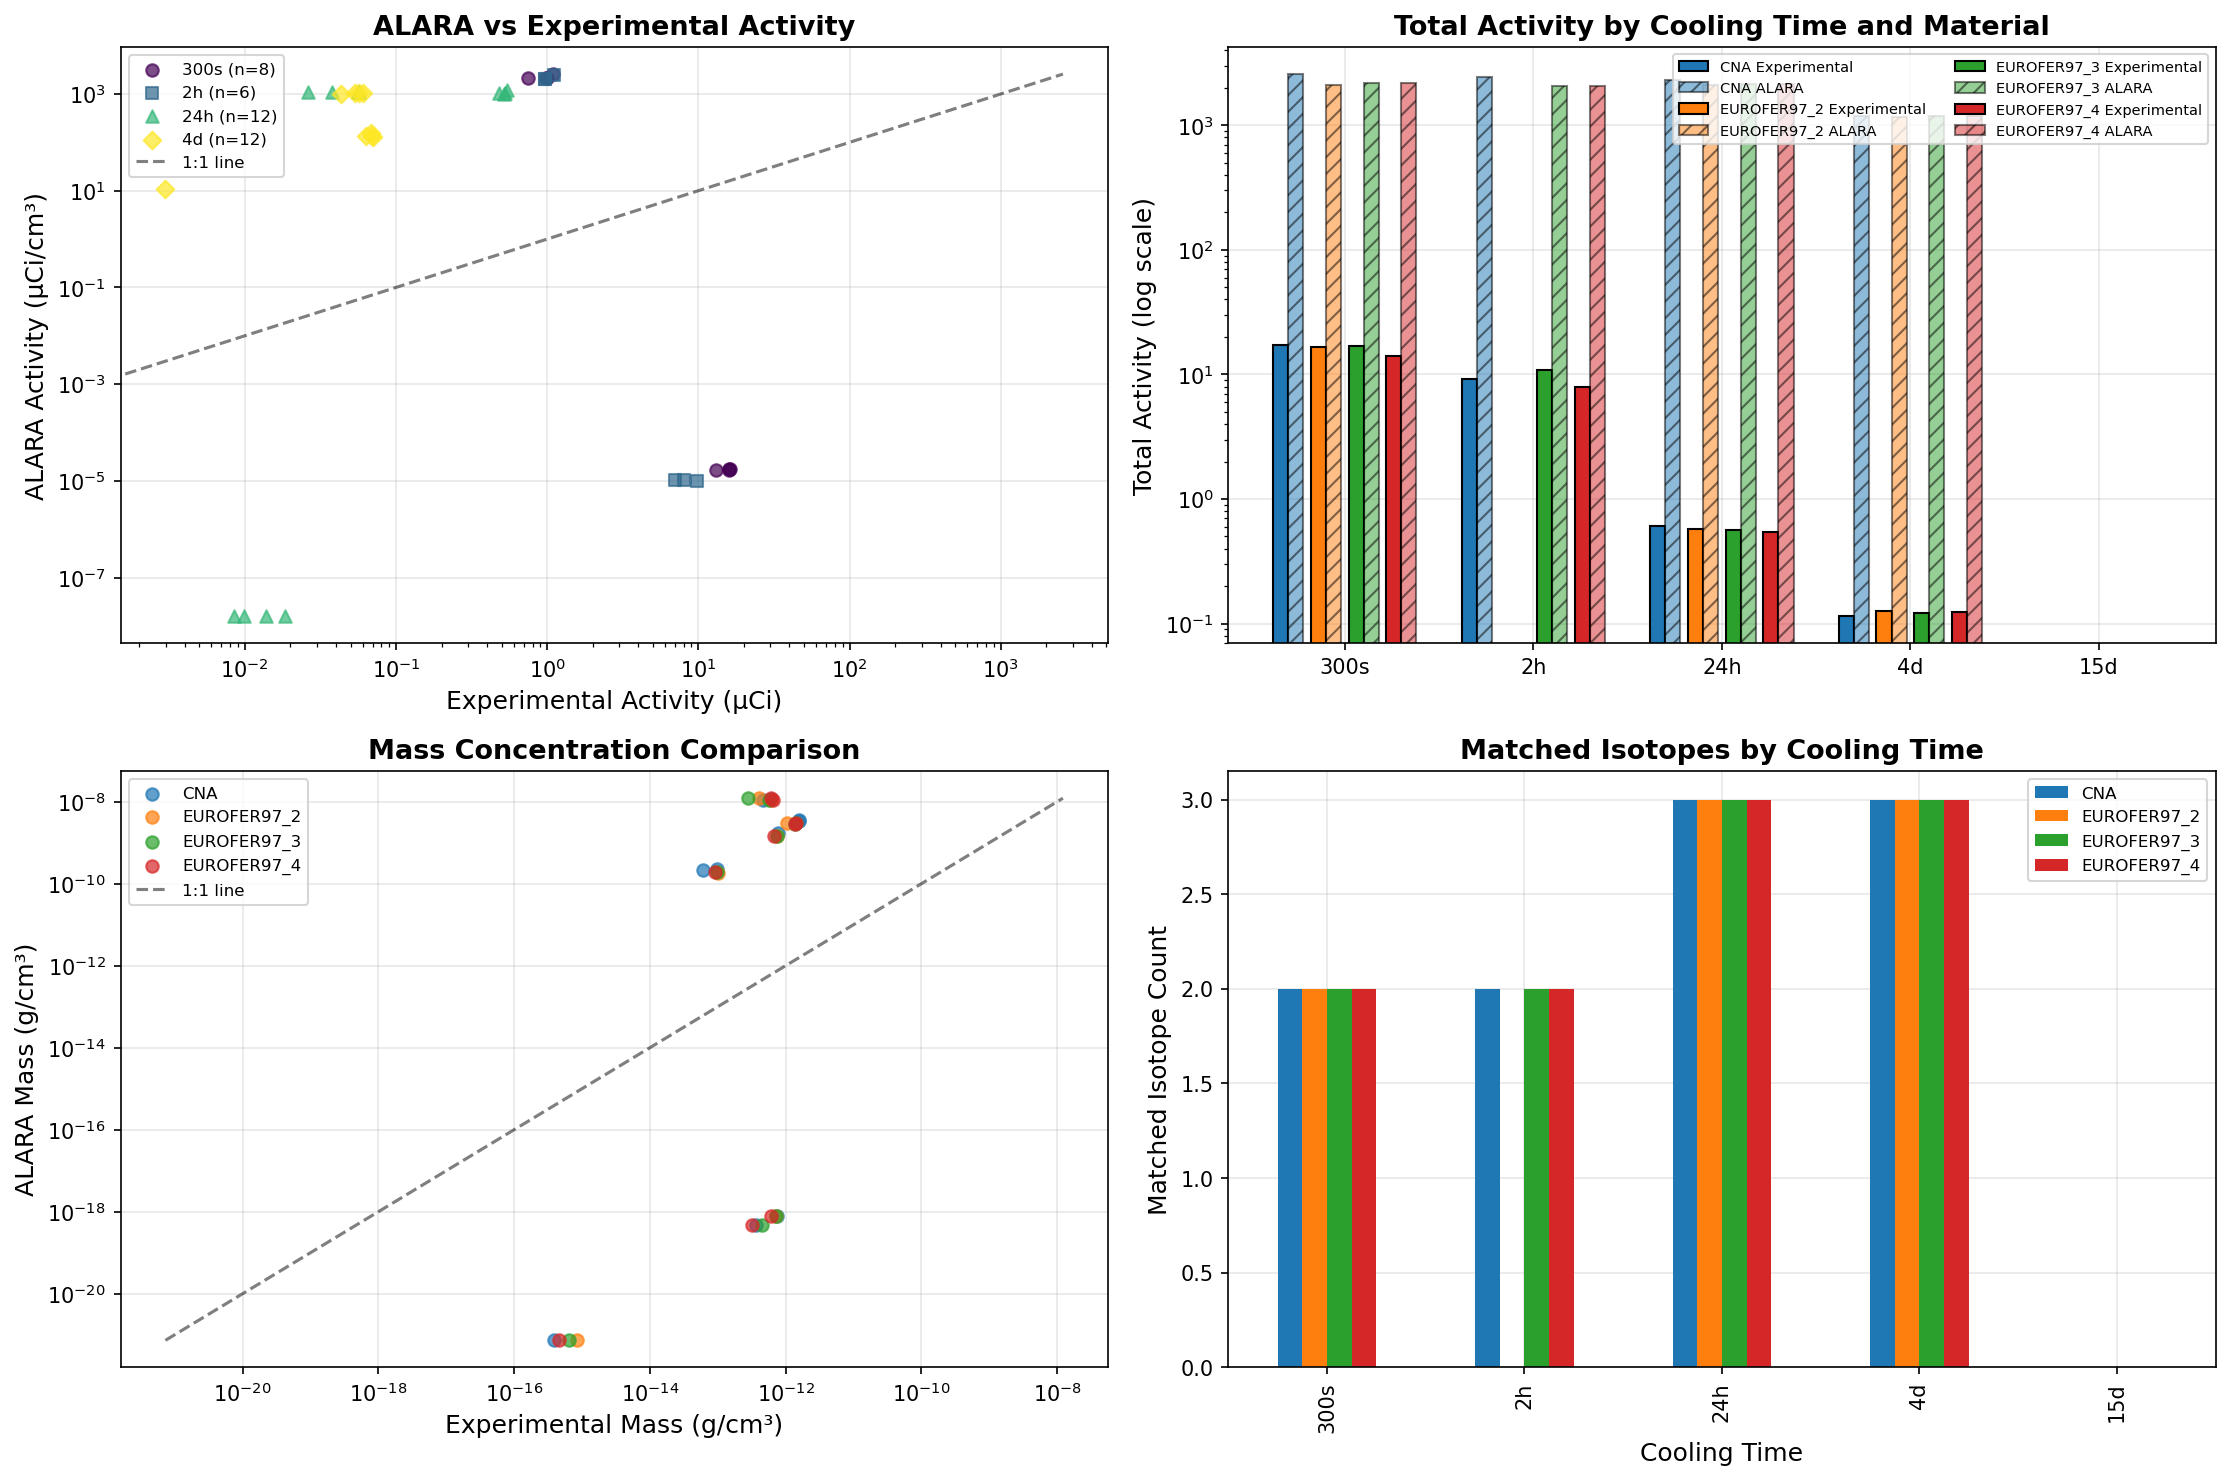

In [106]:
# ==============================================================================
# STEP 2: COMPARISON SCATTER PLOTS
# ==============================================================================

print(f"comparison_df shape: {comparison_df.shape}")

# Create scatter plots comparing activities (no ratio plots)
if not comparison_df.empty:
    # Get matched isotopes for plotting
    matched = alara_comparison.get_matched_isotopes(comparison_df)
    print(f"Matched isotopes: {len(matched)}")
    
    if not matched.empty:
        alara_comparison.plot_comparison_scatter(
            matched,
            save_path=alara_output_dir / 'comparison_scatter.png'
        )
    else:
        print("No matched isotopes to plot")
else:
    print("No comparison data available for plotting")

/tmp/ipykernel_361558/1308453573.py:11: DeprecationWarning: plot_comparison_by_material() has moved to plotting.py. Use: from plotting import plot_comparison_by_material
  material_figures = alara_comparison.plot_comparison_by_material(


Figure saved to: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/comparison_CNA.png


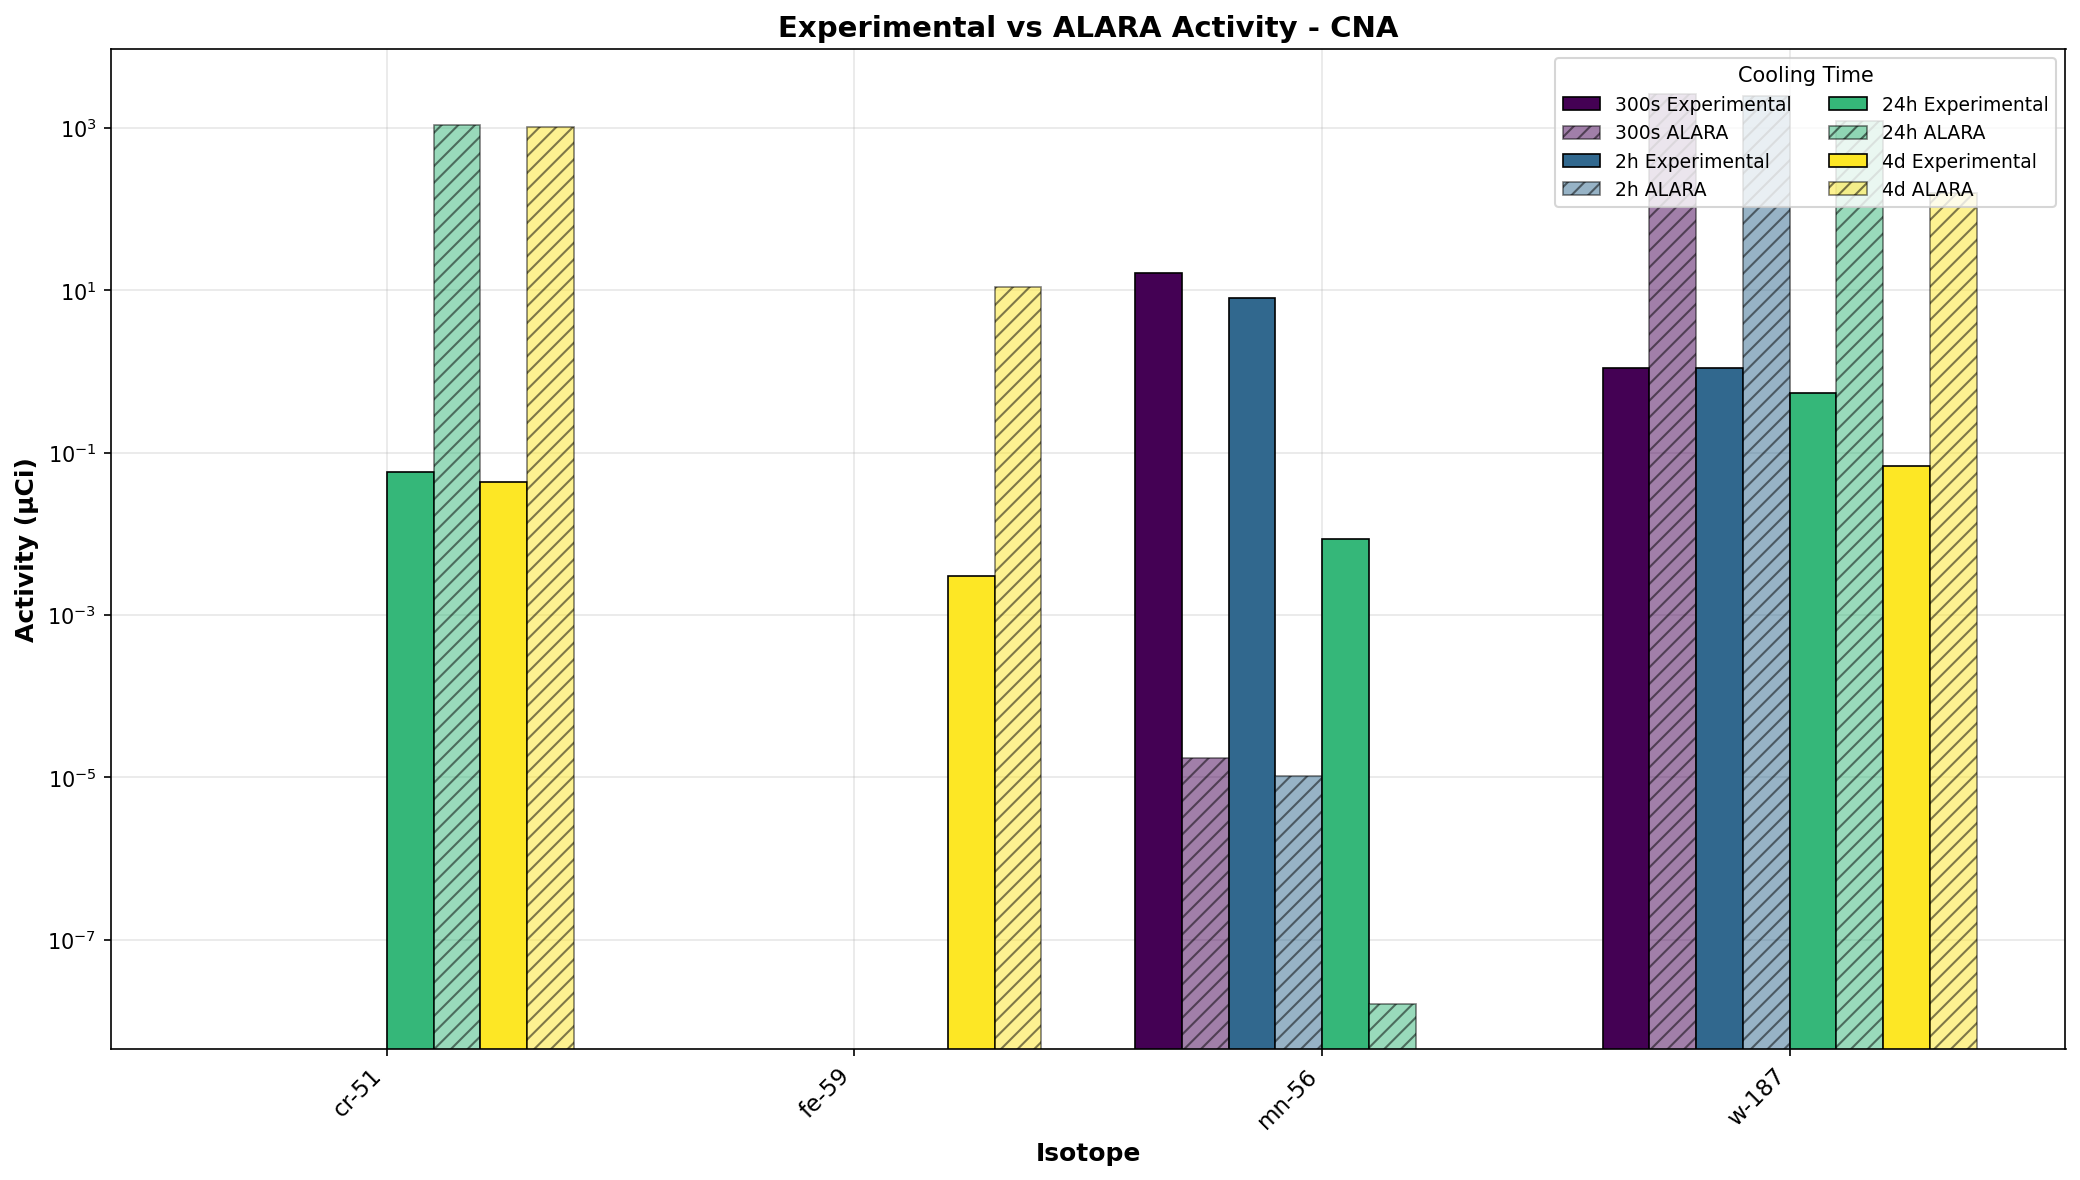

Figure saved to: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/comparison_EUROFER97_2.png


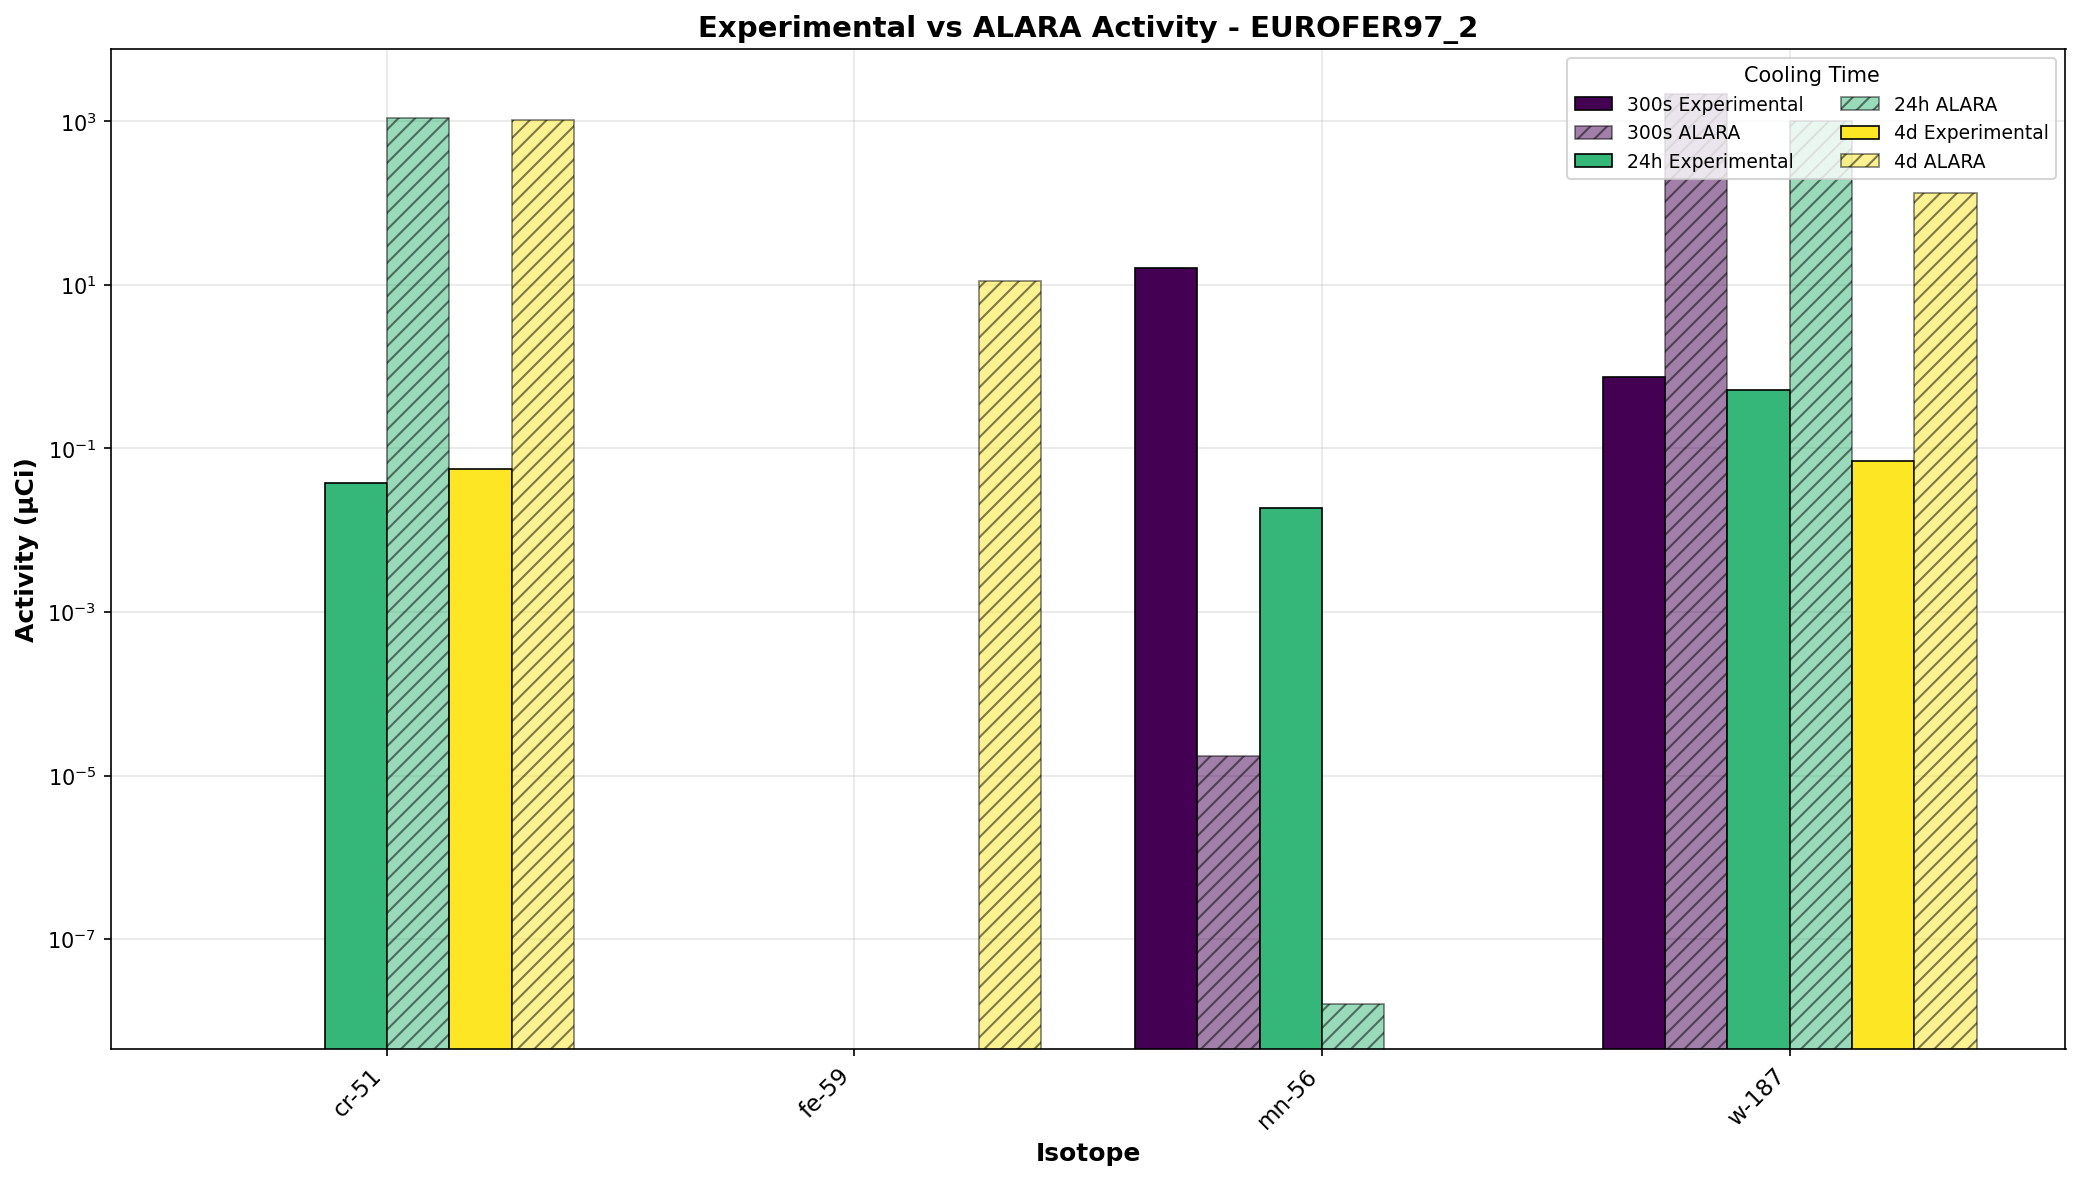

Figure saved to: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/comparison_EUROFER97_3.png


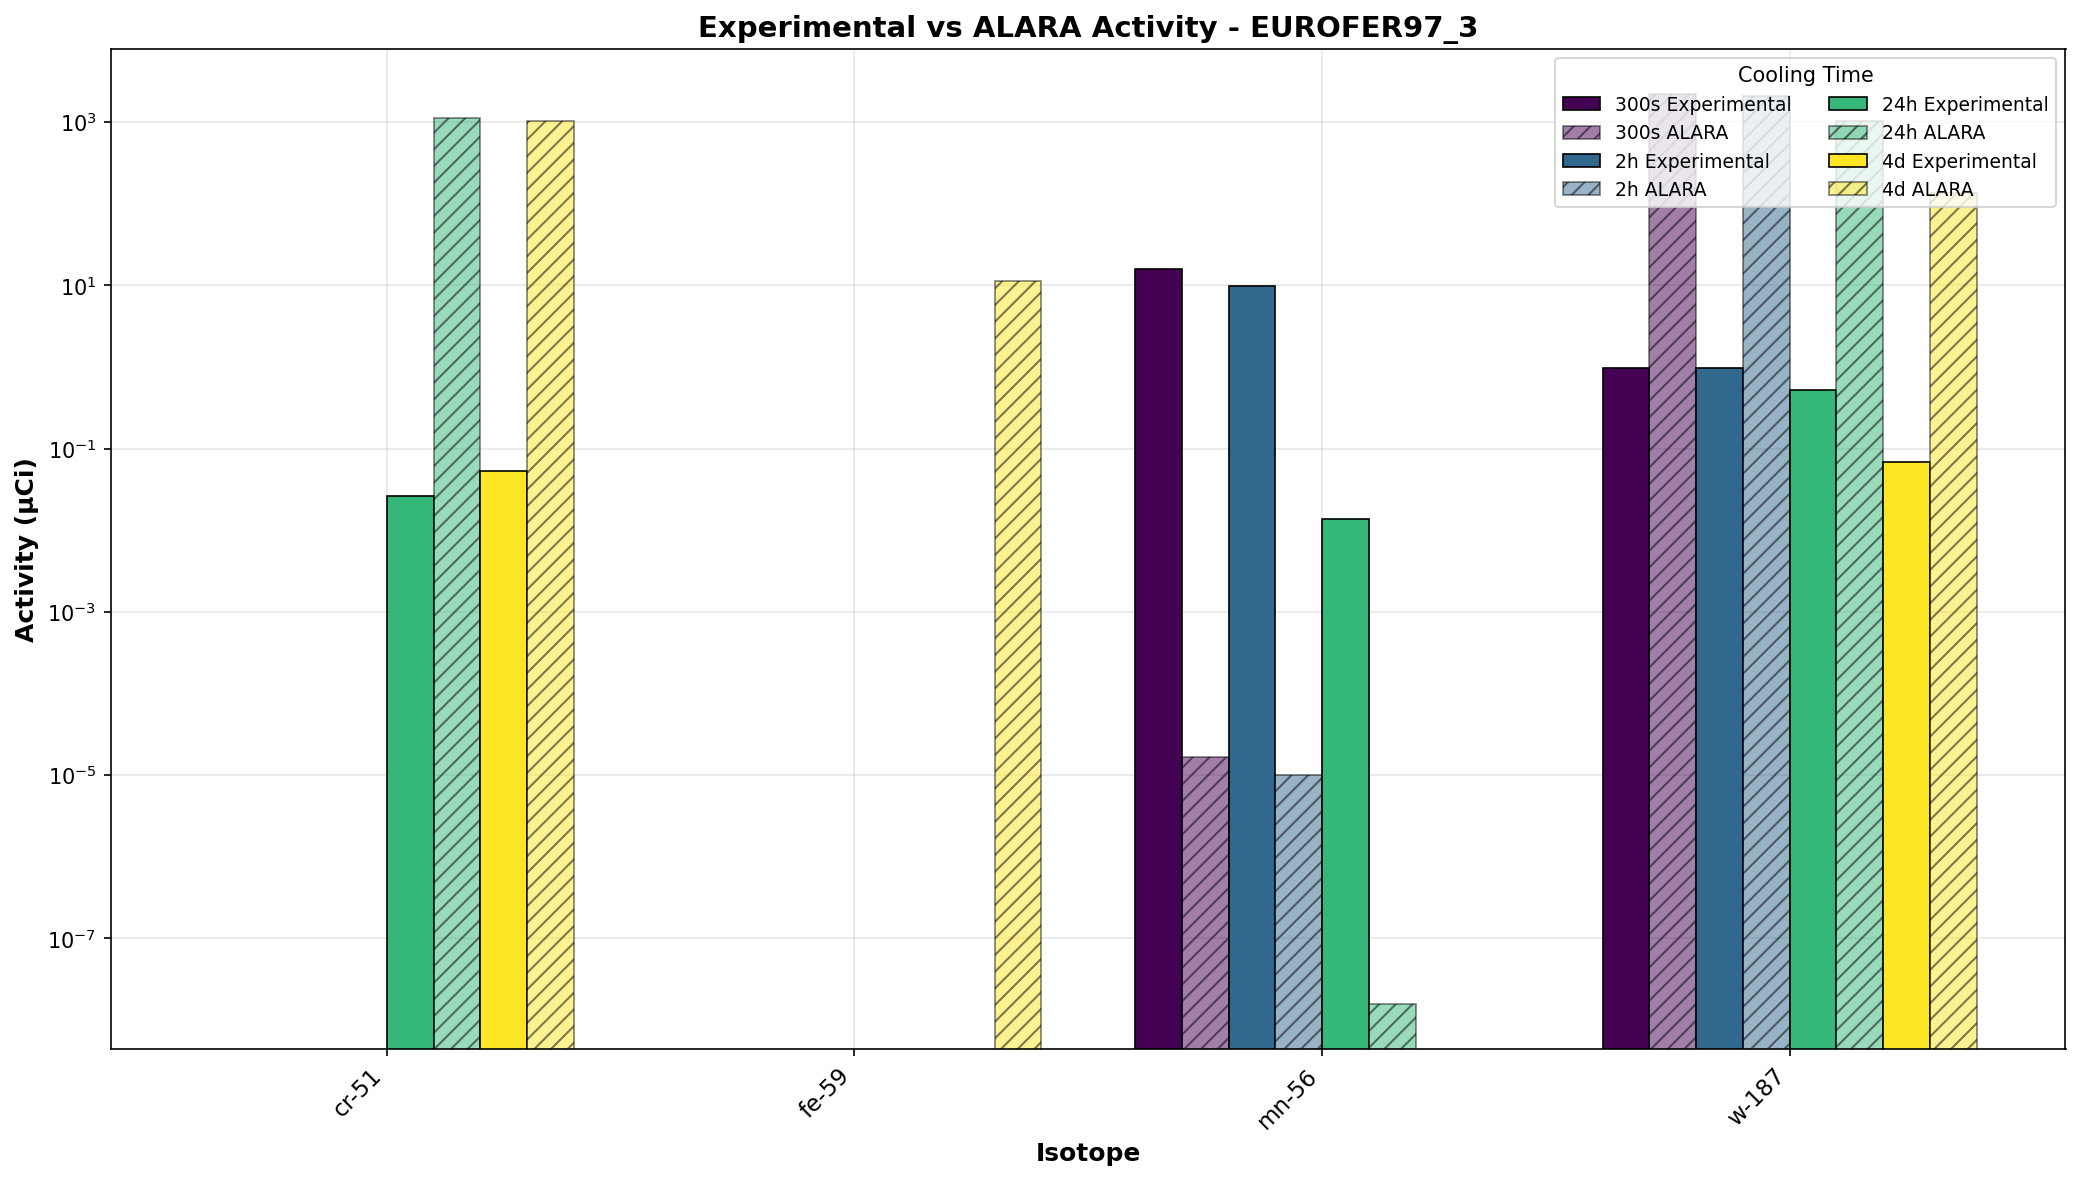

Figure saved to: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/comparison_EUROFER97_4.png


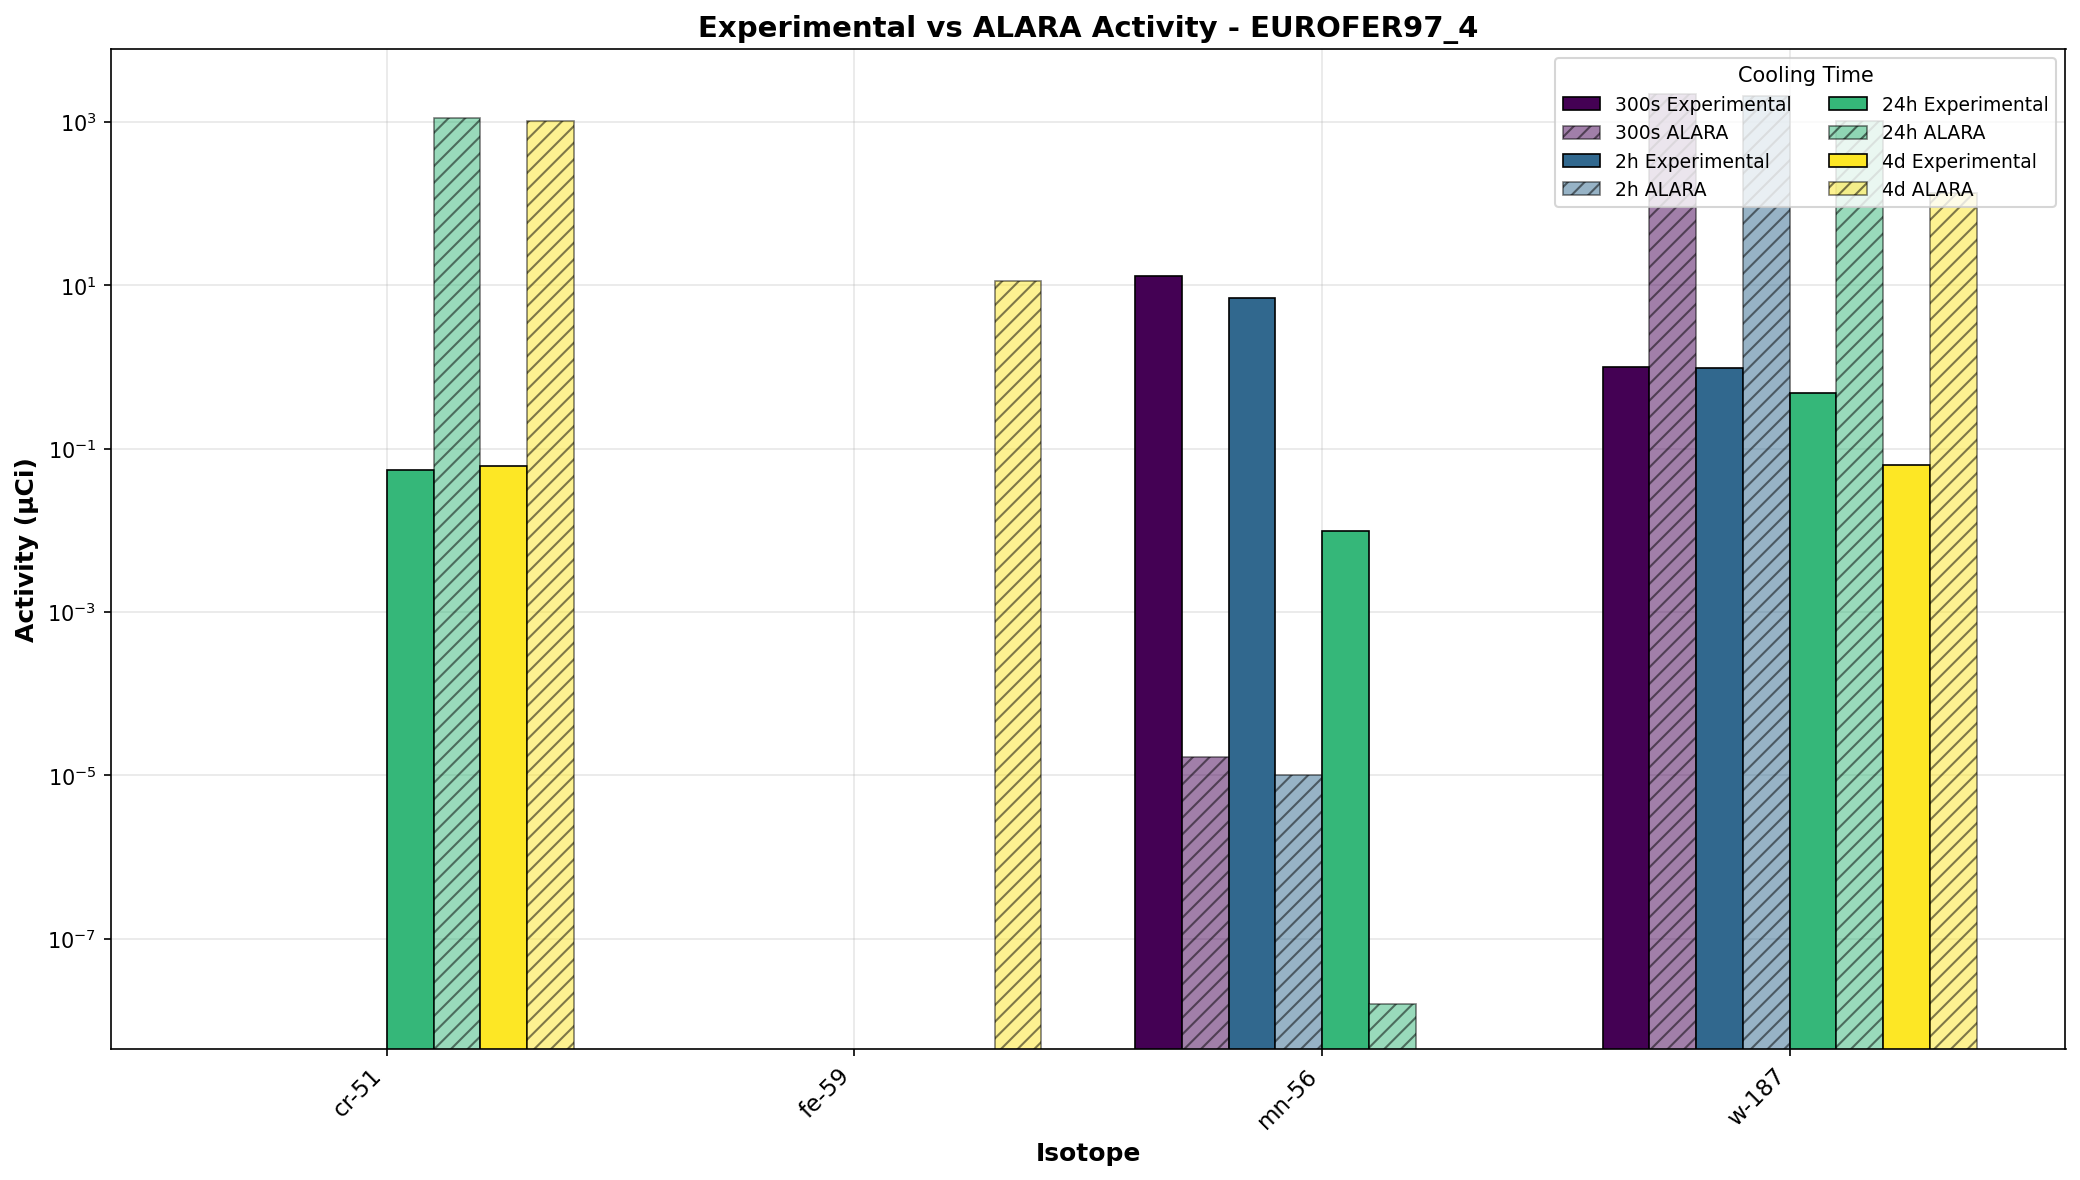

Generated 4 material comparison plots


In [107]:
# ==============================================================================
# STEP 3: DETAILED COMPARISON BY MATERIAL (NO RATIO PLOTS)
# ==============================================================================

# Create detailed comparison plots for each material
# Shows activities side-by-side (experimental vs ALARA)
if not comparison_df.empty:
    matched = alara_comparison.get_matched_isotopes(comparison_df)
    
    if not matched.empty:
        material_figures = alara_comparison.plot_comparison_by_material(
            matched,
            save_dir=alara_output_dir
        )
        print(f"Generated {len(material_figures)} material comparison plots")
    else:
        print("No matched isotopes for detailed plots")
else:
    print("No comparison data available for detailed plots")

DEBUG: Current Module Mappings
experimental_data_loader.__file__: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/scripts/experimental_data_loader.py
alara_threshold_plotting.__file__: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/scripts/alara_threshold_plotting.py
SAMPLE_TO_MATERIAL: {'N': 'CNA', 'A': 'EUROFER97_A', 'B': 'EUROFER97_B', 'C': 'EUROFER97_C'}
MATERIAL_TO_TALLY: {'CNA': 'tally_85214', 'EUROFER97_A': 'tally_85244', 'EUROFER97_B': 'tally_85234', 'EUROFER97_C': 'tally_85224'}
experimental_data.keys(): ['EUROFER97_A', 'EUROFER97_B', 'EUROFER97_C', 'CNA']

Saved plot to: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/alara_predicted_threshold_CNA_300s.png
Saved plot to: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/alara_predicted_threshold_CNA_2h.png
Saved plot to: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/alara_predic

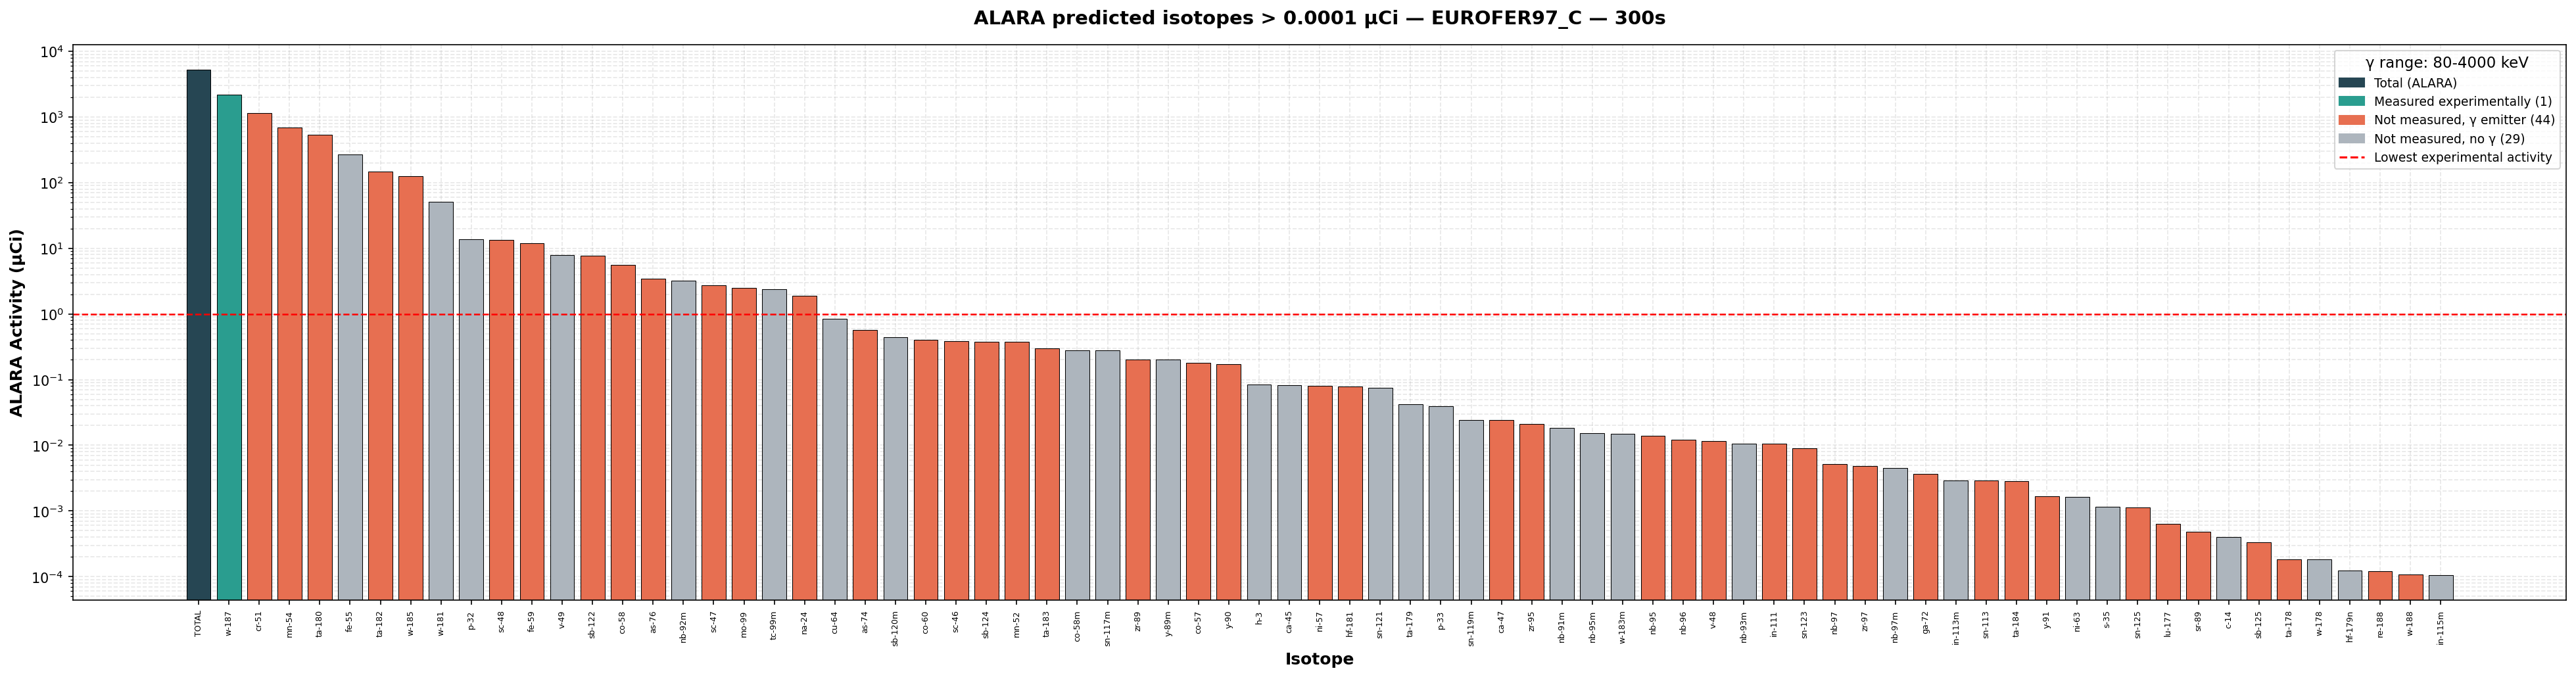

Saved plot to: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/alara_predicted_threshold_EUROFER97_C_2h.png


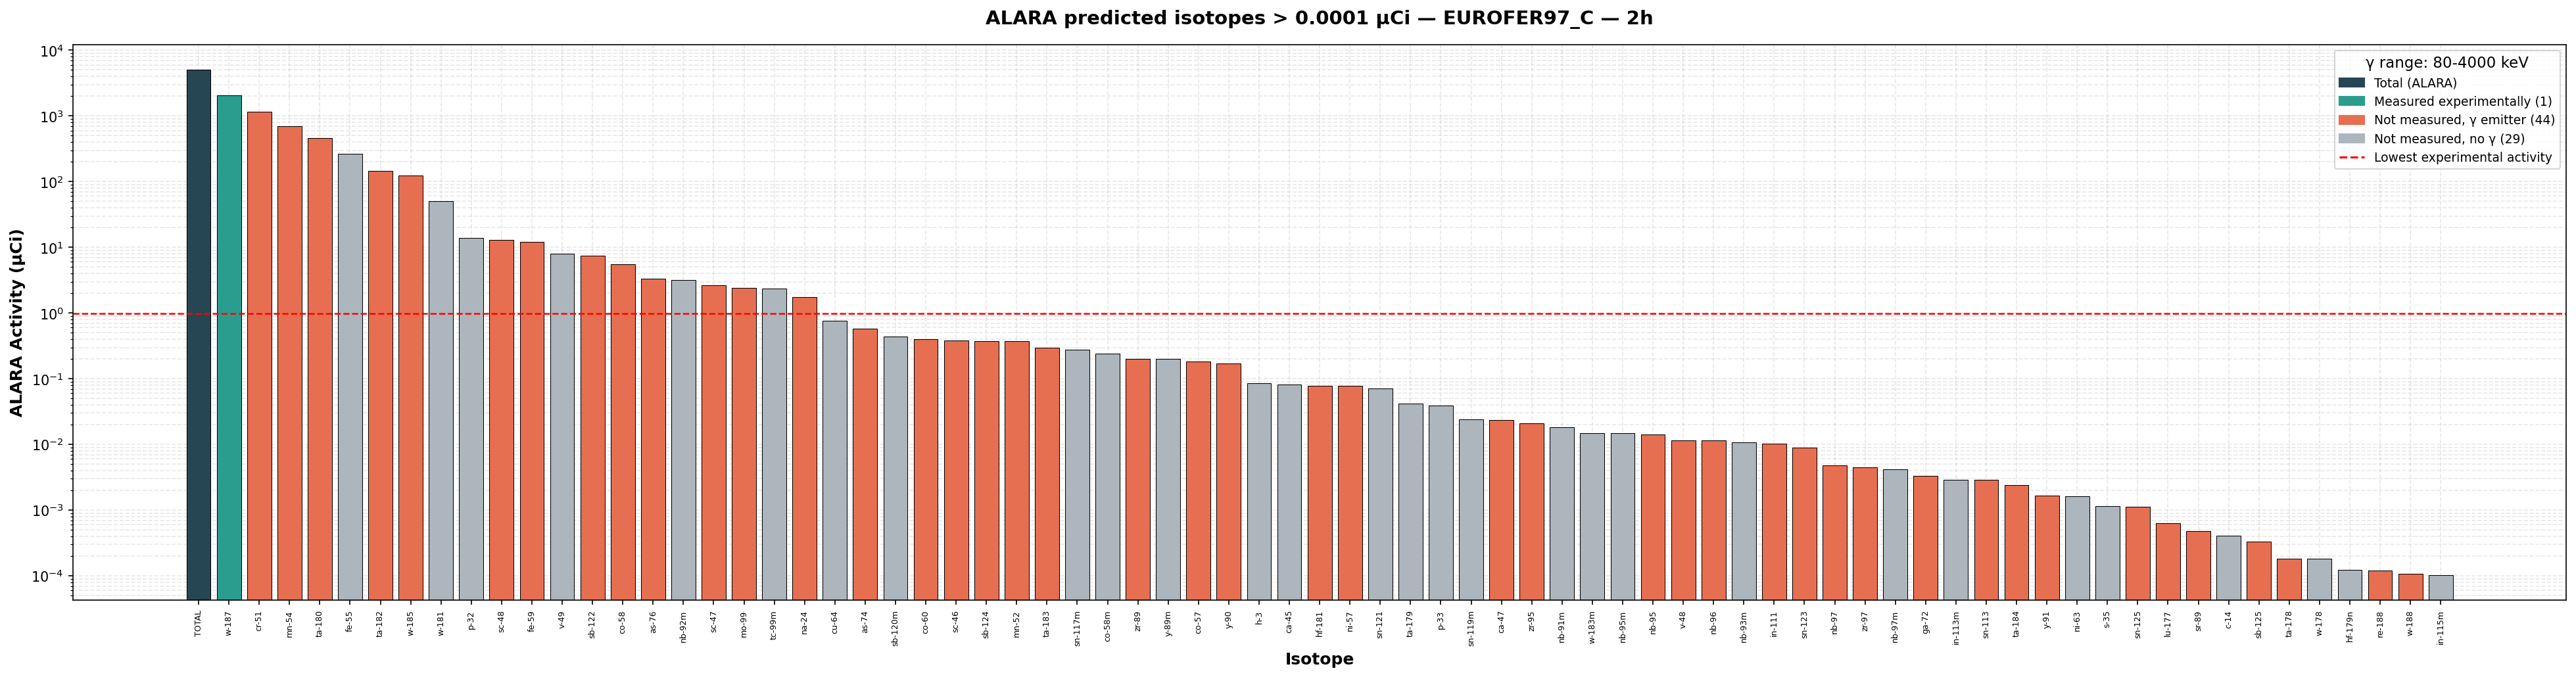

Saved plot to: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/alara_predicted_threshold_EUROFER97_C_24h.png


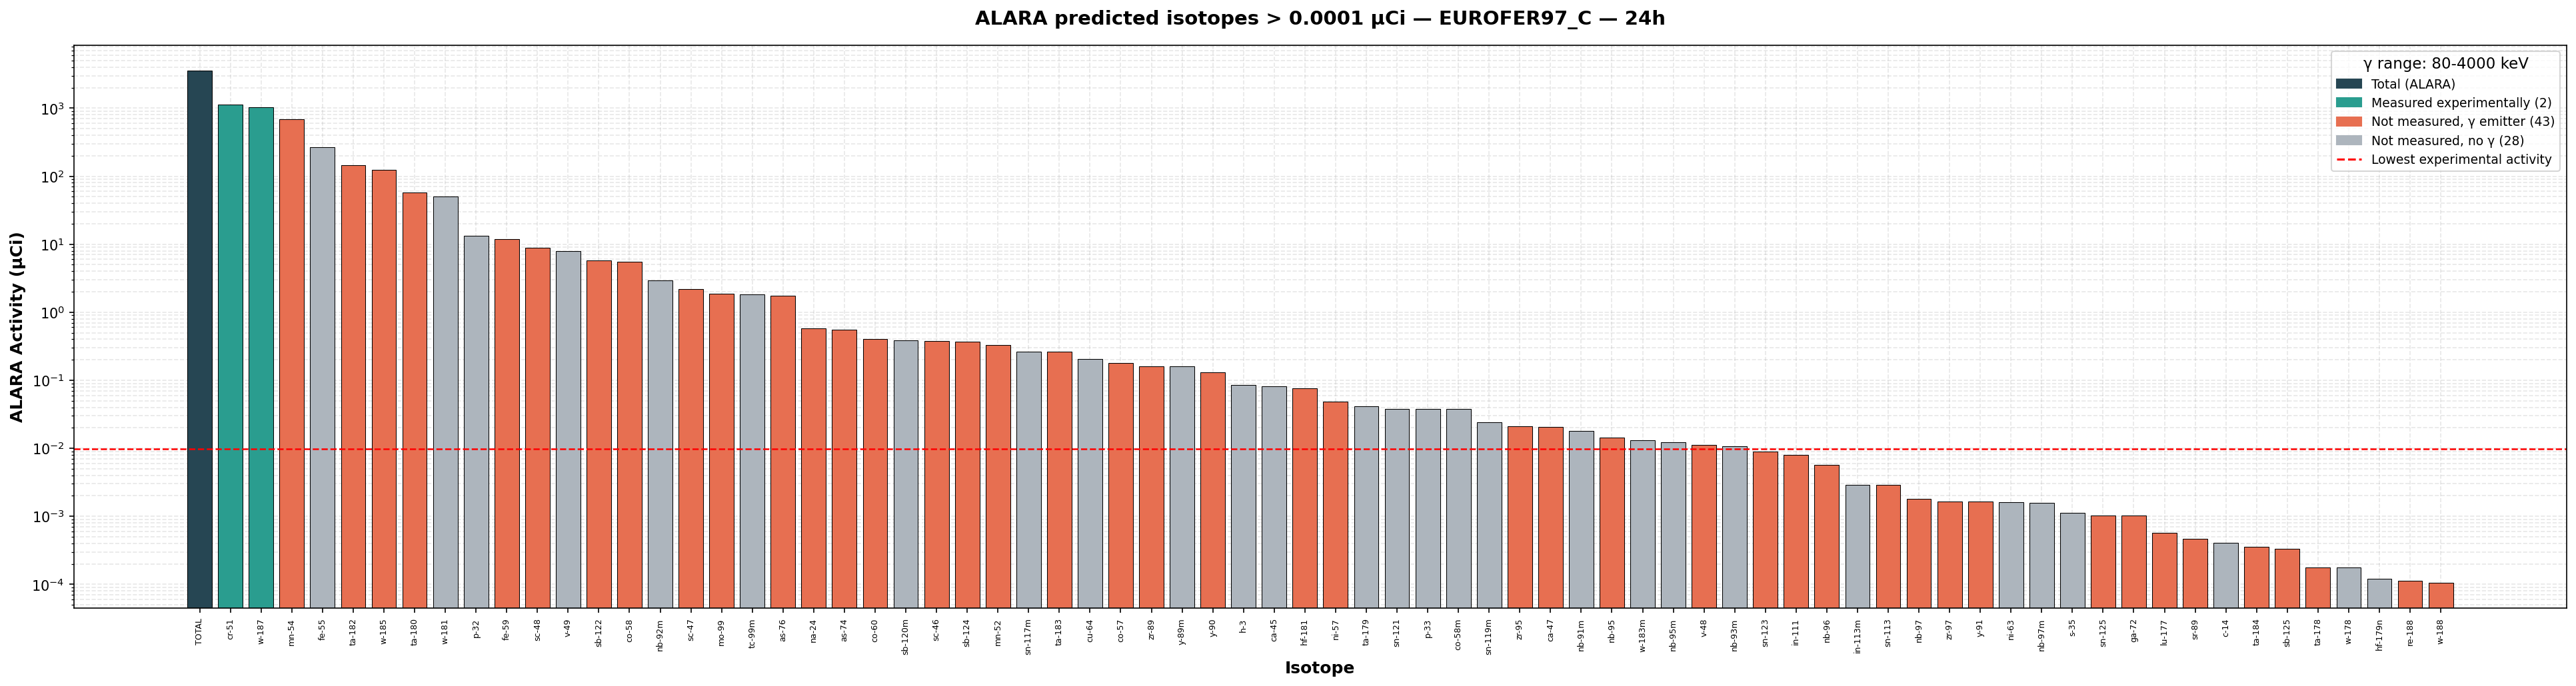

Saved plot to: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/alara_predicted_threshold_EUROFER97_C_4d.png


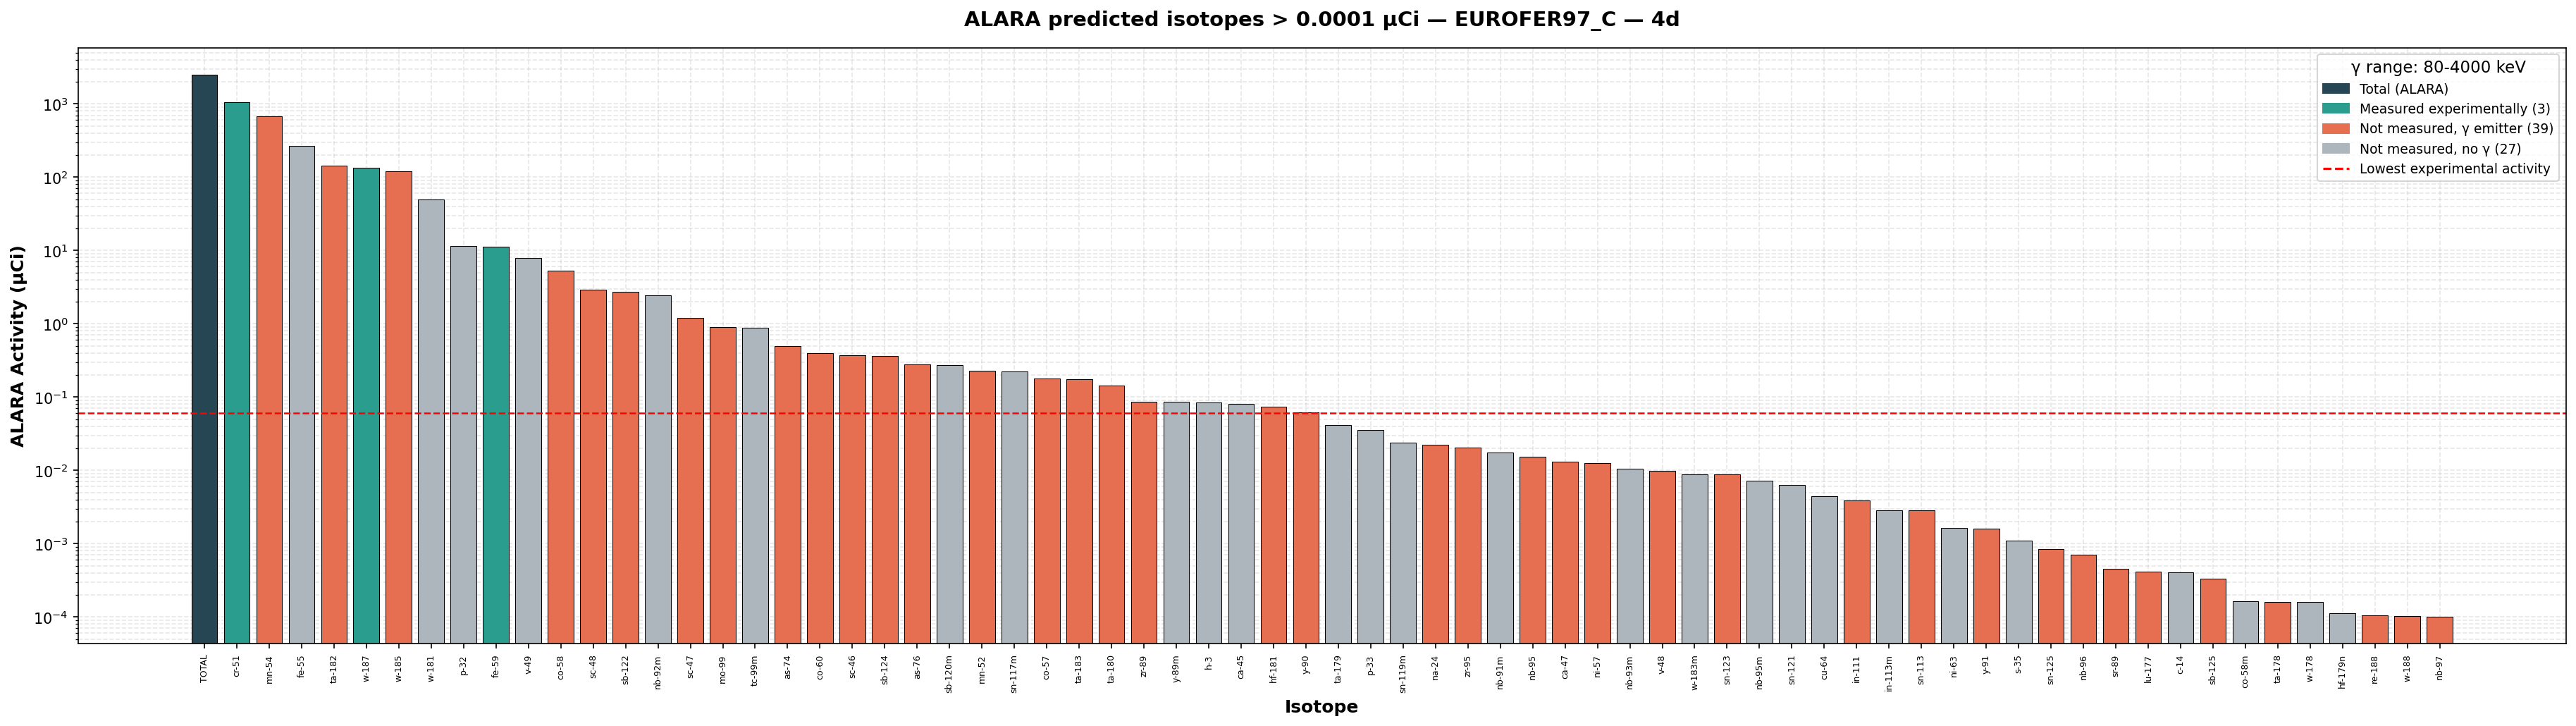

Saved plot to: /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/alara_predicted_threshold_EUROFER97_C_15d.png


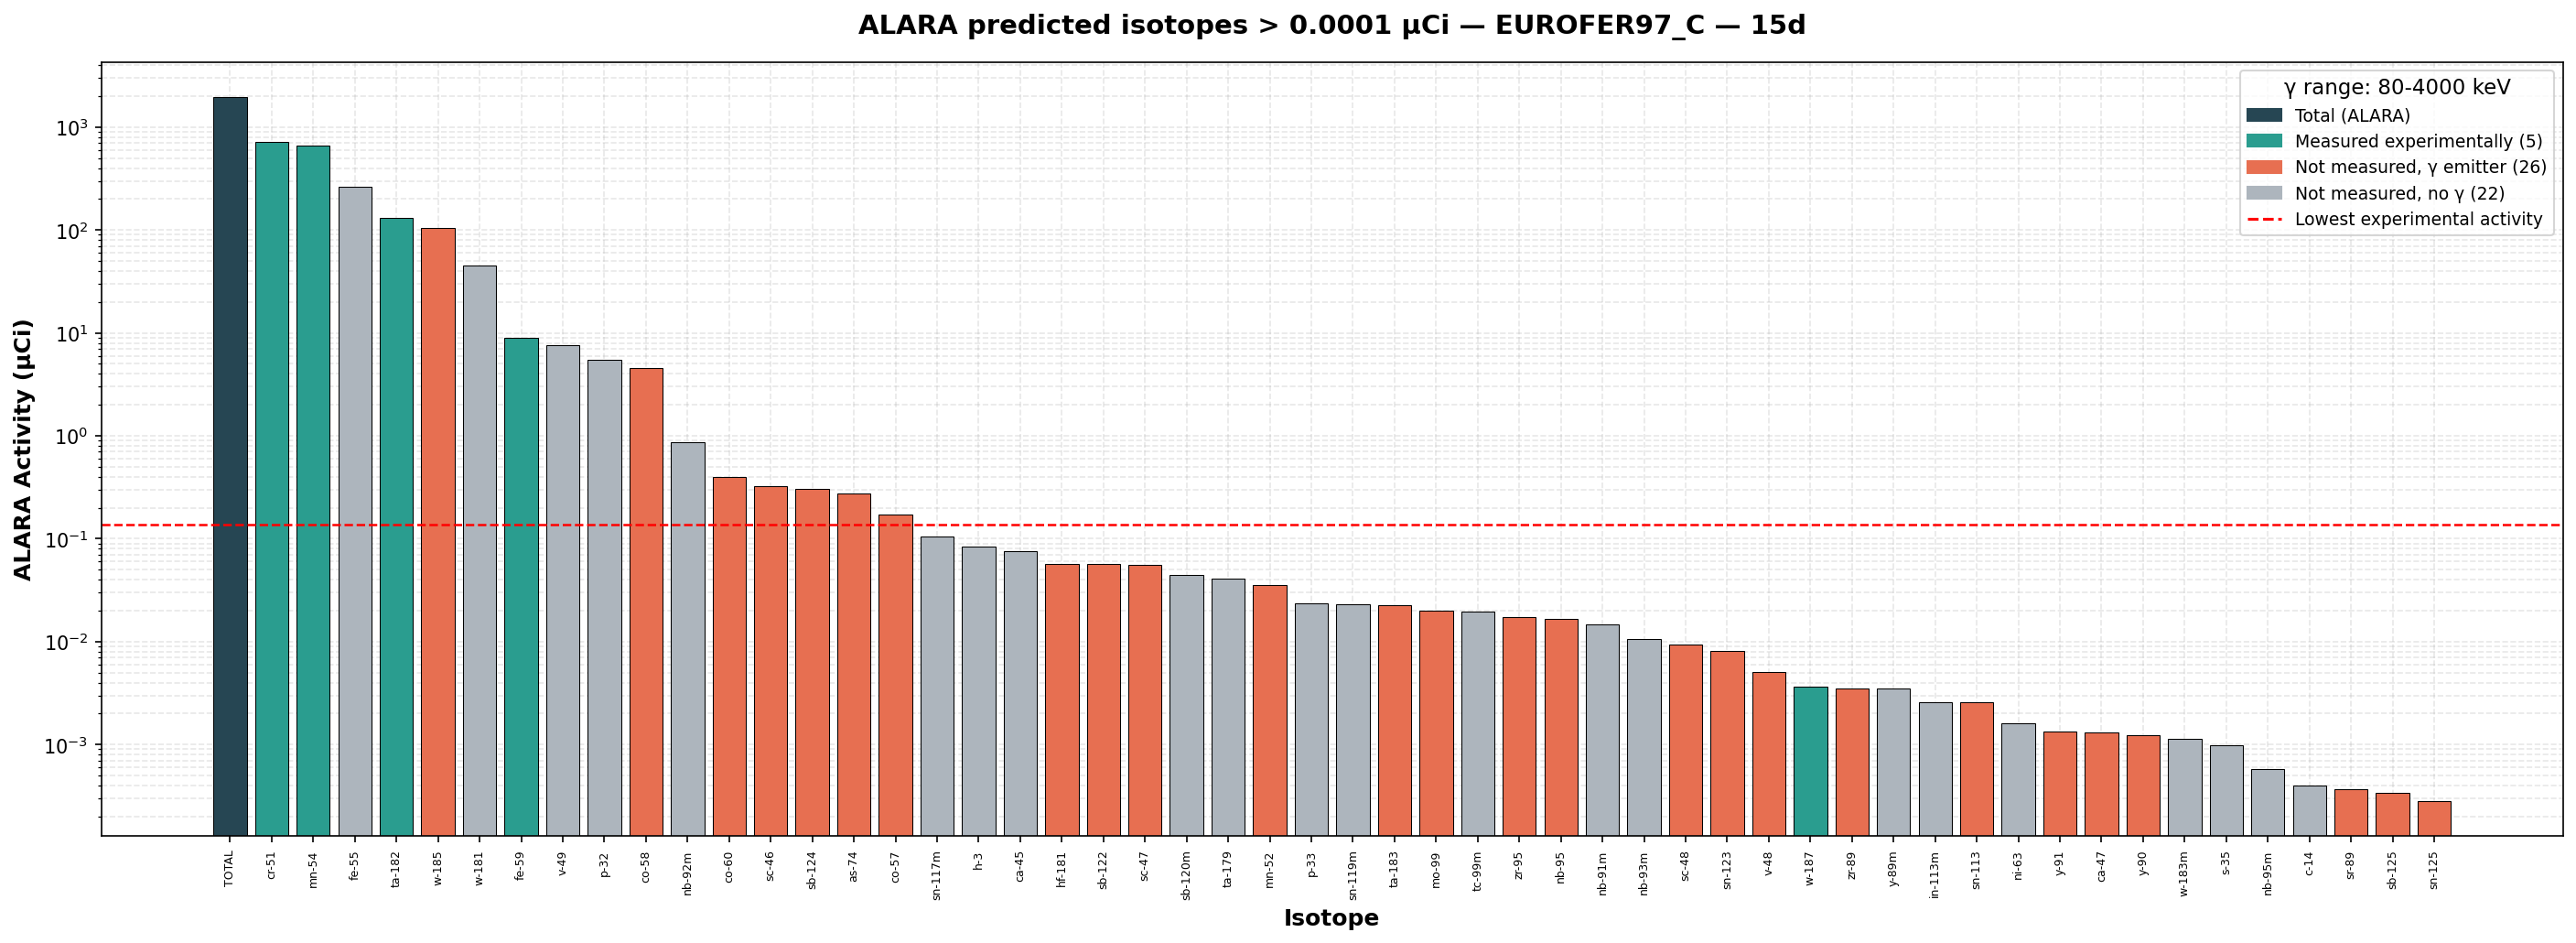


Generated threshold plots:
  CNA: 5 cooling time plots generated
  EUROFER97_A: 5 cooling time plots generated
  EUROFER97_B: 5 cooling time plots generated
  EUROFER97_C: 5 cooling time plots generated


In [113]:
# ==============================================================================
# STEP 4: ALARA PREDICTED THRESHOLD PLOTS
# ==============================================================================

# Force reload modules to pick up any changes
import importlib
import experimental_data_loader
import alara_threshold_plotting
importlib.reload(experimental_data_loader)
importlib.reload(alara_threshold_plotting)

# Re-import after reload
from experimental_data_loader import SAMPLE_TO_MATERIAL, MATERIAL_TO_TALLY

# Debug: Print current mappings
print("=" * 70)
print("DEBUG: Current Module Mappings")
print("=" * 70)
print(f"experimental_data_loader.__file__: {experimental_data_loader.__file__}")
print(f"alara_threshold_plotting.__file__: {alara_threshold_plotting.__file__}")
print(f"SAMPLE_TO_MATERIAL: {SAMPLE_TO_MATERIAL}")
print(f"MATERIAL_TO_TALLY: {MATERIAL_TO_TALLY}")
print(f"experimental_data.keys(): {list(experimental_data.keys())}")
print()

# Plot ALARA-predicted isotopes above detection threshold
# Shows which predicted isotopes were/weren't experimentally measured
threshold_uCi = 1e-4  # Detection threshold in µCi

# Plot threshold plots for all materials and cooling times
# Uses DYNAMIC column matching (no more hardcoded ALARA_COOLING_MAP!)
figures = alara_threshold_plotting.plot_all_materials_threshold(
    alara_output_dir=alara_output_dir,
    experimental_data=experimental_data,
    material_to_tally=MATERIAL_TO_TALLY,
    threshold_uCi=threshold_uCi,
    # Use the same cooling-time labels used by experimental_data_loader + ALARA column matching
    cooling_times=['300s', '2h', '24h', '4d', '15d'],
    save_dir=alara_output_dir,
    show_plots=False,
    show_materials=['EUROFER97_C']  # Only show EUROFER97_C plots
)

print(f"\nGenerated threshold plots:")
for material, ct_figs in figures.items():
    print(f"  {material}: {len(ct_figs)} cooling time plots generated")

In [109]:
# ==============================================================================
# STEP 5: ANALYZE ALARA ISOTOPES ABOVE THRESHOLD
# ==============================================================================

# Get counts of isotopes above threshold for each material and cooling time
isotope_counts_df = alara_threshold_plotting.count_alara_isotopes_by_material(
    alara_output_dir=alara_output_dir,
    material_to_tally=MATERIAL_TO_TALLY,
    threshold_uCi=threshold_uCi
)

if not isotope_counts_df.empty:
    print(f"\nALARA isotopes above {threshold_uCi} µCi threshold by material and cooling time:")
    display(isotope_counts_df)
    
    # Show example for one material
    for material, tally_folder in MATERIAL_TO_TALLY.items():
        alara_activity_file = alara_output_dir / f"{tally_folder}_Bq_per_cm3.csv"
        if alara_activity_file.exists():
            example_df = alara_threshold_plotting.get_alara_isotopes_above_threshold(
                alara_activity_file,
                cooling_time='24h',
                threshold_uCi=threshold_uCi
            )
            if not example_df.empty:
                print(f"\nTop 5 isotopes for {material} at 24h:")
                display(example_df.head(5))
            break
else:
    print("No ALARA isotopes found above threshold")


ALARA isotopes above 0.0001 µCi threshold by material and cooling time:


,material,cooling_time,isotope_count,total_activity_uCi
0,CNA,300s,79,5329.802931
1,CNA,2h,79,5141.713773
2,CNA,24h,79,3653.538112
3,CNA,4d,72,2456.051926
4,CNA,15d,55,1902.192538
5,EUROFER97_2,300s,76,5132.625625
6,EUROFER97_2,2h,76,4932.522075
7,EUROFER97_2,24h,73,3485.602287
8,EUROFER97_2,4d,69,2459.445340
9,EUROFER97_2,15d,48,1938.790438



Top 5 isotopes for CNA at 24h:


,isotope,activity_Bq_cm3,activity_uCi
151,w-187,44937000.0,1214.512299
27,cr-51,40477000.0,1093.971879
71,mn-54,25760000.0,696.215520
30,fe-55,9908000.0,267.783516
150,w-185,5389300.0,145.656611


In [110]:
# ==============================================================================
# STEP 6: SUMMARY OF ANALYSIS
# ==============================================================================

print("=" * 70)
print("ALARA vs EXPERIMENTAL COMPARISON SUMMARY")
print("=" * 70)

# Get matched vs unmatched isotopes
matched = alara_comparison.get_matched_isotopes(comparison_df)
unmatched = alara_comparison.get_unmatched_isotopes(comparison_df)

# Print full summary
alara_comparison.summarize_comparison(comparison_df)

print(f"\n4. ALARA PREDICTIONS ABOVE THRESHOLD ({threshold_uCi} µCi):")
if not isotope_counts_df.empty:
    total_isotopes = isotope_counts_df['isotope_count'].sum()
    total_activity = isotope_counts_df['total_activity_uCi'].sum()
    print(f"   Total isotope-cooling-time combinations: {total_isotopes}")
    print(f"   Total predicted activity: {total_activity:.3e} µCi")

print(f"\n5. FILES GENERATED:")
print(f"   - {alara_output_dir / 'experimental_comparison.csv'}")
print(f"   - {alara_output_dir / 'comparison_scatter.png'}")
for material, ct_figs in figures.items():
    for ct in ct_figs:
        safe_mat = material.replace(' ', '_')
        print(f"   - {alara_output_dir / f'alara_predicted_threshold_{safe_mat}_{ct}.png'}")

print("\n" + "=" * 70)
print("Analysis complete! See generated plots and CSV files for details.")
print("=" * 70)

ALARA vs EXPERIMENTAL COMPARISON SUMMARY
COMPARISON ANALYSIS SUMMARY

1. MATCHING STATISTICS:
   Total experimental measurements: 44
   Matched with ALARA: 38
   Not found in ALARA: 6
   Match rate: 86.4%

2. BY MATERIAL:
   CNA: 10/12 matched
   EUROFER97_2: 8/10 matched
   EUROFER97_3: 10/11 matched
   EUROFER97_4: 10/11 matched

3. BY COOLING TIME:
   300s: 8/14 matched
   2h: 6/6 matched
   24h: 12/12 matched
   4d: 12/12 matched

4. UNMATCHED ISOTOPES (experimental only):
   - al-28 (in EUROFER97_2, CNA)
   - v-52 (in EUROFER97_2, EUROFER97_3, EUROFER97_4, CNA)

4. ALARA PREDICTIONS ABOVE THRESHOLD (0.0001 µCi):
   Total isotope-cooling-time combinations: 1392
   Total predicted activity: 7.292e+04 µCi

5. FILES GENERATED:
   - /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/experimental_comparison.csv
   - /groupspace/cnerg/users/smandych/projects/ALARA/rafm_irradiation_ldrd/alara_output/comparison_scatter.png
   - /groupspace/cnerg/users/smandy